# Dynamic Conflict Clustering-Incomplete — Final Repository Notebook
Copyright © 2026 Raziyeh Moghaddas

This repository notebook contains the implementation used for the paper **Dynamic Conflict Clustering with lightweight Learning and Strategic Repair for Distributed Constraint Satisfaction**.

The notebook merges the implementation, functional-validation tests, benchmark generation, DCC internal comparison, pyDCOP external comparison, and table-generation steps into one runnable workflow.

Included DCC variants:

- `DCC-Incomplete-random`
- `DCC-Incomplete` / `DCC-Incomplete-memory_guided`

**Minimal reproducibility revision:** external-baseline success rates are aggregated over 10 executions; all other experimental logic and reported metrics remain unchanged. Paper-facing tables omit NSC/solved-case counts.


In [1]:
from pathlib import Path
import os, sys, random

PROJECT_ROOT = Path.cwd()
for _d in [
    Path("figures"),
    Path("final_four_level_benchmark"),
    Path("pydcop_external_comparison"),
    Path("final_paper1_comparison"),
]:
    _d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Repository output folders prepared.")

Project root: C:\dcop-research
Python executable: C:\dcop-research\pydcop_env\Scripts\python.exe
Python version: 3.10.8 (tags/v3.10.8:aaaf517, Oct 11 2022, 16:50:30) [MSC v.1933 64 bit (AMD64)]
Repository output folders prepared.


## 1. Benchmark-ready DCC-Incomplete implementation

In [2]:
import pandas as pd
import math
import random
import time
import copy
import json
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Callable, Any
from collections import deque

try:
    from IPython.display import display
except Exception:
    display = print

SEED = 15
random.seed(SEED)
print("Random seed is set to:", SEED)

Random seed is set to: 15


In [3]:
@dataclass
class BinaryConstraint:
    name: str
    var1: str
    var2: str
    condition: Callable[[Any, Any], bool]

    def is_satisfied(self, assignment: Dict[str, Any]) -> bool:
        """
        Check whether this constraint is satisfied under the current assignment.
        """
        value1 = assignment[self.var1]
        value2 = assignment[self.var2]
        return self.condition(value1, value2)

    def involves(self, variable: str) -> bool:
        """
        Check whether a variable is part of this constraint.
        """
        return variable == self.var1 or variable == self.var2

    def other_variable(self, variable: str) -> str:
        """
        Given one variable in the constraint, return the other variable.
        """
        if variable == self.var1:
            return self.var2
        elif variable == self.var2:
            return self.var1
        else:
            raise ValueError(f"{variable} is not involved in constraint {self.name}")

In [4]:
@dataclass
class DCSPProblem:
    variables: List[str]
    domains: Dict[str, List[Any]]
    constraints: List[BinaryConstraint]

    def random_initial_assignment(self, seed: int = 15) -> Dict[str, Any]:
        """
        Generate a random complete assignment using a fixed seed.
        """
        random.seed(seed)
        assignment = {}

        for var in self.variables:
            assignment[var] = random.choice(self.domains[var])

        return assignment

    def violated_constraints(self, assignment: Dict[str, Any]) -> List[BinaryConstraint]:
        """
        Return all constraints that are violated under the current assignment.
        """
        return [
            constraint
            for constraint in self.constraints
            if not constraint.is_satisfied(assignment)
        ]

    def local_cost(self, variable: str, value: Any, assignment: Dict[str, Any]) -> int:
        """
        LCost_i(v): number of violated constraints involving variable x_i
        if x_i is assigned value v.
        """
        temporary_assignment = assignment.copy()
        temporary_assignment[variable] = value

        cost = 0
        for constraint in self.constraints:
            if constraint.involves(variable):
                if not constraint.is_satisfied(temporary_assignment):
                    cost += 1

        return cost

    def score(self, variable: str, assignment: Dict[str, Any]) -> int:
        """
        Score(a_i) = -LCost_i(current_value)
        """
        current_value = assignment[variable]
        return -self.local_cost(variable, current_value, assignment)

In [5]:
def classify_agents(problem, assignment):
    """
    Classify agents into ActiveAgents and PassiveAgents.

    ActiveAgent: Score < 0
    PassiveAgent: Score = 0
    """
    active_agents = []
    passive_agents = []

    for var in problem.variables:
        s = problem.score(var, assignment)

        if s < 0:
            active_agents.append(var)
        else:
            passive_agents.append(var)

    return active_agents, passive_agents

In [6]:
def build_conflict_subgraph(problem, assignment):
    """
    Build the conflict subgraph from currently violated constraints.

    Nodes:
        active variables/agents involved in violated constraints

    Edges:
        pairs of variables connected by violated constraints
    """
    conflict_nodes = set()
    conflict_edges = []

    violated = problem.violated_constraints(assignment)

    for constraint in violated:
        var1 = constraint.var1
        var2 = constraint.var2

        conflict_nodes.add(var1)
        conflict_nodes.add(var2)
        conflict_edges.append((var1, var2))

    return conflict_nodes, conflict_edges

In [7]:
def extract_conflict_clusters(conflict_nodes, conflict_edges):
    """
    Extract ConflictClusters as connected components of the conflict subgraph.

    The implementation sorts nodes and neighbours to ensure reproducible
    cluster ordering across repeated experimental runs.
    """

    adjacency = {node: set() for node in conflict_nodes}

    for var1, var2 in conflict_edges:
        adjacency[var1].add(var2)
        adjacency[var2].add(var1)

    visited = set()
    clusters = []

    for node in sorted(conflict_nodes):
        if node not in visited:
            cluster = set()
            stack = [node]

            while stack:
                current = stack.pop()

                if current not in visited:
                    visited.add(current)
                    cluster.add(current)

                    for neighbor in sorted(adjacency[current], reverse=True):
                        if neighbor not in visited:
                            stack.append(neighbor)

            clusters.append(cluster)

    # Ensure reproducible ordering of clusters:
    # the cluster containing the smallest variable ID appears first.
    clusters.sort(
        key=lambda cluster: min(int(var[1:]) for var in cluster)
    )

    return clusters

In [8]:
def select_leader(problem, assignment, cluster):
    """
    Select the cluster leader.

    Leader = least conflicted agent in the cluster.
    Since scores are negative, this means maximum score.
    Tie is broken by variable name.
    """
    return max(
        cluster,
        key=lambda var: (problem.score(var, assignment), -int(var[1:]))
    )

def select_target(problem, assignment, cluster):
    """
    Select the target agent.

    Target = most conflicted agent in the cluster.
    Since scores are negative, this means minimum score.
    Tie is broken by variable name.
    """
    return min(
        cluster,
        key=lambda var: (problem.score(var, assignment), int(var[1:]))
    )

In [9]:
from dataclasses import dataclass, field

from typing import Set, List, Dict, Any, Tuple

@dataclass
class CoordinationRecord:
    """
    CoordinationLayer record for one ConflictCluster.
    """
    cluster_id: str
    members: Set[str]
    leader: str
    context: Dict[str, Any]
    boundary_edges: List[Tuple[str, str]]
    conflict_level: int
    state: str = "idle"
    deferred_queue: List[Dict[str, Any]] = field(default_factory=list)
    no_improve_count: int = 0

In [10]:
def build_cluster_context(problem, assignment, cluster):
    """
    Build the context for a cluster.

    Context includes:
    - current values of all cluster members
    - current values of external boundary neighbours
    """
    context = {}

    # Add cluster members
    for var in cluster:
        context[var] = assignment[var]

    # Add boundary neighbours
    for constraint in problem.constraints:
        var1 = constraint.var1
        var2 = constraint.var2

        if var1 in cluster and var2 not in cluster:
            context[var2] = assignment[var2]

        if var2 in cluster and var1 not in cluster:
            context[var1] = assignment[var1]

    return context

In [11]:
def find_boundary_edges(problem, cluster):
    """
    Find boundary edges from this cluster to variables outside the cluster.
    """
    boundary_edges = []

    for constraint in problem.constraints:
        var1 = constraint.var1
        var2 = constraint.var2

        if var1 in cluster and var2 not in cluster:
            boundary_edges.append((var1, var2))

        elif var2 in cluster and var1 not in cluster:
            boundary_edges.append((var2, var1))

    return boundary_edges

In [12]:
def compute_cluster_conflict_level(problem, assignment, cluster):
    """
    Compute the cluster conflict level.

    V_k = sum(-Score(a_i)) for all agents in the cluster.
    """
    total = 0

    for var in cluster:
        total += -problem.score(var, assignment)

    return total

In [13]:
def build_coordination_layer(problem, assignment, conflict_clusters):
    """
    Build CoordinationLayer records for all ConflictClusters.
    """
    coordination_layer = {}

    for idx, cluster in enumerate(conflict_clusters, start=1):
        cluster_id = f"K{idx}"

        leader = select_leader(problem, assignment, cluster)
        context = build_cluster_context(problem, assignment, cluster)
        boundary_edges = find_boundary_edges(problem, cluster)
        conflict_level = compute_cluster_conflict_level(problem, assignment, cluster)

        record = CoordinationRecord(
            cluster_id=cluster_id,
            members=cluster,
            leader=leader,
            context=context,
            boundary_edges=boundary_edges,
            conflict_level=conflict_level,
            state="idle"
        )

        coordination_layer[cluster_id] = record

    return coordination_layer

In [14]:
from dataclasses import dataclass

from typing import Any, Dict

@dataclass
class Message:
    """
    A simple message object used to simulate communication
    in the standalone implementation.
    """
    message_type: str
    sender: str
    receiver: str
    content: Dict[str, Any]

In [15]:
class CommunicationLog:
    """
    Stores all communication messages exchanged during solving.
    This allows us to count and inspect messages.
    """

    def __init__(self):
        self.messages = []

    def send(self, message_type, sender, receiver, content=None):
        """
        Create and store a message.
        """
        if content is None:
            content = {}

        message = Message(
            message_type=message_type,
            sender=sender,
            receiver=receiver,
            content=content
        )

        self.messages.append(message)
        return message

    def count(self):
        """
        Return the total number of messages.
        """
        return len(self.messages)

    def show(self):
        """
        Print all messages in a readable form.
        """
        for idx, msg in enumerate(self.messages, start=1):
            print(
                f"{idx}. {msg.message_type}: "
                f"{msg.sender} -> {msg.receiver}, "
                f"content={msg.content}"
            )

In [16]:
def agent_proposal(
    problem,
    assignment,
    agent,
    context,
    stagnation_mode=False
):
    """
    Generate a repair proposal for one agent.

    Normal mode:
        Only strictly improving moves are allowed.

    Stagnation mode:
        A sideways move is allowed when no strictly improving move exists.
        A sideways move keeps the same local cost but changes the value.
    """

    current_value = assignment[agent]

    current_cost = problem.local_cost(
        agent,
        current_value,
        assignment
    )

    improving_candidates = []
    sideways_candidates = []

    for candidate_value in problem.domains[agent]:

        # Do not propose the current value again
        if candidate_value == current_value:
            continue

        candidate_cost = problem.local_cost(
            agent,
            candidate_value,
            assignment
        )

        candidate = {
            "value": candidate_value,
            "cost": candidate_cost
        }

        # Strict improvement
        if candidate_cost < current_cost:
            improving_candidates.append(candidate)

        # Equal-cost move, allowed only during stagnation handling
        elif (
            stagnation_mode
            and candidate_cost == current_cost
        ):
            sideways_candidates.append(candidate)

    # --------------------------------------------------------
    # Priority 1: choose the best strictly improving move
    # --------------------------------------------------------
    if improving_candidates:
        best_candidate = min(
            improving_candidates,
            key=lambda item: (
                item["cost"],
                str(item["value"])
            )
        )

        return {
            "type": "REPAIR_PROPOSAL",
            "move_type": "STRICT_IMPROVEMENT",
            "agent": agent,
            "current_value": current_value,
            "proposed_value": best_candidate["value"],
            "current_cost": current_cost,
            "proposed_cost": best_candidate["cost"]
        }

    # --------------------------------------------------------
    # Priority 2: choose a sideways move in stagnation mode
    # --------------------------------------------------------
    if sideways_candidates:
        best_candidate = min(
            sideways_candidates,
            key=lambda item: str(item["value"])
        )

        return {
            "type": "REPAIR_PROPOSAL",
            "move_type": "SIDEWAYS_MOVE",
            "agent": agent,
            "current_value": current_value,
            "proposed_value": best_candidate["value"],
            "current_cost": current_cost,
            "proposed_cost": best_candidate["cost"]
        }

    # --------------------------------------------------------
    # No acceptable move exists
    # --------------------------------------------------------
    return {
        "type": "NO_IMPROVEMENT",
        "agent": agent,
        "current_value": current_value,
        "current_cost": current_cost
    }

In [17]:
def creates_boundary_conflict(problem, assignment, cluster, agent, proposed_value):
    """
    Check whether changing agent's value to proposed_value creates
    any violated constraint with a variable outside the current cluster.

    Returns:
        (has_conflict, conflicting_edges)
    """
    temporary_assignment = assignment.copy()
    temporary_assignment[agent] = proposed_value

    conflicting_edges = []

    for constraint in problem.constraints:
        # We only care about constraints involving the changing agent
        if not constraint.involves(agent):
            continue

        other_var = constraint.other_variable(agent)

        # Boundary conflict means the other variable is outside the cluster
        if other_var not in cluster:
            if not constraint.is_satisfied(temporary_assignment):
                conflicting_edges.append((agent, other_var, constraint.name))

    has_conflict = len(conflicting_edges) > 0

    return has_conflict, conflicting_edges

In [18]:
def apply_accepted_proposal(assignment, proposal):
    """
    Apply an accepted repair proposal to the current assignment.
    """
    agent = proposal["agent"]
    new_value = proposal["proposed_value"]

    old_value = assignment[agent]
    assignment[agent] = new_value

    return old_value, new_value

In [19]:
def rebuild_runtime_state(problem, assignment):
    """
    Rebuild all dynamic structures after an accepted value update.
    """
    active_agents, passive_agents = classify_agents(problem, assignment)

    conflict_nodes, conflict_edges = build_conflict_subgraph(problem, assignment)

    conflict_clusters = extract_conflict_clusters(
        conflict_nodes,
        conflict_edges
    )

    coordination_layer = build_coordination_layer(
        problem,
        assignment,
        conflict_clusters
    )

    return {
        "active_agents": active_agents,
        "passive_agents": passive_agents,
        "conflict_nodes": conflict_nodes,
        "conflict_edges": conflict_edges,
        "conflict_clusters": conflict_clusters,
        "coordination_layer": coordination_layer
    }

In [20]:
def find_cluster_id_for_variable(
    coordination_layer,
    variable,
    exclude_cluster_id=None
):
    """
    Return the ID of the ConflictCluster containing variable.
    """
    for cluster_id, record in coordination_layer.items():
        if cluster_id == exclude_cluster_id:
            continue

        if variable in record.members:
            return cluster_id

    return None

def identify_neighbor_clusters(
    coordination_layer,
    current_cluster_id,
    conflicting_edges
):
    """
    Identify neighbouring active clusters involved in boundary conflicts.
    """
    neighbor_cluster_ids = []

    for _, external_var, _ in conflicting_edges:
        neighbor_cluster_id = find_cluster_id_for_variable(
            coordination_layer=coordination_layer,
            variable=external_var,
            exclude_cluster_id=current_cluster_id
        )

        if (
            neighbor_cluster_id is not None
            and neighbor_cluster_id not in neighbor_cluster_ids
        ):
            neighbor_cluster_ids.append(neighbor_cluster_id)

    return neighbor_cluster_ids

In [21]:
def leader_decision(
    problem,
    assignment,
    record,
    proposal,
    comm_log,
    coordination_layer
):
    """
    Leader decides whether to ACCEPT, DEFER, or record NO_IMPROVEMENT.

    No reply is sent after NO_IMPROVEMENT.
    When the leader evaluates its own variable, local actions are not
    counted as communication messages.
    """
    leader = record.leader
    cluster = record.members

    # Case 1: no improving proposal
    if proposal["type"] == "NO_IMPROVEMENT":
        return {
            "decision": "NO_IMPROVEMENT",
            "agent": proposal["agent"],
            "next_action": "SELECT_NEXT_TARGET"
        }

    # Case 2: candidate repair proposal
    agent = proposal["agent"]
    proposed_value = proposal["proposed_value"]

    has_boundary_conflict, conflicting_edges = creates_boundary_conflict(
        problem=problem,
        assignment=assignment,
        cluster=cluster,
        agent=agent,
        proposed_value=proposed_value
    )

    # Accept proposal if no boundary conflict is created
    if not has_boundary_conflict:
        if agent != leader:
            comm_log.send(
                message_type="ACCEPT",
                sender=leader,
                receiver=agent,
                content={
                    "agent": agent,
                    "accepted_value": proposed_value
                }
            )

        old_value, new_value = apply_accepted_proposal(
            assignment=assignment,
            proposal=proposal
        )

        if agent != leader:
            comm_log.send(
                message_type="VALUE_UPDATE",
                sender=agent,
                receiver=leader,
                content={
                    "agent": agent,
                    "old_value": old_value,
                    "new_value": new_value
                }
            )

        record.deferred_queue.clear()

        return {
            "decision": "ACCEPT",
            "agent": agent,
            "old_value": old_value,
            "new_value": new_value,
            "next_action": "REBUILD_STATE"
        }

    # Defer proposal if boundary conflict is created
    neighbor_cluster_ids = identify_neighbor_clusters(
        coordination_layer=coordination_layer,
        current_cluster_id=record.cluster_id,
        conflicting_edges=conflicting_edges
    )

    deferred_item = {
        "agent": agent,
        "proposed_value": proposed_value,
        "proposed_cost": proposal["proposed_cost"],
        "conflicting_edges": conflicting_edges,
        "neighbor_cluster_ids": neighbor_cluster_ids
    }

    record.deferred_queue.append(deferred_item)

    # Do not count an internal leader-to-self action as a message
    if agent != leader:
        comm_log.send(
            message_type="DEFER",
            sender=leader,
            receiver=agent,
            content={
                "reason": "Boundary conflict detected.",
                "deferred_item": deferred_item
            }
        )

    return {
        "decision": "DEFER",
        "agent": agent,
        "deferred_item": deferred_item,
        "next_action": "SELECT_NEXT_TARGET"
    }

In [22]:
def order_targets_by_conflict(problem, assignment, cluster, leader):
    """
    Order target agents for repair.

    Rule:
    1. Non-leader agents are examined first.
    2. They are ordered from most conflicted to least conflicted.
    3. The leader is examined last, only if no other agent improves the cluster.

    Most conflicted = lowest score.
    Tie is broken by smallest variable ID.
    """

    non_leaders = [var for var in cluster if var != leader]

    ordered_non_leaders = sorted(
        non_leaders,
        key=lambda var: (problem.score(var, assignment), int(var[1:]))
    )

    ordered_targets = ordered_non_leaders + [leader]

    return ordered_targets

In [23]:
def is_solved(problem, assignment):
    """
    Return True if no constraint is violated.
    """
    return len(problem.violated_constraints(assignment)) == 0

In [24]:
def count_violated_constraints(problem, assignment):
    """
    Count the number of violated constraints in the current assignment.
    """
    return len(problem.violated_constraints(assignment))

In [25]:
def cluster_signature(record):
    """
    Return a stable identifier for a ConflictCluster.

    Cluster IDs such as K1 and K2 may change after reconstruction.
    A sorted tuple of members is therefore used to preserve
    stagnation counters between iterations.
    """
    return tuple(sorted(record.members))

def cluster_signature_from_record(record):
    """
    Equivalent helper used by postponed-merge handling.
    """
    return tuple(sorted(record.members))

In [26]:
def find_cluster_id_by_signature(
    coordination_layer,
    signature
):
    """
    Find the current cluster ID that matches a saved member signature.
    """
    for cluster_id, record in coordination_layer.items():
        if cluster_signature_from_record(record) == tuple(signature):
            return cluster_id

    return None

def can_accept_merge(target_record):
    """
    A neighbouring cluster can accept a merge request only when it is idle
    and has no unresolved deferred proposal of its own.
    """
    return (
        target_record.state == "idle"
        and len(target_record.deferred_queue) == 0
    )

def commit_deferred_update_after_merge(
    assignment,
    source_record,
    deferred_item,
    comm_log
):
    """
    Commit a previously deferred update after merge coordination succeeds.
    """
    agent = deferred_item["agent"]
    new_value = deferred_item["proposed_value"]
    old_value = assignment[agent]

    # Leader informs the target agent that its deferred update is accepted
    comm_log.send(
        message_type="ACCEPT",
        sender=source_record.leader,
        receiver=agent,
        content={
            "agent": agent,
            "accepted_value": new_value,
            "reason": "Accepted after postponed merge request was rechecked."
        }
    )

    # Commit the update
    assignment[agent] = new_value

    comm_log.send(
        message_type="VALUE_UPDATE",
        sender=agent,
        receiver=source_record.leader,
        content={
            "agent": agent,
            "old_value": old_value,
            "new_value": new_value
        }
    )

    # Clear stale proposals after a committed update
    source_record.deferred_queue.clear()
    source_record.no_improve_count = 0
    source_record.state = "idle"

    return {
        "status": "UPDATED",
        "accepted_update": {
            "agent": agent,
            "old_value": old_value,
            "new_value": new_value
        }
    }

def handle_merge_request_with_postponement(
    assignment,
    source_record,
    target_record,
    deferred_item,
    postponed_merge_queue,
    comm_log
):
    """
    Process one leader-to-leader merge request.

    If the neighbouring cluster is idle, accept and commit the deferred
    update immediately.

    If the neighbouring cluster is busy, postpone the request and store
    it for later rechecking.
    """
    source_signature = cluster_signature_from_record(source_record)
    target_signature = cluster_signature_from_record(target_record)

    # Source leader sends merge request
    comm_log.send(
        message_type="MERGE_REQUEST",
        sender=source_record.leader,
        receiver=target_record.leader,
        content={
            "source_cluster": source_record.cluster_id,
            "target_cluster": target_record.cluster_id,
            "deferred_proposal": deferred_item
        }
    )

    # Busy neighbouring cluster: postpone
    if not can_accept_merge(target_record):
        comm_log.send(
            message_type="MERGE_RESPONSE",
            sender=target_record.leader,
            receiver=source_record.leader,
            content={
                "source_cluster": target_record.cluster_id,
                "target_cluster": source_record.cluster_id,
                "response": "POSTPONE",
                "reason": "Neighbouring cluster is currently busy."
            }
        )

        postponed_merge_queue.append(
            {
                "source_signature": source_signature,
                "target_signature": target_signature,
                "deferred_item": deferred_item
            }
        )

        return {
            "status": "MERGE_POSTPONED",
            "source_cluster": source_record.cluster_id,
            "target_cluster": target_record.cluster_id,
            "postponed_queue_size": len(postponed_merge_queue)
        }

    # Idle neighbouring cluster: accept immediately
    comm_log.send(
        message_type="MERGE_RESPONSE",
        sender=target_record.leader,
        receiver=source_record.leader,
        content={
            "source_cluster": target_record.cluster_id,
            "target_cluster": source_record.cluster_id,
            "response": "ACCEPT"
        }
    )

    update_result = commit_deferred_update_after_merge(
        assignment=assignment,
        source_record=source_record,
        deferred_item=deferred_item,
        comm_log=comm_log
    )

    return {
        "status": "UPDATED",
        "reason": "MERGE_ACCEPTED_IMMEDIATELY",
        "source_cluster": source_record.cluster_id,
        "target_cluster": target_record.cluster_id,
        "accepted_update": update_result["accepted_update"]
    }

def recheck_postponed_merge_requests(
    assignment,
    coordination_layer,
    postponed_merge_queue,
    comm_log
):
    """
    Recheck postponed merge requests.

    Requests remain queued while the neighbouring cluster is busy.
    The first request that becomes acceptable is committed immediately,
    after which the outer solver loop must reconstruct the runtime state.
    """
    if not postponed_merge_queue:
        return {
            "status": "NO_POSTPONED_REQUESTS",
            "remaining_queue_size": 0
        }

    remaining_requests = []

    for request in postponed_merge_queue:
        source_cluster_id = find_cluster_id_by_signature(
            coordination_layer,
            request["source_signature"]
        )
        target_cluster_id = find_cluster_id_by_signature(
            coordination_layer,
            request["target_signature"]
        )

        # If reconstruction removed one of the previous clusters,
        # discard this stale request.
        if source_cluster_id is None or target_cluster_id is None:
            continue

        source_record = coordination_layer[source_cluster_id]
        target_record = coordination_layer[target_cluster_id]

        # Still busy: preserve the postponed request
        if not can_accept_merge(target_record):
            remaining_requests.append(request)
            continue

        deferred_item = request["deferred_item"]

        # Re-send the request as a recheck
        comm_log.send(
            message_type="MERGE_REQUEST",
            sender=source_record.leader,
            receiver=target_record.leader,
            content={
                "source_cluster": source_record.cluster_id,
                "target_cluster": target_record.cluster_id,
                "deferred_proposal": deferred_item,
                "recheck": True
            }
        )

        comm_log.send(
            message_type="MERGE_RESPONSE",
            sender=target_record.leader,
            receiver=source_record.leader,
            content={
                "source_cluster": target_record.cluster_id,
                "target_cluster": source_record.cluster_id,
                "response": "ACCEPT",
                "reason": "Previously postponed merge request rechecked."
            }
        )

        update_result = commit_deferred_update_after_merge(
            assignment=assignment,
            source_record=source_record,
            deferred_item=deferred_item,
            comm_log=comm_log
        )

        postponed_merge_queue[:] = remaining_requests

        return {
            "status": "UPDATED",
            "reason": "POSTPONED_MERGE_ACCEPTED_AFTER_RECHECK",
            "source_cluster": source_record.cluster_id,
            "target_cluster": target_record.cluster_id,
            "accepted_update": update_result["accepted_update"],
            "remaining_queue_size": len(postponed_merge_queue)
        }

    postponed_merge_queue[:] = remaining_requests

    return {
        "status": "WAITING",
        "reason": "ALL_POSTPONED_TARGET_CLUSTERS_STILL_BUSY",
        "remaining_queue_size": len(postponed_merge_queue)
    }

In [27]:
import random

def variable_sort_key(variable):
    """
    Sort variables such as v1, v2, ..., v10 numerically.
    """
    try:
        return int(variable[1:])
    except (ValueError, IndexError):
        return variable

def local_restart_cluster(
    problem,
    assignment,
    record,
    seed=15,
    max_attempts=25
):
    """
    Apply a reproducible local restart to the current ConflictCluster.

    Only variables belonging to the selected ConflictCluster are
    reassigned. Variables outside the cluster remain unchanged.

    The restart:
        1. randomly selects values for cluster members;
        2. guarantees that at least one flexible variable changes;
        3. clears the deferred queue;
        4. resets NoImproveCount;
        5. returns a record of the applied changes.

    The outer solver loop will reconstruct the dynamic state after
    this function returns.
    """

    rng = random.Random(seed)

    cluster_variables = sorted(
        record.members,
        key=variable_sort_key
    )

    before_restart = {
        variable: assignment[variable]
        for variable in cluster_variables
    }

    flexible_variables = [
        variable
        for variable in cluster_variables
        if len(problem.domains[variable]) > 1
    ]

    # --------------------------------------------------------
    # Restart is impossible if every variable has a fixed domain
    # --------------------------------------------------------
    if not flexible_variables:
        return {
            "status": "RESTART_NOT_POSSIBLE",
            "reason": "All variables in the cluster have fixed domains.",
            "cluster_id": record.cluster_id,
            "members": cluster_variables,
            "before_restart": before_restart,
            "after_restart": before_restart.copy(),
            "changed_variables": {}
        }

    # --------------------------------------------------------
    # Try to generate a changed local assignment randomly
    # --------------------------------------------------------
    restart_assignment = None

    for _ in range(max_attempts):

        candidate_assignment = {
            variable: rng.choice(problem.domains[variable])
            for variable in cluster_variables
        }

        has_changed = any(
            candidate_assignment[variable]
            != before_restart[variable]
            for variable in flexible_variables
        )

        if has_changed:
            restart_assignment = candidate_assignment
            break

    # --------------------------------------------------------
    # Deterministic fallback:
    # force one flexible variable to take a different value
    # --------------------------------------------------------
    if restart_assignment is None:

        restart_assignment = before_restart.copy()

        selected_variable = flexible_variables[0]

        alternative_values = [
            value
            for value in problem.domains[selected_variable]
            if value != before_restart[selected_variable]
        ]

        restart_assignment[selected_variable] = alternative_values[0]

    # --------------------------------------------------------
    # Commit only the local changes
    # --------------------------------------------------------
    for variable, new_value in restart_assignment.items():
        assignment[variable] = new_value

    changed_variables = {
        variable: {
            "old_value": before_restart[variable],
            "new_value": assignment[variable]
        }
        for variable in cluster_variables
        if before_restart[variable] != assignment[variable]
    }

    # --------------------------------------------------------
    # Clear stale information after restart
    # --------------------------------------------------------
    record.deferred_queue.clear()
    record.no_improve_count = 0
    record.state = "idle"

    return {
        "status": "RESTART_APPLIED",
        "cluster_id": record.cluster_id,
        "members": cluster_variables,
        "before_restart": before_restart,
        "after_restart": {
            variable: assignment[variable]
            for variable in cluster_variables
        },
        "changed_variables": changed_variables
    }

In [28]:
from collections import deque

def local_assignment_signature_from_assignment(assignment, variables):
    """
    Create a hashable signature for the local assignment of a cluster.

    This is used as short-term memory so that the solver can avoid
    repeatedly restarting into the same local state.
    """
    return tuple(
        (variable, assignment[variable])
        for variable in sorted(variables, key=variable_sort_key)
    )

def count_internal_and_boundary_violations(problem, assignment, cluster_variables):
    """
    Count internal and boundary violations related to one ConflictCluster.

    Internal violation:
        both variables are inside the ConflictCluster.

    Boundary violation:
        one variable is inside the ConflictCluster and the other is outside.
    """
    cluster_set = set(cluster_variables)

    internal_violations = 0
    boundary_violations = 0

    for constraint in problem.constraints:

        var1_inside = constraint.var1 in cluster_set
        var2_inside = constraint.var2 in cluster_set

        if not (var1_inside or var2_inside):
            continue

        if constraint.is_satisfied(assignment):
            continue

        if var1_inside and var2_inside:
            internal_violations += 1
        else:
            boundary_violations += 1

    return internal_violations, boundary_violations

def initialise_restart_memory():
    """
    Create the memory structure used by the memory-guided restart.
    """
    return {
        "seen": set(),
        "queue": deque()
    }

def remember_restart_signature(restart_memory, signature, memory_limit=500):
    """
    Store a restart signature while keeping only a bounded number of
    recent states.
    """
    if restart_memory is None:
        return

    if signature in restart_memory["seen"]:
        return

    restart_memory["seen"].add(signature)
    restart_memory["queue"].append(signature)

    while len(restart_memory["queue"]) > memory_limit:
        old_signature = restart_memory["queue"].popleft()
        restart_memory["seen"].discard(old_signature)

def generate_random_local_candidate(problem, assignment, cluster_variables, rng):
    """
    Generate one random local assignment for the selected cluster.
    """
    candidate = assignment.copy()

    for variable in cluster_variables:
        candidate[variable] = rng.choice(problem.domains[variable])

    return candidate

def generate_conflict_focused_candidate(problem, assignment, cluster_variables, rng):
    """
    Generate a candidate by choosing, for each cluster variable, one of
    the values with the smallest local cost.
    """
    candidate = assignment.copy()

    for variable in cluster_variables:

        value_costs = []
        for value in problem.domains[variable]:
            value_costs.append(
                (
                    problem.local_cost(
                        variable=variable,
                        value=value,
                        assignment=candidate
                    ),
                    value
                )
            )

        best_cost = min(cost for cost, _ in value_costs)

        best_values = [
            value
            for cost, value in value_costs
            if cost == best_cost
        ]

        candidate[variable] = rng.choice(best_values)

    return candidate

def score_restart_candidate(
    problem,
    candidate_assignment,
    before_restart,
    cluster_variables,
    restart_memory=None
):
    """
    Score a restart candidate.

    Lower score is better.
    """
    internal_violations, boundary_violations = (
        count_internal_and_boundary_violations(
            problem=problem,
            assignment=candidate_assignment,
            cluster_variables=cluster_variables
        )
    )

    changed_variables = sum(
        1
        for variable in cluster_variables
        if candidate_assignment[variable] != before_restart[variable]
    )

    signature = local_assignment_signature_from_assignment(
        candidate_assignment,
        cluster_variables
    )

    repeated_penalty = 0
    if (
        restart_memory is not None
        and signature in restart_memory["seen"]
    ):
        repeated_penalty = 1000

    # Boundary violations are penalised slightly more because they may
    # trigger coordination or merge activity.
    score = (
        100 * internal_violations
        + 150 * boundary_violations
        + repeated_penalty
        - 2 * changed_variables
    )

    return {
        "score": score,
        "internal_violations": internal_violations,
        "boundary_violations": boundary_violations,
        "changed_variables": changed_variables,
        "repeated_penalty": repeated_penalty,
        "signature": signature
    }

def local_restart_cluster_memory_guided(
    problem,
    assignment,
    record,
    seed=15,
    restart_memory=None,
    memory_limit=500,
    candidate_count=25,
    include_conflict_focused=True
):
    """
    Apply a memory-guided diversified local restart.

    Compared with the original random restart, this version generates
    several candidate local assignments, avoids recently visited local
    states when possible, and selects the candidate with the best
    internal/boundary violation score.

    Only variables inside the selected ConflictCluster are changed.
    Variables outside the cluster are preserved.
    """
    rng = random.Random(seed)

    cluster_variables = sorted(
        record.members,
        key=variable_sort_key
    )

    before_restart = {
        variable: assignment[variable]
        for variable in cluster_variables
    }

    flexible_variables = [
        variable
        for variable in cluster_variables
        if len(problem.domains[variable]) > 1
    ]

    if not flexible_variables:
        return {
            "status": "RESTART_NOT_POSSIBLE",
            "strategy": "MEMORY_GUIDED",
            "reason": "All variables in the cluster have fixed domains.",
            "cluster_id": record.cluster_id,
            "members": cluster_variables,
            "before_restart": before_restart,
            "after_restart": before_restart.copy(),
            "changed_variables": {}
        }

    if restart_memory is None:
        restart_memory = initialise_restart_memory()

    candidates = []

    # Candidate 1: conflict-focused candidate
    if include_conflict_focused:
        candidates.append(
            generate_conflict_focused_candidate(
                problem=problem,
                assignment=assignment,
                cluster_variables=cluster_variables,
                rng=rng
            )
        )

    # Candidate pool: diversified random local candidates
    for _ in range(candidate_count):
        candidates.append(
            generate_random_local_candidate(
                problem=problem,
                assignment=assignment,
                cluster_variables=cluster_variables,
                rng=rng
            )
        )

    scored_candidates = []

    for candidate in candidates:

        has_changed = any(
            candidate[variable] != before_restart[variable]
            for variable in flexible_variables
        )

        if not has_changed:
            continue

        candidate_score = score_restart_candidate(
            problem=problem,
            candidate_assignment=candidate,
            before_restart=before_restart,
            cluster_variables=cluster_variables,
            restart_memory=restart_memory
        )

        scored_candidates.append(
            (candidate_score, candidate)
        )

    # Fallback if no candidate changed anything
    if not scored_candidates:

        fallback = assignment.copy()
        selected_variable = flexible_variables[0]

        alternative_values = [
            value
            for value in problem.domains[selected_variable]
            if value != before_restart[selected_variable]
        ]

        fallback[selected_variable] = alternative_values[0]

        candidate_score = score_restart_candidate(
            problem=problem,
            candidate_assignment=fallback,
            before_restart=before_restart,
            cluster_variables=cluster_variables,
            restart_memory=restart_memory
        )

        scored_candidates.append(
            (candidate_score, fallback)
        )

    # Lower score is better.
    scored_candidates.sort(key=lambda item: item[0]["score"])

    best_score, best_assignment = scored_candidates[0]

    # Commit only local cluster variables.
    changed_variables = {}
    for variable in cluster_variables:
        old_value = assignment[variable]
        new_value = best_assignment[variable]

        if old_value != new_value:
            assignment[variable] = new_value
            changed_variables[variable] = {
                "old": old_value,
                "new": new_value
            }

    after_restart = {
        variable: assignment[variable]
        for variable in cluster_variables
    }

    remember_restart_signature(
        restart_memory=restart_memory,
        signature=best_score["signature"],
        memory_limit=memory_limit
    )

    return {
        "status": "RESTART_APPLIED",
        "strategy": "MEMORY_GUIDED",
        "cluster_id": record.cluster_id,
        "members": cluster_variables,
        "before_restart": before_restart,
        "after_restart": after_restart,
        "changed_variables": changed_variables,
        "candidate_count": len(scored_candidates),
        "selected_score": best_score["score"],
        "internal_violations": best_score["internal_violations"],
        "boundary_violations": best_score["boundary_violations"],
        "repeated_penalty": best_score["repeated_penalty"],
        "restart_memory_size": len(restart_memory["seen"])
    }

In [29]:
def handle_stagnation(
    problem,
    assignment,
    record,
    coordination_layer,
    comm_log,
    postponed_merge_queue
):
    """
    Try to escape a plateau by allowing sideways moves.

    A sideways move may still require boundary-aware coordination.
    If the neighbouring cluster is busy, the merge request is stored
    and rechecked later rather than being forced immediately.
    """

    record.state = "stagnation_handling"

    ordered_targets = order_targets_by_conflict(
        problem,
        assignment,
        record.members,
        record.leader
    )

    examined_targets = []

    for target in ordered_targets:

        examined_targets.append(target)

        if target != record.leader:
            comm_log.send(
                message_type="REPAIR_REQUEST",
                sender=record.leader,
                receiver=target,
                content={
                    "cluster_id": record.cluster_id,
                    "context": record.context,
                    "stagnation_mode": True
                }
            )

        proposal = agent_proposal(
            problem=problem,
            assignment=assignment,
            agent=target,
            context=record.context,
            stagnation_mode=True
        )

        if target != record.leader:
            comm_log.send(
                message_type=proposal["type"],
                sender=proposal["agent"],
                receiver=record.leader,
                content=proposal
            )

        decision = leader_decision(
            problem=problem,
            assignment=assignment,
            record=record,
            proposal=proposal,
            comm_log=comm_log,
            coordination_layer=coordination_layer
        )

        if decision["decision"] == "ACCEPT":

            record.no_improve_count = 0
            record.state = "idle"

            return {
                "status": "UPDATED",
                "reason": "SIDEWAYS_OR_STRICT_MOVE_ACCEPTED",
                "decision": decision,
                "examined_targets": examined_targets
            }

    # ========================================================
    # Process a boundary-conflicting sideways proposal
    # ========================================================

    if record.deferred_queue:

        deferred_item = record.deferred_queue[0]

        neighbour_ids = deferred_item.get(
            "neighbor_cluster_ids",
            []
        )

        if neighbour_ids:

            target_cluster_id = neighbour_ids[0]

            if target_cluster_id in coordination_layer:

                target_record = coordination_layer[
                    target_cluster_id
                ]

                record.state = "waiting_for_merge"

                merge_result = (
                    handle_merge_request_with_postponement(
                        assignment=assignment,
                        source_record=record,
                        target_record=target_record,
                        deferred_item=deferred_item,
                        postponed_merge_queue=
                            postponed_merge_queue,
                        comm_log=comm_log
                    )
                )

                if merge_result["status"] == "UPDATED":

                    record.no_improve_count = 0
                    record.state = "idle"

                    return {
                        "status": "UPDATED",
                        "reason":
                            "SIDEWAYS_MOVE_ACCEPTED_AFTER_MERGE",
                        "decision": merge_result,
                        "examined_targets": examined_targets
                    }

                if (
                    merge_result["status"]
                    == "MERGE_POSTPONED"
                ):

                    return {
                        "status": "MERGE_POSTPONED",
                        "reason":
                            "SIDEWAYS_MERGE_REQUEST_POSTPONED",
                        "decision": merge_result,
                        "examined_targets": examined_targets
                    }

    # ========================================================
    # Neither strict nor sideways repair succeeded
    # ========================================================

    record.state = "idle"

    return {
        "status": "LOCAL_RESTART_REQUIRED",
        "reason": "NO_ACCEPTABLE_SIDEWAYS_MOVE",
        "examined_targets": examined_targets
    }

In [30]:
def repair_cycle_for_cluster(
    problem,
    assignment,
    record,
    coordination_layer,
    comm_log,
    postponed_merge_queue,
    stagnation_mode=False
):
    """
    Attempt one repair cycle for a ConflictCluster.

    The function:
        1. examines targets in conflict-priority order;
        2. accepts a valid proposal immediately;
        3. defers a boundary-conflicting proposal;
        4. requests merge coordination;
        5. postpones the merge request when the neighbour is busy.

    After any accepted update, the outer solver loop must reconstruct
    the runtime state immediately.
    """

    record.state = "repairing"

    ordered_targets = order_targets_by_conflict(
        problem,
        assignment,
        record.members,
        record.leader
    )

    examined_targets = []

    for target in ordered_targets:

        examined_targets.append(target)

        # ----------------------------------------------------
        # Leader requests a proposal
        # Internal leader-to-self checks are not messages.
        # ----------------------------------------------------
        if target != record.leader:
            comm_log.send(
                message_type="REPAIR_REQUEST",
                sender=record.leader,
                receiver=target,
                content={
                    "cluster_id": record.cluster_id,
                    "context": record.context,
                    "stagnation_mode": stagnation_mode
                }
            )

        # ----------------------------------------------------
        # Target generates a proposal
        # ----------------------------------------------------
        proposal = agent_proposal(
            problem=problem,
            assignment=assignment,
            agent=target,
            context=record.context,
            stagnation_mode=stagnation_mode
        )

        # ----------------------------------------------------
        # Target returns its response to the leader
        # ----------------------------------------------------
        if target != record.leader:
            comm_log.send(
                message_type=proposal["type"],
                sender=proposal["agent"],
                receiver=record.leader,
                content=proposal
            )

        # ----------------------------------------------------
        # Leader evaluates the proposal
        # ----------------------------------------------------
        decision = leader_decision(
            problem=problem,
            assignment=assignment,
            record=record,
            proposal=proposal,
            comm_log=comm_log,
            coordination_layer=coordination_layer
        )

        # ----------------------------------------------------
        # Accepted local update:
        # stop immediately because the old runtime state is stale.
        # ----------------------------------------------------
        if decision["decision"] == "ACCEPT":

            record.no_improve_count = 0
            record.state = "idle"

            return {
                "status": "UPDATED",
                "reason": "LOCAL_UPDATE_ACCEPTED",
                "examined_targets": examined_targets,
                "decision": decision
            }

    # ========================================================
    # Process deferred proposals after all local targets
    # have been examined.
    # ========================================================

    if record.deferred_queue:

        deferred_item = record.deferred_queue[0]

        neighbour_ids = deferred_item.get(
            "neighbor_cluster_ids",
            []
        )

        if not neighbour_ids:

            record.state = "idle"

            return {
                "status": "DEFERRED_WITHOUT_NEIGHBOUR",
                "examined_targets": examined_targets,
                "deferred_queue": list(record.deferred_queue)
            }

        target_cluster_id = neighbour_ids[0]

        if target_cluster_id not in coordination_layer:

            record.state = "idle"

            return {
                "status": "STALE_NEIGHBOUR_CLUSTER",
                "examined_targets": examined_targets,
                "target_cluster_id": target_cluster_id
            }

        target_record = coordination_layer[target_cluster_id]

        record.state = "waiting_for_merge"

        merge_result = handle_merge_request_with_postponement(
            assignment=assignment,
            source_record=record,
            target_record=target_record,
            deferred_item=deferred_item,
            postponed_merge_queue=postponed_merge_queue,
            comm_log=comm_log
        )

        if merge_result["status"] == "UPDATED":

            record.no_improve_count = 0
            record.state = "idle"

            return {
                "status": "UPDATED",
                "reason": "MERGE_ACCEPTED_IMMEDIATELY",
                "examined_targets": examined_targets,
                "merge_result": merge_result
            }

        if merge_result["status"] == "MERGE_POSTPONED":

            return {
                "status": "MERGE_POSTPONED",
                "reason": "NEIGHBOUR_CLUSTER_BUSY",
                "examined_targets": examined_targets,
                "merge_result": merge_result
            }

    # ========================================================
    # No accepted move and no pending merge request
    # ========================================================

    record.no_improve_count += 1
    record.state = "idle"

    return {
        "status": "NO_LOCAL_IMPROVEMENT",
        "examined_targets": examined_targets,
        "deferred_queue": list(record.deferred_queue),
        "no_improve_count": record.no_improve_count
    }

In [31]:
def solve_dynamic_conflict_clustering_incomplete(
    problem,
    seed=15,
    initial_assignment=None,
    max_iterations=50,
    stagnation_threshold=2,
    max_local_restarts=10,
    busy_cluster_ids_by_iteration=None,
    restart_strategy="random",
    restart_candidate_count=25,
    restart_memory_limit=500,
    verbose=True
):
    """
    Complete Dynamic Conflict Clustering-Incomplete solver.

    Implemented branches:
        - strict local repair
        - dynamic reconstruction
        - independent ConflictClusters
        - boundary-conflict detection
        - deferred proposals
        - immediate merge coordination
        - postponed merge requests
        - automatic postponed-queue rechecking
        - stagnation thresholds
        - sideways moves
        - local restarts
        - optional memory-based local restart
        - optional RL-based restart selection

    Supported restart strategies:
        - "random"
        - "memory_guided"
        - "rl_based"
    """

    # --------------------------------------------------------
    # Restart-strategy validation
    # --------------------------------------------------------
    valid_restart_strategies = {
        "random",
        "memory_guided",
        "rl_based",
    }

    if restart_strategy not in valid_restart_strategies:
        raise ValueError(
            "Unknown restart_strategy: "
            + str(restart_strategy)
            + ". Expected one of: "
            + str(sorted(valid_restart_strategies))
        )

    # --------------------------------------------------------
    # Initial assignment
    # --------------------------------------------------------
    if initial_assignment is None:
        assignment = problem.random_initial_assignment(
            seed=seed
        )
    else:
        assignment = initial_assignment.copy()

    if busy_cluster_ids_by_iteration is None:
        busy_cluster_ids_by_iteration = {}

    # --------------------------------------------------------
    # Persistent solver records
    # --------------------------------------------------------
    comm_log = CommunicationLog()

    stagnation_counters = {}

    # Step 7A:
    # This memory is used by memory-based restart and RL-based restart
    # when candidate-based restart actions are selected.
    restart_memory = initialise_restart_memory()

    # Step 7D:
    # RL-Based Restart state.
    if restart_strategy == "rl_based":
        rl_restart_state = initialise_rl_restart_state(
            exploration_c=1.2,
            alpha=10.0,
            beta=0.01,
            gamma=2.0,
        )
    else:
        rl_restart_state = None

    stagnation_events = []
    local_restart_events = []
    postponed_merge_events = []

    postponed_merge_queue = []

    local_restart_count = 0
    postponed_requests_created = 0
    postponed_requests_accepted_after_recheck = 0

    if verbose:
        print("Initial assignment:", assignment)
        print(
            "Initial violated constraints:",
            [
                c.name
                for c in problem.violated_constraints(
                    assignment
                )
            ]
        )
        print("-" * 65)

    # ========================================================
    # Global solving loop
    # ========================================================

    for iteration in range(1, max_iterations + 1):

        runtime_state = rebuild_runtime_state(
            problem,
            assignment
        )

        active_agents = runtime_state["active_agents"]
        passive_agents = runtime_state["passive_agents"]
        conflict_clusters = runtime_state["conflict_clusters"]
        coordination_layer = runtime_state[
            "coordination_layer"
        ]

        # ----------------------------------------------------
        # Controlled busy-state schedule
        # ----------------------------------------------------
        busy_ids = set(
            busy_cluster_ids_by_iteration.get(
                iteration,
                set()
            )
        )

        for cluster_id, record in coordination_layer.items():

            if cluster_id in busy_ids:
                record.state = "repairing"
            else:
                record.state = "idle"

        violated_count = count_violated_constraints(
            problem,
            assignment
        )

        # ----------------------------------------------------
        # Global termination check
        # ----------------------------------------------------
        if violated_count == 0:

            if verbose:
                print(f"Iteration {iteration}")
                print("Solved: no violated constraints remain.")
                print("-" * 65)

            return {
                "status": "SOLVED",
                "assignment": assignment,
                "iterations": iteration - 1,
                "violated_constraints": 0,
                "messages": comm_log.count(),
                "communication_log": comm_log,
                "stagnation_events": stagnation_events,
                "local_restart_events": local_restart_events,
                "local_restarts": local_restart_count,
                "postponed_merge_events":
                    postponed_merge_events,
                "postponed_requests_created":
                    postponed_requests_created,
                "postponed_requests_accepted_after_recheck":
                    postponed_requests_accepted_after_recheck,
                "remaining_postponed_queue":
                    len(postponed_merge_queue),
                "rl_restart_state": rl_restart_state,
            }

        if verbose:
            print(f"Iteration {iteration}")
            print("Current assignment:", assignment)
            print(
                "Violated constraints:",
                [
                    c.name
                    for c in problem.violated_constraints(
                        assignment
                    )
                ]
            )
            print("ActiveAgents:", active_agents)
            print("PassiveAgents:", passive_agents)
            print("ConflictClusters:", conflict_clusters)
            print("Busy clusters:", busy_ids)
            print(
                "Postponed queue size:",
                len(postponed_merge_queue)
            )

        # ====================================================
        # Priority 1 — recheck stored postponed requests
        # ====================================================

        if postponed_merge_queue:

            recheck_result = recheck_postponed_merge_requests(
                assignment=assignment,
                coordination_layer=coordination_layer,
                postponed_merge_queue=postponed_merge_queue,
                comm_log=comm_log
            )

            if verbose:
                print(
                    "\nPostponed-queue recheck result:",
                    recheck_result
                )

            postponed_merge_events.append(
                {
                    "iteration": iteration,
                    "event": "POSTPONED_QUEUE_RECHECK",
                    "result": recheck_result
                }
            )

            if recheck_result["status"] == "UPDATED":

                postponed_requests_accepted_after_recheck += 1

                if verbose:
                    print(
                        "\nMessages so far:",
                        comm_log.count()
                    )
                    print("-" * 65)

                continue

            if recheck_result["status"] == "WAITING":

                if verbose:
                    print(
                        "Queued request remains postponed."
                    )
                    print("-" * 65)

                continue

        # ----------------------------------------------------
        # Remove obsolete stagnation counters
        # ----------------------------------------------------
        active_signatures = {
            cluster_signature(record)
            for record in coordination_layer.values()
        }

        stagnation_counters = {
            signature: count
            for signature, count in (
                stagnation_counters.items()
            )
            if signature in active_signatures
        }

        update_or_restart_applied = False
        request_postponed = False

        # ====================================================
        # Priority 2 — ordinary cluster repair
        # ====================================================

        for cluster_id, record in coordination_layer.items():

            if record.state != "idle":

                if verbose:
                    print(
                        f"\nSkipping {cluster_id}: "
                        f"state = {record.state}"
                    )

                continue

            signature = cluster_signature(record)

            previous_count = stagnation_counters.get(
                signature,
                0
            )

            record.no_improve_count = previous_count

            if verbose:
                print(f"\nRepairing {cluster_id}")
                print("Leader:", record.leader)
                print("Members:", record.members)
                print("Boundary edges:", record.boundary_edges)
                print(
                    "NoImproveCount before repair:",
                    record.no_improve_count
                )

            # ================================================
            # Phase 1 — strict local repair
            # ================================================

            cycle_result = repair_cycle_for_cluster(
                problem=problem,
                assignment=assignment,
                record=record,
                coordination_layer=coordination_layer,
                comm_log=comm_log,
                postponed_merge_queue=postponed_merge_queue,
                stagnation_mode=False
            )

            if verbose:
                print("Normal repair result:", cycle_result)

            if cycle_result["status"] == "UPDATED":

                stagnation_counters.pop(
                    signature,
                    None
                )

                update_or_restart_applied = True
                break

            if cycle_result["status"] == "MERGE_POSTPONED":

                postponed_requests_created += 1

                postponed_merge_events.append(
                    {
                        "iteration": iteration,
                        "cluster_id": cluster_id,
                        "event": "MERGE_POSTPONED",
                        "queue_size":
                            len(postponed_merge_queue)
                    }
                )

                request_postponed = True
                break

            # ------------------------------------------------
            # Preserve NoImproveCount
            # ------------------------------------------------
            returned_count = cycle_result.get(
                "no_improve_count"
            )

            if (
                isinstance(returned_count, int)
                and returned_count > previous_count
            ):
                new_count = returned_count
            else:
                new_count = previous_count + 1

            record.no_improve_count = new_count
            stagnation_counters[signature] = new_count

            if verbose:
                print(
                    "NoImproveCount after normal repair:",
                    new_count
                )

            # ================================================
            # Phase 2 — stagnation handling
            # ================================================

            if new_count >= stagnation_threshold:

                if verbose:
                    print(
                        f"Stagnation threshold reached "
                        f"for {cluster_id}."
                    )
                    print(
                        "Activating sideways-move handling."
                    )

                stagnation_events.append(
                    {
                        "iteration": iteration,
                        "cluster_id": cluster_id,
                        "members": list(signature),
                        "no_improve_count": new_count,
                        "event":
                            "STAGNATION_THRESHOLD_REACHED"
                    }
                )

                stagnation_result = handle_stagnation(
                    problem=problem,
                    assignment=assignment,
                    record=record,
                    coordination_layer=coordination_layer,
                    comm_log=comm_log,
                    postponed_merge_queue=
                        postponed_merge_queue
                )

                if verbose:
                    print(
                        "Stagnation-handling result:",
                        stagnation_result
                    )

                if stagnation_result["status"] == "UPDATED":

                    stagnation_events.append(
                        {
                            "iteration": iteration,
                            "cluster_id": cluster_id,
                            "members": list(signature),
                            "event":
                                stagnation_result["reason"]
                        }
                    )

                    stagnation_counters.pop(
                        signature,
                        None
                    )

                    update_or_restart_applied = True
                    break

                if (
                    stagnation_result["status"]
                    == "MERGE_POSTPONED"
                ):

                    postponed_requests_created += 1

                    postponed_merge_events.append(
                        {
                            "iteration": iteration,
                            "cluster_id": cluster_id,
                            "event":
                                "SIDEWAYS_MERGE_POSTPONED",
                            "queue_size":
                                len(postponed_merge_queue)
                        }
                    )

                    request_postponed = True
                    break

                # ============================================
                # Phase 3 — local restart
                # ============================================

                if (
                    stagnation_result["status"]
                    == "LOCAL_RESTART_REQUIRED"
                ):

                    if (
                        local_restart_count
                        >= max_local_restarts
                    ):

                        return {
                            "status":
                                "MAX_LOCAL_RESTARTS_REACHED",
                            "assignment": assignment,
                            "iterations": iteration,
                            "violated_constraints":
                                count_violated_constraints(
                                    problem,
                                    assignment
                                ),
                            "messages": comm_log.count(),
                            "communication_log": comm_log,
                            "stagnation_events":
                                stagnation_events,
                            "local_restart_events":
                                local_restart_events,
                            "local_restarts":
                                local_restart_count,
                            "postponed_merge_events":
                                postponed_merge_events,
                            "postponed_requests_created":
                                postponed_requests_created,
                            "postponed_requests_accepted_after_recheck":
                                postponed_requests_accepted_after_recheck,
                            "remaining_postponed_queue":
                                len(postponed_merge_queue),
                            "rl_restart_state": rl_restart_state,
                        }

                    restart_seed = (
                        seed
                        + local_restart_count
                        + 1
                    )

                    previous_violations_for_rl = (
                        count_violated_constraints(
                            problem,
                            assignment,
                        )
                    )

                    previous_messages_for_rl = (
                        comm_log.count()
                    )

                    selected_rl_action = None
                    rl_reward = None
                    rl_reward_info = None

                    if restart_strategy == "memory_guided":

                        restart_result = (
                            local_restart_cluster_memory_guided(
                                problem=problem,
                                assignment=assignment,
                                record=record,
                                seed=restart_seed,
                                restart_memory=restart_memory,
                                memory_limit=
                                    restart_memory_limit,
                                candidate_count=
                                    restart_candidate_count
                            )
                        )

                    elif restart_strategy == "rl_based":

                        selected_rl_action = (
                            select_rl_restart_action(
                                rl_restart_state,
                                rng=random.Random(
                                    restart_seed
                                ),
                            )
                        )

                        restart_result = (
                            apply_rl_selected_restart_action(
                                selected_action=
                                    selected_rl_action,
                                problem=problem,
                                assignment=assignment,
                                record=record,
                                communication_log=comm_log,
                                restart_memory=restart_memory,
                                rng=random.Random(
                                    restart_seed
                                ),
                                seed=restart_seed,
                                memory_limit=
                                    restart_memory_limit,
                            )
                        )

                        new_assignment_for_rl = (
                            restart_result.get(
                                "assignment",
                                assignment
                            )
                            if isinstance(restart_result, dict)
                            else restart_result
                        )

                        new_violations_for_rl = (
                            count_violated_constraints(
                                problem,
                                new_assignment_for_rl,
                            )
                        )

                        new_messages_for_rl = (
                            comm_log.count()
                        )

                        rl_reward, rl_reward_info = (
                            compute_rl_restart_reward(
                                previous_violations=
                                    previous_violations_for_rl,
                                new_violations=
                                    new_violations_for_rl,
                                previous_messages=
                                    previous_messages_for_rl,
                                new_messages=
                                    new_messages_for_rl,
                                repeated_state=(
                                    restart_result.get(
                                        "repeated_state",
                                        False
                                    )
                                    if isinstance(
                                        restart_result,
                                        dict
                                    )
                                    else False
                                ),
                                rl_state=rl_restart_state,
                            )
                        )

                        update_rl_restart_state(
                            rl_restart_state,
                            selected_rl_action,
                            rl_reward,
                            rl_reward_info,
                        )

                    else:

                        restart_result = local_restart_cluster(
                            problem=problem,
                            assignment=assignment,
                            record=record,
                            seed=restart_seed
                        )

                    # ----------------------------------------
                    # Normalise restart result format
                    # ----------------------------------------
                    if not isinstance(restart_result, dict):
                        restart_result = {
                            "status": "RESTART_APPLIED",
                            "assignment": restart_result,
                        }

                    if "status" not in restart_result:
                        restart_result["status"] = (
                            "RESTART_APPLIED"
                        )

                    if "assignment" not in restart_result:
                        restart_result["assignment"] = assignment

                    if verbose:
                        print(
                            "Local-restart result:",
                            restart_result
                        )

                    local_restart_events.append(
                        {
                            "iteration": iteration,
                            "cluster_id": cluster_id,
                            "members": list(signature),
                            "restart_seed": restart_seed,
                            "result": restart_result,
                            "restart_strategy": restart_strategy,
                            "rl_action": (
                                selected_rl_action["name"]
                                if selected_rl_action is not None
                                else None
                            ),
                            "rl_reward": rl_reward,
                        }
                    )

                    if (
                        restart_result["status"]
                        != "RESTART_APPLIED"
                    ):

                        return {
                            "status": "RESTART_NOT_POSSIBLE",
                            "assignment": assignment,
                            "iterations": iteration,
                            "violated_constraints":
                                count_violated_constraints(
                                    problem,
                                    assignment
                                ),
                            "messages": comm_log.count(),
                            "communication_log": comm_log,
                            "stagnation_events":
                                stagnation_events,
                            "local_restart_events":
                                local_restart_events,
                            "local_restarts":
                                local_restart_count,
                            "postponed_merge_events":
                                postponed_merge_events,
                            "postponed_requests_created":
                                postponed_requests_created,
                            "postponed_requests_accepted_after_recheck":
                                postponed_requests_accepted_after_recheck,
                            "remaining_postponed_queue":
                                len(postponed_merge_queue),
                            "rl_restart_state": rl_restart_state,
                        }

                    # Apply the restarted assignment.
                    assignment = restart_result["assignment"]

                    local_restart_count += 1

                    stagnation_counters.pop(
                        signature,
                        None
                    )

                    update_or_restart_applied = True
                    break

        if verbose:
            print("\nMessages so far:", comm_log.count())
            print(
                "Postponed requests created:",
                postponed_requests_created
            )
            print(
                "Postponed requests accepted after recheck:",
                postponed_requests_accepted_after_recheck
            )
            print(
                "Remaining postponed queue:",
                len(postponed_merge_queue)
            )
            print(
                "Local restarts so far:",
                local_restart_count
            )
            print("-" * 65)

        if request_postponed:
            continue

        if update_or_restart_applied:
            continue

    # ========================================================
    # Maximum-iteration stopping condition
    # ========================================================

    return {
        "status": "MAX_ITERATIONS_REACHED",
        "assignment": assignment,
        "iterations": max_iterations,
        "violated_constraints":
            count_violated_constraints(
                problem,
                assignment
            ),
        "messages": comm_log.count(),
        "communication_log": comm_log,
        "stagnation_events": stagnation_events,
        "local_restart_events": local_restart_events,
        "local_restarts": local_restart_count,
        "postponed_merge_events": postponed_merge_events,
        "postponed_requests_created":
            postponed_requests_created,
        "postponed_requests_accepted_after_recheck":
            postponed_requests_accepted_after_recheck,
        "remaining_postponed_queue":
            len(postponed_merge_queue),
        "rl_restart_state": rl_restart_state,
    }

In [32]:
import random

from itertools import combinations

def build_colour_domain(domain_size):
    """
    Create a readable colour domain of the requested size.

    Examples:
        domain_size = 3
        -> ["R", "G", "B"]

        domain_size = 5
        -> ["R", "G", "B", "Y", "P"]
    """

    base_colours = [
        "R", "G", "B", "Y",
        "P", "O", "C", "M"
    ]

    if domain_size <= len(base_colours):
        return base_colours[:domain_size]

    return [
        f"C{i}"
        for i in range(1, domain_size + 1)
    ]

In [33]:
# ============================================================
# Run-All-safe guarded cell
# Cell 165
# ============================================================
try:
    # ============================================================
    # Part I — Step 1
    # Controlled graph-colouring benchmark generator
    # Four-level benchmark version
    # ============================================================

    import random
    from itertools import combinations


    # ------------------------------------------------------------
    # Four-level benchmark families
    # ------------------------------------------------------------
    # We use three families for the main comparison and keep the
    # most difficult family as a separate stress-test group.
    #
    # S  : Sparse
    # M  : Medium
    # D  : Dense
    # XD : Extreme-dense stress-test
    #
    # The previous H family is kept only as a legacy alias for XD,
    # so old diagnostic cells still run safely if they are executed.
    # ------------------------------------------------------------

    SCALABILITY_FAMILIES = {
        "S": {
            "label": "Sparse",
            "edge_factor": 2.0,
            "benchmark_role": "main_comparison"
        },

        "M": {
            "label": "Medium",
            "edge_factor": 2.3,
            "benchmark_role": "main_comparison"
        },

        "D": {
            "label": "Dense",
            "edge_factor": 2.5,
            "benchmark_role": "main_comparison"
        },

        "XD": {
            "label": "Extreme-dense stress-test",
            "edge_factor": 2.7,
            "benchmark_role": "stress_test"
        }
    }

    BENCHMARK_FAMILY_ORDER = [
        "S",
        "M",
        "D",
        "XD"
    ]

    MAIN_COMPARISON_FAMILIES = [
        "S",
        "M",
        "D"
    ]

    STRESS_TEST_FAMILIES = [
        "XD"
    ]

    LEGACY_FAMILY_ALIASES = {
        "H": "XD"
    }


    def normalise_benchmark_family_code(family_code):
        """
        Return the current benchmark family code.

        The old code H is treated as a legacy alias for XD. This keeps
        earlier diagnostic cells executable, but the current benchmark
        definition uses S, M, D, and XD.
        """

        return LEGACY_FAMILY_ALIASES.get(
            family_code,
            family_code
        )


    def build_balanced_planted_assignment(
        *,
        variables,
        colours,
        graph_seed
    ):
        """
        Create a reproducible planted satisfying assignment.

        The colours are distributed approximately evenly across the
        variables before being shuffled. This gives a valid planted
        solution and keeps the generated graph reproducible.
        """

        rng = random.Random(
            graph_seed
        )

        repeated_colours = [
            colours[index % len(colours)]
            for index in range(
                len(variables)
            )
        ]

        rng.shuffle(
            repeated_colours
        )

        planted_assignment = {
            variable: colour
            for variable, colour in zip(
                variables,
                repeated_colours
            )
        }

        return planted_assignment


    def generate_conflicted_initial_assignment(
        *,
        problem,
        colours,
        initial_assignment_seed,
        minimum_initial_violations=1,
        max_attempts=500
    ):
        """
        Generate a reproducible conflicted starting assignment.

        The starting assignment is independent from the graph seed and
        must contain at least the requested number of violated constraints.
        """

        if minimum_initial_violations < 1:
            raise ValueError(
                "minimum_initial_violations must be at least 1."
            )

        rng = random.Random(
            initial_assignment_seed
        )

        for _ in range(
            max_attempts
        ):

            candidate_assignment = {
                variable: rng.choice(
                    colours
                )
                for variable in problem.variables
            }

            violation_count = len(
                problem.violated_constraints(
                    candidate_assignment
                )
            )

            if violation_count >= minimum_initial_violations:
                return candidate_assignment

        # Fallback: force one violated constraint if random attempts fail.
        fallback_assignment = {
            variable: rng.choice(
                colours
            )
            for variable in problem.variables
        }

        first_constraint = problem.constraints[0]

        fallback_assignment[
            first_constraint.var2
        ] = fallback_assignment[
            first_constraint.var1
        ]

        return fallback_assignment


    def generate_linear_edge_graph_colouring_instance(
        *,
        n_variables,
        family_code,
        domain_size,
        graph_seed,
        initial_assignment_seed,
        minimum_initial_violations=1
    ):
        """
        Generate a guaranteed-solvable graph-colouring DCSP instance.

        The number of constraints is proportional to the number of
        variables. The four current benchmark families are:

            S  -> m = 2.0n  Sparse
            M  -> m = 2.3n  Medium
            D  -> m = 2.5n  Dense
            XD -> m = 2.7n  Extreme-dense stress-test

        A planted satisfying assignment is generated first. Edges are
        then sampled only between variables with different planted colours,
        guaranteeing that the planted assignment is a valid solution.
        """

        # --------------------------------------------------------
        # Validate and normalise inputs
        # --------------------------------------------------------

        if n_variables < 4:
            raise ValueError(
                "n_variables must be at least 4."
            )

        current_family_code = normalise_benchmark_family_code(
            family_code
        )

        if current_family_code not in SCALABILITY_FAMILIES:
            raise ValueError(
                "family_code must be one of: 'S', 'M', 'D', or 'XD'. "
                "Legacy code 'H' is accepted as an alias for 'XD'."
            )

        if domain_size < 2:
            raise ValueError(
                "domain_size must be at least 2."
            )

        # --------------------------------------------------------
        # Build variables and domains
        # --------------------------------------------------------

        variables = [
            f"v{i}"
            for i in range(
                1,
                n_variables + 1
            )
        ]

        colours = build_colour_domain(
            domain_size
        )

        domains = {
            variable: list(
                colours
            )
            for variable in variables
        }

        # --------------------------------------------------------
        # Create balanced planted solution
        # --------------------------------------------------------

        planted_assignment = build_balanced_planted_assignment(
            variables=variables,
            colours=colours,
            graph_seed=graph_seed
        )

        # --------------------------------------------------------
        # Calculate exact target edge count
        # --------------------------------------------------------

        family_details = SCALABILITY_FAMILIES[
            current_family_code
        ]

        edge_factor = family_details[
            "edge_factor"
        ]

        target_edges = round(
            edge_factor * n_variables
        )

        # --------------------------------------------------------
        # Identify edges compatible with planted assignment
        # --------------------------------------------------------

        compatible_edges = [
            (var1, var2)
            for var1, var2 in combinations(
                variables,
                2
            )
            if planted_assignment[var1] != planted_assignment[var2]
        ]

        if target_edges > len(compatible_edges):
            raise ValueError(
                "The requested number of constraints exceeds the available "
                "planted-solution-compatible edges."
            )

        # --------------------------------------------------------
        # Select exact edge count reproducibly
        # --------------------------------------------------------

        graph_rng = random.Random(
            graph_seed
        )

        selected_edges = graph_rng.sample(
            compatible_edges,
            target_edges
        )

        selected_edges = sorted(
            selected_edges,
            key=lambda edge: (
                int(edge[0][1:]),
                int(edge[1][1:])
            )
        )

        # --------------------------------------------------------
        # Convert selected edges to inequality constraints
        # --------------------------------------------------------

        constraints = []

        for var1, var2 in selected_edges:
            constraints.append(
                BinaryConstraint(
                    name=(
                        f"c_{var1[1:]}_{var2[1:]}"
                    ),
                    var1=var1,
                    var2=var2,
                    condition=lambda a, b: a != b
                )
            )

        problem = DCSPProblem(
            variables=variables,
            domains=domains,
            constraints=constraints
        )

        # --------------------------------------------------------
        # Generate independent conflicted starting assignment
        # --------------------------------------------------------

        initial_assignment = generate_conflicted_initial_assignment(
            problem=problem,
            colours=colours,
            initial_assignment_seed=initial_assignment_seed,
            minimum_initial_violations=minimum_initial_violations
        )

        # --------------------------------------------------------
        # Verify planted solution
        # --------------------------------------------------------

        planted_solution_violations = len(
            problem.violated_constraints(
                planted_assignment
            )
        )

        if planted_solution_violations != 0:
            raise RuntimeError(
                "Generated planted assignment is not valid."
            )

        # --------------------------------------------------------
        # Calculate metadata
        # --------------------------------------------------------

        maximum_possible_edges = (
            n_variables * (n_variables - 1) / 2
        )

        actual_density = len(constraints) / maximum_possible_edges

        initial_violations = len(
            problem.violated_constraints(
                initial_assignment
            )
        )

        graph_id = (
            f"{current_family_code}"
            f"_n{n_variables}"
            f"_g{graph_seed}"
        )

        metadata = {
            "graph_id": graph_id,
            "family_code": current_family_code,
            "family_label": family_details["label"],
            "benchmark_role": family_details["benchmark_role"],
            "input_family_code": family_code,
            "edge_factor": edge_factor,
            "n_variables": n_variables,
            "n_constraints": len(constraints),
            "target_constraints": target_edges,
            "maximum_possible_edges": maximum_possible_edges,
            "actual_density": actual_density,
            "domain_size": domain_size,
            "graph_seed": graph_seed,
            "initial_assignment_seed": initial_assignment_seed,
            "initial_violations": initial_violations,
            "compatible_edge_pool_size": len(compatible_edges),
            "planted_solution_verified": planted_solution_violations == 0,
            "planted_solution_violations": planted_solution_violations
        }

        return {
            "problem": problem,
            "initial_assignment": initial_assignment,
            "planted_assignment": planted_assignment,
            "metadata": metadata
        }

    print("Four-level benchmark families are ready:")
    display(pd.DataFrame.from_dict(SCALABILITY_FAMILIES, orient="index"))

except Exception as error:
    print("Cell 165 skipped because of:", repr(error))


Four-level benchmark families are ready:


,label,edge_factor,benchmark_role
S,Sparse,2.0,main_comparison
M,Medium,2.3,main_comparison
D,Dense,2.5,main_comparison
XD,Extreme-dense stress-test,2.7,stress_test


In [34]:
# ============================================================
# Helper: normalise generated-instance format
# ============================================================

def normalise_generated_instance(instance):
    """
    Convert a generated benchmark instance into the standard dictionary
    format used by the solver and the benchmark runner.
    """

    if isinstance(instance, dict):
        return instance

    if isinstance(instance, tuple):
        if len(instance) == 4:
            problem, planted_assignment, initial_assignment, metadata = instance
            return {
                "problem": problem,
                "planted_assignment": planted_assignment,
                "initial_assignment": initial_assignment,
                "metadata": metadata,
            }

        if len(instance) == 3:
            problem, initial_assignment, metadata = instance
            return {
                "problem": problem,
                "initial_assignment": initial_assignment,
                "metadata": metadata,
            }

    raise ValueError("Unrecognised generated-instance format.")


## 2. Functional validation suite from Notebook 1

In [35]:
variables = ["v1", "v2", "v3"]

domains = {
    "v1": ["R", "G"],
    "v2": ["R", "G"],
    "v3": ["R", "G"]
}

constraints = [
    BinaryConstraint(
        name="c12",
        var1="v1",
        var2="v2",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c23",
        var1="v2",
        var2="v3",
        condition=lambda a, b: a != b
    )
]

problem = DCSPProblem(
    variables=variables,
    domains=domains,
    constraints=constraints
)

print("Problem created successfully.")

Problem created successfully.


In [36]:
assignment = problem.random_initial_assignment(seed=15)

print("Initial assignment:")
print(assignment)

Initial assignment:
{'v1': 'R', 'v2': 'R', 'v3': 'R'}


In [37]:
violated = problem.violated_constraints(assignment)

print("Violated constraints:")
for c in violated:
    print(c.name, ":", c.var1, "!=", c.var2)

Violated constraints:
c12 : v1 != v2
c23 : v2 != v3


In [38]:
print("Local cost and score for each variable:")

for var in problem.variables:
    current_value = assignment[var]
    lcost = problem.local_cost(var, current_value, assignment)
    score = problem.score(var, assignment)

    print(f"{var}: value={current_value}, LCost={lcost}, Score={score}")

Local cost and score for each variable:
v1: value=R, LCost=1, Score=-1
v2: value=R, LCost=2, Score=-2
v3: value=R, LCost=1, Score=-1


In [39]:
print("Assignment:", assignment)

print("\nViolated constraints:")
for c in problem.violated_constraints(assignment):
    print(c.name)

print("\nScores:")
for var in problem.variables:
    print(var, problem.score(var, assignment))

Assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R'}

Violated constraints:
c12
c23

Scores:
v1 -1
v2 -2
v3 -1


## 5. Functional Validation 1 — basic local repair

In [40]:
# # Run the Solver

# result = solve_dynamic_conflict_clustering_incomplete(
#     problem=problem,
#     seed=15,
#     max_iterations=20,
#     verbose=True
# )

In [41]:
# # vPrint final result summary

# print("Final status:", result["status"])
# print("Final assignment:", result["assignment"])
# print("Iterations:", result["iterations"])
# print("Violated constraints:", result["violated_constraints"])
# print("Total messages:", result["messages"])

In [42]:
# #  Show the communication log

# result["communication_log"].show()

In [43]:
# %pip install matplotlib

## 6. Functional Validation 2 — multiple independent ConflictClusters

In [44]:
# Create a larger graph-colouring instance

variables_2 = [
    "v1", "v2", "v3",
    "v4", "v5", "v6"
]

domains_2 = {
    "v1": ["R", "G"],
    "v2": ["R", "G"],
    "v3": ["R", "G"],
    "v4": ["R", "G"],
    "v5": ["R", "G"],
    "v6": ["R", "G"]
}

constraints_2 = [
    BinaryConstraint(
        name="c12",
        var1="v1",
        var2="v2",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c23",
        var1="v2",
        var2="v3",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c45",
        var1="v4",
        var2="v5",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c56",
        var1="v5",
        var2="v6",
        condition=lambda a, b: a != b
    )
]

problem_2 = DCSPProblem(
    variables=variables_2,
    domains=domains_2,
    constraints=constraints_2
)

print("Second validation problem created successfully.")

Second validation problem created successfully.


In [45]:
# Inspecting the seeded initial assignment

initial_assignment_2 = problem_2.random_initial_assignment(seed=15)

print("Initial assignment:")
print(initial_assignment_2)

print("\nViolated constraints:")
for constraint in problem_2.violated_constraints(initial_assignment_2):
    print(constraint.name)

Initial assignment:
{'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'R', 'v5': 'R', 'v6': 'R'}

Violated constraints:
c12
c23
c45
c56


In [46]:
# Inspecting the two ConflictClusters before solving

runtime_state_2 = rebuild_runtime_state(
    problem_2,
    initial_assignment_2
)

print("ActiveAgents:")
print(runtime_state_2["active_agents"])

print("\nPassiveAgents:")
print(runtime_state_2["passive_agents"])

print("\nConflict nodes:")
print(runtime_state_2["conflict_nodes"])

print("\nConflict edges:")
print(runtime_state_2["conflict_edges"])

print("\nConflictClusters:")
for idx, cluster in enumerate(
    runtime_state_2["conflict_clusters"],
    start=1
):
    print(f"K{idx}:", cluster)

print("\nCoordinationLayer:")
for cluster_id, record in runtime_state_2["coordination_layer"].items():
    print(
        cluster_id,
        "| Leader:", record.leader,
        "| Members:", record.members,
        "| Conflict level:", record.conflict_level
    )

ActiveAgents:
['v1', 'v2', 'v3', 'v4', 'v5', 'v6']

PassiveAgents:
[]

Conflict nodes:
{'v2', 'v5', 'v4', 'v3', 'v6', 'v1'}

Conflict edges:
[('v1', 'v2'), ('v2', 'v3'), ('v4', 'v5'), ('v5', 'v6')]

ConflictClusters:
K1: {'v2', 'v3', 'v1'}
K2: {'v5', 'v6', 'v4'}

CoordinationLayer:
K1 | Leader: v1 | Members: {'v2', 'v3', 'v1'} | Conflict level: 4
K2 | Leader: v4 | Members: {'v5', 'v6', 'v4'} | Conflict level: 4


In [47]:
# Running the complete solver loop


result_2 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_2,
    seed=15,
    max_iterations=20,
    verbose=True
)

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'R', 'v5': 'R', 'v6': 'R'}
Initial violated constraints: ['c12', 'c23', 'c45', 'c56']
-----------------------------------------------------------------
Iteration 1
Current assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'R', 'v5': 'R', 'v6': 'R'}
Violated constraints: ['c12', 'c23', 'c45', 'c56']
ActiveAgents: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6']
PassiveAgents: []
ConflictClusters: [{'v2', 'v3', 'v1'}, {'v5', 'v6', 'v4'}]
Busy clusters: set()
Postponed queue size: 0

Repairing K1
Leader: v1
Members: {'v2', 'v3', 'v1'}
Boundary edges: []
NoImproveCount before repair: 0
Normal repair result: {'status': 'UPDATED', 'reason': 'LOCAL_UPDATE_ACCEPTED', 'examined_targets': ['v2'], 'decision': {'decision': 'ACCEPT', 'agent': 'v2', 'old_value': 'R', 'new_value': 'G', 'next_action': 'REBUILD_STATE'}}

Messages so far: 4
Postponed requests created: 0
Postponed requests accepted after recheck: 0
Remaining postponed queue: 0
Local resta

In [48]:
#printing the result summary

print("Final status:", result_2["status"])
print("Final assignment:", result_2["assignment"])
print("Iterations:", result_2["iterations"])
print("Remaining violated constraints:", result_2["violated_constraints"])
print("Total messages:", result_2["messages"])

Final status: SOLVED
Final assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'R', 'v5': 'G', 'v6': 'R'}
Iterations: 2
Remaining violated constraints: 0
Total messages: 8


In [49]:
# Displaying the communication log

result_2["communication_log"].show()

1. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v3': 'R', 'v1': 'R'}, 'stagnation_mode': False}
2. REPAIR_PROPOSAL: v2 -> v1, content={'type': 'REPAIR_PROPOSAL', 'move_type': 'STRICT_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'proposed_value': 'G', 'current_cost': 2, 'proposed_cost': 0}
3. ACCEPT: v1 -> v2, content={'agent': 'v2', 'accepted_value': 'G'}
4. VALUE_UPDATE: v2 -> v1, content={'agent': 'v2', 'old_value': 'R', 'new_value': 'G'}
5. REPAIR_REQUEST: v4 -> v5, content={'cluster_id': 'K1', 'context': {'v5': 'R', 'v6': 'R', 'v4': 'R'}, 'stagnation_mode': False}
6. REPAIR_PROPOSAL: v5 -> v4, content={'type': 'REPAIR_PROPOSAL', 'move_type': 'STRICT_IMPROVEMENT', 'agent': 'v5', 'current_value': 'R', 'proposed_value': 'G', 'current_cost': 2, 'proposed_cost': 0}
7. ACCEPT: v4 -> v5, content={'agent': 'v5', 'accepted_value': 'G'}
8. VALUE_UPDATE: v5 -> v4, content={'agent': 'v5', 'old_value': 'R', 'new_value': 'G'}


## 7. Functional Validation 3 — boundary conflict and immediate merge coordination

In [50]:
# Create the controlled boundary-conflict problem- (Our Third Graph coloring instance)

# Controlled validation instance for:
# boundary conflict -> deferred proposal -> merge request
# -> accepted update -> reconstruction -> solved state

variables_3 = ["v1", "v2", "v3", "v4", "v5"]

domains_3 = {
    "v1": ["R"],          # fixed value for controlled validation
    "v2": ["R", "G"],
    "v3": ["R"],          # fixed value for controlled validation
    "v4": ["G", "R"],
    "v5": ["G"]           # fixed value for controlled validation
}

constraints_3 = [
    BinaryConstraint(
        name="c12",
        var1="v1",
        var2="v2",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c23",
        var1="v2",
        var2="v3",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c24",
        var1="v2",
        var2="v4",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c45",
        var1="v4",
        var2="v5",
        condition=lambda a, b: a != b
    )
]

problem_3 = DCSPProblem(
    variables=variables_3,
    domains=domains_3,
    constraints=constraints_3
)

initial_assignment_3 = {
    "v1": "R",
    "v2": "R",
    "v3": "R",
    "v4": "G",
    "v5": "G"
}

print("Boundary-conflict validation problem created.")
print("Initial assignment:", initial_assignment_3)

Boundary-conflict validation problem created.
Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'G', 'v5': 'G'}


In [51]:
 #Inspect the initial clusters
runtime_state_3 = rebuild_runtime_state(
    problem_3,
    initial_assignment_3
)

print("Violated constraints:")
print([
    c.name
    for c in problem_3.violated_constraints(initial_assignment_3)
])

print("\nConflictClusters:")
for cluster_id, record in runtime_state_3["coordination_layer"].items():
    print(
        cluster_id,
        "| Members:", record.members,
        "| Leader:", record.leader,
        "| Boundary edges:", record.boundary_edges,
        "| Conflict load:", record.conflict_level
    )

Violated constraints:
['c12', 'c23', 'c45']

ConflictClusters:
K1 | Members: {'v2', 'v3', 'v1'} | Leader: v1 | Boundary edges: [('v2', 'v4')] | Conflict load: 4
K2 | Members: {'v5', 'v4'} | Leader: v4 | Boundary edges: [('v4', 'v2')] | Conflict load: 2


In [52]:
# Run the complete test

result_3 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_3,
    initial_assignment=initial_assignment_3,
    max_iterations=10,
    verbose=True
)

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'G', 'v5': 'G'}
Initial violated constraints: ['c12', 'c23', 'c45']
-----------------------------------------------------------------
Iteration 1
Current assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'G', 'v5': 'G'}
Violated constraints: ['c12', 'c23', 'c45']
ActiveAgents: ['v1', 'v2', 'v3', 'v4', 'v5']
PassiveAgents: []
ConflictClusters: [{'v2', 'v3', 'v1'}, {'v5', 'v4'}]
Busy clusters: set()
Postponed queue size: 0

Repairing K1
Leader: v1
Members: {'v2', 'v3', 'v1'}
Boundary edges: [('v2', 'v4')]
NoImproveCount before repair: 0
Normal repair result: {'status': 'UPDATED', 'reason': 'MERGE_ACCEPTED_IMMEDIATELY', 'examined_targets': ['v2', 'v3', 'v1'], 'merge_result': {'status': 'UPDATED', 'reason': 'MERGE_ACCEPTED_IMMEDIATELY', 'source_cluster': 'K1', 'target_cluster': 'K2', 'accepted_update': {'agent': 'v2', 'old_value': 'R', 'new_value': 'G'}}}

Messages so far: 9
Postponed requests created: 0
Postponed requests accep

In [53]:
# print the summary

print("Final status:", result_3["status"])
print("Final assignment:", result_3["assignment"])
print("Iterations:", result_3["iterations"])
print("Remaining violated constraints:", result_3["violated_constraints"])
print("Total explicit messages:", result_3["messages"])

Final status: SOLVED
Final assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'R', 'v5': 'G'}
Iterations: 2
Remaining violated constraints: 0
Total explicit messages: 13


In [54]:
# Display the communication trac

result_3["communication_log"].show()

1. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v3': 'R', 'v1': 'R', 'v4': 'G'}, 'stagnation_mode': False}
2. REPAIR_PROPOSAL: v2 -> v1, content={'type': 'REPAIR_PROPOSAL', 'move_type': 'STRICT_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'proposed_value': 'G', 'current_cost': 2, 'proposed_cost': 1}
3. DEFER: v1 -> v2, content={'reason': 'Boundary conflict detected.', 'deferred_item': {'agent': 'v2', 'proposed_value': 'G', 'proposed_cost': 1, 'conflicting_edges': [('v2', 'v4', 'c24')], 'neighbor_cluster_ids': ['K2']}}
4. REPAIR_REQUEST: v1 -> v3, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v3': 'R', 'v1': 'R', 'v4': 'G'}, 'stagnation_mode': False}
5. NO_IMPROVEMENT: v3 -> v1, content={'type': 'NO_IMPROVEMENT', 'agent': 'v3', 'current_value': 'R', 'current_cost': 1}
6. MERGE_REQUEST: v1 -> v4, content={'source_cluster': 'K1', 'target_cluster': 'K2', 'deferred_proposal': {'agent': 'v2', 'proposed_value': 'G', 'proposed_cost': 1, 'conflicti

## 8. Functional Validation 4 — stagnation handling

In [55]:
# ============================================================
# Graph Coloring instance 4- Controlled plateau test for sideways moves
# ============================================================

variables_4 = ["v1", "v2", "v3", "v4"]

domains_4 = {
    "v1": ["R", "G"],
    "v2": ["R", "G"],
    "v3": ["R", "G"],
    "v4": ["R", "G"]
}

constraints_4 = [
    BinaryConstraint(
        name="c12",
        var1="v1",
        var2="v2",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c23",
        var1="v2",
        var2="v3",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c34",
        var1="v3",
        var2="v4",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c41",
        var1="v4",
        var2="v1",
        condition=lambda a, b: a != b
    )
]

problem_4 = DCSPProblem(
    variables=variables_4,
    domains=domains_4,
    constraints=constraints_4
)

initial_assignment_4 = {
    "v1": "R",
    "v2": "R",
    "v3": "G",
    "v4": "G"
}

runtime_state_4 = rebuild_runtime_state(
    problem_4,
    initial_assignment_4
)

record_4 = runtime_state_4["coordination_layer"]["K1"]

print("Initial assignment:", initial_assignment_4)
print(
    "Violated constraints:",
    [
        c.name
        for c in problem_4.violated_constraints(initial_assignment_4)
    ]
)

print("\nLeader:", record_4.leader)
print("Members:", record_4.members)

print("\nNormal mode proposal from v2:")
print(
    agent_proposal(
        problem=problem_4,
        assignment=initial_assignment_4,
        agent="v2",
        context=record_4.context,
        stagnation_mode=False
    )
)

print("\nStagnation mode proposal from v2:")
print(
    agent_proposal(
        problem=problem_4,
        assignment=initial_assignment_4,
        agent="v2",
        context=record_4.context,
        stagnation_mode=True
    )
)

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G'}
Violated constraints: ['c12', 'c34']

Leader: v1
Members: {'v2', 'v1'}

Normal mode proposal from v2:
{'type': 'NO_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'current_cost': 1}

Stagnation mode proposal from v2:
{'type': 'REPAIR_PROPOSAL', 'move_type': 'SIDEWAYS_MOVE', 'agent': 'v2', 'current_value': 'R', 'proposed_value': 'G', 'current_cost': 1, 'proposed_cost': 1}


In [56]:
# ============================================================
# Direct validation of stagnation handling
# ============================================================

# Reset the controlled plateau assignment
assignment_4 = {
    "v1": "R",
    "v2": "R",
    "v3": "G",
    "v4": "G"
}

# Build the initial dynamic state
runtime_state_4 = rebuild_runtime_state(
    problem_4,
    assignment_4
)

coordination_layer_4 = runtime_state_4["coordination_layer"]

# Select the first ConflictCluster
record_4 = coordination_layer_4["K1"]

# Fresh communication log and postponed-merge queue
comm_log_4 = CommunicationLog()
postponed_merge_queue_4 = []

print("Initial assignment:", assignment_4)
print(
    "Initial violated constraints:",
    [c.name for c in problem_4.violated_constraints(assignment_4)]
)

print("\nInitial ConflictClusters:")
for cluster_id, record in coordination_layer_4.items():
    print(
        cluster_id,
        "| Members:", record.members,
        "| Leader:", record.leader,
        "| Boundary edges:", record.boundary_edges
    )

# Activate stagnation handling
stagnation_result_4 = handle_stagnation(
    problem=problem_4,
    assignment=assignment_4,
    record=record_4,
    coordination_layer=coordination_layer_4,
    comm_log=comm_log_4,
    postponed_merge_queue=postponed_merge_queue_4
)

print("\nStagnation-handling result:")
print(stagnation_result_4)

print("\nAssignment after stagnation handling:")
print(assignment_4)

print("\nCommunication log:")
comm_log_4.show()

print("\nTotal explicit messages:", comm_log_4.count())


Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G'}
Initial violated constraints: ['c12', 'c34']

Initial ConflictClusters:
K1 | Members: {'v2', 'v1'} | Leader: v1 | Boundary edges: [('v2', 'v3'), ('v1', 'v4')]
K2 | Members: {'v4', 'v3'} | Leader: v3 | Boundary edges: [('v3', 'v2'), ('v4', 'v1')]

Stagnation-handling result:
{'status': 'UPDATED', 'reason': 'SIDEWAYS_MOVE_ACCEPTED_AFTER_MERGE', 'decision': {'status': 'UPDATED', 'reason': 'MERGE_ACCEPTED_IMMEDIATELY', 'source_cluster': 'K1', 'target_cluster': 'K2', 'accepted_update': {'agent': 'v2', 'old_value': 'R', 'new_value': 'G'}}, 'examined_targets': ['v2', 'v1']}

Assignment after stagnation handling:
{'v1': 'R', 'v2': 'G', 'v3': 'G', 'v4': 'G'}

Communication log:
1. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v1': 'R', 'v3': 'G', 'v4': 'G'}, 'stagnation_mode': True}
2. REPAIR_PROPOSAL: v2 -> v1, content={'type': 'REPAIR_PROPOSAL', 'move_type': 'SIDEWAYS_MOVE', 'agent': 'v2', 'curre

In [57]:
# ============================================================
# Automatic stagnation-handling validation
# ============================================================

result_4 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_4,
    initial_assignment=initial_assignment_4,
    max_iterations=10,
    stagnation_threshold=2,
    verbose=True
)

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G'}
Initial violated constraints: ['c12', 'c34']
-----------------------------------------------------------------
Iteration 1
Current assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G'}
Violated constraints: ['c12', 'c34']
ActiveAgents: ['v1', 'v2', 'v3', 'v4']
PassiveAgents: []
ConflictClusters: [{'v2', 'v1'}, {'v4', 'v3'}]
Busy clusters: set()
Postponed queue size: 0

Repairing K1
Leader: v1
Members: {'v2', 'v1'}
Boundary edges: [('v2', 'v3'), ('v1', 'v4')]
NoImproveCount before repair: 0
Normal repair result: {'status': 'NO_LOCAL_IMPROVEMENT', 'examined_targets': ['v2', 'v1'], 'deferred_queue': [], 'no_improve_count': 1}
NoImproveCount after normal repair: 1

Repairing K2
Leader: v3
Members: {'v4', 'v3'}
Boundary edges: [('v3', 'v2'), ('v4', 'v1')]
NoImproveCount before repair: 0
Normal repair result: {'status': 'NO_LOCAL_IMPROVEMENT', 'examined_targets': ['v4', 'v3'], 'deferred_queue': [], 'no_improve_count': 1}
NoI

In [58]:
#printing the summary 

print("Final status:", result_4["status"])
print("Final assignment:", result_4["assignment"])
print("Iterations:", result_4["iterations"])
print(
    "Remaining violated constraints:",
    result_4["violated_constraints"]
)
print("Total explicit messages:", result_4["messages"])

print("\nStagnation events:")
for event in result_4["stagnation_events"]:
    print(event)

Final status: SOLVED
Final assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'G'}
Iterations: 3
Remaining violated constraints: 0
Total explicit messages: 17

Stagnation events:
{'iteration': 2, 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'no_improve_count': 2, 'event': 'STAGNATION_THRESHOLD_REACHED'}
{'iteration': 2, 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'event': 'SIDEWAYS_MOVE_ACCEPTED_AFTER_MERGE'}


In [59]:
result_4["communication_log"].show()

1. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v1': 'R', 'v3': 'G', 'v4': 'G'}, 'stagnation_mode': False}
2. NO_IMPROVEMENT: v2 -> v1, content={'type': 'NO_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'current_cost': 1}
3. REPAIR_REQUEST: v3 -> v4, content={'cluster_id': 'K2', 'context': {'v4': 'G', 'v3': 'G', 'v2': 'R', 'v1': 'R'}, 'stagnation_mode': False}
4. NO_IMPROVEMENT: v4 -> v3, content={'type': 'NO_IMPROVEMENT', 'agent': 'v4', 'current_value': 'G', 'current_cost': 1}
5. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v1': 'R', 'v3': 'G', 'v4': 'G'}, 'stagnation_mode': False}
6. NO_IMPROVEMENT: v2 -> v1, content={'type': 'NO_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'current_cost': 1}
7. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v1': 'R', 'v3': 'G', 'v4': 'G'}, 'stagnation_mode': True}
8. REPAIR_PROPOSAL: v2 -> v1, content={'type': 'REPAIR_PROPOSAL', 'move_type'

In [60]:
# ============================================================
# Direct validation of local restart
# ============================================================

# Reset the four-agent plateau assignment
assignment_restart_test = {
    "v1": "R",
    "v2": "R",
    "v3": "G",
    "v4": "G"
}

# Rebuild the dynamic state
runtime_state_restart_test = rebuild_runtime_state(
    problem_4,
    assignment_restart_test
)

coordination_layer_restart_test = (
    runtime_state_restart_test["coordination_layer"]
)

# Use the first ConflictCluster
record_restart_test = coordination_layer_restart_test["K1"]

# Preserve the full assignment for comparison
full_assignment_before_restart = assignment_restart_test.copy()

print("Selected restart cluster:", record_restart_test.cluster_id)
print("Cluster members:", record_restart_test.members)

print("\nFull assignment before restart:")
print(full_assignment_before_restart)

# Apply local restart
restart_result_test = local_restart_cluster(
    problem=problem_4,
    assignment=assignment_restart_test,
    record=record_restart_test,
    seed=21
)

print("\nLocal-restart result:")
print(restart_result_test)

print("\nFull assignment after restart:")
print(assignment_restart_test)

# Check variables outside the restarted cluster
outside_variables = [
    variable
    for variable in problem_4.variables
    if variable not in record_restart_test.members
]

outside_values_preserved = all(
    assignment_restart_test[variable]
    == full_assignment_before_restart[variable]
    for variable in outside_variables
)

print("\nVariables outside the restarted cluster:")
print(outside_variables)

print("\nOutside values preserved?")
print(outside_values_preserved)

print("\nDeferred queue after restart:")
print(record_restart_test.deferred_queue)

print("\nNoImproveCount after restart:")
print(record_restart_test.no_improve_count)

Selected restart cluster: K1
Cluster members: {'v2', 'v1'}

Full assignment before restart:
{'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G'}

Local-restart result:
{'status': 'RESTART_APPLIED', 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'before_restart': {'v1': 'R', 'v2': 'R'}, 'after_restart': {'v1': 'R', 'v2': 'G'}, 'changed_variables': {'v2': {'old_value': 'R', 'new_value': 'G'}}}

Full assignment after restart:
{'v1': 'R', 'v2': 'G', 'v3': 'G', 'v4': 'G'}

Variables outside the restarted cluster:
['v3', 'v4']

Outside values preserved?
True

Deferred queue after restart:
[]

NoImproveCount after restart:
0


In [61]:
# ============================================================
# Graph coloring instance 5- for Stagnation Test B — Automatic local-restart activation
# ============================================================

variables_5 = [
    "v1", "v2", "v3",
    "v4", "v5", "v6"
]

domains_5 = {
    "v1": ["R", "G"],
    "v2": ["R", "G"],
    "v3": ["R", "G"],
    "v4": ["R", "G"],
    "v5": ["R", "G"],
    "v6": ["R", "G"]
}

constraints_5 = [
    BinaryConstraint(
        name="c12",
        var1="v1",
        var2="v2",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c13",
        var1="v1",
        var2="v3",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c14",
        var1="v1",
        var2="v4",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c25",
        var1="v2",
        var2="v5",
        condition=lambda a, b: a != b
    ),
    BinaryConstraint(
        name="c26",
        var1="v2",
        var2="v6",
        condition=lambda a, b: a != b
    )
]

problem_5 = DCSPProblem(
    variables=variables_5,
    domains=domains_5,
    constraints=constraints_5
)

initial_assignment_5 = {
    "v1": "R",
    "v2": "R",
    "v3": "G",
    "v4": "G",
    "v5": "G",
    "v6": "G"
}

print("Initial assignment:", initial_assignment_5)

print(
    "Initial violated constraints:",
    [
        c.name
        for c in problem_5.violated_constraints(
            initial_assignment_5
        )
    ]
)

runtime_state_5 = rebuild_runtime_state(
    problem_5,
    initial_assignment_5
)

print("\nInitial ConflictClusters:")
for cluster_id, record in (
    runtime_state_5["coordination_layer"].items()
):
    print(
        cluster_id,
        "| Members:", record.members,
        "| Leader:", record.leader,
        "| Boundary edges:", record.boundary_edges
    )

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}
Initial violated constraints: ['c12']

Initial ConflictClusters:
K1 | Members: {'v2', 'v1'} | Leader: v1 | Boundary edges: [('v1', 'v3'), ('v1', 'v4'), ('v2', 'v5'), ('v2', 'v6')]


In [62]:
# ============================================================
# Part I — Step 7A sanity comparison
# Original random restart versus memory-guided restart
# ============================================================

step7a_random_check = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_5,
    initial_assignment=initial_assignment_5,
    seed=15,
    max_iterations=15,
    stagnation_threshold=1,
    max_local_restarts=5,
    restart_strategy="random",
    verbose=False
)

step7a_memory_check = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_5,
    initial_assignment=initial_assignment_5,
    seed=15,
    max_iterations=15,
    stagnation_threshold=1,
    max_local_restarts=5,
    restart_strategy="memory_guided",
    restart_candidate_count=25,
    restart_memory_limit=100,
    verbose=False
)

print("Step 7A sanity comparison")
print("-" * 60)
print("Random restart status:", step7a_random_check["status"])
print("Random restart messages:", step7a_random_check["messages"])
print("Random restart count:", step7a_random_check["local_restarts"])
print()
print("Memory-guided status:", step7a_memory_check["status"])
print("Memory-guided messages:", step7a_memory_check["messages"])
print("Memory-guided restart count:", step7a_memory_check["local_restarts"])

if step7a_memory_check["local_restart_events"]:
    print()
    print("First memory-guided restart result:")
    print(step7a_memory_check["local_restart_events"][0]["result"])

Step 7A sanity comparison
------------------------------------------------------------
Random restart status: SOLVED
Random restart messages: 19
Random restart count: 1

Memory-guided status: SOLVED
Memory-guided messages: 15
Memory-guided restart count: 1

First memory-guided restart result:
{'status': 'RESTART_APPLIED', 'strategy': 'MEMORY_GUIDED', 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'before_restart': {'v1': 'R', 'v2': 'R'}, 'after_restart': {'v1': 'G', 'v2': 'R'}, 'changed_variables': {'v1': {'old': 'R', 'new': 'G'}}, 'candidate_count': 21, 'selected_score': 298, 'internal_violations': 0, 'boundary_violations': 2, 'repeated_penalty': 0, 'restart_memory_size': 1, 'assignment': {'v1': 'G', 'v2': 'R', 'v3': 'R', 'v4': 'R', 'v5': 'G', 'v6': 'G'}}


In [63]:
# ============================================================
# Isolate and verify the local-restart branch
# ============================================================

result_5 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_5,
    initial_assignment=initial_assignment_5,
    seed=15,
    max_iterations=1,
    stagnation_threshold=1,
    max_local_restarts=5,
    verbose=True
)

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}
Initial violated constraints: ['c12']
-----------------------------------------------------------------
Iteration 1
Current assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}
Violated constraints: ['c12']
ActiveAgents: ['v1', 'v2']
PassiveAgents: ['v3', 'v4', 'v5', 'v6']
ConflictClusters: [{'v2', 'v1'}]
Busy clusters: set()
Postponed queue size: 0

Repairing K1
Leader: v1
Members: {'v2', 'v1'}
Boundary edges: [('v1', 'v3'), ('v1', 'v4'), ('v2', 'v5'), ('v2', 'v6')]
NoImproveCount before repair: 0
Normal repair result: {'status': 'NO_LOCAL_IMPROVEMENT', 'examined_targets': ['v2', 'v1'], 'deferred_queue': [], 'no_improve_count': 1}
NoImproveCount after normal repair: 1
Stagnation threshold reached for K1.
Activating sideways-move handling.
Stagnation-handling result: {'status': 'LOCAL_RESTART_REQUIRED', 'reason': 'NO_ACCEPTABLE_SIDEWAYS_MOVE', 'examined_targets': ['v2', 'v1'

In [64]:
print("Final test status:", result_5["status"])
print("Assignment after the test:", result_5["assignment"])
print("Local restarts:", result_5["local_restarts"])

print("\nLocal-restart events:")
for event in result_5["local_restart_events"]:
    print(event)

Final test status: MAX_ITERATIONS_REACHED
Assignment after the test: {'v1': 'G', 'v2': 'G', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}
Local restarts: 1

Local-restart events:
{'iteration': 1, 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'restart_seed': 16, 'result': {'status': 'RESTART_APPLIED', 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'before_restart': {'v1': 'R', 'v2': 'R'}, 'after_restart': {'v1': 'G', 'v2': 'G'}, 'changed_variables': {'v1': {'old_value': 'R', 'new_value': 'G'}, 'v2': {'old_value': 'R', 'new_value': 'G'}}, 'assignment': {'v1': 'G', 'v2': 'G', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}}, 'restart_strategy': 'random', 'rl_action': None, 'rl_reward': None}


In [65]:
# ============================================================
# Stagnation Test B — Complete run after automatic local restart
# ============================================================

result_5_full = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_5,
    initial_assignment=initial_assignment_5,
    seed=15,
    max_iterations=15,
    stagnation_threshold=1,
    max_local_restarts=5,
    verbose=True
)

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}
Initial violated constraints: ['c12']
-----------------------------------------------------------------
Iteration 1
Current assignment: {'v1': 'R', 'v2': 'R', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}
Violated constraints: ['c12']
ActiveAgents: ['v1', 'v2']
PassiveAgents: ['v3', 'v4', 'v5', 'v6']
ConflictClusters: [{'v2', 'v1'}]
Busy clusters: set()
Postponed queue size: 0

Repairing K1
Leader: v1
Members: {'v2', 'v1'}
Boundary edges: [('v1', 'v3'), ('v1', 'v4'), ('v2', 'v5'), ('v2', 'v6')]
NoImproveCount before repair: 0
Normal repair result: {'status': 'NO_LOCAL_IMPROVEMENT', 'examined_targets': ['v2', 'v1'], 'deferred_queue': [], 'no_improve_count': 1}
NoImproveCount after normal repair: 1
Stagnation threshold reached for K1.
Activating sideways-move handling.
Stagnation-handling result: {'status': 'LOCAL_RESTART_REQUIRED', 'reason': 'NO_ACCEPTABLE_SIDEWAYS_MOVE', 'examined_targets': ['v2', 'v1'

In [66]:
# ============================================================
# Print final summary for the complete local-restart test
# ============================================================

print("Final status:", result_5_full["status"])
print("Final assignment:", result_5_full["assignment"])
print("Iterations:", result_5_full["iterations"])
print(
    "Remaining violated constraints:",
    result_5_full["violated_constraints"]
)
print("Total explicit messages:", result_5_full["messages"])
print("Total local restarts:", result_5_full["local_restarts"])

print("\nStagnation events:")
for event in result_5_full["stagnation_events"]:
    print(event)

print("\nLocal-restart events:")
for event in result_5_full["local_restart_events"]:
    print(event)

Final status: SOLVED
Final assignment: {'v1': 'R', 'v2': 'G', 'v3': 'G', 'v4': 'G', 'v5': 'R', 'v6': 'R'}
Iterations: 4
Remaining violated constraints: 0
Total explicit messages: 19
Total local restarts: 1

Stagnation events:
{'iteration': 1, 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'no_improve_count': 1, 'event': 'STAGNATION_THRESHOLD_REACHED'}

Local-restart events:
{'iteration': 1, 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'restart_seed': 16, 'result': {'status': 'RESTART_APPLIED', 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'before_restart': {'v1': 'R', 'v2': 'R'}, 'after_restart': {'v1': 'G', 'v2': 'G'}, 'changed_variables': {'v1': {'old_value': 'R', 'new_value': 'G'}, 'v2': {'old_value': 'R', 'new_value': 'G'}}, 'assignment': {'v1': 'R', 'v2': 'G', 'v3': 'G', 'v4': 'G', 'v5': 'R', 'v6': 'R'}}, 'restart_strategy': 'random', 'rl_action': None, 'rl_reward': None}


In [67]:
# ============================================================
# Display the communication log
# ============================================================

result_5_full["communication_log"].show()

1. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v1': 'R', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}, 'stagnation_mode': False}
2. NO_IMPROVEMENT: v2 -> v1, content={'type': 'NO_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'current_cost': 1}
3. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v1': 'R', 'v3': 'G', 'v4': 'G', 'v5': 'G', 'v6': 'G'}, 'stagnation_mode': True}
4. NO_IMPROVEMENT: v2 -> v1, content={'type': 'NO_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'current_cost': 1}
5. REPAIR_REQUEST: v3 -> v1, content={'cluster_id': 'K1', 'context': {'v2': 'G', 'v5': 'G', 'v4': 'G', 'v3': 'G', 'v6': 'G', 'v1': 'G'}, 'stagnation_mode': False}
6. REPAIR_PROPOSAL: v1 -> v3, content={'type': 'REPAIR_PROPOSAL', 'move_type': 'STRICT_IMPROVEMENT', 'agent': 'v1', 'current_value': 'G', 'proposed_value': 'R', 'current_cost': 3, 'proposed_cost': 0}
7. ACCEPT: v3 -> v1, content={'agent': 'v1', 'accepted_value': 'R'}
8. V

In [68]:
#Printing final Summary

print("Final status:", result_5_full["status"])
print("Final assignment:", result_5_full["assignment"])
print("Iterations:", result_5_full["iterations"])
print(
    "Remaining violated constraints:",
    result_5_full["violated_constraints"]
)
print("Total explicit messages:", result_5_full["messages"])
print("Total local restarts:", result_5_full["local_restarts"])

print("\nLocal-restart events:")
for event in result_5_full["local_restart_events"]:
    print(event)

Final status: SOLVED
Final assignment: {'v1': 'R', 'v2': 'G', 'v3': 'G', 'v4': 'G', 'v5': 'R', 'v6': 'R'}
Iterations: 4
Remaining violated constraints: 0
Total explicit messages: 19
Total local restarts: 1

Local-restart events:
{'iteration': 1, 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'restart_seed': 16, 'result': {'status': 'RESTART_APPLIED', 'cluster_id': 'K1', 'members': ['v1', 'v2'], 'before_restart': {'v1': 'R', 'v2': 'R'}, 'after_restart': {'v1': 'G', 'v2': 'G'}, 'changed_variables': {'v1': {'old_value': 'R', 'new_value': 'G'}, 'v2': {'old_value': 'R', 'new_value': 'G'}}, 'assignment': {'v1': 'R', 'v2': 'G', 'v3': 'G', 'v4': 'G', 'v5': 'R', 'v6': 'R'}}, 'restart_strategy': 'random', 'rl_action': None, 'rl_reward': None}


## 9. Functional Validation 5 — postponed merge requests and automatic rechecking

In [69]:
# ============================================================
# Stage 5 — Controlled validation of merge postponement
# ============================================================

# Reset the boundary-conflict assignment used previously
assignment_6 = {
    "v1": "R",
    "v2": "R",
    "v3": "R",
    "v4": "G",
    "v5": "G"
}

# Build the current runtime state
runtime_state_6 = rebuild_runtime_state(
    problem_3,
    assignment_6
)

coordination_layer_6 = runtime_state_6["coordination_layer"]

source_record_6 = coordination_layer_6["K1"]
target_record_6 = coordination_layer_6["K2"]

# Recreate the deferred proposal from the earlier boundary test
deferred_item_6 = {
    "agent": "v2",
    "proposed_value": "G",
    "proposed_cost": 1,
    "conflicting_edges": [
        ("v2", "v4", "c24")
    ],
    "neighbor_cluster_ids": [
        "K2"
    ]
}

source_record_6.deferred_queue = [
    deferred_item_6
]

# Fresh postponed queue and communication log
postponed_merge_queue_6 = []
comm_log_6 = CommunicationLog()

# Simulate a temporarily busy neighbouring cluster
target_record_6.state = "repairing"

print("Initial assignment:")
print(assignment_6)

print("\nSource cluster:")
print(
    source_record_6.cluster_id,
    "| Leader:", source_record_6.leader,
    "| Members:", source_record_6.members
)

print("\nTarget cluster:")
print(
    target_record_6.cluster_id,
    "| Leader:", target_record_6.leader,
    "| Members:", target_record_6.members,
    "| State:", target_record_6.state
)

# ------------------------------------------------------------
# First attempt: should be postponed
# ------------------------------------------------------------
postpone_result_6 = handle_merge_request_with_postponement(
    assignment=assignment_6,
    source_record=source_record_6,
    target_record=target_record_6,
    deferred_item=deferred_item_6,
    postponed_merge_queue=postponed_merge_queue_6,
    comm_log=comm_log_6
)

print("\nFirst merge-request result:")
print(postpone_result_6)

print("\nAssignment after postponement:")
print(assignment_6)

print("\nPostponed queue:")
print(postponed_merge_queue_6)

# ------------------------------------------------------------
# Neighbouring cluster becomes idle
# ------------------------------------------------------------
target_record_6.state = "idle"

print("\nTarget cluster state changed to:")
print(target_record_6.state)

# ------------------------------------------------------------
# Recheck: should now be accepted
# ------------------------------------------------------------
recheck_result_6 = recheck_postponed_merge_requests(
    assignment=assignment_6,
    coordination_layer=coordination_layer_6,
    postponed_merge_queue=postponed_merge_queue_6,
    comm_log=comm_log_6
)

print("\nRecheck result:")
print(recheck_result_6)

print("\nAssignment after recheck:")
print(assignment_6)

print("\nRemaining postponed queue:")
print(postponed_merge_queue_6)

print("\nCommunication log:")
comm_log_6.show()

print("\nTotal explicit messages:")
print(comm_log_6.count())

Initial assignment:
{'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'G', 'v5': 'G'}

Source cluster:
K1 | Leader: v1 | Members: {'v2', 'v3', 'v1'}

Target cluster:
K2 | Leader: v4 | Members: {'v5', 'v4'} | State: repairing

First merge-request result:
{'status': 'MERGE_POSTPONED', 'source_cluster': 'K1', 'target_cluster': 'K2', 'postponed_queue_size': 1}

Assignment after postponement:
{'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'G', 'v5': 'G'}

Postponed queue:
[{'source_signature': ('v1', 'v2', 'v3'), 'target_signature': ('v4', 'v5'), 'deferred_item': {'agent': 'v2', 'proposed_value': 'G', 'proposed_cost': 1, 'conflicting_edges': [('v2', 'v4', 'c24')], 'neighbor_cluster_ids': ['K2']}}]

Target cluster state changed to:
idle

Recheck result:
{'status': 'UPDATED', 'reason': 'POSTPONED_MERGE_ACCEPTED_AFTER_RECHECK', 'source_cluster': 'K1', 'target_cluster': 'K2', 'accepted_update': {'agent': 'v2', 'old_value': 'R', 'new_value': 'G'}, 'remaining_queue_size': 0}

Assignment after recheck:
{'v1': 'R',

In [70]:
# ============================================================
# Stage 5 — End-to-end postponed-merge validation
# ============================================================

initial_assignment_6_full = {
    "v1": "R",
    "v2": "R",
    "v3": "R",
    "v4": "G",
    "v5": "G"
}

result_6_full = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_3,
    initial_assignment=initial_assignment_6_full,
    seed=15,
    max_iterations=15,
    stagnation_threshold=2,
    max_local_restarts=5,

    # Controlled validation hook:
    # K2 is busy only during the first global iteration.
    busy_cluster_ids_by_iteration={
        1: {"K2"}
    },

    verbose=True
)

Initial assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'G', 'v5': 'G'}
Initial violated constraints: ['c12', 'c23', 'c45']
-----------------------------------------------------------------
Iteration 1
Current assignment: {'v1': 'R', 'v2': 'R', 'v3': 'R', 'v4': 'G', 'v5': 'G'}
Violated constraints: ['c12', 'c23', 'c45']
ActiveAgents: ['v1', 'v2', 'v3', 'v4', 'v5']
PassiveAgents: []
ConflictClusters: [{'v2', 'v3', 'v1'}, {'v5', 'v4'}]
Busy clusters: {'K2'}
Postponed queue size: 0

Repairing K1
Leader: v1
Members: {'v2', 'v3', 'v1'}
Boundary edges: [('v2', 'v4')]
NoImproveCount before repair: 0
Normal repair result: {'status': 'MERGE_POSTPONED', 'reason': 'NEIGHBOUR_CLUSTER_BUSY', 'examined_targets': ['v2', 'v3', 'v1'], 'merge_result': {'status': 'MERGE_POSTPONED', 'source_cluster': 'K1', 'target_cluster': 'K2', 'postponed_queue_size': 1}}

Messages so far: 7
Postponed requests created: 1
Postponed requests accepted after recheck: 0
Remaining postponed queue: 1
Local restarts so far:

In [71]:
# ============================================================
# Print Stage 5 end-to-end summary
# ============================================================

print("Final status:", result_6_full["status"])
print("Final assignment:", result_6_full["assignment"])
print("Iterations:", result_6_full["iterations"])

print(
    "Remaining violated constraints:",
    result_6_full["violated_constraints"]
)

print("Total explicit messages:", result_6_full["messages"])

print(
    "Postponed requests created:",
    result_6_full["postponed_requests_created"]
)

print(
    "Postponed requests accepted after recheck:",
    result_6_full[
        "postponed_requests_accepted_after_recheck"
    ]
)

print(
    "Remaining postponed queue:",
    result_6_full["remaining_postponed_queue"]
)

print(
    "Total local restarts:",
    result_6_full["local_restarts"]
)

print("\nPostponed-merge events:")
for event in result_6_full["postponed_merge_events"]:
    print(event)

Final status: SOLVED
Final assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'R', 'v5': 'G'}
Iterations: 3
Remaining violated constraints: 0
Total explicit messages: 15
Postponed requests created: 1
Postponed requests accepted after recheck: 1
Remaining postponed queue: 0
Total local restarts: 0

Postponed-merge events:
{'iteration': 1, 'cluster_id': 'K1', 'event': 'MERGE_POSTPONED', 'queue_size': 1}
{'iteration': 2, 'event': 'POSTPONED_QUEUE_RECHECK', 'result': {'status': 'UPDATED', 'reason': 'POSTPONED_MERGE_ACCEPTED_AFTER_RECHECK', 'source_cluster': 'K1', 'target_cluster': 'K2', 'accepted_update': {'agent': 'v2', 'old_value': 'R', 'new_value': 'G'}, 'remaining_queue_size': 0}}


In [72]:
result_6_full["communication_log"].show()

1. REPAIR_REQUEST: v1 -> v2, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v3': 'R', 'v1': 'R', 'v4': 'G'}, 'stagnation_mode': False}
2. REPAIR_PROPOSAL: v2 -> v1, content={'type': 'REPAIR_PROPOSAL', 'move_type': 'STRICT_IMPROVEMENT', 'agent': 'v2', 'current_value': 'R', 'proposed_value': 'G', 'current_cost': 2, 'proposed_cost': 1}
3. DEFER: v1 -> v2, content={'reason': 'Boundary conflict detected.', 'deferred_item': {'agent': 'v2', 'proposed_value': 'G', 'proposed_cost': 1, 'conflicting_edges': [('v2', 'v4', 'c24')], 'neighbor_cluster_ids': ['K2']}}
4. REPAIR_REQUEST: v1 -> v3, content={'cluster_id': 'K1', 'context': {'v2': 'R', 'v3': 'R', 'v1': 'R', 'v4': 'G'}, 'stagnation_mode': False}
5. NO_IMPROVEMENT: v3 -> v1, content={'type': 'NO_IMPROVEMENT', 'agent': 'v3', 'current_value': 'R', 'current_cost': 1}
6. MERGE_REQUEST: v1 -> v4, content={'source_cluster': 'K1', 'target_cluster': 'K2', 'deferred_proposal': {'agent': 'v2', 'proposed_value': 'G', 'proposed_cost': 1, 'conflicti

## 10. Regression checks

In [73]:
# ============================================================
# Regression check 1 — Basic local repair
# ============================================================

regression_test_1 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem,
    initial_assignment={
        "v1": "R",
        "v2": "R",
        "v3": "R"
    },
    seed=15,
    max_iterations=10,
    verbose=False
)

print("Test 1 — Basic local repair")
print("Status:", regression_test_1["status"])
print("Assignment:", regression_test_1["assignment"])
print("Violations:", regression_test_1["violated_constraints"])
print("Messages:", regression_test_1["messages"])

Test 1 — Basic local repair
Status: SOLVED
Assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R'}
Violations: 0
Messages: 4


In [74]:
# ============================================================
# Regression check 2 — Multiple independent ConflictClusters
# ============================================================

regression_test_2 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_2,
    seed=15,
    max_iterations=20,
    verbose=False
)

print("Test 2 — Multiple ConflictClusters")
print("Status:", regression_test_2["status"])
print("Assignment:", regression_test_2["assignment"])
print("Violations:", regression_test_2["violated_constraints"])
print("Messages:", regression_test_2["messages"])

Test 2 — Multiple ConflictClusters
Status: SOLVED
Assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'R', 'v5': 'G', 'v6': 'R'}
Violations: 0
Messages: 8


In [75]:
# ============================================================
# Regression check 3 — Immediate merge coordination
# ============================================================

regression_test_3 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_3,
    initial_assignment={
        "v1": "R",
        "v2": "R",
        "v3": "R",
        "v4": "G",
        "v5": "G"
    },
    seed=15,
    max_iterations=15,
    verbose=False
)

print("Test 3 — Immediate merge coordination")
print("Status:", regression_test_3["status"])
print("Assignment:", regression_test_3["assignment"])
print("Violations:", regression_test_3["violated_constraints"])
print("Messages:", regression_test_3["messages"])
print(
    "Postponed requests:",
    regression_test_3["postponed_requests_created"]
)

Test 3 — Immediate merge coordination
Status: SOLVED
Assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'R', 'v5': 'G'}
Violations: 0
Messages: 13
Postponed requests: 0


In [76]:
# ============================================================
# Regression check 4A — Sideways-move stagnation recovery
# ============================================================

regression_test_4a = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_4,
    initial_assignment=initial_assignment_4,
    seed=15,
    max_iterations=10,
    stagnation_threshold=2,
    verbose=False
)

print("Test 4A — Sideways move")
print("Status:", regression_test_4a["status"])
print("Assignment:", regression_test_4a["assignment"])
print("Violations:", regression_test_4a["violated_constraints"])
print("Messages:", regression_test_4a["messages"])
print("Local restarts:", regression_test_4a["local_restarts"])

Test 4A — Sideways move
Status: SOLVED
Assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'G'}
Violations: 0
Messages: 17
Local restarts: 0


In [77]:
# ============================================================
# Regression check 4B — Local-restart stagnation recovery
# ============================================================

regression_test_4b = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_5,
    initial_assignment=initial_assignment_5,
    seed=15,
    max_iterations=15,
    stagnation_threshold=1,
    max_local_restarts=5,
    verbose=False
)

print("Test 4B — Local restart")
print("Status:", regression_test_4b["status"])
print("Assignment:", regression_test_4b["assignment"])
print("Violations:", regression_test_4b["violated_constraints"])
print("Messages:", regression_test_4b["messages"])
print("Local restarts:", regression_test_4b["local_restarts"])

Test 4B — Local restart
Status: SOLVED
Assignment: {'v1': 'R', 'v2': 'G', 'v3': 'G', 'v4': 'G', 'v5': 'R', 'v6': 'R'}
Violations: 0
Messages: 19
Local restarts: 1


In [78]:
# ============================================================
# Regression check 5 — Automatic postponed merge recheck
# ============================================================

regression_test_5 = solve_dynamic_conflict_clustering_incomplete(
    problem=problem_3,
    initial_assignment={
        "v1": "R",
        "v2": "R",
        "v3": "R",
        "v4": "G",
        "v5": "G"
    },
    seed=15,
    max_iterations=15,
    stagnation_threshold=2,
    max_local_restarts=5,
    busy_cluster_ids_by_iteration={
        1: {"K2"}
    },
    verbose=False
)

print("Test 5 — Postponed merge")
print("Status:", regression_test_5["status"])
print("Assignment:", regression_test_5["assignment"])
print("Violations:", regression_test_5["violated_constraints"])
print("Messages:", regression_test_5["messages"])
print(
    "Postponed requests created:",
    regression_test_5["postponed_requests_created"]
)
print(
    "Accepted after recheck:",
    regression_test_5[
        "postponed_requests_accepted_after_recheck"
    ]
)
print(
    "Remaining postponed queue:",
    regression_test_5["remaining_postponed_queue"]
)

Test 5 — Postponed merge
Status: SOLVED
Assignment: {'v1': 'R', 'v2': 'G', 'v3': 'R', 'v4': 'R', 'v5': 'G'}
Violations: 0
Messages: 15
Postponed requests created: 1
Accepted after recheck: 1
Remaining postponed queue: 0


## 11. Visualisations

In [79]:
# Test 3 visualisation

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
from matplotlib.lines import Line2D
from pathlib import Path

figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Fixed layout for the five-variable boundary-conflict example
positions_3 = {
    "v1": (0.3, 1.0),
    "v2": (1.6, 1.0),
    "v3": (2.9, 1.0),
    "v4": (1.6, 0.0),
    "v5": (3.2, 0.0),
}

# Constraint edges with fixed colors
edges_3 = [
    ("v1", "v2", "c12", "tab:blue"),
    ("v2", "v3", "c23", "tab:orange"),
    ("v2", "v4", "c24", "tab:green"),
    ("v4", "v5", "c45", "tab:red"),
]

def draw_graph_state_panel(
    ax,
    assignment,
    panel_title,
    show_initial_clusters=False,
    note_text=""
):
    """
    Draw one panel for the boundary-conflict validation figure.
    """

    # -------------------------
    # Draw edges and labels
    # -------------------------
    for var1, var2, cname, edge_color in edges_3:
        x1, y1 = positions_3[var1]
        x2, y2 = positions_3[var2]

        # Special case: c24 shown as boundary edge in the initial clustered state
        if show_initial_clusters and cname == "c24":
            linestyle = ":"
            linewidth = 3
        else:
            satisfied = assignment[var1] != assignment[var2]
            linestyle = "-" if satisfied else "--"
            linewidth = 2.5 if satisfied else 3

        ax.plot(
            [x1, x2],
            [y1, y2],
            color=edge_color,
            linestyle=linestyle,
            linewidth=linewidth,
            zorder=1
        )

        # Edge label placement
        if cname == "c24":
            label_x = (x1 + x2) / 2 - 0.18
            label_y = (y1 + y2) / 2
        else:
            label_x = (x1 + x2) / 2
            label_y = (y1 + y2) / 2 + 0.10

        ax.text(
            label_x,
            label_y,
            cname,
            ha="center",
            va="center",
            fontsize=10
        )

    # -------------------------
    # Draw nodes
    # -------------------------
    for var, (x, y) in positions_3.items():
        ax.scatter(
            x, y,
            s=1600,
            facecolors="white",
            edgecolors="black",
            linewidths=2,
            zorder=3
        )

        # Variable name
        ax.text(
            x, y + 0.10,
            var,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            zorder=4
        )

        # Only show assigned value as R/G
        ax.text(
            x, y - 0.14,
            assignment[var],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="dimgray",
            zorder=4
        )

    # -------------------------
    # Draw initial ConflictClusters
    # -------------------------
    if show_initial_clusters:
        cluster_1 = Ellipse(
            (1.6, 1.0),
            width=4.0,
            height=0.90,
            fill=False,
            linestyle="--",
            linewidth=2,
            edgecolor="black"
        )
        cluster_2 = Ellipse(
            (2.4, 0.0),
            width=2.9,
            height=0.82,
            fill=False,
            linestyle="--",
            linewidth=2,
            edgecolor="black"
        )

        ax.add_patch(cluster_1)
        ax.add_patch(cluster_2)

        ax.text(1.6, 1.56, "K1: leader = v1", ha="center", fontsize=11)
        ax.text(2.4, -0.58, "K2: leader = v4", ha="center", fontsize=11)

        ax.text(
            1.90, 0.50,
            "Boundary edge",
            ha="left",
            va="center",
            fontsize=10
        )

    # -------------------------
    # Add note box in each panel
    # -------------------------
    if note_text:
        ax.text(
            0.5, -0.16,
            note_text,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black")
        )

    ax.set_title(panel_title, fontsize=13, pad=12)
    ax.set_xlim(-0.7, 3.9)
    ax.set_ylim(-0.9, 1.9)
    ax.axis("off")

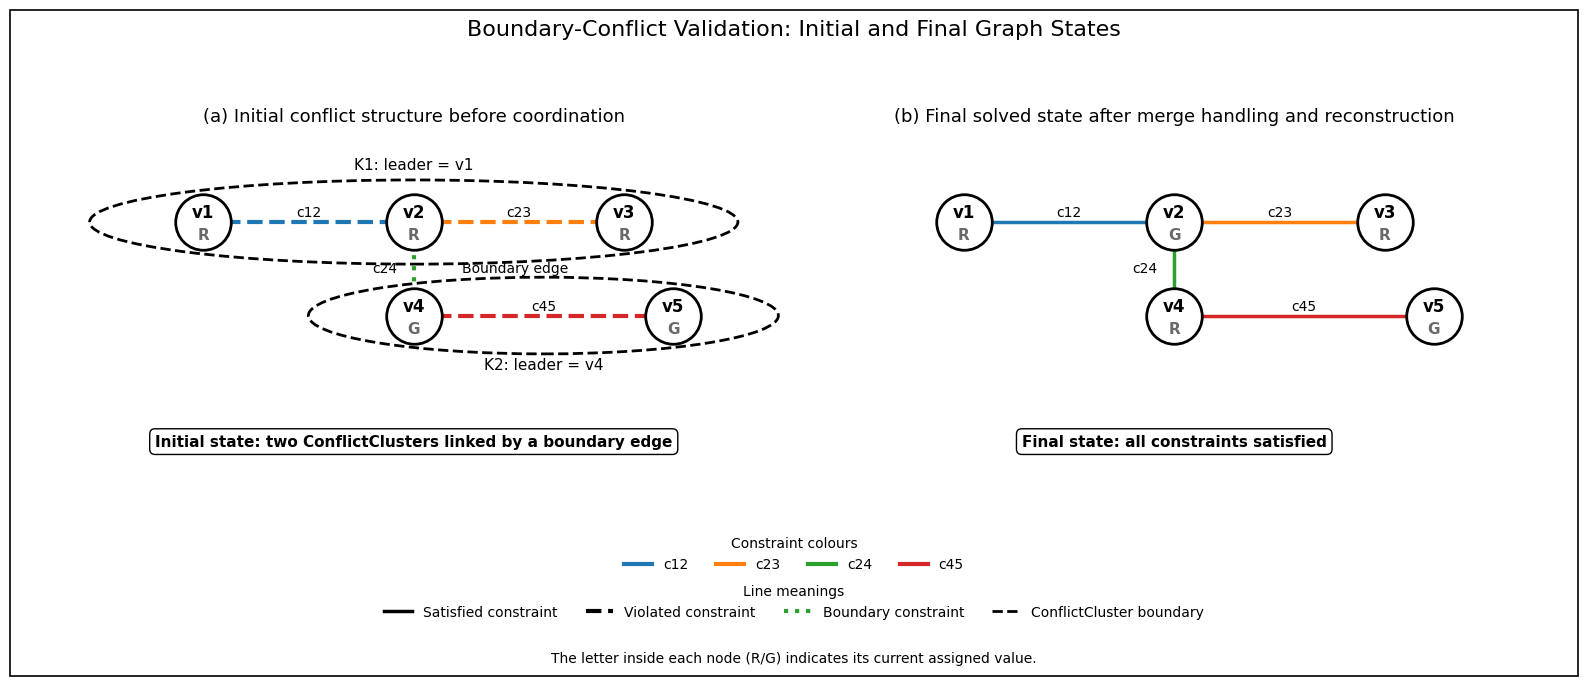

Saved: figures\stage3_initial_and_final_states_improved.png
Saved: figures\stage3_initial_and_final_states_improved.pdf


In [80]:
#Test 3 visualisation

fig, axes = plt.subplots(1, 2, figsize=(16, 6.8))

# Left panel: initial clustered state
draw_graph_state_panel(
    ax=axes[0],
    assignment=initial_assignment_3,
    panel_title="(a) Initial conflict structure before coordination",
    show_initial_clusters=True,
    note_text="Initial state: two ConflictClusters linked by a boundary edge"
)

# Right panel: final solved state
draw_graph_state_panel(
    ax=axes[1],
    assignment=result_3["assignment"],
    panel_title="(b) Final solved state after merge handling and reconstruction",
    show_initial_clusters=False,
    note_text="Final state: all constraints satisfied"
)

# -----------------------------------
# Legend 1: constraint colors
# -----------------------------------
constraint_color_legend = [
    Line2D([0], [0], color="tab:blue",   lw=3, label="c12"),
    Line2D([0], [0], color="tab:orange", lw=3, label="c23"),
    Line2D([0], [0], color="tab:green",  lw=3, label="c24"),
    Line2D([0], [0], color="tab:red",    lw=3, label="c45"),
]

fig.legend(
    handles=constraint_color_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.145),
    ncol=4,
    frameon=False,
    title="Constraint colours"
)

# -----------------------------------
# Legend 2: line meanings
# -----------------------------------
style_legend = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.5,
        linestyle="-",
        label="Satisfied constraint"
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=3,
        linestyle="--",
        label="Violated constraint"
    ),
    Line2D(
        [0], [0],
        color="tab:green",
        lw=3,
        linestyle=":",
        label="Boundary constraint"
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=2,
        linestyle="--",
        label="ConflictCluster boundary"
    ),
]

fig.legend(
    handles=style_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.075),
    ncol=4,
    frameon=False,
    title="Line meanings"
)

# -----------------------------------
# Node-value explanation
# -----------------------------------
fig.text(
    0.5,
    0.035,
    "The letter inside each node (R/G) indicates its current assigned value.",
    ha="center",
    va="center",
    fontsize=10
)

# -----------------------------------
# Main title
# -----------------------------------
fig.suptitle(
    "Boundary-Conflict Validation: Initial and Final Graph States",
    fontsize=16,
    y=0.975
)

# -----------------------------------
# Professional outer border
# -----------------------------------
border = Rectangle(
    (0.01, 0.01),
    0.98,
    0.98,
    transform=fig.transFigure,
    fill=False,
    edgecolor="black",
    linewidth=1.2
)

fig.add_artist(border)

# Leave enough room for three bottom rows
plt.tight_layout(rect=[0.02, 0.26, 0.98, 0.92])

combined_png = figures_dir / "stage3_initial_and_final_states_improved.png"
combined_pdf = figures_dir / "stage3_initial_and_final_states_improved.pdf"

plt.savefig(combined_png, dpi=300, bbox_inches="tight")
plt.savefig(combined_pdf, bbox_inches="tight")
plt.show()

print("Saved:", combined_png)
print("Saved:", combined_pdf)

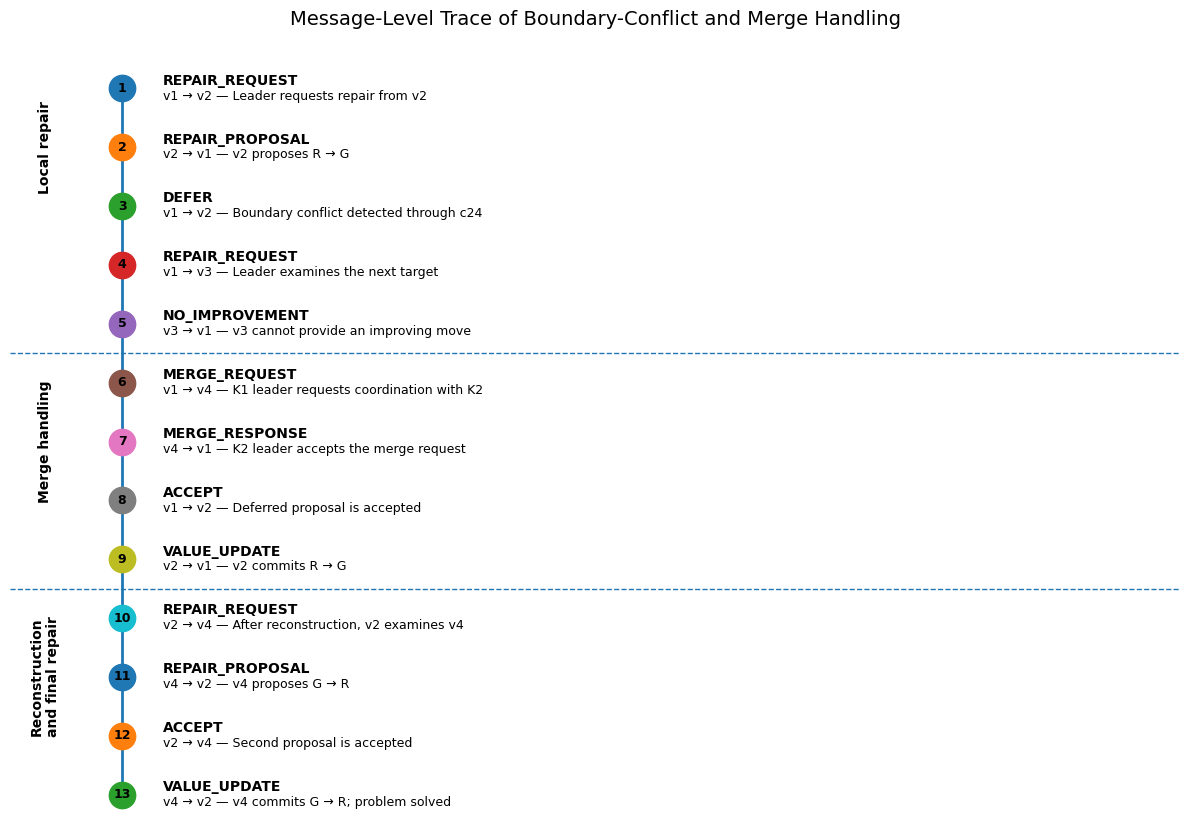

Saved: figures\stage3_coordination_timeline_improved.png
Saved: figures\stage3_coordination_timeline_improved.pdf


In [81]:
import matplotlib.pyplot as plt

timeline_steps = [
    ("REPAIR_REQUEST",  "v1 → v2", "Leader requests repair from v2"),
    ("REPAIR_PROPOSAL", "v2 → v1", "v2 proposes R → G"),
    ("DEFER",           "v1 → v2", "Boundary conflict detected through c24"),
    ("REPAIR_REQUEST",  "v1 → v3", "Leader examines the next target"),
    ("NO_IMPROVEMENT",  "v3 → v1", "v3 cannot provide an improving move"),
    ("MERGE_REQUEST",   "v1 → v4", "K1 leader requests coordination with K2"),
    ("MERGE_RESPONSE",  "v4 → v1", "K2 leader accepts the merge request"),
    ("ACCEPT",          "v1 → v2", "Deferred proposal is accepted"),
    ("VALUE_UPDATE",    "v2 → v1", "v2 commits R → G"),
    ("REPAIR_REQUEST",  "v2 → v4", "After reconstruction, v2 examines v4"),
    ("REPAIR_PROPOSAL", "v4 → v2", "v4 proposes G → R"),
    ("ACCEPT",          "v2 → v4", "Second proposal is accepted"),
    ("VALUE_UPDATE",    "v4 → v2", "v4 commits G → R; problem solved")
]

fig, ax = plt.subplots(figsize=(12, 8.5))

y_positions = list(range(len(timeline_steps), 0, -1))

# Draw timeline backbone
ax.plot(
    [0] * len(y_positions),
    y_positions,
    linewidth=2
)

for step_number, (message_type, route, effect), y in zip(
    range(1, len(timeline_steps) + 1),
    timeline_steps,
    y_positions
):
    ax.scatter(
        0,
        y,
        s=360,
        zorder=3
    )

    ax.text(
        0,
        y,
        str(step_number),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        0.33,
        y + 0.13,
        message_type,
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        0.33,
        y - 0.13,
        f"{route} — {effect}",
        ha="left",
        va="center",
        fontsize=9
    )

# Add phase labels
ax.text(
    -0.62,
    12.0,
    "Local repair",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    -0.62,
    7.0,
    "Merge handling",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    -0.62,
    3.0,
    "Reconstruction\nand final repair",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

# Phase separators
ax.axhline(8.5, linestyle="--", linewidth=1)
ax.axhline(4.5, linestyle="--", linewidth=1)

ax.set_title(
    "Message-Level Trace of Boundary-Conflict and Merge Handling",
    fontsize=14,
    pad=16
)

ax.set_xlim(-0.9, 8.5)
ax.set_ylim(0.4, len(timeline_steps) + 0.7)
ax.axis("off")

plt.tight_layout()

timeline_png = figures_dir / "stage3_coordination_timeline_improved.png"
timeline_pdf = figures_dir / "stage3_coordination_timeline_improved.pdf"

plt.savefig(timeline_png, dpi=300, bbox_inches="tight")
plt.savefig(timeline_pdf, bbox_inches="tight")
plt.show()

print("Saved:", timeline_png)
print("Saved:", timeline_pdf)

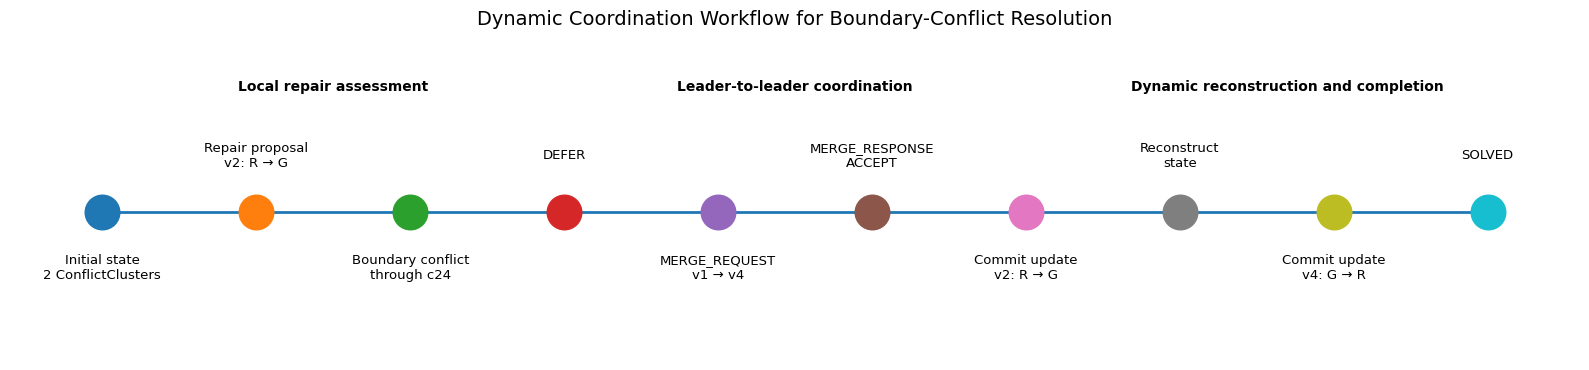

Saved: figures\stage3_coordination_workflow_improved.png
Saved: figures\stage3_coordination_workflow_improved.pdf


In [82]:
import matplotlib.pyplot as plt

workflow = [
    "Initial state\n2 ConflictClusters",
    "Repair proposal\nv2: R → G",
    "Boundary conflict\nthrough c24",
    "DEFER",
    "MERGE_REQUEST\nv1 → v4",
    "MERGE_RESPONSE\nACCEPT",
    "Commit update\nv2: R → G",
    "Reconstruct\nstate",
    "Commit update\nv4: G → R",
    "SOLVED"
]

fig, ax = plt.subplots(figsize=(16, 3.8))

x_positions = list(range(len(workflow)))

ax.plot(
    x_positions,
    [0] * len(workflow),
    linewidth=2
)

for index, (x, label) in enumerate(zip(x_positions, workflow)):
    ax.scatter(
        x,
        0,
        s=620,
        zorder=3
    )

    # Alternate labels above and below the timeline
    label_y = 0.34 if index % 2 else -0.34

    ax.text(
        x,
        label_y,
        label,
        ha="center",
        va="center",
        fontsize=9.5
    )

# Add broad process labels
ax.text(
    1.5,
    0.76,
    "Local repair assessment",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    4.5,
    0.76,
    "Leader-to-leader coordination",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    7.7,
    0.76,
    "Dynamic reconstruction and completion",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Dynamic Coordination Workflow for Boundary-Conflict Resolution",
    fontsize=14,
    pad=16
)

ax.set_xlim(-0.6, len(workflow) - 0.4)
ax.set_ylim(-0.9, 1.0)
ax.axis("off")

plt.tight_layout()

workflow_png = figures_dir / "stage3_coordination_workflow_improved.png"
workflow_pdf = figures_dir / "stage3_coordination_workflow_improved.pdf"

plt.savefig(workflow_png, dpi=300, bbox_inches="tight")
plt.savefig(workflow_pdf, bbox_inches="tight")
plt.show()

print("Saved:", workflow_png)
print("Saved:", workflow_pdf)

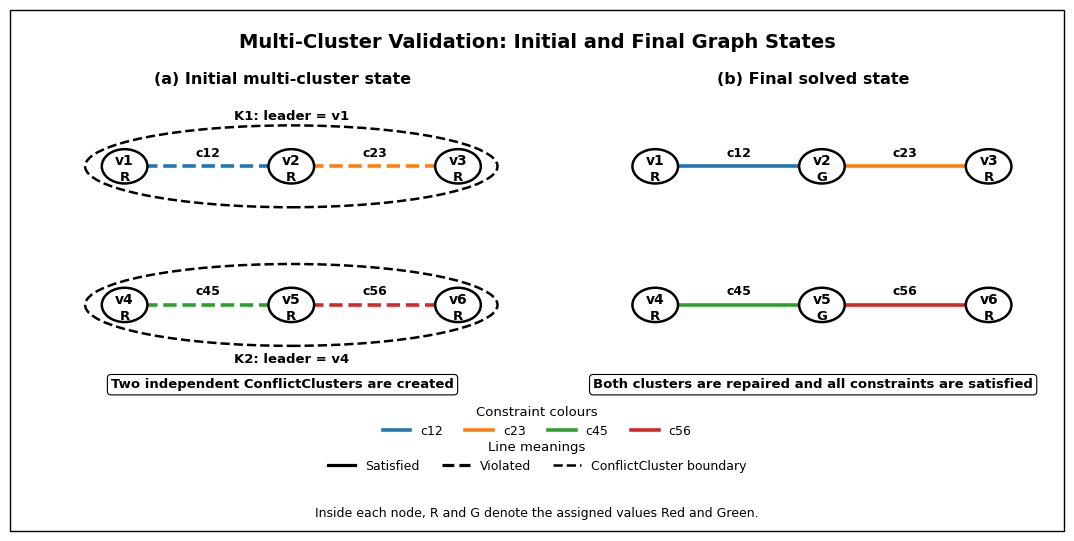

Saved: figures\problem2_initial_and_final_states.png
Saved: figures\problem2_initial_and_final_states.pdf


In [83]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Ellipse, Rectangle
from pathlib import Path

# ------------------------------------------------------------
# Folder for saving figures
# ------------------------------------------------------------
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Problem 2 graph positions
# ------------------------------------------------------------
positions_p2 = {
    "v1": (0.10, 1.50),
    "v2": (1.05, 1.50),
    "v3": (2.00, 1.50),
    "v4": (0.10, 0.45),
    "v5": (1.05, 0.45),
    "v6": (2.00, 0.45),
}

# Constraint colours
edge_colours_p2 = {
    "c12": "tab:blue",
    "c23": "tab:orange",
    "c45": "tab:green",
    "c56": "tab:red",
}

# Edges of problem 2
edges_p2 = [
    ("v1", "v2", "c12"),
    ("v2", "v3", "c23"),
    ("v4", "v5", "c45"),
    ("v5", "v6", "c56"),
]

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def is_violated(var1, var2, assignment):
    return assignment[var1] == assignment[var2]


# ------------------------------------------------------------
# Draw one panel
# ------------------------------------------------------------
def draw_problem2_panel(
    ax,
    assignment,
    panel_title,
    show_clusters=False,
    panel_note=""
):
    ax.set_xlim(-0.35, 2.35)
    ax.set_ylim(-0.15, 2.10)
    ax.axis("off")

    ax.set_title(panel_title, fontsize=11.5, fontweight="bold", pad=1)

    # Cluster boundaries only in initial state
    if show_clusters:
        k1 = Ellipse(
            xy=(1.05, 1.50),
            width=2.35,
            height=0.62,
            fill=False,
            edgecolor="black",
            linewidth=1.8,
            linestyle="--"
        )
        k2 = Ellipse(
            xy=(1.05, 0.45),
            width=2.35,
            height=0.62,
            fill=False,
            edgecolor="black",
            linewidth=1.8,
            linestyle="--"
        )
        ax.add_patch(k1)
        ax.add_patch(k2)

        ax.text(1.05, 1.88, "K1: leader = v1", ha="center", va="center",
                fontsize=9.5, fontweight="bold")
        ax.text(1.05, 0.04, "K2: leader = v4", ha="center", va="center",
                fontsize=9.5, fontweight="bold")

    # Draw edges
    for var1, var2, cname in edges_p2:
        x1, y1 = positions_p2[var1]
        x2, y2 = positions_p2[var2]

        colour = edge_colours_p2[cname]
        linestyle = "--" if is_violated(var1, var2, assignment) else "-"
        linewidth = 2.6

        ax.plot(
            [x1, x2], [y1, y2],
            color=colour,
            linestyle=linestyle,
            linewidth=linewidth,
            zorder=1
        )

        midx = (x1 + x2) / 2
        midy = (y1 + y2) / 2

        ax.text(
            midx, midy + 0.10, cname,
            fontsize=9, fontweight="bold",
            ha="center", va="center"
        )

    # Draw nodes
    for var, (x, y) in positions_p2.items():
        node = Circle(
            (x, y), radius=0.13,
            facecolor="white",
            edgecolor="black",
            linewidth=1.8,
            zorder=3
        )
        ax.add_patch(node)

        ax.text(x, y + 0.04, var,
                ha="center", va="center",
                fontsize=10, fontweight="bold", zorder=4)

        ax.text(x, y - 0.085, assignment[var],
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", zorder=4)

    # Panel note
    ax.text(
        0.5, 0.02, panel_note,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=9.5, fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        )
    )


# ------------------------------------------------------------
# Build initial assignment for problem 2
# ------------------------------------------------------------
# If you already have initial_assignment_2, keep it.
# Otherwise create it again using the same seed:
initial_assignment_2 = problem_2.random_initial_assignment(seed=15)

# final result already from solver:
# result_2["assignment"]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10.8, 5.4))

fig.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.84,
    bottom=0.29,
    wspace=0.12
)

draw_problem2_panel(
    ax=axes[0],
    assignment=initial_assignment_2,
    panel_title="(a) Initial multi-cluster state",
    show_clusters=True,
    panel_note="Two independent ConflictClusters are created"
)

draw_problem2_panel(
    ax=axes[1],
    assignment=result_2["assignment"],
    panel_title="(b) Final solved state",
    show_clusters=False,
    panel_note="Both clusters are repaired and all constraints are satisfied"
)

fig.suptitle(
    "Multi-Cluster Validation: Initial and Final Graph States",
    fontsize=14,
    fontweight="bold",
    y=0.94
)

# ------------------------------------------------------------
# Legend 1: constraint colours
# ------------------------------------------------------------
constraint_colour_legend = [
    Line2D([0], [0], color="tab:blue",   lw=2.6, label="c12"),
    Line2D([0], [0], color="tab:orange", lw=2.6, label="c23"),
    Line2D([0], [0], color="tab:green",  lw=2.6, label="c45"),
    Line2D([0], [0], color="tab:red",    lw=2.6, label="c56"),
]

fig.legend(
    handles=constraint_colour_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.17),
    ncol=4,
    frameon=False,
    fontsize=9,
    title="Constraint colours",
    title_fontsize=9.5,
    handlelength=2.2,
    columnspacing=1.8
)

# ------------------------------------------------------------
# Legend 2: line meanings
# ------------------------------------------------------------
line_meaning_legend = [
    Line2D([0], [0], color="black", lw=2.3, linestyle="-",  label="Satisfied"),
    Line2D([0], [0], color="black", lw=2.3, linestyle="--", label="Violated"),
    Line2D([0], [0], color="black", lw=1.8, linestyle="--", label="ConflictCluster boundary"),
]

fig.legend(
    handles=line_meaning_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.105),
    ncol=3,
    frameon=False,
    fontsize=9,
    title="Line meanings",
    title_fontsize=9.5,
    handlelength=2.2,
    columnspacing=1.8
)

# ------------------------------------------------------------
# Note for node values
# ------------------------------------------------------------
fig.text(
    0.5, 0.05,
    "Inside each node, R and G denote the assigned values Red and Green.",
    ha="center", va="center", fontsize=9
)

# ------------------------------------------------------------
# Outer border
# ------------------------------------------------------------
outer_border = Rectangle(
    (0.012, 0.018), 0.976, 0.965,
    transform=fig.transFigure,
    fill=False,
    edgecolor="black",
    linewidth=1.0
)
fig.add_artist(outer_border)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
png_path = figures_dir / "problem2_initial_and_final_states.png"
pdf_path = figures_dir / "problem2_initial_and_final_states.pdf"

fig.savefig(png_path, dpi=300, facecolor="white")
fig.savefig(pdf_path, facecolor="white")
plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

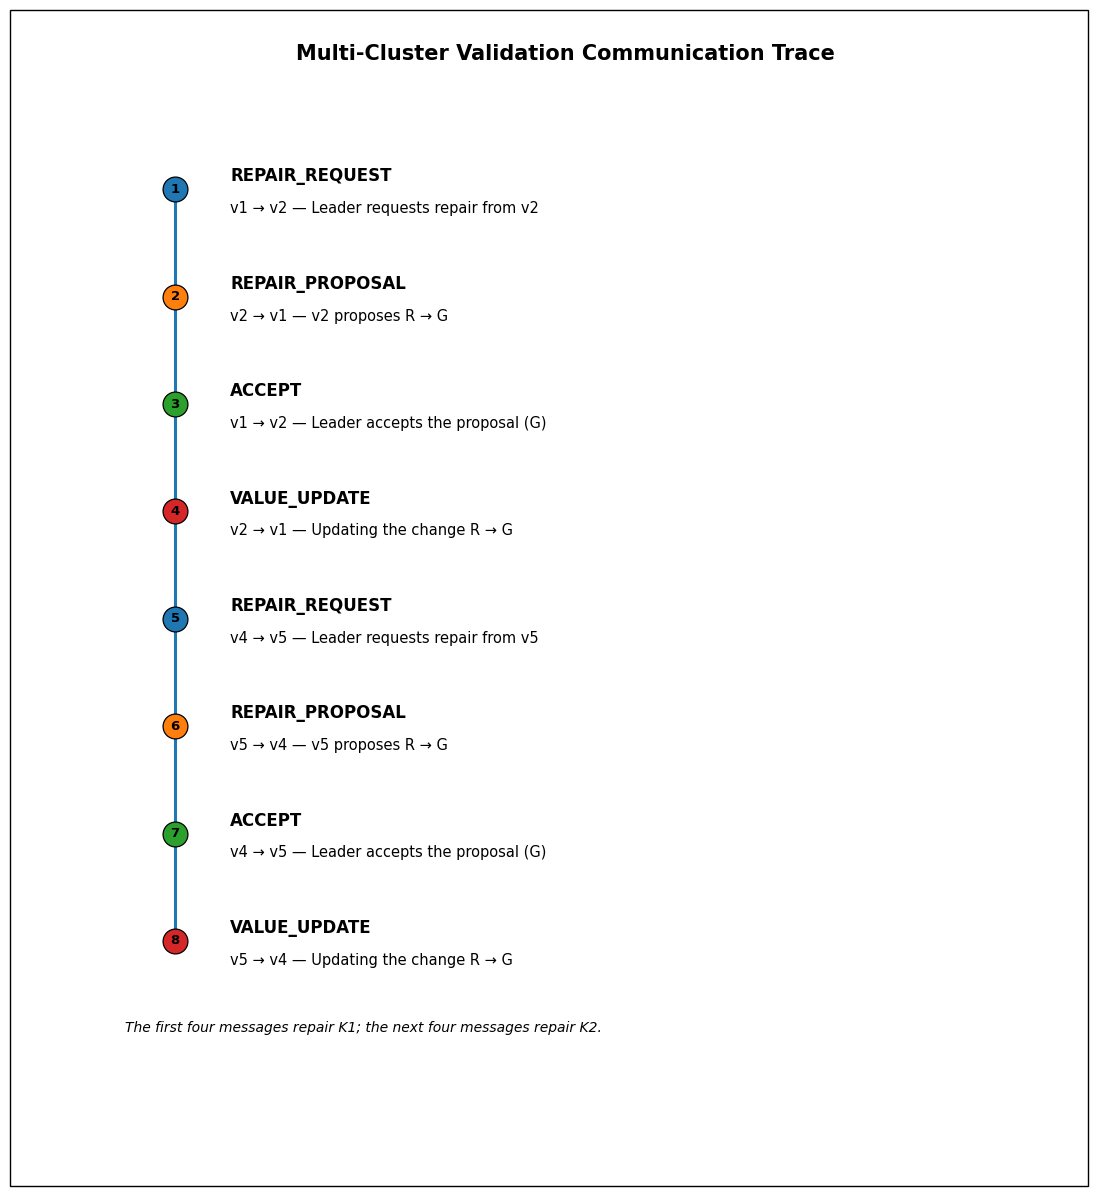

Saved: C:\dcop-research\figures\problem2_message_trace.png
Saved: C:\dcop-research\figures\problem2_message_trace.pdf


In [84]:
# ============================================================
# Problem 2: Improved communication-trace visualisation
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
import textwrap

# ------------------------------------------------------------
# Helper: format message description
# ------------------------------------------------------------
def format_trace_message(msg):
    """
    Convert a message object into a readable textual description.
    """
    msg_type = msg.message_type
    sender = msg.sender
    receiver = msg.receiver
    content = msg.content

    if msg_type == "REPAIR_REQUEST":
        return f"{sender} → {receiver} — Leader requests repair from {receiver}"

    elif msg_type == "REPAIR_PROPOSAL":
        old_v = content.get("current_value", "?")
        new_v = content.get("proposed_value", "?")
        return f"{sender} → {receiver} — {sender} proposes {old_v} → {new_v}"

    elif msg_type == "ACCEPT":
        accepted_value = content.get("accepted_value", "?")
        return f"{sender} → {receiver} — Leader accepts the proposal ({accepted_value})"

    elif msg_type == "VALUE_UPDATE":
        old_v = content.get("old_value", "?")
        new_v = content.get("new_value", "?")
        return f"{sender} → {receiver} — Updating the change {old_v} → {new_v}"

    elif msg_type == "NO_IMPROVEMENT":
        return f"{sender} → {receiver} — No improving move is available"

    elif msg_type == "DEFER":
        return f"{sender} → {receiver} — Proposal is deferred"

    elif msg_type == "MERGE_REQUEST":
        source_cluster = content.get("source_cluster", "?")
        target_cluster = content.get("target_cluster", "?")
        return (
            f"{sender} → {receiver} — Merge requested between "
            f"{source_cluster} and {target_cluster}"
        )

    elif msg_type == "MERGE_RESPONSE":
        response = content.get("response", "?")
        return f"{sender} → {receiver} — Merge response: {response}"

    else:
        return f"{sender} → {receiver} — {msg_type}"


# ------------------------------------------------------------
# Main function: draw trace figure
# ------------------------------------------------------------
def draw_problem2_message_trace(result, figures_dir="C:/dcop-research/figures"):
    """
    Draw a vertical communication trace for Problem 2.
    """

    messages = result["communication_log"].messages
    n = len(messages)

    # ----- dynamic figure height -----
    fig_height = max(7, 1.15 * n + 2.8)

    fig, ax = plt.subplots(figsize=(11, fig_height))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ----- axis range -----
    ax.set_xlim(0, 10)
    ax.set_ylim(0, n + 1.5)
    ax.invert_yaxis()
    ax.axis("off")

    # ----- title -----
    ax.set_title(
        "Multi-Cluster Validation Communication Trace",
        fontsize=15,
        fontweight="bold",
        pad=16
    )

    # ----- vertical trace line -----
    x_line = 1.1
    ax.plot([x_line, x_line], [1, n], linewidth=2.2)

    # ----- colors by message type -----
    color_map = {
        "REPAIR_REQUEST": "#1f77b4",
        "REPAIR_PROPOSAL": "#ff7f0e",
        "ACCEPT": "#2ca02c",
        "VALUE_UPDATE": "#d62728",
        "NO_IMPROVEMENT": "#9467bd",
        "DEFER": "#8c564b",
        "MERGE_REQUEST": "#e377c2",
        "MERGE_RESPONSE": "#7f7f7f"
    }

    # ----- draw each message -----
    for i, msg in enumerate(messages, start=1):
        y = i
        msg_type = msg.message_type
        color = color_map.get(msg_type, "black")

        # node on the timeline
        ax.scatter(
            x_line, y,
            s=320,
            color=color,
            edgecolors="black",
            linewidths=0.9,
            zorder=3
        )

        # message index inside node
        ax.text(
            x_line, y, str(i),
            ha="center", va="center",
            fontsize=9.5, fontweight="bold", color="black"
        )

        # message type
        ax.text(
            1.65, y - 0.12,
            msg_type,
            fontsize=12,
            fontweight="bold",
            va="center"
        )

        # message description
        desc = format_trace_message(msg)
        wrapped_desc = "\n".join(textwrap.wrap(desc, width=58))
        ax.text(
            1.65, y + 0.18,
            wrapped_desc,
            fontsize=10.5,
            va="center"
        )

    # ----- optional note under the trace -----
    ax.text(
        0.6, n + 0.85,
        "The first four messages repair K1; the next four messages repair K2.",
        fontsize=10,
        style="italic"
    )

    # ----- border around figure -----
    border = Rectangle(
        (0.01, 0.01), 0.98, 0.98,
        transform=fig.transFigure,
        fill=False,
        edgecolor="black",
        linewidth=1.0
    )
    fig.add_artist(border)

    # ----- save -----
    figures_dir = Path(figures_dir)
    figures_dir.mkdir(parents=True, exist_ok=True)

    trace_png = figures_dir / "problem2_message_trace.png"
    trace_pdf = figures_dir / "problem2_message_trace.pdf"

    fig.subplots_adjust(left=0.06, right=0.97, top=0.93, bottom=0.08)

    plt.savefig(trace_png, dpi=300, facecolor="white")
    plt.savefig(trace_pdf, facecolor="white")
    plt.show()

    print("Saved:", trace_png)
    print("Saved:", trace_pdf)


# ------------------------------------------------------------
# Run it for Problem 2
# ------------------------------------------------------------
draw_problem2_message_trace(result_2)

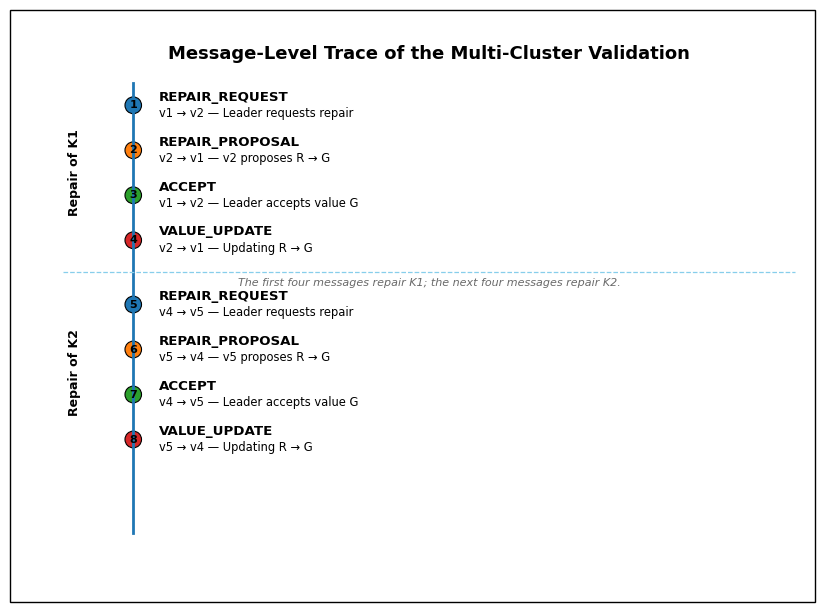

Saved: figures\problem2_message_trace_vertical_compact.png
Saved: figures\problem2_message_trace_vertical_compact.pdf


In [85]:
# ============================================================
# Run-All-safe guarded cell
# Problem 2 compact communication trace
# ============================================================
try:
    # ============================================================
    # Problem 2 — Compact vertical communication trace
    # Same style as Problem 3, but with separator after 4 messages
    # ============================================================

    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle, Rectangle
    from pathlib import Path

    # ------------------------------------------------------------
    # Folder to save figures
    # ------------------------------------------------------------
    figures_dir = Path("figures")
    figures_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # Read messages from the communication log
    # ------------------------------------------------------------
    messages = result_2["communication_log"].messages

    if len(messages) != 8:
        raise ValueError(f"Expected 8 messages for problem 2, but found {len(messages)}.")

    # ------------------------------------------------------------
    # Helper: short compact description for each message
    # ------------------------------------------------------------
    def short_message_description(message):
        msg_type = message.message_type
        sender = message.sender
        receiver = message.receiver
        content = message.content

        if msg_type == "REPAIR_REQUEST":
            return f"{sender} → {receiver} — Leader requests repair"

        elif msg_type == "REPAIR_PROPOSAL":
            old_value = content.get("current_value", "?")
            new_value = content.get("proposed_value", "?")
            return f"{sender} → {receiver} — {sender} proposes {old_value} → {new_value}"

        elif msg_type == "ACCEPT":
            accepted_value = content.get("accepted_value", "?")
            return f"{sender} → {receiver} — Leader accepts value {accepted_value}"

        elif msg_type == "VALUE_UPDATE":
            old_value = content.get("old_value", "?")
            new_value = content.get("new_value", "?")
            return f"{sender} → {receiver} — Updating {old_value} → {new_value}"

        else:
            return f"{sender} → {receiver} — {msg_type}"

    # ------------------------------------------------------------
    # Colour by message type
    # ------------------------------------------------------------
    message_colours = {
        "REPAIR_REQUEST": "tab:blue",
        "REPAIR_PROPOSAL": "tab:orange",
        "ACCEPT": "tab:green",
        "VALUE_UPDATE": "tab:red",
    }

    # ------------------------------------------------------------
    # Create a compact vertical figure
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8.3, 6.2))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")

    # Coordinate system
    ax.set_xlim(0, 12)
    ax.set_ylim(0.5, 8.7)

    # Main title
    ax.text(
        6.0, 8.45,
        "Message-Level Trace of the Multi-Cluster Validation",
        ha="center", va="center",
        fontsize=13, fontweight="bold"
    )

    # Vertical timeline line
    x_line = 1.35
    ax.plot([x_line, x_line], [1.0, 8.0], color="tab:blue", linewidth=2)

    # Y positions for the 8 messages (compact spacing)
    y_positions = [7.65, 6.95, 6.25, 5.55, 4.55, 3.85, 3.15, 2.45]

    # Dashed separator between first four and second four messages
    separator_y = 5.05
    ax.hlines(
        y=separator_y,
        xmin=0.25,
        xmax=11.75,
        colors="skyblue",
        linestyles="dashed",
        linewidth=0.9
    )

    # Stage labels on the left
    ax.text(
        0.42, 6.60,
        "Repair of K1",
        rotation=90,
        ha="center", va="center",
        fontsize=9, fontweight="bold"
    )

    ax.text(
        0.42, 3.50,
        "Repair of K2",
        rotation=90,
        ha="center", va="center",
        fontsize=9, fontweight="bold"
    )

    # Draw all messages
    for i, (message, y) in enumerate(zip(messages, y_positions), start=1):
        msg_type = message.message_type
        colour = message_colours.get(msg_type, "gray")

        # Numbered circle
        circle = Circle(
            (x_line, y),
            radius=0.13,
            facecolor=colour,
            edgecolor="black",
            linewidth=0.8
        )
        ax.add_patch(circle)

        ax.text(
            x_line, y, str(i),
            ha="center", va="center",
            fontsize=8, fontweight="bold"
        )

        # Message title
        ax.text(
            1.75, y + 0.13,
            msg_type,
            ha="left", va="center",
            fontsize=9.6, fontweight="bold"
        )

        # Message description
        ax.text(
            1.75, y - 0.12,
            short_message_description(message),
            ha="left", va="center",
            fontsize=8.3
        )

    # Small explanatory note under the separator
    ax.text(
        6.0, 4.88,
        "The first four messages repair K1; the next four messages repair K2.",
        ha="center", va="center",
        fontsize=8, style="italic", color="dimgray"
    )

    # Professional border
    border = Rectangle(
        (0.015, 0.02), 0.97, 0.955,
        transform=fig.transFigure,
        fill=False,
        edgecolor="black",
        linewidth=1.0
    )
    fig.add_artist(border)

    # Manual layout — avoids tight_layout warnings
    fig.subplots_adjust(
        left=0.06,
        right=0.98,
        top=0.93,
        bottom=0.08
    )

    # Save
    trace_png = figures_dir / "problem2_message_trace_vertical_compact.png"
    trace_pdf = figures_dir / "problem2_message_trace_vertical_compact.pdf"

    fig.savefig(
        trace_png,
        dpi=300,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.03
    )

    fig.savefig(
        trace_pdf,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.03
    )

    plt.show()

    print("Saved:", trace_png)
    print("Saved:", trace_pdf)
except Exception as error:
    print("Problem 2 compact communication trace skipped because of:", repr(error))


In [86]:
# ============================================================
# Reusable visualisation tools for Stage 4
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Ellipse, Rectangle
from pathlib import Path

# ------------------------------------------------------------
# Folder for saved figures
# ------------------------------------------------------------
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Helper: check whether an inequality constraint is violated
# ------------------------------------------------------------
def edge_is_violated(var1, var2, assignment):
    return assignment[var1] == assignment[var2]


# ------------------------------------------------------------
# Draw compact initial-versus-final graph states
# ------------------------------------------------------------
def draw_state_comparison(
    *,
    initial_assignment,
    final_assignment,
    positions,
    edges,
    initial_clusters,
    boundary_constraints,
    title,
    initial_note,
    final_note,
    filename
):
    """
    Create a compact side-by-side graph-state comparison.

    edges:
        list of tuples:
        (variable_1, variable_2, constraint_name, colour)

    initial_clusters:
        list of dictionaries with:
        centre, width, height, label, label_position
    """

    def draw_panel(
        ax,
        assignment,
        panel_title,
        show_clusters,
        panel_note
    ):
        ax.axis("off")

        xs = [position[0] for position in positions.values()]
        ys = [position[1] for position in positions.values()]

        ax.set_xlim(min(xs) - 0.50, max(xs) + 0.55)
        ax.set_ylim(min(ys) - 0.60, max(ys) + 0.65)

        ax.set_title(
            panel_title,
            fontsize=11.5,
            fontweight="bold",
            pad=4
        )

        # --------------------------------------------
        # Initial ConflictCluster boundaries
        # --------------------------------------------
        if show_clusters:
            for cluster in initial_clusters:
                ellipse = Ellipse(
                    xy=cluster["centre"],
                    width=cluster["width"],
                    height=cluster["height"],
                    fill=False,
                    edgecolor="black",
                    linewidth=1.8,
                    linestyle="--"
                )

                ax.add_patch(ellipse)

                ax.text(
                    cluster["label_position"][0],
                    cluster["label_position"][1],
                    cluster["label"],
                    ha="center",
                    va="center",
                    fontsize=9.4,
                    fontweight="bold"
                )

        # --------------------------------------------
        # Edges
        # --------------------------------------------
        for var1, var2, constraint_name, colour in edges:
            x1, y1 = positions[var1]
            x2, y2 = positions[var2]

            if (
                show_clusters
                and constraint_name in boundary_constraints
            ):
                linestyle = ":"
                linewidth = 2.7
            else:
                linestyle = (
                    "--"
                    if edge_is_violated(var1, var2, assignment)
                    else "-"
                )
                linewidth = 2.5

            ax.plot(
                [x1, x2],
                [y1, y2],
                color=colour,
                linestyle=linestyle,
                linewidth=linewidth,
                zorder=1
            )

            middle_x = (x1 + x2) / 2
            middle_y = (y1 + y2) / 2

            # Position vertical-edge labels slightly to the left
            if abs(x1 - x2) < 0.05:
                label_x = middle_x - 0.16
                label_y = middle_y
            else:
                label_x = middle_x
                label_y = middle_y + 0.11

            ax.text(
                label_x,
                label_y,
                constraint_name,
                fontsize=8.9,
                fontweight="bold",
                ha="center",
                va="center"
            )

        # --------------------------------------------
        # Nodes
        # --------------------------------------------
        for variable, (x, y) in positions.items():
            node = Circle(
                (x, y),
                radius=0.145,
                facecolor="white",
                edgecolor="black",
                linewidth=1.8,
                zorder=3
            )

            ax.add_patch(node)

            ax.text(
                x,
                y + 0.045,
                variable,
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                zorder=4
            )

            ax.text(
                x,
                y - 0.090,
                assignment[variable],
                ha="center",
                va="center",
                fontsize=9.3,
                fontweight="bold",
                zorder=4
            )

        # --------------------------------------------
        # Note box beneath each panel
        # --------------------------------------------
        ax.text(
            0.5,
            -0.04,
            panel_note,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=9.2,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.28",
                facecolor="white",
                edgecolor="black",
                linewidth=0.8
            )
        )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.2, 5.7)
    )

    fig.patch.set_facecolor("white")

    fig.subplots_adjust(
        left=0.045,
        right=0.975,
        top=0.83,
        bottom=0.30,
        wspace=0.11
    )

    draw_panel(
        ax=axes[0],
        assignment=initial_assignment,
        panel_title="(a) Initial conflict structure",
        show_clusters=True,
        panel_note=initial_note
    )

    draw_panel(
        ax=axes[1],
        assignment=final_assignment,
        panel_title="(b) Final solved state",
        show_clusters=False,
        panel_note=final_note
    )

    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=0.94
    )

    # --------------------------------------------
    # Constraint-colour legend
    # --------------------------------------------
    colour_legend_items = [
        Line2D(
            [0],
            [0],
            color=colour,
            linewidth=2.5,
            label=constraint_name
        )
        for _, _, constraint_name, colour in edges
    ]

    fig.legend(
        handles=colour_legend_items,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.178),
        ncol=min(len(colour_legend_items), 5),
        frameon=False,
        fontsize=8.8,
        title="Constraint colours",
        title_fontsize=9.3,
        handlelength=2.1,
        columnspacing=1.5
    )

    # --------------------------------------------
    # Line-style legend
    # --------------------------------------------
    style_legend_items = [
        Line2D(
            [0], [0],
            color="black",
            linewidth=2.3,
            linestyle="-",
            label="Satisfied"
        ),
        Line2D(
            [0], [0],
            color="black",
            linewidth=2.3,
            linestyle="--",
            label="Violated"
        ),
        Line2D(
            [0], [0],
            color="black",
            linewidth=2.5,
            linestyle=":",
            label="Boundary constraint"
        ),
        Line2D(
            [0], [0],
            color="black",
            linewidth=1.8,
            linestyle="--",
            label="ConflictCluster boundary"
        )
    ]

    fig.legend(
        handles=style_legend_items,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.105),
        ncol=4,
        frameon=False,
        fontsize=8.8,
        title="Line meanings",
        title_fontsize=9.3,
        handlelength=2.1,
        columnspacing=1.3
    )

    fig.text(
        0.5,
        0.048,
        "Inside each node, R and G denote the assigned values Red and Green.",
        ha="center",
        va="center",
        fontsize=8.9
    )

    # --------------------------------------------
    # Outer border
    # --------------------------------------------
    border = Rectangle(
        (0.012, 0.018),
        0.976,
        0.965,
        transform=fig.transFigure,
        fill=False,
        edgecolor="black",
        linewidth=1.0
    )

    fig.add_artist(border)

    # --------------------------------------------
    # Save
    # --------------------------------------------
    png_path = figures_dir / f"{filename}.png"
    pdf_path = figures_dir / f"{filename}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.03
    )

    fig.savefig(
        pdf_path,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.03
    )

    plt.show()

    print("Saved:", png_path)
    print("Saved:", pdf_path)


# ------------------------------------------------------------
# Convert one communication-log item into a compact event
# ------------------------------------------------------------
def message_to_event(message, phase):
    msg_type = message.message_type
    sender = message.sender
    receiver = message.receiver
    content = message.content

    if msg_type == "REPAIR_REQUEST":
        description = f"{sender} → {receiver} — Leader requests repair"

    elif msg_type == "REPAIR_PROPOSAL":
        old_value = content.get("current_value", "?")
        new_value = content.get("proposed_value", "?")
        move_type = content.get("move_type", "")

        if move_type:
            description = (
                f"{sender} → {receiver} — "
                f"{move_type}: {old_value} → {new_value}"
            )
        else:
            description = (
                f"{sender} → {receiver} — "
                f"Propose {old_value} → {new_value}"
            )

    elif msg_type == "ACCEPT":
        accepted_value = content.get("accepted_value", "?")
        description = (
            f"{sender} → {receiver} — "
            f"Accept value {accepted_value}"
        )

    elif msg_type == "VALUE_UPDATE":
        old_value = content.get("old_value", "?")
        new_value = content.get("new_value", "?")
        description = (
            f"{sender} → {receiver} — "
            f"Commit {old_value} → {new_value}"
        )

    elif msg_type == "NO_IMPROVEMENT":
        description = (
            f"{sender} → {receiver} — "
            "No acceptable improving move"
        )

    elif msg_type == "DEFER":
        description = (
            f"{sender} → {receiver} — "
            "Boundary-conflicting proposal deferred"
        )

    elif msg_type == "MERGE_REQUEST":
        description = (
            f"{sender} → {receiver} — "
            "Request inter-cluster coordination"
        )

    elif msg_type == "MERGE_RESPONSE":
        response = content.get("response", "?")
        description = (
            f"{sender} → {receiver} — "
            f"Merge response: {response}"
        )

    else:
        description = f"{sender} → {receiver}"

    return {
        "type": msg_type,
        "description": description,
        "phase": phase
    }


# ------------------------------------------------------------
# Draw compact vertical trace
# ------------------------------------------------------------
def draw_vertical_trace(
    *,
    events,
    title,
    note,
    filename
):
    """
    Draw a compact vertical event trace with dashed phase separators.
    """

    event_colours = {
        "REPAIR_REQUEST": "tab:blue",
        "REPAIR_PROPOSAL": "tab:orange",
        "NO_IMPROVEMENT": "tab:purple",
        "STAGNATION_THRESHOLD": "tab:brown",
        "DEFER": "tab:green",
        "MERGE_REQUEST": "tab:red",
        "MERGE_RESPONSE": "tab:pink",
        "ACCEPT": "tab:gray",
        "VALUE_UPDATE": "tab:olive",
        "LOCAL_RESTART": "tab:cyan"
    }

    n = len(events)

    # Compact dynamic height: minimal wasted vertical space
    figure_height = max(5.0, 0.43 * n + 1.7)

    fig, ax = plt.subplots(
        figsize=(8.1, figure_height)
    )

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")

    ax.set_xlim(0, 11.5)
    ax.set_ylim(0.35, n + 1.0)

    x_line = 1.20

    # Vertical guide line
    ax.plot(
        [x_line, x_line],
        [0.85, n + 0.30],
        color="tab:blue",
        linewidth=1.7
    )

    # Events run from top to bottom
    y_positions = list(range(n, 0, -1))

    # --------------------------------------------
    # Phase boundaries
    # --------------------------------------------
    previous_phase = events[0]["phase"]
    phase_start_y = y_positions[0]

    phase_ranges = []

    for index in range(1, n):
        current_phase = events[index]["phase"]

        if current_phase != previous_phase:
            separator_y = (
                y_positions[index - 1]
                + y_positions[index]
            ) / 2

            ax.hlines(
                separator_y,
                xmin=0.15,
                xmax=11.25,
                colors="skyblue",
                linestyles="dashed",
                linewidth=0.9
            )

            phase_ranges.append(
                (
                    previous_phase,
                    phase_start_y,
                    y_positions[index - 1]
                )
            )

            previous_phase = current_phase
            phase_start_y = y_positions[index]

    phase_ranges.append(
        (
            previous_phase,
            phase_start_y,
            y_positions[-1]
        )
    )

    # --------------------------------------------
    # Rotated phase labels
    # --------------------------------------------
    for phase_name, top_y, bottom_y in phase_ranges:
        centre_y = (top_y + bottom_y) / 2

        ax.text(
            0.34,
            centre_y,
            phase_name,
            rotation=90,
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold"
        )

    # --------------------------------------------
    # Event markers and descriptions
    # --------------------------------------------
    for step_number, (event, y) in enumerate(
        zip(events, y_positions),
        start=1
    ):
        event_type = event["type"]
        colour = event_colours.get(
            event_type,
            "lightgray"
        )

        marker = Circle(
            (x_line, y),
            radius=0.13,
            facecolor=colour,
            edgecolor="black",
            linewidth=0.75,
            zorder=3
        )

        ax.add_patch(marker)

        ax.text(
            x_line,
            y,
            str(step_number),
            ha="center",
            va="center",
            fontsize=7.7,
            fontweight="bold",
            zorder=4
        )

        ax.text(
            1.58,
            y + 0.13,
            event_type,
            ha="left",
            va="center",
            fontsize=8.9,
            fontweight="bold"
        )

        ax.text(
            1.58,
            y - 0.13,
            event["description"],
            ha="left",
            va="center",
            fontsize=7.9
        )

    # --------------------------------------------
    # Title and explanatory note
    # --------------------------------------------
    ax.text(
        5.75,
        n + 0.70,
        title,
        ha="center",
        va="center",
        fontsize=12.5,
        fontweight="bold"
    )

    ax.text(
        5.75,
        0.48,
        note,
        ha="center",
        va="center",
        fontsize=8.6,
        style="italic"
    )

    # --------------------------------------------
    # Outer border
    # --------------------------------------------
    border = Rectangle(
        (0.015, 0.02),
        0.97,
        0.955,
        transform=fig.transFigure,
        fill=False,
        edgecolor="black",
        linewidth=1.0
    )

    fig.add_artist(border)

    fig.subplots_adjust(
        left=0.05,
        right=0.98,
        top=0.96,
        bottom=0.05
    )

    # --------------------------------------------
    # Save
    # --------------------------------------------
    png_path = figures_dir / f"{filename}.png"
    pdf_path = figures_dir / f"{filename}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.03
    )

    fig.savefig(
        pdf_path,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.03
    )

    plt.show()

    print("Saved:", png_path)
    print("Saved:", pdf_path)

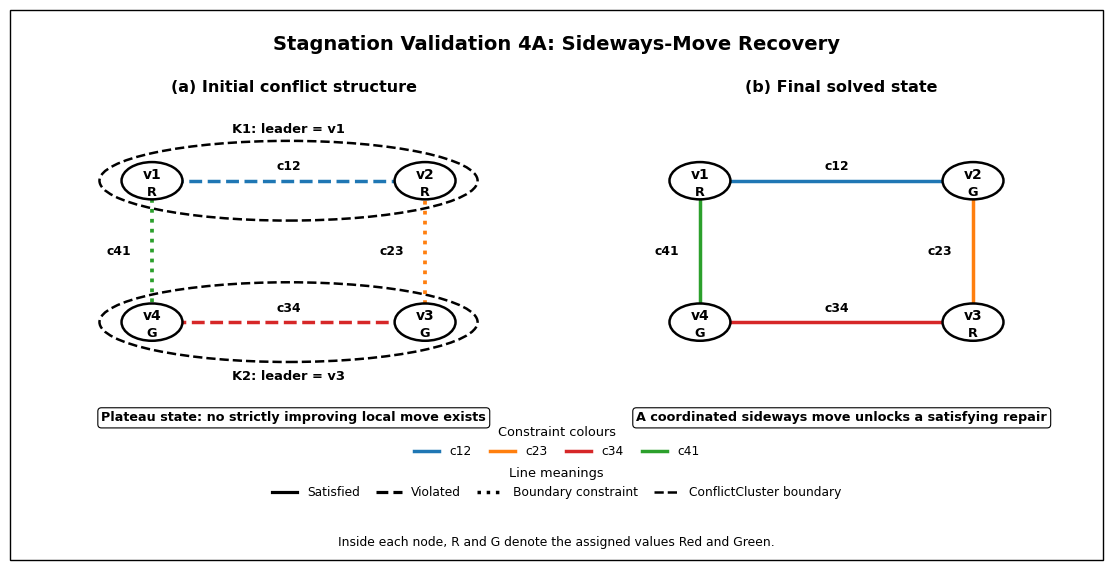

Saved: figures\stage4_testA_sideways_initial_and_final_states.png
Saved: figures\stage4_testA_sideways_initial_and_final_states.pdf


In [87]:
# ============================================================
# Stage 4 — Test A graph states:
# Plateau escaped through a sideways move
# ============================================================

positions_4 = {
    "v1": (0.35, 1.55),
    "v2": (1.65, 1.55),
    "v3": (1.65, 0.45),
    "v4": (0.35, 0.45)
}

edges_4 = [
    ("v1", "v2", "c12", "tab:blue"),
    ("v2", "v3", "c23", "tab:orange"),
    ("v3", "v4", "c34", "tab:red"),
    ("v4", "v1", "c41", "tab:green")
]

clusters_4 = [
    {
        "centre": (1.00, 1.55),
        "width": 1.80,
        "height": 0.62,
        "label": "K1: leader = v1",
        "label_position": (1.00, 1.95)
    },
    {
        "centre": (1.00, 0.45),
        "width": 1.80,
        "height": 0.62,
        "label": "K2: leader = v3",
        "label_position": (1.00, 0.03)
    }
]

draw_state_comparison(
    initial_assignment=initial_assignment_4,
    final_assignment=result_4["assignment"],
    positions=positions_4,
    edges=edges_4,
    initial_clusters=clusters_4,
    boundary_constraints={"c23", "c41"},
    title="Stagnation Validation 4A: Sideways-Move Recovery",
    initial_note="Plateau state: no strictly improving local move exists",
    final_note="A coordinated sideways move unlocks a satisfying repair",
    filename="stage4_testA_sideways_initial_and_final_states"
)

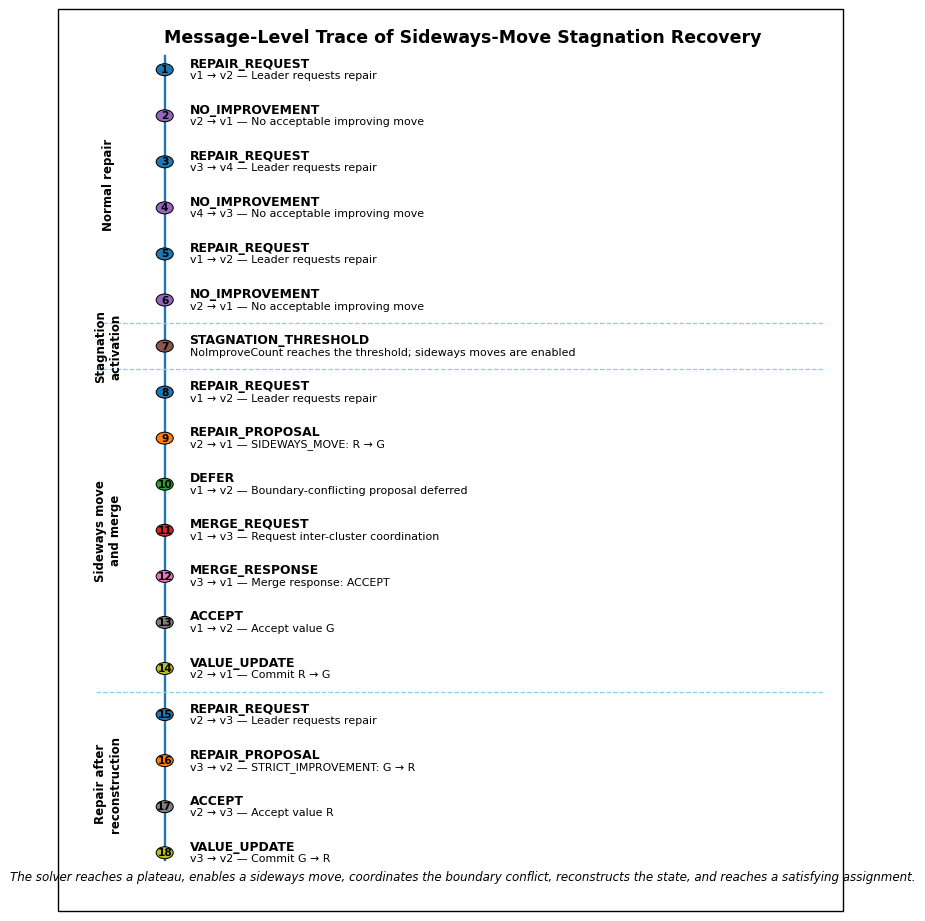

Saved: figures\stage4_testA_sideways_message_trace.png
Saved: figures\stage4_testA_sideways_message_trace.pdf


In [88]:
# ============================================================
# Stage 4 — Test A trace:
# Sideways move, defer, merge, reconstruction, and solution
# ============================================================

messages_4 = result_4["communication_log"].messages

events_4 = []

threshold_inserted = False
sideways_committed = False

for message in messages_4:

    stagnation_mode = (
        message.content.get("stagnation_mode", False)
        if isinstance(message.content, dict)
        else False
    )

    # Insert threshold event before the first stagnation-mode request
    if stagnation_mode and not threshold_inserted:
        events_4.append(
            {
                "type": "STAGNATION_THRESHOLD",
                "description":
                    "NoImproveCount reaches the threshold; "
                    "sideways moves are enabled",
                "phase": "Stagnation\nactivation"
            }
        )

        threshold_inserted = True

    if not threshold_inserted:
        phase = "Normal repair"

    elif not sideways_committed:
        phase = "Sideways move\nand merge"

    else:
        phase = "Repair after\nreconstruction"

    event = message_to_event(
        message,
        phase
    )

    events_4.append(event)

    if (
        message.message_type == "VALUE_UPDATE"
        and threshold_inserted
        and not sideways_committed
    ):
        sideways_committed = True

draw_vertical_trace(
    events=events_4,
    title="Message-Level Trace of Sideways-Move Stagnation Recovery",
    note=(
        "The solver reaches a plateau, enables a sideways move, "
        "coordinates the boundary conflict, reconstructs the state, "
        "and reaches a satisfying assignment."
    ),
    filename="stage4_testA_sideways_message_trace"
)

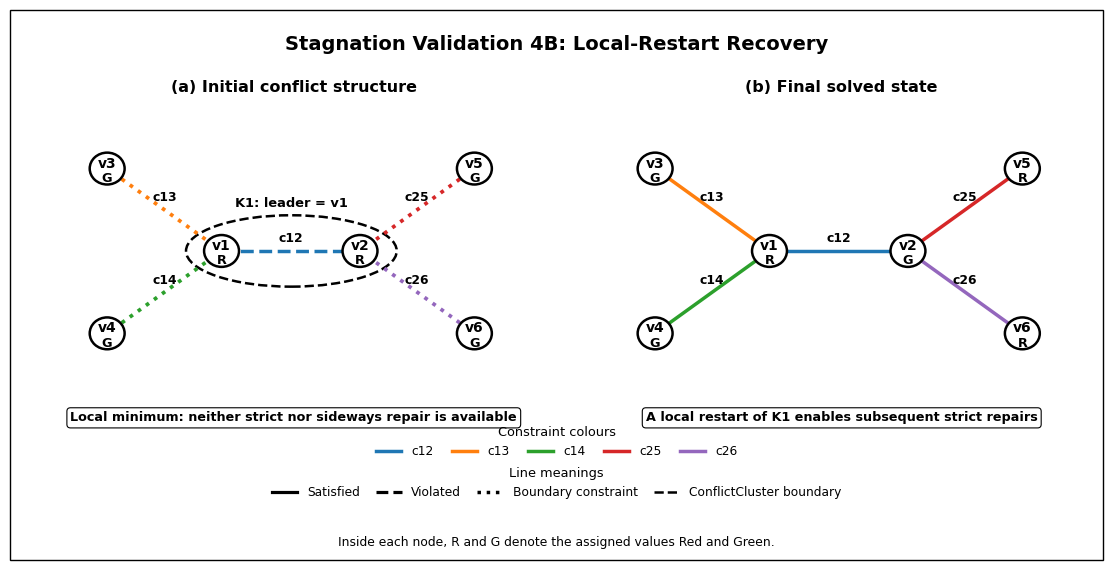

Saved: figures\stage4_testB_restart_initial_and_final_states.png
Saved: figures\stage4_testB_restart_initial_and_final_states.pdf


In [89]:
# ============================================================
# Stage 4 — Test B graph states:
# Plateau escaped through local restart
# ============================================================

positions_5 = {
    "v1": (1.10, 1.30),
    "v2": (2.25, 1.30),
    "v3": (0.15, 2.05),
    "v4": (0.15, 0.55),
    "v5": (3.20, 2.05),
    "v6": (3.20, 0.55)
}

edges_5 = [
    ("v1", "v2", "c12", "tab:blue"),
    ("v1", "v3", "c13", "tab:orange"),
    ("v1", "v4", "c14", "tab:green"),
    ("v2", "v5", "c25", "tab:red"),
    ("v2", "v6", "c26", "tab:purple")
]

clusters_5 = [
    {
        "centre": (1.68, 1.30),
        "width": 1.75,
        "height": 0.65,
        "label": "K1: leader = v1",
        "label_position": (1.68, 1.73)
    }
]

draw_state_comparison(
    initial_assignment=initial_assignment_5,
    final_assignment=result_5_full["assignment"],
    positions=positions_5,
    edges=edges_5,
    initial_clusters=clusters_5,
    boundary_constraints={"c13", "c14", "c25", "c26"},
    title="Stagnation Validation 4B: Local-Restart Recovery",
    initial_note="Local minimum: neither strict nor sideways repair is available",
    final_note="A local restart of K1 enables subsequent strict repairs",
    filename="stage4_testB_restart_initial_and_final_states"
)

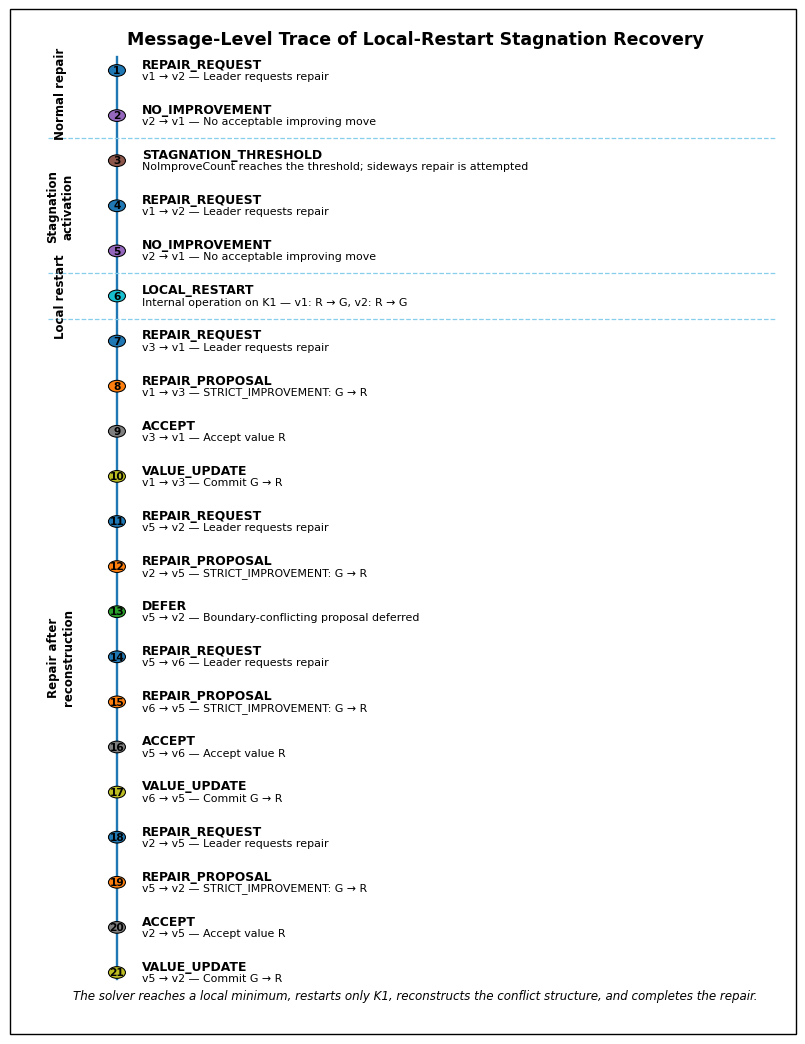

Saved: figures\stage4_testB_restart_message_trace.png
Saved: figures\stage4_testB_restart_message_trace.pdf


In [90]:
# ============================================================
# Stage 4 — Test B trace:
# Threshold, local restart, reconstruction, and final solution
# ============================================================

messages_5 = result_5_full["communication_log"].messages

restart_event = result_5_full["local_restart_events"][0]
restart_details = restart_event["result"]

changed_variables = restart_details["changed_variables"]

changed_text = ", ".join(
    f"{variable}: "
    f"{change['old_value']} → {change['new_value']}"
    for variable, change in changed_variables.items()
)

events_5 = []

threshold_inserted = False
restart_inserted = False

for message in messages_5:

    stagnation_mode = (
        message.content.get("stagnation_mode", False)
        if isinstance(message.content, dict)
        else False
    )

    # Insert threshold event before the first stagnation-mode request
    if stagnation_mode and not threshold_inserted:
        events_5.append(
            {
                "type": "STAGNATION_THRESHOLD",
                "description":
                    "NoImproveCount reaches the threshold; "
                    "sideways repair is attempted",
                "phase": "Stagnation\nactivation"
            }
        )

        threshold_inserted = True

    if not restart_inserted:
        phase = (
            "Normal repair"
            if not threshold_inserted
            else "Stagnation\nactivation"
        )
    else:
        phase = "Repair after\nreconstruction"

    events_5.append(
        message_to_event(
            message,
            phase
        )
    )

    # In this controlled test, the first stagnation-mode
    # NO_IMPROVEMENT triggers the internal local restart.
    if (
        threshold_inserted
        and not restart_inserted
        and message.message_type == "NO_IMPROVEMENT"
    ):
        events_5.append(
            {
                "type": "LOCAL_RESTART",
                "description":
                    f"Internal operation on K1 — {changed_text}",
                "phase": "Local restart"
            }
        )

        restart_inserted = True

draw_vertical_trace(
    events=events_5,
    title="Message-Level Trace of Local-Restart Stagnation Recovery",
    note=(
        "The solver reaches a local minimum, restarts only K1, "
        "reconstructs the conflict structure, and completes the repair."
    ),
    filename="stage4_testB_restart_message_trace"
)

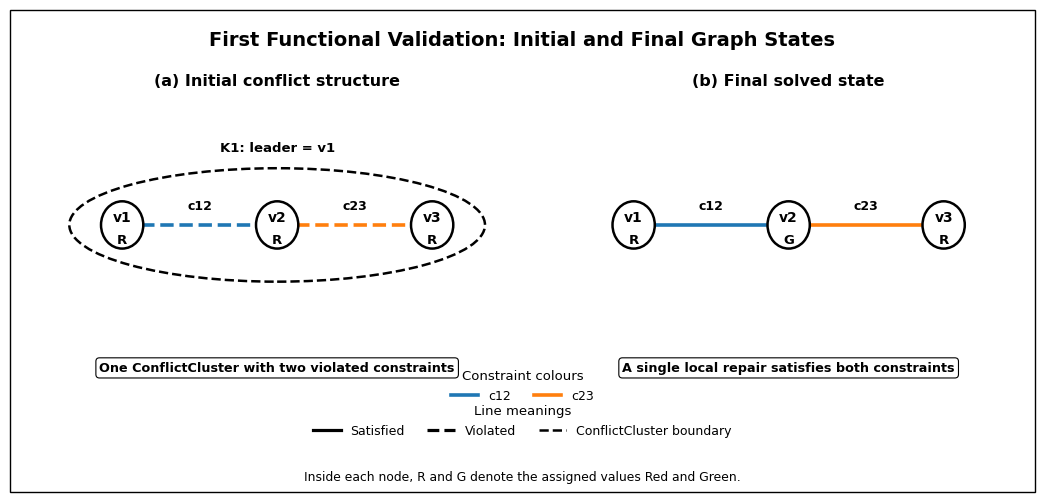

Saved: figures\test1_initial_and_final_graph_states.png
Saved: figures\test1_initial_and_final_graph_states.pdf


In [91]:
# ============================================================
# First functional validation:
# Initial and final graph states for a single local repair
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Ellipse, Rectangle
from pathlib import Path

# ------------------------------------------------------------
# Folder for saved figures
# ------------------------------------------------------------
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Exact graph-colouring instance used in Test 1
# ------------------------------------------------------------
initial_assignment_test1 = {
    "v1": "R",
    "v2": "R",
    "v3": "R"
}

final_assignment_test1 = {
    "v1": "R",
    "v2": "G",
    "v3": "R"
}

positions_test1 = {
    "v1": (0.25, 1.00),
    "v2": (1.35, 1.00),
    "v3": (2.45, 1.00)
}

edges_test1 = [
    ("v1", "v2", "c12", "tab:blue"),
    ("v2", "v3", "c23", "tab:orange")
]


# ------------------------------------------------------------
# Helper: identify violated inequality constraints
# ------------------------------------------------------------
def test1_edge_is_violated(var1, var2, assignment):
    return assignment[var1] == assignment[var2]


# ------------------------------------------------------------
# Helper: draw one graph-state panel
# ------------------------------------------------------------
def draw_test1_graph_panel(
    ax,
    assignment,
    panel_title,
    show_cluster=False,
    panel_note=""
):
    ax.axis("off")
    ax.set_xlim(-0.30, 3.00)
    ax.set_ylim(0.20, 1.85)

    ax.set_title(
        panel_title,
        fontsize=11.5,
        fontweight="bold",
        pad=4
    )

    # --------------------------------------------------------
    # Initial ConflictCluster boundary
    # --------------------------------------------------------
    if show_cluster:
        cluster_boundary = Ellipse(
            xy=(1.35, 1.00),
            width=2.95,
            height=0.72,
            fill=False,
            edgecolor="black",
            linewidth=1.8,
            linestyle="--"
        )

        ax.add_patch(cluster_boundary)

        ax.text(
            1.35,
            1.49,
            "K1: leader = v1",
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold"
        )

    # --------------------------------------------------------
    # Draw constraints
    # --------------------------------------------------------
    for var1, var2, constraint_name, colour in edges_test1:
        x1, y1 = positions_test1[var1]
        x2, y2 = positions_test1[var2]

        linestyle = (
            "--"
            if test1_edge_is_violated(var1, var2, assignment)
            else "-"
        )

        ax.plot(
            [x1, x2],
            [y1, y2],
            color=colour,
            linestyle=linestyle,
            linewidth=2.6,
            zorder=1
        )

        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.12,
            constraint_name,
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

    # --------------------------------------------------------
    # Draw variables and assigned values
    # --------------------------------------------------------
    for variable, (x, y) in positions_test1.items():
        node = Circle(
            (x, y),
            radius=0.15,
            facecolor="white",
            edgecolor="black",
            linewidth=1.8,
            zorder=3
        )

        ax.add_patch(node)

        ax.text(
            x,
            y + 0.045,
            variable,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            zorder=4
        )

        ax.text(
            x,
            y - 0.095,
            assignment[variable],
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            zorder=4
        )

    # --------------------------------------------------------
    # Short note beneath each panel
    # --------------------------------------------------------
    ax.text(
        0.5,
        -0.04,
        panel_note,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9.2,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        )
    )


# ============================================================
# Create compact side-by-side figure
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 5.0)
)

fig.patch.set_facecolor("white")

fig.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.82,
    bottom=0.30,
    wspace=0.10
)

draw_test1_graph_panel(
    ax=axes[0],
    assignment=initial_assignment_test1,
    panel_title="(a) Initial conflict structure",
    show_cluster=True,
    panel_note="One ConflictCluster with two violated constraints"
)

draw_test1_graph_panel(
    ax=axes[1],
    assignment=final_assignment_test1,
    panel_title="(b) Final solved state",
    show_cluster=False,
    panel_note="A single local repair satisfies both constraints"
)

# ------------------------------------------------------------
# Main figure title
# ------------------------------------------------------------
fig.suptitle(
    "First Functional Validation: Initial and Final Graph States",
    fontsize=14,
    fontweight="bold",
    y=0.94
)

# ------------------------------------------------------------
# Legend row 1: constraint colours
# ------------------------------------------------------------
constraint_colour_legend = [
    Line2D(
        [0], [0],
        color="tab:blue",
        linewidth=2.6,
        label="c12"
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linewidth=2.6,
        label="c23"
    )
]

fig.legend(
    handles=constraint_colour_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.175),
    ncol=2,
    frameon=False,
    fontsize=9,
    title="Constraint colours",
    title_fontsize=9.5,
    handlelength=2.2,
    columnspacing=1.8
)

# ------------------------------------------------------------
# Legend row 2: line meanings
# ------------------------------------------------------------
line_meaning_legend = [
    Line2D(
        [0], [0],
        color="black",
        linewidth=2.3,
        linestyle="-",
        label="Satisfied"
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=2.3,
        linestyle="--",
        label="Violated"
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=1.8,
        linestyle="--",
        label="ConflictCluster boundary"
    )
]

fig.legend(
    handles=line_meaning_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.105),
    ncol=3,
    frameon=False,
    fontsize=9,
    title="Line meanings",
    title_fontsize=9.5,
    handlelength=2.2,
    columnspacing=1.8
)

# ------------------------------------------------------------
# Explanation of node values
# ------------------------------------------------------------
fig.text(
    0.5,
    0.048,
    "Inside each node, R and G denote the assigned values Red and Green.",
    ha="center",
    va="center",
    fontsize=8.9
)

# ------------------------------------------------------------
# Professional outer border
# ------------------------------------------------------------
outer_border = Rectangle(
    (0.012, 0.018),
    0.976,
    0.965,
    transform=fig.transFigure,
    fill=False,
    edgecolor="black",
    linewidth=1.0
)

fig.add_artist(outer_border)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
graph_png = figures_dir / "test1_initial_and_final_graph_states.png"
graph_pdf = figures_dir / "test1_initial_and_final_graph_states.pdf"

fig.savefig(
    graph_png,
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.03
)

fig.savefig(
    graph_pdf,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.show()

print("Saved:", graph_png)
print("Saved:", graph_pdf)

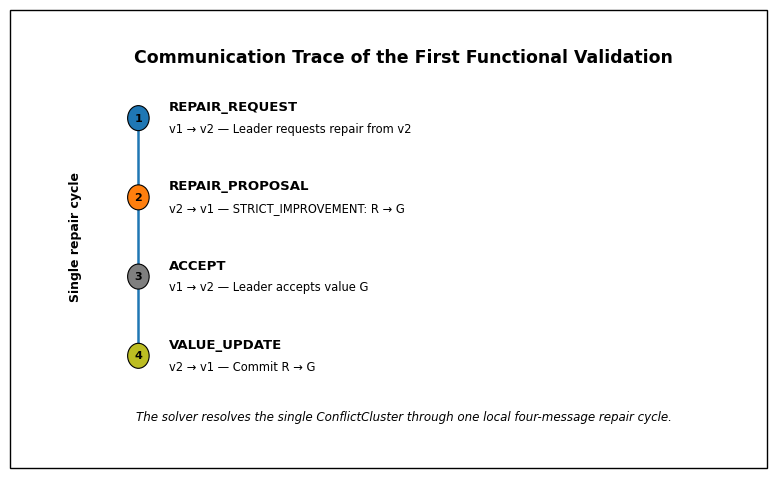

Saved: figures\test1_communication_trace.png
Saved: figures\test1_communication_trace.pdf


In [92]:
# ============================================================
# First functional validation:
# Compact vertical communication trace
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from pathlib import Path

# ------------------------------------------------------------
# Folder for saved figures
# ------------------------------------------------------------
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Exact trace from the first validation output
# ------------------------------------------------------------
events_test1 = [
    {
        "type": "REPAIR_REQUEST",
        "description": "v1 → v2 — Leader requests repair from v2"
    },
    {
        "type": "REPAIR_PROPOSAL",
        "description": "v2 → v1 — STRICT_IMPROVEMENT: R → G"
    },
    {
        "type": "ACCEPT",
        "description": "v1 → v2 — Leader accepts value G"
    },
    {
        "type": "VALUE_UPDATE",
        "description": "v2 → v1 — Commit R → G"
    }
]

event_colours_test1 = {
    "REPAIR_REQUEST": "tab:blue",
    "REPAIR_PROPOSAL": "tab:orange",
    "ACCEPT": "tab:gray",
    "VALUE_UPDATE": "tab:olive"
}

# ------------------------------------------------------------
# Compact figure
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(7.8, 4.8)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

ax.set_xlim(0, 10)
ax.set_ylim(0.20, 5.15)

x_line = 1.30
y_positions = [4.05, 3.10, 2.15, 1.20]

# ------------------------------------------------------------
# Vertical guide line
# ------------------------------------------------------------
ax.plot(
    [x_line, x_line],
    [1.20, 4.05],
    color="tab:blue",
    linewidth=1.8
)

# ------------------------------------------------------------
# Phase label
# ------------------------------------------------------------
ax.text(
    0.42,
    2.63,
    "Single repair cycle",
    rotation=90,
    ha="center",
    va="center",
    fontsize=9,
    fontweight="bold"
)

# ------------------------------------------------------------
# Events
# ------------------------------------------------------------
for step_number, (event, y) in enumerate(
    zip(events_test1, y_positions),
    start=1
):
    event_type = event["type"]
    colour = event_colours_test1[event_type]

    marker = Circle(
        (x_line, y),
        radius=0.15,
        facecolor=colour,
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    ax.add_patch(marker)

    ax.text(
        x_line,
        y,
        str(step_number),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        zorder=4
    )

    ax.text(
        1.72,
        y + 0.13,
        event_type,
        ha="left",
        va="center",
        fontsize=9.5,
        fontweight="bold"
    )

    ax.text(
        1.72,
        y - 0.13,
        event["description"],
        ha="left",
        va="center",
        fontsize=8.3
    )

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------
ax.text(
    5.0,
    4.78,
    "Communication Trace of the First Functional Validation",
    ha="center",
    va="center",
    fontsize=12.5,
    fontweight="bold"
)

# ------------------------------------------------------------
# Explanatory note
# ------------------------------------------------------------
ax.text(
    5.0,
    0.47,
    (
        "The solver resolves the single ConflictCluster through "
        "one local four-message repair cycle."
    ),
    ha="center",
    va="center",
    fontsize=8.6,
    style="italic"
)

# ------------------------------------------------------------
# Professional outer border
# ------------------------------------------------------------
outer_border = Rectangle(
    (0.015, 0.020),
    0.970,
    0.955,
    transform=fig.transFigure,
    fill=False,
    edgecolor="black",
    linewidth=1.0
)

fig.add_artist(outer_border)

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.94,
    bottom=0.08
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
trace_png = figures_dir / "test1_communication_trace.png"
trace_pdf = figures_dir / "test1_communication_trace.pdf"

fig.savefig(
    trace_png,
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.03
)

fig.savefig(
    trace_pdf,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.show()

print("Saved:", trace_png)
print("Saved:", trace_pdf)

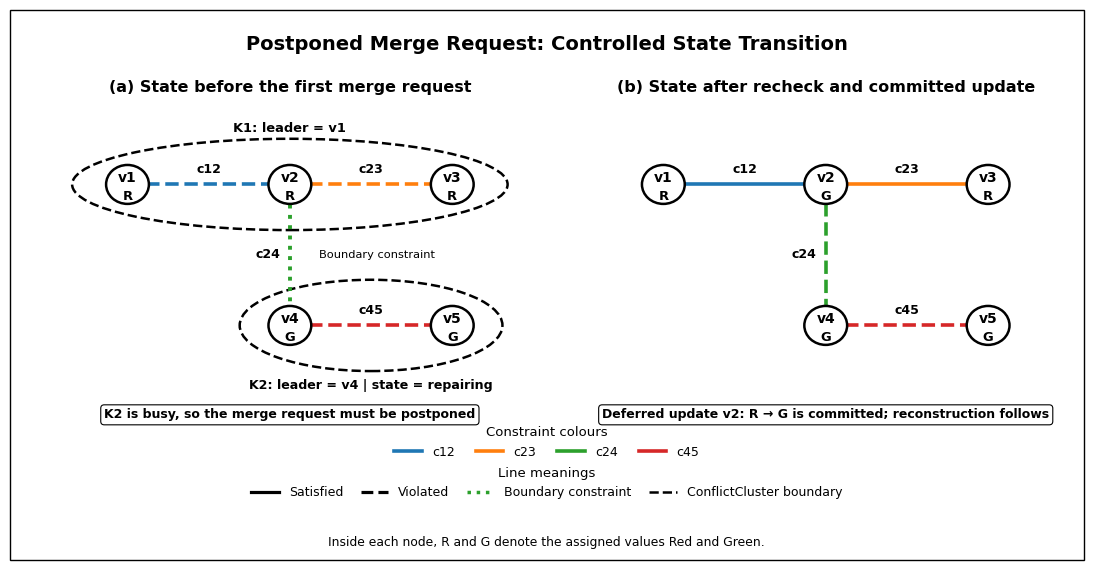

Saved: figures\stage5_postponed_merge_initial_and_updated_states.png
Saved: figures\stage5_postponed_merge_initial_and_updated_states.pdf


In [93]:
# ============================================================
# Stage 5 — Figure 1
# Graph states before postponement and after deferred update
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Ellipse, Rectangle
from pathlib import Path

# ------------------------------------------------------------
# Folder for saved figures
# ------------------------------------------------------------
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Confirmed controlled-test assignments
# ------------------------------------------------------------
assignment_before_postponement = {
    "v1": "R",
    "v2": "R",
    "v3": "R",
    "v4": "G",
    "v5": "G"
}

assignment_after_recheck = {
    "v1": "R",
    "v2": "G",
    "v3": "R",
    "v4": "G",
    "v5": "G"
}

# ------------------------------------------------------------
# Compact graph layout
# ------------------------------------------------------------
positions_stage5 = {
    "v1": (0.25, 1.55),
    "v2": (1.35, 1.55),
    "v3": (2.45, 1.55),
    "v4": (1.35, 0.50),
    "v5": (2.45, 0.50),
}

edges_stage5 = [
    ("v1", "v2", "c12", "tab:blue"),
    ("v2", "v3", "c23", "tab:orange"),
    ("v2", "v4", "c24", "tab:green"),
    ("v4", "v5", "c45", "tab:red"),
]


def stage5_edge_is_violated(var1, var2, assignment):
    """Return True when an inequality constraint is violated."""
    return assignment[var1] == assignment[var2]


def draw_stage5_graph_panel(
    ax,
    assignment,
    panel_title,
    panel_note,
    show_initial_clusters=False
):
    """
    Draw one compact graph-state panel.
    """

    ax.axis("off")
    ax.set_xlim(-0.30, 3.00)
    ax.set_ylim(-0.05, 2.20)

    ax.set_title(
        panel_title,
        fontsize=11.5,
        fontweight="bold",
        pad=4
    )

    # --------------------------------------------------------
    # Initial ConflictCluster boundaries
    # --------------------------------------------------------
    if show_initial_clusters:
        k1 = Ellipse(
            xy=(1.35, 1.55),
            width=2.95,
            height=0.68,
            fill=False,
            edgecolor="black",
            linewidth=1.8,
            linestyle="--"
        )

        k2 = Ellipse(
            xy=(1.90, 0.50),
            width=1.78,
            height=0.68,
            fill=False,
            edgecolor="black",
            linewidth=1.8,
            linestyle="--"
        )

        ax.add_patch(k1)
        ax.add_patch(k2)

        ax.text(
            1.35, 1.97,
            "K1: leader = v1",
            ha="center",
            va="center",
            fontsize=9.4,
            fontweight="bold"
        )

        ax.text(
            1.90, 0.05,
            "K2: leader = v4 | state = repairing",
            ha="center",
            va="center",
            fontsize=9.1,
            fontweight="bold"
        )

    # --------------------------------------------------------
    # Constraints
    # --------------------------------------------------------
    for var1, var2, constraint_name, colour in edges_stage5:
        x1, y1 = positions_stage5[var1]
        x2, y2 = positions_stage5[var2]

        # In the initial panel, c24 is visually identified as
        # the boundary constraint connecting K1 and K2.
        if show_initial_clusters and constraint_name == "c24":
            linestyle = ":"
            linewidth = 2.8
        else:
            linestyle = (
                "--"
                if stage5_edge_is_violated(var1, var2, assignment)
                else "-"
            )
            linewidth = 2.6

        ax.plot(
            [x1, x2],
            [y1, y2],
            color=colour,
            linestyle=linestyle,
            linewidth=linewidth,
            zorder=1
        )

        middle_x = (x1 + x2) / 2
        middle_y = (y1 + y2) / 2

        if constraint_name == "c24":
            ax.text(
                middle_x - 0.15,
                middle_y,
                constraint_name,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )

            if show_initial_clusters:
                ax.text(
                    middle_x + 0.20,
                    middle_y,
                    "Boundary constraint",
                    ha="left",
                    va="center",
                    fontsize=8.2
                )

        else:
            ax.text(
                middle_x,
                middle_y + 0.11,
                constraint_name,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )

    # --------------------------------------------------------
    # Variables and assigned values
    # --------------------------------------------------------
    for variable, (x, y) in positions_stage5.items():
        node = Circle(
            (x, y),
            radius=0.145,
            facecolor="white",
            edgecolor="black",
            linewidth=1.8,
            zorder=3
        )

        ax.add_patch(node)

        ax.text(
            x,
            y + 0.045,
            variable,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            zorder=4
        )

        ax.text(
            x,
            y - 0.090,
            assignment[variable],
            ha="center",
            va="center",
            fontsize=9.4,
            fontweight="bold",
            zorder=4
        )

    # --------------------------------------------------------
    # Note beneath the panel
    # --------------------------------------------------------
    ax.text(
        0.5,
        -0.03,
        panel_note,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9.0,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        )
    )


# ============================================================
# Create side-by-side comparison
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 5.7)
)

fig.patch.set_facecolor("white")

fig.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.83,
    bottom=0.30,
    wspace=0.10
)

draw_stage5_graph_panel(
    ax=axes[0],
    assignment=assignment_before_postponement,
    panel_title="(a) State before the first merge request",
    panel_note="K2 is busy, so the merge request must be postponed",
    show_initial_clusters=True
)

draw_stage5_graph_panel(
    ax=axes[1],
    assignment=assignment_after_recheck,
    panel_title="(b) State after recheck and committed update",
    panel_note="Deferred update v2: R → G is committed; reconstruction follows",
    show_initial_clusters=False
)

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------
fig.suptitle(
    "Postponed Merge Request: Controlled State Transition",
    fontsize=14,
    fontweight="bold",
    y=0.94
)

# ------------------------------------------------------------
# Constraint-colour legend
# ------------------------------------------------------------
constraint_colour_legend = [
    Line2D([0], [0], color="tab:blue",   lw=2.6, label="c12"),
    Line2D([0], [0], color="tab:orange", lw=2.6, label="c23"),
    Line2D([0], [0], color="tab:green",  lw=2.6, label="c24"),
    Line2D([0], [0], color="tab:red",    lw=2.6, label="c45"),
]

fig.legend(
    handles=constraint_colour_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.176),
    ncol=4,
    frameon=False,
    fontsize=9,
    title="Constraint colours",
    title_fontsize=9.5,
    handlelength=2.2,
    columnspacing=1.7
)

# ------------------------------------------------------------
# Line-style legend
# ------------------------------------------------------------
line_meaning_legend = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.3,
        linestyle="-",
        label="Satisfied"
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=2.3,
        linestyle="--",
        label="Violated"
    ),
    Line2D(
        [0], [0],
        color="tab:green",
        lw=2.5,
        linestyle=":",
        label="Boundary constraint"
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=1.8,
        linestyle="--",
        label="ConflictCluster boundary"
    )
]

fig.legend(
    handles=line_meaning_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.105),
    ncol=4,
    frameon=False,
    fontsize=9,
    title="Line meanings",
    title_fontsize=9.5,
    handlelength=2.2,
    columnspacing=1.4
)

# ------------------------------------------------------------
# Node-value explanation
# ------------------------------------------------------------
fig.text(
    0.5,
    0.048,
    "Inside each node, R and G denote the assigned values Red and Green.",
    ha="center",
    va="center",
    fontsize=8.9
)

# ------------------------------------------------------------
# Border
# ------------------------------------------------------------
outer_border = Rectangle(
    (0.012, 0.018),
    0.976,
    0.965,
    transform=fig.transFigure,
    fill=False,
    edgecolor="black",
    linewidth=1.0
)

fig.add_artist(outer_border)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
graph_png = figures_dir / "stage5_postponed_merge_initial_and_updated_states.png"
graph_pdf = figures_dir / "stage5_postponed_merge_initial_and_updated_states.pdf"

fig.savefig(
    graph_png,
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.03
)

fig.savefig(
    graph_pdf,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.show()

print("Saved:", graph_png)
print("Saved:", graph_pdf)

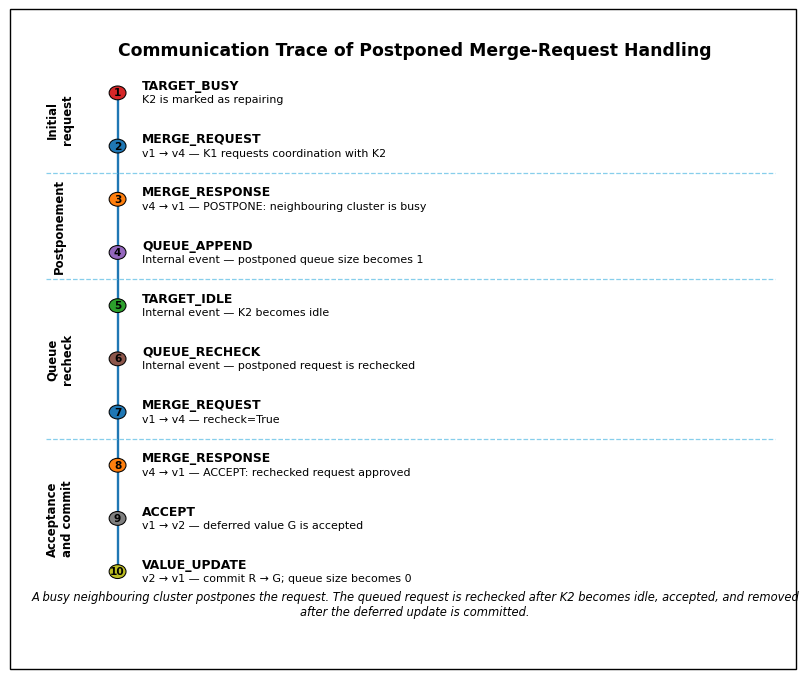

Saved: figures\stage5_postponed_merge_communication_trace.png
Saved: figures\stage5_postponed_merge_communication_trace.pdf


In [94]:
# ============================================================
# Stage 5 — Figure 2
# Communication trace for postponed merge handling
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from pathlib import Path

# ------------------------------------------------------------
# Folder for saved figures
# ------------------------------------------------------------
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Confirmed trace:
# six explicit messages + internal queue-state events
# ------------------------------------------------------------
events_stage5 = [
    {
        "type": "TARGET_BUSY",
        "description": "K2 is marked as repairing",
        "phase": "Initial\nrequest"
    },
    {
        "type": "MERGE_REQUEST",
        "description": "v1 → v4 — K1 requests coordination with K2",
        "phase": "Initial\nrequest"
    },
    {
        "type": "MERGE_RESPONSE",
        "description": "v4 → v1 — POSTPONE: neighbouring cluster is busy",
        "phase": "Postponement"
    },
    {
        "type": "QUEUE_APPEND",
        "description": "Internal event — postponed queue size becomes 1",
        "phase": "Postponement"
    },
    {
        "type": "TARGET_IDLE",
        "description": "Internal event — K2 becomes idle",
        "phase": "Queue\nrecheck"
    },
    {
        "type": "QUEUE_RECHECK",
        "description": "Internal event — postponed request is rechecked",
        "phase": "Queue\nrecheck"
    },
    {
        "type": "MERGE_REQUEST",
        "description": "v1 → v4 — recheck=True",
        "phase": "Queue\nrecheck"
    },
    {
        "type": "MERGE_RESPONSE",
        "description": "v4 → v1 — ACCEPT: rechecked request approved",
        "phase": "Acceptance\nand commit"
    },
    {
        "type": "ACCEPT",
        "description": "v1 → v2 — deferred value G is accepted",
        "phase": "Acceptance\nand commit"
    },
    {
        "type": "VALUE_UPDATE",
        "description": "v2 → v1 — commit R → G; queue size becomes 0",
        "phase": "Acceptance\nand commit"
    }
]

event_colours_stage5 = {
    "TARGET_BUSY": "tab:red",
    "MERGE_REQUEST": "tab:blue",
    "MERGE_RESPONSE": "tab:orange",
    "QUEUE_APPEND": "tab:purple",
    "TARGET_IDLE": "tab:green",
    "QUEUE_RECHECK": "tab:brown",
    "ACCEPT": "tab:gray",
    "VALUE_UPDATE": "tab:olive",
}

# ------------------------------------------------------------
# Create compact vertical trace
# ------------------------------------------------------------
number_of_events = len(events_stage5)

fig, ax = plt.subplots(
    figsize=(8.1, 6.8)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

ax.set_xlim(0, 11.6)
ax.set_ylim(0.0, number_of_events + 1.25)

x_line = 1.22
y_positions = list(range(number_of_events, 0, -1))

# ------------------------------------------------------------
# Vertical guide line
# ------------------------------------------------------------
ax.plot(
    [x_line, x_line],
    [1.0, number_of_events],
    color="tab:blue",
    linewidth=1.7
)

# ------------------------------------------------------------
# Dashed separators and phase ranges
# ------------------------------------------------------------
previous_phase = events_stage5[0]["phase"]
phase_start_y = y_positions[0]
phase_ranges = []

for index in range(1, number_of_events):
    current_phase = events_stage5[index]["phase"]

    if current_phase != previous_phase:
        separator_y = (
            y_positions[index - 1]
            + y_positions[index]
        ) / 2

        ax.hlines(
            separator_y,
            xmin=0.12,
            xmax=11.35,
            colors="skyblue",
            linestyles="dashed",
            linewidth=0.9
        )

        phase_ranges.append(
            (
                previous_phase,
                phase_start_y,
                y_positions[index - 1]
            )
        )

        previous_phase = current_phase
        phase_start_y = y_positions[index]

phase_ranges.append(
    (
        previous_phase,
        phase_start_y,
        y_positions[-1]
    )
)

# ------------------------------------------------------------
# Rotated phase labels
# ------------------------------------------------------------
for phase_name, top_y, bottom_y in phase_ranges:
    centre_y = (top_y + bottom_y) / 2

    ax.text(
        0.33,
        centre_y,
        phase_name,
        rotation=90,
        ha="center",
        va="center",
        fontsize=8.4,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Event markers and descriptions
# ------------------------------------------------------------
for step_number, (event, y) in enumerate(
    zip(events_stage5, y_positions),
    start=1
):
    event_type = event["type"]

    marker = Circle(
        (x_line, y),
        radius=0.13,
        facecolor=event_colours_stage5.get(event_type, "lightgray"),
        edgecolor="black",
        linewidth=0.75,
        zorder=3
    )

    ax.add_patch(marker)

    ax.text(
        x_line,
        y,
        str(step_number),
        ha="center",
        va="center",
        fontsize=7.6,
        fontweight="bold",
        zorder=4
    )

    ax.text(
        1.60,
        y + 0.13,
        event_type,
        ha="left",
        va="center",
        fontsize=8.9,
        fontweight="bold"
    )

    ax.text(
        1.60,
        y - 0.13,
        event["description"],
        ha="left",
        va="center",
        fontsize=7.9
    )

# ------------------------------------------------------------
# Title and explanatory note
# ------------------------------------------------------------
ax.text(
    5.80,
    number_of_events + 0.79,
    "Communication Trace of Postponed Merge-Request Handling",
    ha="center",
    va="center",
    fontsize=12.4,
    fontweight="bold"
)

ax.text(
    5.80,
    0.38,
    (
        "A busy neighbouring cluster postpones the request. "
        "The queued request is rechecked after K2 becomes idle, "
        "accepted, and removed after the deferred update is committed."
    ),
    ha="center",
    va="center",
    fontsize=8.3,
    style="italic",
    wrap=True
)

# ------------------------------------------------------------
# Border
# ------------------------------------------------------------
outer_border = Rectangle(
    (0.015, 0.015),
    0.970,
    0.970,
    transform=fig.transFigure,
    fill=False,
    edgecolor="black",
    linewidth=1.0
)

fig.add_artist(outer_border)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    top=0.96,
    bottom=0.08
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
trace_png = figures_dir / "stage5_postponed_merge_communication_trace.png"
trace_pdf = figures_dir / "stage5_postponed_merge_communication_trace.pdf"

fig.savefig(
    trace_png,
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.04
)

fig.savefig(
    trace_pdf,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.04
)

plt.show()

print("Saved:", trace_png)
print("Saved:", trace_pdf)

## 3. Final four-level benchmark and DCC paper variants

In [95]:
import random

from itertools import combinations

def build_colour_domain(domain_size):
    """
    Create a readable colour domain of the requested size.

    Examples:
        domain_size = 3
        -> ["R", "G", "B"]

        domain_size = 5
        -> ["R", "G", "B", "Y", "P"]
    """

    base_colours = [
        "R", "G", "B", "Y",
        "P", "O", "C", "M"
    ]

    if domain_size <= len(base_colours):
        return base_colours[:domain_size]

    return [
        f"C{i}"
        for i in range(1, domain_size + 1)
    ]


In [96]:
# ============================================================
# Run-All-safe guarded cell
# Cell 165
# ============================================================
try:
    # ============================================================
    # Part I — Step 1
    # Controlled graph-colouring benchmark generator
    # Four-level benchmark version
    # ============================================================

    import random
    from itertools import combinations


    # ------------------------------------------------------------
    # Four-level benchmark families
    # ------------------------------------------------------------
    # We use three families for the main comparison and keep the
    # most difficult family as a separate stress-test group.
    #
    # S  : Sparse
    # M  : Medium
    # D  : Dense
    # XD : Extreme-dense stress-test
    #
    # The previous H family is kept only as a legacy alias for XD,
    # so old diagnostic cells still run safely if they are executed.
    # ------------------------------------------------------------

    SCALABILITY_FAMILIES = {
        "S": {
            "label": "Sparse",
            "edge_factor": 2.0,
            "benchmark_role": "main_comparison"
        },

        "M": {
            "label": "Medium",
            "edge_factor": 2.3,
            "benchmark_role": "main_comparison"
        },

        "D": {
            "label": "Dense",
            "edge_factor": 2.5,
            "benchmark_role": "main_comparison"
        },

        "XD": {
            "label": "Extreme-dense stress-test",
            "edge_factor": 2.7,
            "benchmark_role": "stress_test"
        }
    }

    BENCHMARK_FAMILY_ORDER = [
        "S",
        "M",
        "D",
        "XD"
    ]

    MAIN_COMPARISON_FAMILIES = [
        "S",
        "M",
        "D"
    ]

    STRESS_TEST_FAMILIES = [
        "XD"
    ]

    LEGACY_FAMILY_ALIASES = {
        "H": "XD"
    }


    def normalise_benchmark_family_code(family_code):
        """
        Return the current benchmark family code.

        The old code H is treated as a legacy alias for XD. This keeps
        earlier diagnostic cells executable, but the current benchmark
        definition uses S, M, D, and XD.
        """

        return LEGACY_FAMILY_ALIASES.get(
            family_code,
            family_code
        )


    def build_balanced_planted_assignment(
        *,
        variables,
        colours,
        graph_seed
    ):
        """
        Create a reproducible planted satisfying assignment.

        The colours are distributed approximately evenly across the
        variables before being shuffled. This gives a valid planted
        solution and keeps the generated graph reproducible.
        """

        rng = random.Random(
            graph_seed
        )

        repeated_colours = [
            colours[index % len(colours)]
            for index in range(
                len(variables)
            )
        ]

        rng.shuffle(
            repeated_colours
        )

        planted_assignment = {
            variable: colour
            for variable, colour in zip(
                variables,
                repeated_colours
            )
        }

        return planted_assignment


    def generate_conflicted_initial_assignment(
        *,
        problem,
        colours,
        initial_assignment_seed,
        minimum_initial_violations=1,
        max_attempts=500
    ):
        """
        Generate a reproducible conflicted starting assignment.

        The starting assignment is independent from the graph seed and
        must contain at least the requested number of violated constraints.
        """

        if minimum_initial_violations < 1:
            raise ValueError(
                "minimum_initial_violations must be at least 1."
            )

        rng = random.Random(
            initial_assignment_seed
        )

        for _ in range(
            max_attempts
        ):

            candidate_assignment = {
                variable: rng.choice(
                    colours
                )
                for variable in problem.variables
            }

            violation_count = len(
                problem.violated_constraints(
                    candidate_assignment
                )
            )

            if violation_count >= minimum_initial_violations:
                return candidate_assignment

        # Fallback: force one violated constraint if random attempts fail.
        fallback_assignment = {
            variable: rng.choice(
                colours
            )
            for variable in problem.variables
        }

        first_constraint = problem.constraints[0]

        fallback_assignment[
            first_constraint.var2
        ] = fallback_assignment[
            first_constraint.var1
        ]

        return fallback_assignment


    def generate_linear_edge_graph_colouring_instance(
        *,
        n_variables,
        family_code,
        domain_size,
        graph_seed,
        initial_assignment_seed,
        minimum_initial_violations=1
    ):
        """
        Generate a guaranteed-solvable graph-colouring DCSP instance.

        The number of constraints is proportional to the number of
        variables. The four current benchmark families are:

            S  -> m = 2.0n  Sparse
            M  -> m = 2.3n  Medium
            D  -> m = 2.5n  Dense
            XD -> m = 2.7n  Extreme-dense stress-test

        A planted satisfying assignment is generated first. Edges are
        then sampled only between variables with different planted colours,
        guaranteeing that the planted assignment is a valid solution.
        """

        # --------------------------------------------------------
        # Validate and normalise inputs
        # --------------------------------------------------------

        if n_variables < 4:
            raise ValueError(
                "n_variables must be at least 4."
            )

        current_family_code = normalise_benchmark_family_code(
            family_code
        )

        if current_family_code not in SCALABILITY_FAMILIES:
            raise ValueError(
                "family_code must be one of: 'S', 'M', 'D', or 'XD'. "
                "Legacy code 'H' is accepted as an alias for 'XD'."
            )

        if domain_size < 2:
            raise ValueError(
                "domain_size must be at least 2."
            )

        # --------------------------------------------------------
        # Build variables and domains
        # --------------------------------------------------------

        variables = [
            f"v{i}"
            for i in range(
                1,
                n_variables + 1
            )
        ]

        colours = build_colour_domain(
            domain_size
        )

        domains = {
            variable: list(
                colours
            )
            for variable in variables
        }

        # --------------------------------------------------------
        # Create balanced planted solution
        # --------------------------------------------------------

        planted_assignment = build_balanced_planted_assignment(
            variables=variables,
            colours=colours,
            graph_seed=graph_seed
        )

        # --------------------------------------------------------
        # Calculate exact target edge count
        # --------------------------------------------------------

        family_details = SCALABILITY_FAMILIES[
            current_family_code
        ]

        edge_factor = family_details[
            "edge_factor"
        ]

        target_edges = round(
            edge_factor * n_variables
        )

        # --------------------------------------------------------
        # Identify edges compatible with planted assignment
        # --------------------------------------------------------

        compatible_edges = [
            (var1, var2)
            for var1, var2 in combinations(
                variables,
                2
            )
            if planted_assignment[var1] != planted_assignment[var2]
        ]

        if target_edges > len(compatible_edges):
            raise ValueError(
                "The requested number of constraints exceeds the available "
                "planted-solution-compatible edges."
            )

        # --------------------------------------------------------
        # Select exact edge count reproducibly
        # --------------------------------------------------------

        graph_rng = random.Random(
            graph_seed
        )

        selected_edges = graph_rng.sample(
            compatible_edges,
            target_edges
        )

        selected_edges = sorted(
            selected_edges,
            key=lambda edge: (
                int(edge[0][1:]),
                int(edge[1][1:])
            )
        )

        # --------------------------------------------------------
        # Convert selected edges to inequality constraints
        # --------------------------------------------------------

        constraints = []

        for var1, var2 in selected_edges:
            constraints.append(
                BinaryConstraint(
                    name=(
                        f"c_{var1[1:]}_{var2[1:]}"
                    ),
                    var1=var1,
                    var2=var2,
                    condition=lambda a, b: a != b
                )
            )

        problem = DCSPProblem(
            variables=variables,
            domains=domains,
            constraints=constraints
        )

        # --------------------------------------------------------
        # Generate independent conflicted starting assignment
        # --------------------------------------------------------

        initial_assignment = generate_conflicted_initial_assignment(
            problem=problem,
            colours=colours,
            initial_assignment_seed=initial_assignment_seed,
            minimum_initial_violations=minimum_initial_violations
        )

        # --------------------------------------------------------
        # Verify planted solution
        # --------------------------------------------------------

        planted_solution_violations = len(
            problem.violated_constraints(
                planted_assignment
            )
        )

        if planted_solution_violations != 0:
            raise RuntimeError(
                "Generated planted assignment is not valid."
            )

        # --------------------------------------------------------
        # Calculate metadata
        # --------------------------------------------------------

        maximum_possible_edges = (
            n_variables * (n_variables - 1) / 2
        )

        actual_density = len(constraints) / maximum_possible_edges

        initial_violations = len(
            problem.violated_constraints(
                initial_assignment
            )
        )

        graph_id = (
            f"{current_family_code}"
            f"_n{n_variables}"
            f"_g{graph_seed}"
        )

        metadata = {
            "graph_id": graph_id,
            "family_code": current_family_code,
            "family_label": family_details["label"],
            "benchmark_role": family_details["benchmark_role"],
            "input_family_code": family_code,
            "edge_factor": edge_factor,
            "n_variables": n_variables,
            "n_constraints": len(constraints),
            "target_constraints": target_edges,
            "maximum_possible_edges": maximum_possible_edges,
            "actual_density": actual_density,
            "domain_size": domain_size,
            "graph_seed": graph_seed,
            "initial_assignment_seed": initial_assignment_seed,
            "initial_violations": initial_violations,
            "compatible_edge_pool_size": len(compatible_edges),
            "planted_solution_verified": planted_solution_violations == 0,
            "planted_solution_violations": planted_solution_violations
        }

        return {
            "problem": problem,
            "initial_assignment": initial_assignment,
            "planted_assignment": planted_assignment,
            "metadata": metadata
        }

    print("Four-level benchmark families are ready:")
    display(pd.DataFrame.from_dict(SCALABILITY_FAMILIES, orient="index"))

except Exception as error:
    print("Cell 165 skipped because of:", repr(error))


Four-level benchmark families are ready:


,label,edge_factor,benchmark_role
S,Sparse,2.0,main_comparison
M,Medium,2.3,main_comparison
D,Dense,2.5,main_comparison
XD,Extreme-dense stress-test,2.7,stress_test


In [97]:
# ============================================================
# Helper: normalise generated-instance format
# ============================================================

def normalise_generated_instance(instance):
    """
    Convert a generated benchmark instance into the standard dictionary
    format used by the solver and the benchmark runner.
    """

    if isinstance(instance, dict):
        return instance

    if isinstance(instance, tuple):
        if len(instance) == 4:
            problem, planted_assignment, initial_assignment, metadata = instance
            return {
                "problem": problem,
                "planted_assignment": planted_assignment,
                "initial_assignment": initial_assignment,
                "metadata": metadata,
            }

        if len(instance) == 3:
            problem, initial_assignment, metadata = instance
            return {
                "problem": problem,
                "initial_assignment": initial_assignment,
                "metadata": metadata,
            }

    raise ValueError("Unrecognised generated-instance format.")


# Part II — Four-Level Benchmark Design for Final Comparison

In this section we organise the benchmark into four levels. We use **Sparse**, **Medium**, and **Dense** instances for the main comparison with other solvers. The **Extreme-dense** family is kept as a separate stress-test because the previous diagnostic runs showed that these cases are difficult for all incomplete solvers. This keeps the evaluation clear while still showing the limitation of local incomplete repair on the most difficult cases.


In [98]:
# ============================================================
# Part II — Step 1
# Final benchmark configuration for comparison with baselines
# ============================================================

FINAL_BENCHMARK_VARIABLE_SIZES = [
    20,
    50,
    100,
]

FINAL_BENCHMARK_GRAPH_SEEDS = [
    101,
    102,
    103,
]

FINAL_BENCHMARK_INITIAL_ASSIGNMENT_SEEDS = [
    201,
    202,
]

FINAL_BENCHMARK_DOMAIN_SIZE = 3

FINAL_MAIN_COMPARISON_FAMILIES = [
    "S",
    "M",
    "D",
]

FINAL_STRESS_TEST_FAMILIES = [
    "XD",
]

FINAL_ALL_BENCHMARK_FAMILIES = (
    FINAL_MAIN_COMPARISON_FAMILIES
    + FINAL_STRESS_TEST_FAMILIES
)


FINAL_DCC_RESTART_STRATEGIES = [
    "random",
    "memory_guided",
]

RUN_FINAL_DCC_SMOKE_TEST = True
RUN_FINAL_DCC_MAIN_COMPARISON = True
RUN_FINAL_DCC_STRESS_TEST = True
RUN_FINAL_DCC_COMBINE_RESULTS = True
RUN_FINAL_INSTANCE_EXPORT = True

print("Final benchmark configuration is ready.")
print("Main comparison families:", FINAL_MAIN_COMPARISON_FAMILIES)
print("Stress-test families:", FINAL_STRESS_TEST_FAMILIES)
print("DCC smoke-test flag:", RUN_FINAL_DCC_SMOKE_TEST)
print("DCC main-comparison flag:", RUN_FINAL_DCC_MAIN_COMPARISON)
print("DCC stress-test flag:", RUN_FINAL_DCC_STRESS_TEST)


Final benchmark configuration is ready.
Main comparison families: ['S', 'M', 'D']
Stress-test families: ['XD']
DCC smoke-test flag: True
DCC main-comparison flag: True
DCC stress-test flag: True


## Part II — Step 2: Build the benchmark manifest

This cell creates a manifest of all benchmark instances before running any solver. The manifest records the family, density, number of constraints, graph seed, and initial-assignment seed. We will use this same manifest for DCC-Incomplete and for the external baseline solvers, so the comparison is based on exactly the same instances.


In [99]:
# ============================================================
# Part II — Step 2
# Build and save a four-level benchmark manifest
# ============================================================

from pathlib import Path
import pandas as pd
import json

FINAL_BENCHMARK_DIR = Path("final_four_level_benchmark")
FINAL_BENCHMARK_DIR.mkdir(exist_ok=True)


def build_final_benchmark_manifest(
    *,
    variable_sizes=None,
    family_codes=None,
    graph_seeds=None,
    initial_assignment_seeds=None,
    domain_size=3,
):
    """
    Build a reproducible manifest for the final benchmark.

    This does not run any solver. It only generates the instances once
    and records the structural metadata needed for comparison.
    """

    variable_sizes = variable_sizes or FINAL_BENCHMARK_VARIABLE_SIZES
    family_codes = family_codes or FINAL_ALL_BENCHMARK_FAMILIES
    graph_seeds = graph_seeds or FINAL_BENCHMARK_GRAPH_SEEDS
    initial_assignment_seeds = initial_assignment_seeds or FINAL_BENCHMARK_INITIAL_ASSIGNMENT_SEEDS

    rows = []

    case_id = 0

    for n_variables in variable_sizes:
        for family_code in family_codes:
            for graph_seed in graph_seeds:
                for initial_assignment_seed in initial_assignment_seeds:

                    case_id += 1

                    instance = generate_linear_edge_graph_colouring_instance(
                        n_variables=n_variables,
                        family_code=family_code,
                        domain_size=domain_size,
                        graph_seed=graph_seed,
                        initial_assignment_seed=initial_assignment_seed,
                        minimum_initial_violations=1,
                    )

                    metadata = instance["metadata"]

                    rows.append(
                        {
                            "case_id": f"case_{case_id:04d}",
                            "benchmark_role": metadata["benchmark_role"],
                            "family_code": metadata["family_code"],
                            "family_label": metadata["family_label"],
                            "edge_factor": metadata["edge_factor"],
                            "n_variables": metadata["n_variables"],
                            "n_constraints": metadata["n_constraints"],
                            "actual_density": metadata["actual_density"],
                            "domain_size": metadata["domain_size"],
                            "graph_seed": metadata["graph_seed"],
                            "initial_assignment_seed": metadata["initial_assignment_seed"],
                            "initial_violations": metadata["initial_violations"],
                            "planted_solution_verified": metadata["planted_solution_verified"],
                        }
                    )

    return pd.DataFrame(rows)


final_benchmark_manifest = build_final_benchmark_manifest()

manifest_path = FINAL_BENCHMARK_DIR / "final_four_level_benchmark_manifest.csv"
final_benchmark_manifest.to_csv(manifest_path, index=False)

print("Benchmark manifest saved to:", manifest_path)
print("Total instances:", len(final_benchmark_manifest))

display(
    final_benchmark_manifest.groupby(
        ["benchmark_role", "family_code", "family_label", "n_variables"],
        as_index=False,
    ).agg(
        cases=("case_id", "count"),
        constraints=("n_constraints", "mean"),
        density=("actual_density", "mean"),
        initial_violations=("initial_violations", "mean"),
    )
)


Benchmark manifest saved to: final_four_level_benchmark\final_four_level_benchmark_manifest.csv
Total instances: 72


,benchmark_role,family_code,family_label,n_variables,cases,constraints,density,initial_violations
0,main_comparison,D,Dense,20,6,50.0,0.263158,18.333333
1,main_comparison,D,Dense,50,6,125.0,0.102041,45.000000
2,main_comparison,D,Dense,100,6,250.0,0.050505,83.833333
3,main_comparison,M,Medium,20,6,46.0,0.242105,16.000000
4,main_comparison,M,Medium,50,6,115.0,0.093878,41.833333
5,main_comparison,M,Medium,100,6,230.0,0.046465,78.000000
6,main_comparison,S,Sparse,20,6,40.0,0.210526,13.333333
7,main_comparison,S,Sparse,50,6,100.0,0.081633,36.166667
8,main_comparison,S,Sparse,100,6,200.0,0.040404,67.666667
9,stress_test,XD,Extreme-dense stress-test,20,6,54.0,0.284211,19.500000


## Part II — Step 3: Export instances for other solvers

This cell exports each graph-colouring instance into simple CSV/JSON files. These files allow the external baseline solvers to run on the same generated graphs. The exported format keeps the variables, domain values, constraints, planted assignment, and initial assignment.


In [100]:
# ============================================================
# Part II — Step 3
# Export benchmark instances for external baseline solvers
# ============================================================

import json


def export_instance_for_baselines(
    *,
    instance,
    case_id,
    output_dir,
):
    """
    Export one graph-colouring DCSP instance in simple files.

    Files produced per case:
      - metadata.json
      - variables.csv
      - constraints.csv
      - initial_assignment.csv
      - planted_assignment.csv

    These files are intentionally simple so that they can be used by
    our own baseline scripts or converted into pyDCOP input later.
    """

    output_dir = Path(output_dir)
    case_dir = output_dir / case_id
    case_dir.mkdir(parents=True, exist_ok=True)

    problem = instance["problem"]
    metadata = instance["metadata"]
    initial_assignment = instance["initial_assignment"]
    planted_assignment = instance["planted_assignment"]

    with open(case_dir / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    variables_df = pd.DataFrame(
        [
            {
                "variable": variable,
                "domain": json.dumps(problem.domains[variable]),
            }
            for variable in problem.variables
        ]
    )

    constraints_df = pd.DataFrame(
        [
            {
                "constraint_name": constraint.name,
                "var1": constraint.var1,
                "var2": constraint.var2,
                "relation": "!=",
                "cost_if_equal": 1,
                "cost_if_different": 0,
            }
            for constraint in problem.constraints
        ]
    )

    initial_assignment_df = pd.DataFrame(
        [
            {
                "variable": variable,
                "value": value,
            }
            for variable, value in initial_assignment.items()
        ]
    )

    planted_assignment_df = pd.DataFrame(
        [
            {
                "variable": variable,
                "value": value,
            }
            for variable, value in planted_assignment.items()
        ]
    )

    variables_df.to_csv(case_dir / "variables.csv", index=False)
    constraints_df.to_csv(case_dir / "constraints.csv", index=False)
    initial_assignment_df.to_csv(case_dir / "initial_assignment.csv", index=False)
    planted_assignment_df.to_csv(case_dir / "planted_assignment.csv", index=False)

    return case_dir


if RUN_FINAL_INSTANCE_EXPORT:

    exported_rows = []
    export_dir = FINAL_BENCHMARK_DIR / "exported_instances"
    export_dir.mkdir(exist_ok=True)

    for _, row in final_benchmark_manifest.iterrows():

        instance = generate_linear_edge_graph_colouring_instance(
            n_variables=int(row["n_variables"]),
            family_code=row["family_code"],
            domain_size=int(row["domain_size"]),
            graph_seed=int(row["graph_seed"]),
            initial_assignment_seed=int(row["initial_assignment_seed"]),
            minimum_initial_violations=1,
        )

        case_dir = export_instance_for_baselines(
            instance=instance,
            case_id=row["case_id"],
            output_dir=export_dir,
        )

        exported_rows.append(
            {
                "case_id": row["case_id"],
                "family_code": row["family_code"],
                "benchmark_role": row["benchmark_role"],
                "case_dir": str(case_dir),
            }
        )

    exported_manifest = pd.DataFrame(exported_rows)
    exported_manifest_path = FINAL_BENCHMARK_DIR / "exported_instances_manifest.csv"
    exported_manifest.to_csv(exported_manifest_path, index=False)

    print("Exported benchmark instances to:", export_dir)
    print("Export manifest saved to:", exported_manifest_path)
    display(exported_manifest.head())

else:
    print("Instance export skipped.")


Exported benchmark instances to: final_four_level_benchmark\exported_instances
Export manifest saved to: final_four_level_benchmark\exported_instances_manifest.csv


,case_id,family_code,benchmark_role,case_dir
0,case_0001,S,main_comparison,final_four_level_benchmark\exported_instances\...
1,case_0002,S,main_comparison,final_four_level_benchmark\exported_instances\...
2,case_0003,S,main_comparison,final_four_level_benchmark\exported_instances\...
3,case_0004,S,main_comparison,final_four_level_benchmark\exported_instances\...
4,case_0005,S,main_comparison,final_four_level_benchmark\exported_instances\...


## 7. DCC internal comparison: random restart vs memory-guided restart

This section runs the two DCC-Incomplete variants on the final benchmark manifest. The memory-guided variant uses candidate-pool size `p=25`, matching the reported experiments.


## Part II — Step 4: Fixed DCC-Incomplete internal-comparison runner

This section runs the two DCC-Incomplete variants used in the reported experiments:

- `random`
- `memory_guided`

The runner maps the solver outputs (`violated_constraints`, `messages`, and restart counters) into the result columns used for the comparison tables.


In [101]:
# ============================================================
# Part II — Step 4
# FIXED DCC-Incomplete runner for the final four-level benchmark
# Includes Random and Memory-Guided Restart
# ============================================================

import time
import math
import random
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# 4.1 — Required-object checks
# ------------------------------------------------------------

required_objects = [
    "final_benchmark_manifest",
    "generate_linear_edge_graph_colouring_instance",
    "normalise_generated_instance",
    "solve_dynamic_conflict_clustering_incomplete",
    "local_restart_cluster",
    "local_restart_cluster_memory_guided",
    "initialise_restart_memory",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Please run the earlier notebook cells first. Missing objects: "
        + str(missing_objects)
    )

required_manifest_columns = [
    "case_id",
    "benchmark_role",
    "family_code",
    "family_label",
    "edge_factor",
    "n_variables",
    "n_constraints",
    "actual_density",
    "domain_size",
    "graph_seed",
    "initial_assignment_seed",
    "initial_violations",
]

missing_columns = [
    column for column in required_manifest_columns
    if column not in final_benchmark_manifest.columns
]

if missing_columns:
    raise ValueError(
        "The final benchmark manifest is missing these columns: "
        + str(missing_columns)
    )



# ------------------------------------------------------------
# 4.2 — Metric extraction, summary helpers, and DCC benchmark runner
# ------------------------------------------------------------

def safe_divide(numerator, denominator):
    """Safely divide two numeric values."""
    if numerator is None:
        return None
    if denominator is None:
        return None
    if denominator == 0:
        return None
    return numerator / denominator


def extract_dcc_solver_metrics(result):
    """
    Convert the actual solver output into the standard comparison format.

    The current solver returns:
        - status
        - violated_constraints
        - messages
        - iterations
        - local_restarts

    The comparison table uses:
        - solved
        - final_violations
        - explicit_messages
        - runtime_seconds
    """
    status = result.get("status")
    final_violations = result.get("violated_constraints")
    explicit_messages = result.get("messages")

    solved = (
        status == "SOLVED"
        or final_violations == 0
    )


    return {
        "status": status,
        "solved": bool(solved),
        "iterations": result.get("iterations"),
        "final_violations": final_violations,
        "local_restarts": result.get("local_restarts"),
        "explicit_messages": explicit_messages,
        "stagnation_events": len(result.get("stagnation_events", [])),
        "local_restart_events": len(result.get("local_restart_events", [])),
        "postponed_merge_events": len(result.get("postponed_merge_events", [])),
        "postponed_requests_created": result.get("postponed_requests_created"),
        "postponed_requests_accepted_after_recheck": result.get(
            "postponed_requests_accepted_after_recheck"
        ),
        "remaining_postponed_queue": result.get("remaining_postponed_queue"),
    }


def summarise_final_dcc_results(results_df):
    """
    Build the final DCC internal-comparison summary table.
    """
    summary = (
        results_df
        .groupby(
            [
                "benchmark_role",
                "family_code",
                "family_label",
                "n_variables",
                "restart_strategy",
                "algorithm",
            ],
            as_index=False,
        )
        .agg(
            runs=("solved", "count"),
            solved_runs=("solved", "sum"),
            error_runs=("run_error", "sum"),
            avg_runtime_seconds=("runtime_seconds", "mean"),
            median_runtime_seconds=("runtime_seconds", "median"),
            avg_iterations=("iterations", "mean"),
            median_iterations=("iterations", "median"),
            avg_messages=("explicit_messages", "mean"),
            median_messages=("explicit_messages", "median"),
            avg_messages_per_variable=("messages_per_variable", "mean"),
            avg_messages_per_constraint=("messages_per_constraint", "mean"),
            avg_final_violations=("final_violations", "mean"),
            median_final_violations=("final_violations", "median"),
            avg_local_restarts=("local_restarts", "mean"),
            avg_stagnation_events=("stagnation_events", "mean"),
            avg_local_restart_events=("local_restart_events", "mean"),
            avg_postponed_merge_events=("postponed_merge_events", "mean"),
        )
    )

    summary["success_rate"] = summary["solved_runs"] / summary["runs"]

    return summary


# ------------------------------------------------------------
# 4.4 — Main fixed benchmark runner
# ------------------------------------------------------------


def run_final_dcc_benchmark(
    *,
    manifest_df,
    restart_strategies=None,
    max_iterations=150,
    max_local_restarts=75,
    stagnation_threshold=2,
    solver_seed=15,
    output_csv=None,
):
    """
    Run DCC-Incomplete variants on a benchmark manifest.

    This runner includes the two variants used in the reported experiments:
        - random
        - memory_guided

    It records errors as rows instead of stopping the full benchmark.
    """
    if restart_strategies is None:
        restart_strategies = [
            "random",
            "memory_guided",
        ]

    allowed_restart_strategies = {
        "random",
        "memory_guided",
    }

    unsupported = [
        strategy for strategy in restart_strategies
        if strategy not in allowed_restart_strategies
    ]

    if unsupported:
        raise ValueError(
            "Unsupported restart strategies: "
            + str(unsupported)
            + ". Supported strategies are: "
            + str(sorted(allowed_restart_strategies))
        )

    rows = []

    total_runs = len(manifest_df) * len(restart_strategies)
    run_counter = 0

    for _, case in manifest_df.iterrows():
        for strategy in restart_strategies:

            run_counter += 1

            print(
                "Running",
                run_counter,
                "of",
                total_runs,
                "| case =",
                case["case_id"],
                "| role =",
                case["benchmark_role"],
                "| family =",
                case["family_code"],
                "| n =",
                case["n_variables"],
                "| strategy =",
                strategy,
            )

            base_row = {
                "case_id": case["case_id"],
                "benchmark_role": case["benchmark_role"],
                "family_code": case["family_code"],
                "family_label": case["family_label"],
                "edge_factor": case["edge_factor"],
                "n_variables": int(case["n_variables"]),
                "n_constraints": int(case["n_constraints"]),
                "actual_density": case["actual_density"],
                "domain_size": int(case["domain_size"]),
                "graph_seed": int(case["graph_seed"]),
                "initial_assignment_seed": int(case["initial_assignment_seed"]),
                "initial_violations": int(case["initial_violations"]),
                "restart_strategy": strategy,
                "algorithm": "DCC-Incomplete-" + strategy,
            }

            try:
                instance = generate_linear_edge_graph_colouring_instance(
                    n_variables=int(case["n_variables"]),
                    family_code=case["family_code"],
                    domain_size=int(case["domain_size"]),
                    graph_seed=int(case["graph_seed"]),
                    initial_assignment_seed=int(case["initial_assignment_seed"]),
                    minimum_initial_violations=1,
                )

                instance = normalise_generated_instance(instance)

                start_time = time.perf_counter()

                result = solve_dynamic_conflict_clustering_incomplete(
                    problem=instance["problem"],
                    seed=solver_seed,
                    initial_assignment=instance["initial_assignment"],
                    max_iterations=max_iterations,
                    stagnation_threshold=stagnation_threshold,
                    max_local_restarts=max_local_restarts,
                    restart_strategy=strategy,
                    verbose=False,
                )

                runtime_seconds = time.perf_counter() - start_time

                metrics = extract_dcc_solver_metrics(result)
                explicit_messages = metrics["explicit_messages"]

                row = {
                    **base_row,
                    **metrics,
                    "runtime_seconds": runtime_seconds,
                    "messages_per_variable": safe_divide(
                        explicit_messages,
                        int(case["n_variables"]),
                    ),
                    "messages_per_constraint": safe_divide(
                        explicit_messages,
                        int(case["n_constraints"]),
                    ),
                    "run_error": False,
                    "error_message": None,
                }

            except Exception as error:
                row = {
                    **base_row,
                    "status": "ERROR",
                    "solved": False,
                    "iterations": None,
                    "runtime_seconds": None,
                    "final_violations": None,
                    "local_restarts": None,
                    "explicit_messages": None,
                    "messages_per_variable": None,
                    "messages_per_constraint": None,
                    "stagnation_events": None,
                    "local_restart_events": None,
                    "postponed_merge_events": None,
                    "postponed_requests_created": None,
                    "postponed_requests_accepted_after_recheck": None,
                    "remaining_postponed_queue": None,
                    "run_error": True,
                    "error_message": str(error),
                }

                print("ERROR in this run:")
                print(str(error))

            rows.append(row)

            if output_csv is not None:
                pd.DataFrame(rows).to_csv(output_csv, index=False)

    results_df = pd.DataFrame(rows)

    if output_csv is not None:
        results_df.to_csv(output_csv, index=False)
        print("Saved raw results to:", output_csv)

    return results_df


# ------------------------------------------------------------
# 4.5 — Benchmark split
# ------------------------------------------------------------

main_manifest = final_benchmark_manifest[
    final_benchmark_manifest["benchmark_role"] == "main_comparison"
].copy()

stress_manifest = final_benchmark_manifest[
    final_benchmark_manifest["benchmark_role"] == "stress_test"
].copy()

print("Main comparison instances:", len(main_manifest))
print("Stress-test instances:", len(stress_manifest))
print("Total benchmark instances:", len(final_benchmark_manifest))
print("Restart strategies: random, memory_guided")


# ------------------------------------------------------------
# 4.6 — Optional smoke test
# ------------------------------------------------------------

if RUN_FINAL_DCC_SMOKE_TEST:
    smoke_manifest = final_benchmark_manifest[
        (final_benchmark_manifest["family_code"] == "S")
        & (final_benchmark_manifest["n_variables"] == 20)
    ].head(1)

    final_dcc_smoke_results = run_final_dcc_benchmark(
        manifest_df=smoke_manifest,
        restart_strategies=[
            "random",
            "memory_guided",
        ],
        max_iterations=150,
        max_local_restarts=75,
        stagnation_threshold=2,
        solver_seed=15,
        output_csv=FINAL_BENCHMARK_DIR / "final_dcc_smoke_test_raw.csv",
    )

    display(final_dcc_smoke_results)
else:
    print("DCC smoke test is prepared but not run.")
    print("Set RUN_FINAL_DCC_SMOKE_TEST = True to run one S-family case first.")


# ------------------------------------------------------------
# 4.7 — Optional main comparison: S, M, D
# ------------------------------------------------------------

if RUN_FINAL_DCC_MAIN_COMPARISON:
    final_dcc_main_results = run_final_dcc_benchmark(
        manifest_df=main_manifest,
        restart_strategies=[
            "random",
            "memory_guided",
        ],
        max_iterations=150,
        max_local_restarts=75,
        stagnation_threshold=2,
        solver_seed=15,
        output_csv=FINAL_BENCHMARK_DIR / "final_dcc_main_comparison_raw.csv",
    )

    final_dcc_main_summary = summarise_final_dcc_results(
        final_dcc_main_results
    )

    final_dcc_main_summary.to_csv(
        FINAL_BENCHMARK_DIR / "final_dcc_main_comparison_summary.csv",
        index=False,
    )

    display(final_dcc_main_results.head())
    display(final_dcc_main_summary)
else:
    print("Final DCC main comparison is prepared but not run.")
    print("Set RUN_FINAL_DCC_MAIN_COMPARISON = True when ready.")


# ------------------------------------------------------------
# 4.8 — Optional XD stress test
# ------------------------------------------------------------

if RUN_FINAL_DCC_STRESS_TEST:
    final_dcc_stress_results = run_final_dcc_benchmark(
        manifest_df=stress_manifest,
        restart_strategies=[
            "random",
            "memory_guided",
        ],
        max_iterations=300,
        max_local_restarts=150,
        stagnation_threshold=2,
        solver_seed=15,
        output_csv=FINAL_BENCHMARK_DIR / "final_dcc_extreme_dense_stress_test_raw.csv",
    )

    final_dcc_stress_summary = summarise_final_dcc_results(
        final_dcc_stress_results
    )

    final_dcc_stress_summary.to_csv(
        FINAL_BENCHMARK_DIR / "final_dcc_extreme_dense_stress_test_summary.csv",
        index=False,
    )

    display(final_dcc_stress_results.head())
    display(final_dcc_stress_summary)
else:
    print("Final DCC stress-test run is prepared but not run.")
    print("Set RUN_FINAL_DCC_STRESS_TEST = True when ready.")


# ------------------------------------------------------------
# 4.9 — Optional combined DCC result table
# ------------------------------------------------------------

if RUN_FINAL_DCC_COMBINE_RESULTS:
    result_frames = []

    main_raw_path = FINAL_BENCHMARK_DIR / "final_dcc_main_comparison_raw.csv"
    stress_raw_path = FINAL_BENCHMARK_DIR / "final_dcc_extreme_dense_stress_test_raw.csv"
    all_raw_path = FINAL_BENCHMARK_DIR / "final_dcc_all_four_level_raw.csv"
    all_summary_path = FINAL_BENCHMARK_DIR / "final_dcc_all_four_level_summary.csv"

    # First use in-memory results when they are available.
    if "final_dcc_main_results" in globals():
        print("Using main comparison results from memory.")
        result_frames.append(final_dcc_main_results)

    # If the notebook was restarted or run again, load the saved CSV instead.
    elif main_raw_path.exists():
        print("Loading main comparison results from saved CSV:", main_raw_path)
        final_dcc_main_results = pd.read_csv(main_raw_path)
        result_frames.append(final_dcc_main_results)

    else:
        print("Main comparison result file is not available yet:", main_raw_path)

    # First use in-memory XD stress-test results when they are available.
    if "final_dcc_stress_results" in globals():
        print("Using XD stress-test results from memory.")
        result_frames.append(final_dcc_stress_results)

    # If the notebook was restarted or run again, load the saved CSV instead.
    elif stress_raw_path.exists():
        print("Loading XD stress-test results from saved CSV:", stress_raw_path)
        final_dcc_stress_results = pd.read_csv(stress_raw_path)
        result_frames.append(final_dcc_stress_results)

    else:
        print("XD stress-test result file is not available yet:", stress_raw_path)

    if result_frames:
        final_dcc_all_results = pd.concat(
            result_frames,
            ignore_index=True,
        )

        final_dcc_all_summary = summarise_final_dcc_results(
            final_dcc_all_results
        )

        final_dcc_all_results.to_csv(
            all_raw_path,
            index=False,
        )

        final_dcc_all_summary.to_csv(
            all_summary_path,
            index=False,
        )

        print("Combined DCC raw results saved to:", all_raw_path)
        print("Combined DCC summary saved to:", all_summary_path)
        print("Actual combined runs:", len(final_dcc_all_results))

        expected_combined_runs = len(final_benchmark_manifest) * len(FINAL_DCC_RESTART_STRATEGIES)
        print("Expected combined runs:", expected_combined_runs)

        if len(final_dcc_all_results) == expected_combined_runs:
            print("PASS: Combined DCC result count is correct.")
        else:
            print("WARNING: Combined DCC result count is not the expected value.")

        print("\nStatus counts:")
        display(
            final_dcc_all_results
            .groupby(["benchmark_role", "family_code", "restart_strategy", "status"])
            .size()
            .reset_index(name="count")
        )

        if "run_error" in final_dcc_all_results.columns:
            print("\nError rows, if any:")
            display(
                final_dcc_all_results[
                    final_dcc_all_results["run_error"] == True
                ][
                    [
                        "case_id",
                        "family_code",
                        "n_variables",
                        "restart_strategy",
                        "status",
                        "error_message",
                    ]
                ]
            )

        print("\nFinal combined DCC summary:")
        display(final_dcc_all_summary)
    else:
        print("No DCC results are available to combine yet.")
        print("Run the main comparison and/or stress test first.")
else:
    print("Combined DCC result table is prepared but not run.")
    print("Set RUN_FINAL_DCC_COMBINE_RESULTS = True after main/stress runs.")

print("Fixed DCC internal-comparison section is ready.")


Main comparison instances: 54
Stress-test instances: 18
Total benchmark instances: 72
Restart strategies: random, memory_guided
Running 1 of 2 | case = case_0001 | role = main_comparison | family = S | n = 20 | strategy = random
Running 2 of 2 | case = case_0001 | role = main_comparison | family = S | n = 20 | strategy = memory_guided
Saved raw results to: final_four_level_benchmark\final_dcc_smoke_test_raw.csv


,case_id,benchmark_role,family_code,family_label,edge_factor,n_variables,n_constraints,actual_density,domain_size,graph_seed,...,local_restart_events,postponed_merge_events,postponed_requests_created,postponed_requests_accepted_after_recheck,remaining_postponed_queue,runtime_seconds,messages_per_variable,messages_per_constraint,run_error,error_message
0,case_0001,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,8,0,0,0,0,0.025157,11.70,5.850,False,None
1,case_0001,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,3,0,0,0,0,0.009054,5.35,2.675,False,None


Running 1 of 108 | case = case_0001 | role = main_comparison | family = S | n = 20 | strategy = random
Running 2 of 108 | case = case_0001 | role = main_comparison | family = S | n = 20 | strategy = memory_guided
Running 3 of 108 | case = case_0002 | role = main_comparison | family = S | n = 20 | strategy = random
Running 4 of 108 | case = case_0002 | role = main_comparison | family = S | n = 20 | strategy = memory_guided
Running 5 of 108 | case = case_0003 | role = main_comparison | family = S | n = 20 | strategy = random
Running 6 of 108 | case = case_0003 | role = main_comparison | family = S | n = 20 | strategy = memory_guided
Running 7 of 108 | case = case_0004 | role = main_comparison | family = S | n = 20 | strategy = random
Running 8 of 108 | case = case_0004 | role = main_comparison | family = S | n = 20 | strategy = memory_guided
Running 9 of 108 | case = case_0005 | role = main_comparison | family = S | n = 20 | strategy = random
Running 10 of 108 | case = case_0005 | role =

,case_id,benchmark_role,family_code,family_label,edge_factor,n_variables,n_constraints,actual_density,domain_size,graph_seed,...,local_restart_events,postponed_merge_events,postponed_requests_created,postponed_requests_accepted_after_recheck,remaining_postponed_queue,runtime_seconds,messages_per_variable,messages_per_constraint,run_error,error_message
0,case_0001,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,8,0,0,0,0,0.021041,11.70,5.850,False,None
1,case_0001,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,3,0,0,0,0,0.020743,5.35,2.675,False,None
2,case_0002,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,0,0,0,0,0,0.002105,1.00,0.500,False,None
3,case_0002,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,0,0,0,0,0,0.002147,1.00,0.500,False,None
4,case_0003,main_comparison,S,Sparse,2.0,20,40,0.210526,3,102,...,29,2,1,1,0,0.050432,32.10,16.050,False,None


,benchmark_role,family_code,family_label,n_variables,restart_strategy,algorithm,runs,solved_runs,error_runs,avg_runtime_seconds,...,median_messages,avg_messages_per_variable,avg_messages_per_constraint,avg_final_violations,median_final_violations,avg_local_restarts,avg_stagnation_events,avg_local_restart_events,avg_postponed_merge_events,success_rate
0,main_comparison,D,Dense,20,memory_guided,DCC-Incomplete-memory_guided,6,6,0,0.053750,...,229.0,13.683333,5.473333,0.000000,0.0,14.166667,16.333333,14.166667,0.333333,1.000000
1,main_comparison,D,Dense,20,random,DCC-Incomplete-random,6,4,0,0.102567,...,959.0,42.891667,17.156667,1.333333,0.0,28.166667,31.666667,28.166667,2.666667,0.666667
2,main_comparison,D,Dense,50,memory_guided,DCC-Incomplete-memory_guided,6,3,0,0.483229,...,1245.0,24.173333,9.669333,2.500000,1.5,49.500000,66.333333,49.500000,1.666667,0.500000
3,main_comparison,D,Dense,50,random,DCC-Incomplete-random,6,0,0,0.626251,...,1933.0,37.840000,15.136000,8.666667,9.5,40.833333,49.833333,40.833333,3.000000,0.000000
4,main_comparison,D,Dense,100,memory_guided,DCC-Incomplete-memory_guided,6,0,0,2.187195,...,1922.0,19.110000,7.644000,10.000000,9.5,74.500000,91.500000,74.500000,1.666667,0.000000
5,main_comparison,D,Dense,100,random,DCC-Incomplete-random,6,0,0,2.357639,...,2320.5,23.850000,9.540000,20.000000,18.5,36.166667,48.833333,36.166667,1.333333,0.000000
6,main_comparison,M,Medium,20,memory_guided,DCC-Incomplete-memory_guided,6,5,0,0.070564,...,334.0,20.308333,8.829710,0.666667,0.0,24.833333,27.500000,24.833333,0.000000,0.833333
7,main_comparison,M,Medium,20,random,DCC-Incomplete-random,6,6,0,0.055223,...,455.5,22.983333,9.992754,0.000000,0.0,14.666667,18.333333,14.666667,0.333333,1.000000
8,main_comparison,M,Medium,50,memory_guided,DCC-Incomplete-memory_guided,6,4,0,0.389799,...,1008.0,17.906667,7.785507,1.000000,0.0,51.500000,62.666667,51.500000,0.666667,0.666667
9,main_comparison,M,Medium,50,random,DCC-Incomplete-random,6,0,0,0.534326,...,1539.5,31.916667,13.876812,7.666667,7.0,43.666667,57.166667,43.666667,1.333333,0.000000


...


Error rows, if any:


,case_id,family_code,n_variables,restart_strategy,status,error_message



Final combined DCC summary:


,benchmark_role,family_code,family_label,n_variables,restart_strategy,algorithm,runs,solved_runs,error_runs,avg_runtime_seconds,...,median_messages,avg_messages_per_variable,avg_messages_per_constraint,avg_final_violations,median_final_violations,avg_local_restarts,avg_stagnation_events,avg_local_restart_events,avg_postponed_merge_events,success_rate
0,main_comparison,D,Dense,20,memory_guided,DCC-Incomplete-memory_guided,6,6,0,0.053750,...,229.0,13.683333,5.473333,0.000000,0.0,14.166667,16.333333,14.166667,0.333333,1.000000
1,main_comparison,D,Dense,20,random,DCC-Incomplete-random,6,4,0,0.102567,...,959.0,42.891667,17.156667,1.333333,0.0,28.166667,31.666667,28.166667,2.666667,0.666667
2,main_comparison,D,Dense,50,memory_guided,DCC-Incomplete-memory_guided,6,3,0,0.483229,...,1245.0,24.173333,9.669333,2.500000,1.5,49.500000,66.333333,49.500000,1.666667,0.500000
3,main_comparison,D,Dense,50,random,DCC-Incomplete-random,6,0,0,0.626251,...,1933.0,37.840000,15.136000,8.666667,9.5,40.833333,49.833333,40.833333,3.000000,0.000000
4,main_comparison,D,Dense,100,memory_guided,DCC-Incomplete-memory_guided,6,0,0,2.187195,...,1922.0,19.110000,7.644000,10.000000,9.5,74.500000,91.500000,74.500000,1.666667,0.000000
5,main_comparison,D,Dense,100,random,DCC-Incomplete-random,6,0,0,2.357639,...,2320.5,23.850000,9.540000,20.000000,18.5,36.166667,48.833333,36.166667,1.333333,0.000000
6,main_comparison,M,Medium,20,memory_guided,DCC-Incomplete-memory_guided,6,5,0,0.070564,...,334.0,20.308333,8.829710,0.666667,0.0,24.833333,27.500000,24.833333,0.000000,0.833333
7,main_comparison,M,Medium,20,random,DCC-Incomplete-random,6,6,0,0.055223,...,455.5,22.983333,9.992754,0.000000,0.0,14.666667,18.333333,14.666667,0.333333,1.000000
8,main_comparison,M,Medium,50,memory_guided,DCC-Incomplete-memory_guided,6,4,0,0.389799,...,1008.0,17.906667,7.785507,1.000000,0.0,51.500000,62.666667,51.500000,0.666667,0.666667
9,main_comparison,M,Medium,50,random,DCC-Incomplete-random,6,0,0,0.534326,...,1539.5,31.916667,13.876812,7.666667,7.0,43.666667,57.166667,43.666667,1.333333,0.000000


Fixed DCC internal-comparison section is ready.


## Part II — Step 5: Final comparison summary helper

This helper is kept for later external-baseline comparison. It summarises any algorithm-result table that follows the same metric names used by the fixed DCC runner.


In [102]:
# ============================================================
# Part II — Step 5
# Generic summary helper for later external baseline comparison
# ============================================================


def summarise_algorithm_results(
    results_df,
    *,
    algorithm_column="algorithm",
    solved_column="solved",
):
    """
    Create a standard comparison summary for DCC or baseline solvers.

    The input DataFrame should contain one row per algorithm run and
    include the common metric columns produced by the fixed DCC runner.
    """

    grouping_columns = [
        "benchmark_role",
        "family_code",
        "family_label",
        "n_variables",
        algorithm_column,
    ]

    available_grouping_columns = [
        column for column in grouping_columns
        if column in results_df.columns
    ]

    aggregation_spec = {
        "runs": (solved_column, "count"),
        "solved_runs": (solved_column, "sum"),
    }

    optional_metrics = {
        "runtime_seconds": ["mean", "median"],
        "iterations": ["mean", "median"],
        "explicit_messages": ["mean", "median"],
        "messages_per_variable": ["mean"],
        "messages_per_constraint": ["mean"],
        "final_violations": ["mean", "median"],
        "local_restarts": ["mean"],
    }

    for metric, functions in optional_metrics.items():
        if metric in results_df.columns:
            for function_name in functions:
                output_name = f"{function_name}_{metric}"
                aggregation_spec[output_name] = (metric, function_name)

    summary = (
        results_df
        .groupby(available_grouping_columns, as_index=False)
        .agg(**aggregation_spec)
    )

    summary["success_rate"] = summary["solved_runs"] / summary["runs"]

    return summary


print("Generic comparison summary helper is ready.")


Generic comparison summary helper is ready.


## 4. External comparison with pyDCOP: DSA and MGM

# External comparison phase — pyDCOP setup check

This section starts the external comparison phase.

The purpose is to check whether pyDCOP is available in the current Jupyter/Python environment.

We first test:

- Python executable used by Jupyter
- pyDCOP import
- pyDCOP command-line availability
- pyDCOP version/help output

We do not run the full benchmark yet.

In [103]:
# ============================================================
# pyDCOP Step 1 — Environment and installation check
# ============================================================

import sys
import shutil
import subprocess
from pathlib import Path

print("Python executable used by this Jupyter kernel:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nChecking whether 'pydcop' command exists:")
pydcop_command = shutil.which("pydcop")
print("pydcop command:", pydcop_command)

print("\nChecking whether pyDCOP can be imported:")

try:
    import pydcop
    print("PASS: pydcop package can be imported.")
    print("pydcop module location:", pydcop.__file__)
except Exception as error:
    print("FAIL: pydcop package could not be imported.")
    print("Error:", repr(error))

Python executable used by this Jupyter kernel:
C:\dcop-research\pydcop_env\Scripts\python.exe

Python version:
3.10.8 (tags/v3.10.8:aaaf517, Oct 11 2022, 16:50:30) [MSC v.1933 64 bit (AMD64)]

Checking whether 'pydcop' command exists:
pydcop command: C:\dcop-research\pydcop_env\Scripts\pydcop.BAT

Checking whether pyDCOP can be imported:
PASS: pydcop package can be imported.
pydcop module location: C:\dcop-research\pydcop_env\lib\site-packages\pydcop\__init__.py


# pyDCOP command-line check

pyDCOP is usually run through its command-line interface.

This step checks whether Jupyter can call:

`pydcop --version`

and:

`pydcop --help`

If this fails, pyDCOP may not be installed in the same Python environment used by Jupyter.

In [104]:
# ============================================================
# pyDCOP Step 2 — Windows-safe command-line check
# ============================================================

import sys
import shutil
import subprocess
import os

print("Python executable used by Jupyter:")
print(sys.executable)

pydcop_path = shutil.which("pydcop")

print("\nChecking command location:")
print("shutil.which('pydcop') =", pydcop_path)


def run_command_windows_safe(command, timeout=30):
    """
    Run command safely on Windows/Jupyter.

    If the command is a .BAT file, we call it through:
        cmd /c

    This avoids FileNotFoundError when subprocess tries to run
    a batch file directly.
    """

    print("\nRunning command:")
    print(command)

    try:
        if isinstance(command, list):
            completed = subprocess.run(
                command,
                capture_output=True,
                text=True,
                timeout=timeout,
                shell=False,
            )
        else:
            completed = subprocess.run(
                command,
                capture_output=True,
                text=True,
                timeout=timeout,
                shell=True,
            )

        print("Return code:", completed.returncode)

        if completed.stdout.strip():
            print("\nSTDOUT:")
            print(completed.stdout)

        if completed.stderr.strip():
            print("\nSTDERR:")
            print(completed.stderr)

        return completed

    except FileNotFoundError as error:
        print("\nCOMMAND NOT FOUND")
        print("Error:", error)
        return None

    except Exception as error:
        print("\nCOMMAND FAILED")
        print("Error:", repr(error))
        return None


if pydcop_path is None:
    print("\npyDCOP command was not found.")
    print("Next step: install pyDCOP into this exact Python environment.")

else:
    print("\npyDCOP command was found.")

    # On Windows, pydcop is usually pydcop.BAT.
    # We run it through cmd /c.
    pydcop_version_result = run_command_windows_safe(
        f'cmd /c "{pydcop_path}" --version'
    )

    pydcop_help_result = run_command_windows_safe(
        f'cmd /c "{pydcop_path}" --help'
    )

    version_ok = (
        pydcop_version_result is not None
        and pydcop_version_result.returncode == 0
    )

    help_ok = (
        pydcop_help_result is not None
        and pydcop_help_result.returncode == 0
    )

    print("\nFinal pyDCOP command check:")

    if version_ok or help_ok:
        print("PASS: pyDCOP command works from this Jupyter kernel.")
    else:
        print("FAIL: pyDCOP command was found but did not run correctly.")
        print("Please copy the STDOUT/STDERR output here.")

Python executable used by Jupyter:
C:\dcop-research\pydcop_env\Scripts\python.exe

Checking command location:
shutil.which('pydcop') = C:\dcop-research\pydcop_env\Scripts\pydcop.BAT

pyDCOP command was found.

Running command:
cmd /c "C:\dcop-research\pydcop_env\Scripts\pydcop.BAT" --version
Return code: 0

STDOUT:
pydcop 0.1.2a1


Running command:
cmd /c "C:\dcop-research\pydcop_env\Scripts\pydcop.BAT" --help
Return code: 0

STDOUT:
usage: dcop_cli.py [-h] [-v {0,1,2,3}] [--version] [-t TIMEOUT]
                   [--strict_timeout STRICT_TIMEOUT] [--output OUTPUT]
                   [--log LOG]
                   {solve,distribute,graph,agent,orchestrator,generate,replica_dist,run,batch,consolidate}
                   ...

pydcop

options:
  -h, --help            show this help message and exit
  -v {0,1,2,3}, --verbose {0,1,2,3}
                        verbosity, 0 means only errors will be logged, useful
                        when you need to parse the result automatically.
  --v

# pyDCOP Step 3 — Tiny graph-colouring example

Now that the pyDCOP command works, we create a tiny graph-colouring problem.

The problem has:

- 3 variables: v1, v2, v3
- domain: R, G, B
- constraints:
  - v1 != v2
  - v2 != v3

This test checks whether pyDCOP can solve a simple graph-colouring DCOP before we convert the full benchmark.

In [105]:
# ============================================================
# pyDCOP Step 3 — Create tiny graph-colouring YAML
# ============================================================

from pathlib import Path
import textwrap

PYDCOP_TEST_DIR = Path("pydcop_external_comparison")
PYDCOP_TEST_DIR.mkdir(exist_ok=True)

tiny_dcop_path = PYDCOP_TEST_DIR / "tiny_graph_coloring.yaml"

tiny_dcop_yaml = """
name: tiny_graph_coloring
objective: min

domains:
  colors:
    values: [R, G, B]

variables:
  v1:
    domain: colors
  v2:
    domain: colors
  v3:
    domain: colors

constraints:
  diff_v1_v2:
    type: intention
    function: 10 if v1 == v2 else 0

  diff_v2_v3:
    type: intention
    function: 10 if v2 == v3 else 0

agents: [a1, a2, a3]
"""

tiny_dcop_path.write_text(
    textwrap.dedent(tiny_dcop_yaml).strip(),
    encoding="utf-8",
)

print("Tiny pyDCOP YAML file created:")
print(tiny_dcop_path)

print("\nFile content:")
print(tiny_dcop_path.read_text(encoding="utf-8"))

Tiny pyDCOP YAML file created:
pydcop_external_comparison\tiny_graph_coloring.yaml

File content:
name: tiny_graph_coloring
objective: min

domains:
  colors:
    values: [R, G, B]

variables:
  v1:
    domain: colors
  v2:
    domain: colors
  v3:
    domain: colors

constraints:
  diff_v1_v2:
    type: intention
    function: 10 if v1 == v2 else 0

  diff_v2_v3:
    type: intention
    function: 10 if v2 == v3 else 0

agents: [a1, a2, a3]


# pyDCOP Step 4 — Run DSA and MGM on the tiny example

This step runs two external baseline algorithms:

- DSA
- MGM

Because we are on Windows, the command is called through `cmd /c`.

In [106]:
# ============================================================
# pyDCOP Step 4 — Run DSA and MGM on tiny example
# Fixed Windows-safe version with absolute YAML path
# ============================================================

import subprocess
import shutil
import json
from pathlib import Path

pydcop_path = shutil.which("pydcop")

if pydcop_path is None:
    raise RuntimeError(
        "The pydcop command is not available. "
        "Run the pyDCOP command-check cell again."
    )

# Make sure the tiny YAML file exists
tiny_dcop_path = Path("pydcop_external_comparison") / "tiny_graph_coloring.yaml"
tiny_dcop_path = tiny_dcop_path.resolve()

print("pyDCOP command:")
print(pydcop_path)

print("\nTiny DCOP file absolute path:")
print(tiny_dcop_path)

print("\nTiny DCOP file exists:")
print(tiny_dcop_path.exists())

if not tiny_dcop_path.exists():
    raise FileNotFoundError(
        "The tiny graph-colouring YAML file does not exist. "
        "Please rerun Step 3 first."
    )


def run_pydcop_solve_windows_safe(
    *,
    algo,
    dcop_file,
    timeout_seconds=5,
):
    """
    Run pyDCOP solve safely on Windows/Jupyter.

    Uses absolute paths to avoid:
        The system cannot find the path specified.
    """

    dcop_file = Path(dcop_file).resolve()

    if not dcop_file.exists():
        raise FileNotFoundError(f"DCOP file not found: {dcop_file}")

    command = (
        f'cmd /c ""{pydcop_path}" '
        f'--timeout {timeout_seconds} '
        f'solve --algo {algo} '
        f'"{dcop_file}""'
    )

    print("\n" + "=" * 70)
    print("Running pyDCOP algorithm:", algo)
    print("Command:")
    print(command)
    print("=" * 70)

    completed = subprocess.run(
        command,
        capture_output=True,
        text=True,
        timeout=timeout_seconds + 30,
        shell=True,
    )

    print("Return code:", completed.returncode)

    if completed.stdout.strip():
        print("\nSTDOUT:")
        print(completed.stdout)

    if completed.stderr.strip():
        print("\nSTDERR:")
        print(completed.stderr)

    parsed_output = None

    # pyDCOP output may not always be JSON depending on version/settings.
    # We keep the raw output and try JSON only if possible.
    try:
        parsed_output = json.loads(completed.stdout)
        print("\nParsed JSON output successfully.")
    except Exception as error:
        print("\nCould not parse output as JSON.")
        print("Parse error:", repr(error))

    return {
        "algo": algo,
        "return_code": completed.returncode,
        "stdout": completed.stdout,
        "stderr": completed.stderr,
        "parsed_output": parsed_output,
    }


tiny_dsa_result = run_pydcop_solve_windows_safe(
    algo="dsa",
    dcop_file=tiny_dcop_path,
    timeout_seconds=5,
)

tiny_mgm_result = run_pydcop_solve_windows_safe(
    algo="mgm",
    dcop_file=tiny_dcop_path,
    timeout_seconds=5,
)

pyDCOP command:
C:\dcop-research\pydcop_env\Scripts\pydcop.BAT

Tiny DCOP file absolute path:
C:\dcop-research\pydcop_external_comparison\tiny_graph_coloring.yaml

Tiny DCOP file exists:
True

Running pyDCOP algorithm: dsa
Command:
cmd /c ""C:\dcop-research\pydcop_env\Scripts\pydcop.BAT" --timeout 5 solve --algo dsa "C:\dcop-research\pydcop_external_comparison\tiny_graph_coloring.yaml""
Return code: 0

STDOUT:
{
  "agt_metrics": {
    "a1": {
      "activity_ratio": 0.17544355045578353,
      "count_ext_msg": {
        "_discovery_a1": 5,
        "v1": 16998
      },
      "cycles": {
        "v1": 16997
      },
      "size_ext_msg": {
        "_discovery_a1": 0,
        "v1": 16998
      }
    },
    "a2": {
      "activity_ratio": 0.34522688475265967,
      "count_ext_msg": {
        "_discovery_a2": 6,
        "v2": 33998
      },
      "cycles": {
        "v2": 16998
      },
      "size_ext_msg": {
        "_discovery_a2": 0,
        "v2": 33998
      }
    },
    "a3": {
      "

In [107]:
# ============================================================
# pyDCOP Step 4B — Run DSA and MGM with fixed stop_cycle
# This is better for fair comparison than timeout-only runs.
# ============================================================

import subprocess
import shutil
import json
from pathlib import Path

pydcop_path = shutil.which("pydcop")

if pydcop_path is None:
    raise RuntimeError("pydcop command is not available.")

tiny_dcop_path = (Path("pydcop_external_comparison") / "tiny_graph_coloring.yaml").resolve()

if not tiny_dcop_path.exists():
    raise FileNotFoundError(f"Tiny DCOP file not found: {tiny_dcop_path}")


def run_pydcop_solve_with_stop_cycle(
    *,
    algo,
    dcop_file,
    stop_cycle=150,
    safety_timeout_seconds=30,
):
    """
    Run pyDCOP with a fixed cycle limit.

    We still keep a safety timeout so the process cannot hang forever.
    """

    dcop_file = Path(dcop_file).resolve()

    command = (
        f'cmd /c ""{pydcop_path}" '
        f'--timeout {safety_timeout_seconds} '
        f'solve --algo {algo} '
        f'--algo_params stop_cycle:{stop_cycle} '
        f'"{dcop_file}""'
    )

    print("\n" + "=" * 70)
    print("Running pyDCOP algorithm:", algo)
    print("stop_cycle:", stop_cycle)
    print("Command:")
    print(command)
    print("=" * 70)

    completed = subprocess.run(
        command,
        capture_output=True,
        text=True,
        timeout=safety_timeout_seconds + 20,
        shell=True,
    )

    print("Return code:", completed.returncode)

    if completed.stdout.strip():
        print("\nSTDOUT:")
        print(completed.stdout)

    if completed.stderr.strip():
        print("\nSTDERR:")
        print(completed.stderr)

    parsed_output = None

    try:
        parsed_output = json.loads(completed.stdout)
        print("\nParsed JSON output successfully.")
    except Exception as error:
        print("\nCould not parse output as JSON.")
        print("Parse error:", repr(error))

    return {
        "algo": algo,
        "return_code": completed.returncode,
        "stdout": completed.stdout,
        "stderr": completed.stderr,
        "parsed_output": parsed_output,
    }


tiny_dsa_cycle_result = run_pydcop_solve_with_stop_cycle(
    algo="dsa",
    dcop_file=tiny_dcop_path,
    stop_cycle=150,
    safety_timeout_seconds=30,
)

tiny_mgm_cycle_result = run_pydcop_solve_with_stop_cycle(
    algo="mgm",
    dcop_file=tiny_dcop_path,
    stop_cycle=150,
    safety_timeout_seconds=30,
)


Running pyDCOP algorithm: dsa
stop_cycle: 150
Command:
cmd /c ""C:\dcop-research\pydcop_env\Scripts\pydcop.BAT" --timeout 30 solve --algo dsa --algo_params stop_cycle:150 "C:\dcop-research\pydcop_external_comparison\tiny_graph_coloring.yaml""
Return code: 0

STDOUT:
{
  "agt_metrics": {
    "a1": {
      "activity_ratio": 0.201540069765,
      "count_ext_msg": {
        "_discovery_a1": 5,
        "v1": 150
      },
      "cycles": {
        "v1": 150
      },
      "size_ext_msg": {
        "_discovery_a1": 0,
        "v1": 150
      }
    },
    "a2": {
      "activity_ratio": 0.3135434109721985,
      "count_ext_msg": {
        "_discovery_a2": 6,
        "v2": 300
      },
      "cycles": {
        "v2": 150
      },
      "size_ext_msg": {
        "_discovery_a2": 0,
        "v2": 300
      }
    },
    "a3": {
      "activity_ratio": 0.20835414841133,
      "count_ext_msg": {
        "_discovery_a3": 5,
        "v3": 150
      },
      "cycles": {
        "v3": 150
      },
    

In [108]:
# ============================================================
# Extract fixed-cycle tiny pyDCOP results
# ============================================================

import pandas as pd

def extract_pydcop_metrics_fixed(run_result):
    parsed = run_result["parsed_output"]

    if not isinstance(parsed, dict):
        return {
            "algorithm": run_result["algo"],
            "return_code": run_result["return_code"],
            "status": "PARSE_ERROR",
            "cost": None,
            "violation": None,
            "cycle": None,
            "msg_count": None,
            "msg_size": None,
            "time": None,
            "assignment": None,
            "stderr": run_result["stderr"],
        }

    return {
        "algorithm": run_result["algo"],
        "return_code": run_result["return_code"],
        "status": parsed.get("status"),
        "cost": parsed.get("cost"),
        "violation": parsed.get("violation"),
        "cycle": parsed.get("cycle"),
        "msg_count": parsed.get("msg_count"),
        "msg_size": parsed.get("msg_size"),
        "time": parsed.get("time"),
        "assignment": parsed.get("assignment"),
        "stderr": run_result["stderr"],
    }


tiny_fixed_cycle_results = pd.DataFrame(
    [
        extract_pydcop_metrics_fixed(tiny_dsa_cycle_result),
        extract_pydcop_metrics_fixed(tiny_mgm_cycle_result),
    ]
)

display(tiny_fixed_cycle_results)

,algorithm,return_code,status,cost,violation,cycle,msg_count,msg_size,time,assignment,stderr
0,dsa,0,FINISHED,0,0,150,616,600,0.049572,"{'v1': 'G', 'v2': 'R', 'v3': 'B'}",
1,mgm,0,FINISHED,0,0,150,1208,1192,0.164067,"{'v1': 'G', 'v2': 'B', 'v3': 'R'}",


# pyDCOP Step 6 — Convert one benchmark instance to pyDCOP YAML

This step converts one real benchmark instance from the final four-level benchmark into pyDCOP YAML format.

We first test only one small instance:

- family S
- n = 20
- case_0001

The generated pyDCOP problem uses:

- one variable per DCSP variable
- one agent per variable
- domain values copied from the graph-colouring domain
- inequality constraints with cost 1 if violated and 0 if satisfied

This is only a benchmark smoke test before running the full external comparison.

In [109]:
# ============================================================
# pyDCOP Step 6 — Convert one generated benchmark instance to YAML
# ============================================================

import json
import textwrap
from pathlib import Path

PYDCOP_BENCHMARK_DIR = Path("pydcop_external_comparison") / "benchmark_yaml"
PYDCOP_BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)


def pydcop_safe_name(name):
    """
    Convert variable/constraint names to safe pyDCOP names.
    """
    return str(name).replace("-", "_").replace(" ", "_")


def instance_to_pydcop_yaml_text(instance, dcop_name):
    """
    Convert one generated graph-colouring instance to pyDCOP YAML text.

    The instance must contain:
        - problem
        - initial_assignment
        - planted_assignment
        - metadata

    The problem object must contain:
        - variables
        - domains
        - constraints
    """

    instance = normalise_generated_instance(instance)

    problem = instance["problem"]

    variables = list(problem.variables)
    domains = problem.domains
    constraints = list(problem.constraints)

    lines = []

    lines.append(f"name: {pydcop_safe_name(dcop_name)}")
    lines.append("objective: min")
    lines.append("")

    # ------------------------------------------------------------
    # Domains
    # ------------------------------------------------------------
    lines.append("domains:")

    # All variables currently share the same colour domain,
    # but we write one domain per variable to be completely safe.
    for variable in variables:
        safe_variable = pydcop_safe_name(variable)
        values = domains[variable]
        values_text = ", ".join(str(value) for value in values)

        lines.append(f"  domain_{safe_variable}:")
        lines.append(f"    values: [{values_text}]")

    lines.append("")

    # ------------------------------------------------------------
    # Variables
    # ------------------------------------------------------------
    lines.append("variables:")

    for variable in variables:
        safe_variable = pydcop_safe_name(variable)

        lines.append(f"  {safe_variable}:")
        lines.append(f"    domain: domain_{safe_variable}")

    lines.append("")

    # ------------------------------------------------------------
    # Constraints
    # ------------------------------------------------------------
    lines.append("constraints:")

    for index, constraint in enumerate(constraints, start=1):
        var1 = pydcop_safe_name(constraint.var1)
        var2 = pydcop_safe_name(constraint.var2)

        constraint_name = pydcop_safe_name(
            getattr(constraint, "name", f"c_{index}")
        )

        # Inequality graph-colouring cost:
        # 1 if same colour, 0 otherwise.
        lines.append(f"  {constraint_name}:")
        lines.append("    type: intention")
        lines.append(f"    function: 1 if {var1} == {var2} else 0")

    lines.append("")

    # ------------------------------------------------------------
    # Agents
    # ------------------------------------------------------------
    # One agent per variable.
    lines.append("agents:")

    for variable in variables:
        safe_variable = pydcop_safe_name(variable)
        lines.append(f"  a_{safe_variable}:")

    lines.append("")

    # ------------------------------------------------------------
    # Distribution
    # ------------------------------------------------------------
    # Assign variable vi to agent a_vi.
    lines.append("distribution:")

    for variable in variables:
        safe_variable = pydcop_safe_name(variable)
        lines.append(f"  a_{safe_variable}: [{safe_variable}]")

    return "\n".join(lines)


def export_one_instance_to_pydcop_yaml(case_row, output_dir):
    """
    Generate one benchmark instance again from the manifest row
    and export it as pyDCOP YAML.
    """

    case_id = case_row["case_id"]

    instance = generate_linear_edge_graph_colouring_instance(
        n_variables=int(case_row["n_variables"]),
        family_code=case_row["family_code"],
        domain_size=int(case_row["domain_size"]),
        graph_seed=int(case_row["graph_seed"]),
        initial_assignment_seed=int(case_row["initial_assignment_seed"]),
        minimum_initial_violations=1,
    )

    instance = normalise_generated_instance(instance)

    dcop_name = (
        f"{case_id}_"
        f"{case_row['family_code']}_"
        f"n{int(case_row['n_variables'])}"
    )

    yaml_text = instance_to_pydcop_yaml_text(
        instance=instance,
        dcop_name=dcop_name,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    yaml_path = output_dir / f"{case_id}.yaml"

    yaml_path.write_text(
        yaml_text,
        encoding="utf-8",
    )

    return {
        "case_id": case_id,
        "yaml_path": yaml_path,
        "instance": instance,
    }


# Select one small benchmark case
one_case = final_benchmark_manifest[
    (final_benchmark_manifest["family_code"] == "S")
    & (final_benchmark_manifest["n_variables"] == 20)
].head(1).iloc[0]

one_export = export_one_instance_to_pydcop_yaml(
    case_row=one_case,
    output_dir=PYDCOP_BENCHMARK_DIR,
)

one_yaml_path = one_export["yaml_path"].resolve()

print("Exported one benchmark instance to pyDCOP YAML:")
print(one_yaml_path)

print("\nYAML file exists:")
print(one_yaml_path.exists())

print("\nFirst 80 lines of YAML file:")
yaml_lines = one_yaml_path.read_text(encoding="utf-8").splitlines()

for line in yaml_lines[:80]:
    print(line)

Exported one benchmark instance to pyDCOP YAML:
C:\dcop-research\pydcop_external_comparison\benchmark_yaml\case_0001.yaml

YAML file exists:
True

First 80 lines of YAML file:
name: case_0001_S_n20
objective: min

domains:
  domain_v1:
    values: [R, G, B]
  domain_v2:
    values: [R, G, B]
  domain_v3:
    values: [R, G, B]
  domain_v4:
    values: [R, G, B]
  domain_v5:
    values: [R, G, B]
  domain_v6:
    values: [R, G, B]
  domain_v7:
    values: [R, G, B]
  domain_v8:
    values: [R, G, B]
  domain_v9:
    values: [R, G, B]
  domain_v10:
    values: [R, G, B]
  domain_v11:
    values: [R, G, B]
  domain_v12:
    values: [R, G, B]
  domain_v13:
    values: [R, G, B]
  domain_v14:
    values: [R, G, B]
  domain_v15:
    values: [R, G, B]
  domain_v16:
    values: [R, G, B]
  domain_v17:
    values: [R, G, B]
  domain_v18:
    values: [R, G, B]
  domain_v19:
    values: [R, G, B]
  domain_v20:
    values: [R, G, B]

variables:
  v1:
    domain: domain_v1
  v2:
    domain: domain_v

# pyDCOP Step 7 — Run DSA and MGM on one real benchmark instance

This step runs pyDCOP DSA and MGM on one generated benchmark instance.

We use the same fixed cycle limit used in the tiny test:

`stop_cycle = 150`

The goal is to confirm that the converted benchmark YAML works correctly.

In [110]:
# ============================================================
# pyDCOP Step 7 — Run DSA and MGM on one converted benchmark instance
# ============================================================

one_dsa_result = run_pydcop_solve_with_stop_cycle(
    algo="dsa",
    dcop_file=one_yaml_path,
    stop_cycle=150,
    safety_timeout_seconds=30,
)

one_mgm_result = run_pydcop_solve_with_stop_cycle(
    algo="mgm",
    dcop_file=one_yaml_path,
    stop_cycle=150,
    safety_timeout_seconds=30,
)


Running pyDCOP algorithm: dsa
stop_cycle: 150
Command:
cmd /c ""C:\dcop-research\pydcop_env\Scripts\pydcop.BAT" --timeout 30 solve --algo dsa --algo_params stop_cycle:150 "C:\dcop-research\pydcop_external_comparison\benchmark_yaml\case_0001.yaml""
Return code: 0

STDOUT:
{
  "agt_metrics": {
    "a_v1": {
      "activity_ratio": 0.04071404137371596,
      "count_ext_msg": {
        "_discovery_a_v1": 8,
        "v1": 600
      },
      "cycles": {
        "v1": 150
      },
      "size_ext_msg": {
        "_discovery_a_v1": 0,
        "v1": 600
      }
    },
    "a_v10": {
      "activity_ratio": 0.034571294773455316,
      "count_ext_msg": {
        "_discovery_a_v10": 8,
        "v10": 600
      },
      "cycles": {
        "v10": 150
      },
      "size_ext_msg": {
        "_discovery_a_v10": 0,
        "v10": 600
      }
    },
    "a_v11": {
      "activity_ratio": 0.024552623706691135,
      "count_ext_msg": {
        "_discovery_a_v11": 6,
        "v11": 300
      },
      "c

# pyDCOP Step 8 — Extract one-instance result metrics

This step extracts the DSA and MGM results for one real benchmark instance.

The important check is whether pyDCOP returns:

- status
- cost
- violation
- cycle
- msg_count
- time
- assignment

If this works, we can run the full external comparison.

In [111]:
# ============================================================
# pyDCOP Step 8 — Extract one-instance result metrics
# ============================================================

one_pydcop_results = pd.DataFrame(
    [
        extract_pydcop_metrics_fixed(one_dsa_result),
        extract_pydcop_metrics_fixed(one_mgm_result),
    ]
)

display(one_pydcop_results)

print("\nSelected metrics:")
display(
    one_pydcop_results[
        [
            "algorithm",
            "return_code",
            "status",
            "cost",
            "violation",
            "cycle",
            "msg_count",
            "msg_size",
            "time",
        ]
    ]
)

,algorithm,return_code,status,cost,violation,cycle,msg_count,msg_size,time,assignment,stderr
0,dsa,0,FINISHED,0,0,150,12160,12000,0.790575,"{'v1': 'B', 'v10': 'B', 'v11': 'R', 'v12': 'B'...",
1,mgm,0,FINISHED,0,0,150,24000,23840,2.822478,"{'v1': 'G', 'v10': 'B', 'v11': 'G', 'v12': 'G'...",



Selected metrics:


,algorithm,return_code,status,cost,violation,cycle,msg_count,msg_size,time
0,dsa,0,FINISHED,0,0,150,12160,12000,0.790575
1,mgm,0,FINISHED,0,0,150,24000,23840,2.822478


# pyDCOP Step 9 — Full external comparison runner

This section runs the external baseline comparison using pyDCOP.

We compare DCC-Incomplete against two standard pyDCOP local-search baselines:

- DSA
- MGM

For each benchmark instance, we export the instance to pyDCOP YAML and run both algorithms with a fixed cycle limit.

The main pyDCOP metrics are:

- cost
- solved
- cycle
- msg_count
- msg_size
- runtime
- messages per variable
- messages per constraint

For graph-colouring instances, the pyDCOP cost is interpreted as the number of violated inequality constraints because each violated edge has cost 1.

In [112]:
# ============================================================
# pyDCOP Step 9 — Full external comparison runner
# ============================================================

import json
import time
import shutil
import subprocess
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

PYDCOP_EXTERNAL_DIR = Path("pydcop_external_comparison")
PYDCOP_YAML_DIR = PYDCOP_EXTERNAL_DIR / "benchmark_yaml"
PYDCOP_RESULTS_DIR = PYDCOP_EXTERNAL_DIR / "results"

PYDCOP_YAML_DIR.mkdir(parents=True, exist_ok=True)
PYDCOP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# pyDCOP command
# ------------------------------------------------------------

pydcop_path = shutil.which("pydcop")

if pydcop_path is None:
    raise RuntimeError(
        "The pydcop command is not available. "
        "Run the pyDCOP command-check cell first."
    )

print("pyDCOP command:")
print(pydcop_path)


# ------------------------------------------------------------
# External comparison settings
# ------------------------------------------------------------

PYDCOP_BASELINE_ALGORITHMS = [
    "dsa",
    "mgm",
]

PYDCOP_STOP_CYCLE = 150
PYDCOP_SAFETY_TIMEOUT_SECONDS = 60

print("\npyDCOP baseline algorithms:", PYDCOP_BASELINE_ALGORITHMS)
print("pyDCOP stop_cycle:", PYDCOP_STOP_CYCLE)
print("pyDCOP safety timeout:", PYDCOP_SAFETY_TIMEOUT_SECONDS)


# ------------------------------------------------------------
# Required objects check
# ------------------------------------------------------------

required_objects = [
    "final_benchmark_manifest",
    "generate_linear_edge_graph_colouring_instance",
    "normalise_generated_instance",
    "instance_to_pydcop_yaml_text",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Please run the earlier cells first. Missing objects: "
        + str(missing_objects)
    )


# ------------------------------------------------------------
# Helper: export case to pyDCOP YAML
# ------------------------------------------------------------

def export_manifest_case_to_pydcop_yaml(case_row, output_dir):
    """
    Regenerate one benchmark case from the manifest and export it
    to pyDCOP YAML.
    """

    case_id = case_row["case_id"]

    instance = generate_linear_edge_graph_colouring_instance(
        n_variables=int(case_row["n_variables"]),
        family_code=case_row["family_code"],
        domain_size=int(case_row["domain_size"]),
        graph_seed=int(case_row["graph_seed"]),
        initial_assignment_seed=int(case_row["initial_assignment_seed"]),
        minimum_initial_violations=1,
    )

    instance = normalise_generated_instance(instance)

    dcop_name = (
        f"{case_id}_"
        f"{case_row['family_code']}_"
        f"n{int(case_row['n_variables'])}"
    )

    yaml_text = instance_to_pydcop_yaml_text(
        instance=instance,
        dcop_name=dcop_name,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    yaml_path = output_dir / f"{case_id}.yaml"
    yaml_path.write_text(yaml_text, encoding="utf-8")

    return yaml_path.resolve()


# ------------------------------------------------------------
# Helper: run pyDCOP
# ------------------------------------------------------------

def run_pydcop_baseline_on_yaml(
    *,
    algo,
    yaml_path,
    stop_cycle=150,
    safety_timeout_seconds=60,
):
    """
    Run one pyDCOP baseline algorithm on one YAML file.

    Uses Windows-safe command format.
    """

    yaml_path = Path(yaml_path).resolve()

    if not yaml_path.exists():
        raise FileNotFoundError(f"pyDCOP YAML file not found: {yaml_path}")

    command = (
        f'cmd /c ""{pydcop_path}" '
        f'--timeout {safety_timeout_seconds} '
        f'solve --algo {algo} '
        f'--algo_params stop_cycle:{stop_cycle} '
        f'"{yaml_path}""'
    )

    start_time = time.perf_counter()

    completed = subprocess.run(
        command,
        capture_output=True,
        text=True,
        timeout=safety_timeout_seconds + 30,
        shell=True,
    )

    wall_runtime_seconds = time.perf_counter() - start_time

    parsed_output = None

    try:
        parsed_output = json.loads(completed.stdout)
    except Exception:
        parsed_output = None

    return {
        "algo": algo,
        "return_code": completed.returncode,
        "stdout": completed.stdout,
        "stderr": completed.stderr,
        "parsed_output": parsed_output,
        "wall_runtime_seconds": wall_runtime_seconds,
        "command": command,
    }


# ------------------------------------------------------------
# Helper: extract pyDCOP metrics
# ------------------------------------------------------------

def extract_pydcop_baseline_metrics(run_result):
    """
    Extract metrics from one pyDCOP result.

    For graph colouring:
        solved = cost == 0

    because each violated inequality constraint has cost 1.
    """

    parsed = run_result["parsed_output"]

    if not isinstance(parsed, dict):
        return {
            "status": "PARSE_ERROR",
            "cost": None,
            "solved": False,
            "violation": None,
            "cycle": None,
            "msg_count": None,
            "msg_size": None,
            "time": None,
            "assignment": None,
        }

    cost = parsed.get("cost")

    solved = (
        cost == 0
        if cost is not None
        else False
    )

    return {
        "status": parsed.get("status"),
        "cost": cost,
        "solved": bool(solved),
        "violation": parsed.get("violation"),
        "cycle": parsed.get("cycle"),
        "msg_count": parsed.get("msg_count"),
        "msg_size": parsed.get("msg_size"),
        "time": parsed.get("time"),
        "assignment": parsed.get("assignment"),
    }


# ------------------------------------------------------------
# Main runner
# ------------------------------------------------------------

def run_pydcop_external_comparison(
    *,
    manifest_df,
    algorithms=None,
    stop_cycle=150,
    safety_timeout_seconds=60,
    output_csv=None,
):
    """
    Run pyDCOP DSA/MGM on all instances in a manifest dataframe.
    """

    if algorithms is None:
        algorithms = [
            "dsa",
            "mgm",
        ]

    rows = []

    total_runs = len(manifest_df) * len(algorithms)
    run_counter = 0

    for _, case in manifest_df.iterrows():

        yaml_path = export_manifest_case_to_pydcop_yaml(
            case_row=case,
            output_dir=PYDCOP_YAML_DIR,
        )

        for algo in algorithms:

            run_counter += 1

            print(
                "Running",
                run_counter,
                "of",
                total_runs,
                "| case =",
                case["case_id"],
                "| role =",
                case["benchmark_role"],
                "| family =",
                case["family_code"],
                "| n =",
                case["n_variables"],
                "| algorithm =",
                algo,
            )

            base_row = {
                "case_id": case["case_id"],
                "benchmark_role": case["benchmark_role"],
                "family_code": case["family_code"],
                "family_label": case["family_label"],
                "edge_factor": case["edge_factor"],
                "n_variables": int(case["n_variables"]),
                "n_constraints": int(case["n_constraints"]),
                "actual_density": case["actual_density"],
                "domain_size": int(case["domain_size"]),
                "graph_seed": int(case["graph_seed"]),
                "initial_assignment_seed": int(case["initial_assignment_seed"]),
                "initial_violations": int(case["initial_violations"]),
                "algorithm": "pyDCOP-" + algo.upper(),
                "pydcop_algo": algo,
                "stop_cycle": stop_cycle,
                "yaml_path": str(yaml_path),
            }

            try:
                run_result = run_pydcop_baseline_on_yaml(
                    algo=algo,
                    yaml_path=yaml_path,
                    stop_cycle=stop_cycle,
                    safety_timeout_seconds=safety_timeout_seconds,
                )

                metrics = extract_pydcop_baseline_metrics(run_result)

                msg_count = metrics["msg_count"]

                row = {
                    **base_row,
                    **metrics,
                    "return_code": run_result["return_code"],
                    "runtime_seconds": metrics["time"],
                    "wall_runtime_seconds": run_result["wall_runtime_seconds"],
                    "messages_per_variable": (
                        msg_count / int(case["n_variables"])
                        if msg_count is not None
                        else None
                    ),
                    "messages_per_constraint": (
                        msg_count / int(case["n_constraints"])
                        if msg_count is not None
                        else None
                    ),
                    "run_error": False,
                    "error_message": None,
                    "stderr": run_result["stderr"],
                }

                if run_result["return_code"] != 0:
                    row["run_error"] = True
                    row["error_message"] = run_result["stderr"]

            except Exception as error:

                row = {
                    **base_row,
                    "status": "ERROR",
                    "cost": None,
                    "solved": False,
                    "violation": None,
                    "cycle": None,
                    "msg_count": None,
                    "msg_size": None,
                    "time": None,
                    "assignment": None,
                    "return_code": None,
                    "runtime_seconds": None,
                    "wall_runtime_seconds": None,
                    "messages_per_variable": None,
                    "messages_per_constraint": None,
                    "run_error": True,
                    "error_message": str(error),
                    "stderr": None,
                }

                print("ERROR:")
                print(str(error))

            rows.append(row)

            if output_csv is not None:
                pd.DataFrame(rows).to_csv(output_csv, index=False)

    results_df = pd.DataFrame(rows)

    if output_csv is not None:
        results_df.to_csv(output_csv, index=False)
        print("\nSaved pyDCOP raw results to:", output_csv)

    return results_df


# ------------------------------------------------------------
# Summary helper
# ------------------------------------------------------------

def summarise_pydcop_external_results(results_df):
    """
    Summarise pyDCOP external comparison results.

    Median values are included for iterations/cycles and messages
    because these are sensitive to outliers.
    """

    summary = (
        results_df
        .groupby(
            [
                "benchmark_role",
                "family_code",
                "family_label",
                "n_variables",
                "algorithm",
                "pydcop_algo",
            ],
            as_index=False,
        )
        .agg(
            runs=("solved", "count"),
            solved_runs=("solved", "sum"),
            error_runs=("run_error", "sum"),
            avg_runtime_seconds=("runtime_seconds", "mean"),
            median_runtime_seconds=("runtime_seconds", "median"),
            avg_cycle=("cycle", "mean"),
            median_cycle=("cycle", "median"),
            avg_messages=("msg_count", "mean"),
            median_messages=("msg_count", "median"),
            avg_messages_per_variable=("messages_per_variable", "mean"),
            median_messages_per_variable=("messages_per_variable", "median"),
            avg_messages_per_constraint=("messages_per_constraint", "mean"),
            median_messages_per_constraint=("messages_per_constraint", "median"),
            avg_cost=("cost", "mean"),
            median_cost=("cost", "median"),
            avg_msg_size=("msg_size", "mean"),
            median_msg_size=("msg_size", "median"),
        )
    )

    summary["success_rate"] = (
        summary["solved_runs"] / summary["runs"]
    )

    return summary


print("pyDCOP full external comparison runner is ready.")

pyDCOP command:
C:\dcop-research\pydcop_env\Scripts\pydcop.BAT

pyDCOP baseline algorithms: ['dsa', 'mgm']
pyDCOP stop_cycle: 150
pyDCOP safety timeout: 60
pyDCOP full external comparison runner is ready.


# pyDCOP Step 10 — External-comparison smoke test

Before running all 144 pyDCOP baseline runs, we test the runner on one S-family instance.

Expected output:

- 2 rows
- one DSA row
- one MGM row

In [113]:
# ============================================================
# pyDCOP Step 10 — Smoke test on one benchmark case
# ============================================================

pydcop_smoke_manifest = final_benchmark_manifest[
    (final_benchmark_manifest["family_code"] == "S")
    & (final_benchmark_manifest["n_variables"] == 20)
].head(1)

pydcop_smoke_results = run_pydcop_external_comparison(
    manifest_df=pydcop_smoke_manifest,
    algorithms=PYDCOP_BASELINE_ALGORITHMS,
    stop_cycle=PYDCOP_STOP_CYCLE,
    safety_timeout_seconds=PYDCOP_SAFETY_TIMEOUT_SECONDS,
)

display(
    pydcop_smoke_results[
        [
            "case_id",
            "family_code",
            "n_variables",
            "algorithm",
            "status",
            "cost",
            "solved",
            "cycle",
            "msg_count",
            "messages_per_variable",
            "messages_per_constraint",
            "runtime_seconds",
            "run_error",
            "error_message",
        ]
    ]
)

Running 1 of 2 | case = case_0001 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 2 of 2 | case = case_0001 | role = main_comparison | family = S | n = 20 | algorithm = mgm


,case_id,family_code,n_variables,algorithm,status,cost,solved,cycle,msg_count,messages_per_variable,messages_per_constraint,runtime_seconds,run_error,error_message
0,case_0001,S,20,pyDCOP-DSA,FINISHED,0,True,150,12160,608.0,304.0,0.782460,False,None
1,case_0001,S,20,pyDCOP-MGM,FINISHED,3,False,150,24000,1200.0,600.0,2.714484,False,None


# pyDCOP Step 11 — Run full external comparison

This step runs pyDCOP baselines on the full four-level benchmark.

Algorithms:

- DSA
- MGM

Benchmark:

- 72 instances
- 2 algorithms
- 144 total pyDCOP runs

Fixed stopping limit:

- stop_cycle = 150

The raw results and summary results are saved as CSV files.

In [114]:
# ============================================================
# pyDCOP Step 11 — Run full external comparison
# ============================================================

pydcop_full_raw_path = (
    PYDCOP_RESULTS_DIR
    / "pydcop_external_comparison_raw.csv"
)

pydcop_full_results = run_pydcop_external_comparison(
    manifest_df=final_benchmark_manifest,
    algorithms=PYDCOP_BASELINE_ALGORITHMS,
    stop_cycle=PYDCOP_STOP_CYCLE,
    safety_timeout_seconds=PYDCOP_SAFETY_TIMEOUT_SECONDS,
    output_csv=pydcop_full_raw_path,
)

print("\nFull pyDCOP raw result shape:")
print(pydcop_full_results.shape)

print("\nSaved full pyDCOP raw results to:")
print(pydcop_full_raw_path)

display(pydcop_full_results.head())

Running 1 of 144 | case = case_0001 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 2 of 144 | case = case_0001 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 3 of 144 | case = case_0002 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 4 of 144 | case = case_0002 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 5 of 144 | case = case_0003 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 6 of 144 | case = case_0003 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 7 of 144 | case = case_0004 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 8 of 144 | case = case_0004 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 9 of 144 | case = case_0005 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 10 of 144 | case = case_0005 | role = main_comparison | family = S | n = 20 | algor

,case_id,benchmark_role,family_code,family_label,edge_factor,n_variables,n_constraints,actual_density,domain_size,graph_seed,...,time,assignment,return_code,runtime_seconds,wall_runtime_seconds,messages_per_variable,messages_per_constraint,run_error,error_message,stderr
0,case_0001,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,0.790798,"{'v1': 'R', 'v10': 'R', 'v11': 'G', 'v12': 'B'...",0,0.790798,3.006040,608.0,304.0,False,None,
1,case_0001,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,2.832622,"{'v1': 'G', 'v10': 'G', 'v11': 'G', 'v12': 'G'...",0,2.832622,5.028862,1200.0,600.0,False,None,
2,case_0002,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,0.785920,"{'v1': 'R', 'v10': 'R', 'v11': 'G', 'v12': 'R'...",0,0.785920,2.977426,608.0,304.0,False,None,
3,case_0002,main_comparison,S,Sparse,2.0,20,40,0.210526,3,101,...,2.724484,"{'v1': 'G', 'v10': 'R', 'v11': 'B', 'v12': 'B'...",0,2.724484,4.805750,1200.0,600.0,False,None,
4,case_0003,main_comparison,S,Sparse,2.0,20,40,0.210526,3,102,...,0.799596,"{'v1': 'R', 'v10': 'G', 'v11': 'G', 'v12': 'B'...",0,0.799596,2.999237,608.0,304.0,False,None,


# pyDCOP Step 12 — Summarise external comparison results

This step creates the pyDCOP summary table.

Important metrics:

- success rate
- runtime
- cycle
- message count
- messages per variable
- messages per constraint
- final cost

For cycle and message count, median values are important because these metrics can be affected by outliers.

In [115]:
# ============================================================
# pyDCOP Step 12 — Summarise full external comparison
# ============================================================

pydcop_full_summary = summarise_pydcop_external_results(
    pydcop_full_results
)

pydcop_full_summary_path = (
    PYDCOP_RESULTS_DIR
    / "pydcop_external_comparison_summary.csv"
)

pydcop_full_summary.to_csv(
    pydcop_full_summary_path,
    index=False,
)

print("Saved pyDCOP summary to:")
print(pydcop_full_summary_path)

print("\nSummary shape:")
print(pydcop_full_summary.shape)

display(pydcop_full_summary)

Saved pyDCOP summary to:
pydcop_external_comparison\results\pydcop_external_comparison_summary.csv

Summary shape:
(24, 24)


,benchmark_role,family_code,family_label,n_variables,algorithm,pydcop_algo,runs,solved_runs,error_runs,avg_runtime_seconds,...,median_messages,avg_messages_per_variable,median_messages_per_variable,avg_messages_per_constraint,median_messages_per_constraint,avg_cost,median_cost,avg_msg_size,median_msg_size,success_rate
0,main_comparison,D,Dense,20,pyDCOP-DSA,dsa,6,5,0,1.159389,...,15180.0,759.0,759.0,303.600000,303.600000,0.333333,0.0,15000.0,15000.0,0.833333
1,main_comparison,D,Dense,20,pyDCOP-MGM,mgm,6,0,0,3.801889,...,29980.0,1499.0,1499.0,599.600000,599.600000,4.833333,5.0,29800.0,29800.0,0.000000
2,main_comparison,D,Dense,50,pyDCOP-DSA,dsa,6,3,0,2.450723,...,37950.0,759.0,759.0,303.600000,303.600000,1.333333,1.0,37500.0,37500.0,0.500000
3,main_comparison,D,Dense,50,pyDCOP-MGM,mgm,6,0,0,8.250954,...,74950.0,1499.0,1499.0,599.600000,599.600000,9.833333,10.0,74500.0,74500.0,0.000000
4,main_comparison,D,Dense,100,pyDCOP-DSA,dsa,6,0,0,5.515327,...,75900.0,759.0,759.0,303.600000,303.600000,6.333333,6.5,75000.0,75000.0,0.000000
5,main_comparison,D,Dense,100,pyDCOP-MGM,mgm,6,0,0,18.899411,...,149900.0,1499.0,1499.0,599.600000,599.600000,21.166667,21.0,149000.0,149000.0,0.000000
6,main_comparison,M,Medium,20,pyDCOP-DSA,dsa,6,2,0,0.904840,...,13972.0,698.6,698.6,303.739130,303.739130,1.000000,1.0,13800.0,13800.0,0.333333
7,main_comparison,M,Medium,20,pyDCOP-MGM,mgm,6,0,0,3.122355,...,27588.0,1379.4,1379.4,599.739130,599.739130,3.166667,3.0,27416.0,27416.0,0.000000
8,main_comparison,M,Medium,50,pyDCOP-DSA,dsa,6,1,0,2.464549,...,34930.0,698.6,698.6,303.739130,303.739130,1.000000,1.0,34500.0,34500.0,0.166667
9,main_comparison,M,Medium,50,pyDCOP-MGM,mgm,6,0,0,8.036617,...,68970.0,1379.4,1379.4,599.739130,599.739130,8.666667,8.5,68540.0,68540.0,0.000000


# pyDCOP Step 13 — Validate external comparison results

This step checks that the pyDCOP external comparison produced the expected number of runs and checks whether any runs produced errors.

In [116]:
# ============================================================
# pyDCOP Step 13 — Validate external comparison results
# ============================================================

expected_pydcop_runs = (
    len(final_benchmark_manifest)
    * len(PYDCOP_BASELINE_ALGORITHMS)
)

actual_pydcop_runs = len(pydcop_full_results)

print("Expected pyDCOP runs:", expected_pydcop_runs)
print("Actual pyDCOP runs:", actual_pydcop_runs)

if actual_pydcop_runs == expected_pydcop_runs:
    print("PASS: pyDCOP run count is correct.")
else:
    print("WARNING: pyDCOP run count is not correct.")

print("\nRun-error counts:")
display(
    pydcop_full_results["run_error"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nStatus counts:")
display(
    pydcop_full_results
    .groupby(
        [
            "benchmark_role",
            "family_code",
            "algorithm",
            "status",
        ]
    )
    .size()
    .reset_index(name="count")
)

print("\nError rows, if any:")
display(
    pydcop_full_results[
        pydcop_full_results["run_error"] == True
    ][
        [
            "case_id",
            "family_code",
            "n_variables",
            "algorithm",
            "status",
            "return_code",
            "error_message",
            "stderr",
        ]
    ]
)

Expected pyDCOP runs: 144
Actual pyDCOP runs: 144
PASS: pyDCOP run count is correct.

Run-error counts:


,run_error,count
0,False,144



Status counts:


,benchmark_role,family_code,algorithm,status,count
0,main_comparison,D,pyDCOP-DSA,FINISHED,18
1,main_comparison,D,pyDCOP-MGM,FINISHED,18
2,main_comparison,M,pyDCOP-DSA,FINISHED,18
3,main_comparison,M,pyDCOP-MGM,FINISHED,18
4,main_comparison,S,pyDCOP-DSA,FINISHED,18
5,main_comparison,S,pyDCOP-MGM,FINISHED,18
6,stress_test,XD,pyDCOP-DSA,FINISHED,18
7,stress_test,XD,pyDCOP-MGM,FINISHED,18



Error rows, if any:


,case_id,family_code,n_variables,algorithm,status,return_code,error_message,stderr


## 5. External comparison with pyDCOP: GDBA

# pyDCOP Step 14 — Add GDBA as third external baseline

This section adds **pyDCOP-GDBA** as the third external baseline for the first paper.

The external comparison baseline set for Paper 1 is therefore:

- pyDCOP-DSA
- pyDCOP-MGM
- pyDCOP-GDBA

GDBA is kept in separate output files so that the previously completed DSA/MGM results are preserved.

The section runs:

1. GDBA on the tiny graph-colouring example.
2. GDBA on one real benchmark instance.
3. If both tests are usable, GDBA on the full 72-instance benchmark.

The full GDBA results are saved in the same pyDCOP result folder as the DSA/MGM files:

- `pydcop_external_comparison/results/pydcop_gdba_external_comparison_raw.csv`
- `pydcop_external_comparison/results/pydcop_gdba_external_comparison_summary.csv`


In [117]:
# ============================================================
# pyDCOP NumPy-2 compatibility patch for GDBA
# Fixes:
#   AttributeError: `itemset` was removed from ndarray in NumPy 2.0
#
# This does NOT downgrade NumPy.
# It patches pyDCOP's relations.py safely, with a backup.
# ============================================================

from pathlib import Path
import shutil
import inspect
import datetime

import pydcop.dcop.relations as relations_module


# ------------------------------------------------------------
# Locate pyDCOP relations.py
# ------------------------------------------------------------

relations_path = Path(inspect.getfile(relations_module)).resolve()

print("pyDCOP relations.py path:")
print(relations_path)

if not relations_path.exists():
    raise FileNotFoundError(f"Could not find relations.py: {relations_path}")


# ------------------------------------------------------------
# Read file
# ------------------------------------------------------------

source_text = relations_path.read_text(encoding="utf-8")

old_code = "matrix.itemset(s, rel_value)"
new_code = "matrix[s] = rel_value"


# ------------------------------------------------------------
# Check whether patch is needed
# ------------------------------------------------------------

if old_code not in source_text:

    if new_code in source_text:
        print("\nPatch already applied. Nothing to do.")
    else:
        print("\nThe expected old code was not found.")
        print("Please inspect the file manually before patching:")
        print(relations_path)

else:

    # --------------------------------------------------------
    # Backup first
    # --------------------------------------------------------

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    backup_path = relations_path.with_name(
        relations_path.name + f".backup_before_numpy2_patch_{timestamp}"
    )

    shutil.copy2(relations_path, backup_path)

    print("\nBackup created:")
    print(backup_path)

    # --------------------------------------------------------
    # Apply patch
    # --------------------------------------------------------

    patched_text = source_text.replace(
        old_code,
        new_code,
    )

    relations_path.write_text(
        patched_text,
        encoding="utf-8",
    )

    print("\nPatch applied successfully.")
    print("Replaced:")
    print(old_code)
    print("with:")
    print(new_code)


# ------------------------------------------------------------
# Verify patch
# ------------------------------------------------------------

verify_text = relations_path.read_text(encoding="utf-8")

print("\nVerification:")
print("Old code still present:", old_code in verify_text)
print("New code present:", new_code in verify_text)

if old_code not in verify_text and new_code in verify_text:
    print("\nPASS: pyDCOP is patched for NumPy 2 compatibility.")
    print("Now rerun only the GDBA Step 14 cell.")
else:
    print("\nWARNING: Patch verification did not fully pass.")

pyDCOP relations.py path:
C:\dcop-research\pydcop_env\Lib\site-packages\pydcop\dcop\relations.py

Patch already applied. Nothing to do.

Verification:
Old code still present: False
New code present: True

PASS: pyDCOP is patched for NumPy 2 compatibility.
Now rerun only the GDBA Step 14 cell.


In [118]:
# ============================================================
# pyDCOP Step 14 — GDBA full benchmark, metric-file based
# SAFE FULL-RUN VERSION
#
# This version:
#   1. Uses 10-second time-bounded GDBA runs.
#   2. Uses runtime metric CSV files instead of final JSON.
#   3. Deletes old partial GDBA raw/summary files before running.
#   4. Keeps the NumPy-2 compatibility patch.
# ============================================================

import time
import shutil
import subprocess
import inspect
import datetime
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

PYDCOP_EXTERNAL_DIR = Path("pydcop_external_comparison")
PYDCOP_YAML_DIR = PYDCOP_EXTERNAL_DIR / "benchmark_yaml"
PYDCOP_RESULTS_DIR = PYDCOP_EXTERNAL_DIR / "results"
PYDCOP_GDBA_METRICS_DIR = PYDCOP_RESULTS_DIR / "gdba_runtime_metrics"

PYDCOP_YAML_DIR.mkdir(parents=True, exist_ok=True)
PYDCOP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PYDCOP_GDBA_METRICS_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Output files
# ------------------------------------------------------------

pydcop_gdba_diagnostic_path = (
    PYDCOP_RESULTS_DIR
    / "pydcop_gdba_diagnostic_tests.csv"
)

pydcop_gdba_raw_path = (
    PYDCOP_RESULTS_DIR
    / "pydcop_gdba_external_comparison_raw.csv"
)

pydcop_gdba_summary_path = (
    PYDCOP_RESULTS_DIR
    / "pydcop_gdba_external_comparison_summary.csv"
)

print("GDBA result folder:")
print(PYDCOP_RESULTS_DIR)

print("\nGDBA runtime-metrics folder:")
print(PYDCOP_GDBA_METRICS_DIR)

print("\nGDBA diagnostic output file:")
print(pydcop_gdba_diagnostic_path)

print("\nGDBA raw output file:")
print(pydcop_gdba_raw_path)

print("\nGDBA summary output file:")
print(pydcop_gdba_summary_path)


# ------------------------------------------------------------
# Delete old partial raw/summary files
# ------------------------------------------------------------

print("\nCleaning old partial GDBA output files:")

for old_path in [
    pydcop_gdba_raw_path,
    pydcop_gdba_summary_path,
]:

    if old_path.exists():
        old_path.unlink()
        print("Deleted:", old_path)
    else:
        print("Not found:", old_path)


# ------------------------------------------------------------
# pyDCOP command check
# ------------------------------------------------------------

pydcop_path = shutil.which("pydcop")

if pydcop_path is None:
    raise RuntimeError(
        "The pydcop command is not available. "
        "Run the earlier pyDCOP command-check cell first."
    )

print("\npyDCOP command:")
print(pydcop_path)


# ------------------------------------------------------------
# NumPy-2 compatibility patch for pyDCOP GDBA
# ------------------------------------------------------------

try:
    import pydcop.dcop.relations as relations_module

    relations_path = Path(inspect.getfile(relations_module)).resolve()

    old_code = "matrix.itemset(s, rel_value)"
    new_code = "matrix[s] = rel_value"

    print("\nChecking NumPy-2 compatibility patch:")
    print("relations.py:", relations_path)

    relations_text = relations_path.read_text(encoding="utf-8")

    if old_code in relations_text:

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

        backup_path = relations_path.with_name(
            relations_path.name + f".backup_before_numpy2_patch_{timestamp}"
        )

        shutil.copy2(relations_path, backup_path)

        patched_text = relations_text.replace(
            old_code,
            new_code,
        )

        relations_path.write_text(
            patched_text,
            encoding="utf-8",
        )

        print("Patch applied.")
        print("Backup created:")
        print(backup_path)

    elif new_code in relations_text:

        print("Patch already applied.")

    else:

        print("WARNING: neither old nor patched NumPy code was found.")
        print("GDBA may still fail if another NumPy-2 issue exists.")

except Exception as patch_error:

    print("WARNING: Could not check/apply NumPy-2 patch.")
    print("Patch error:", repr(patch_error))


# ------------------------------------------------------------
# Required object checks
# ------------------------------------------------------------

required_objects = [
    "final_benchmark_manifest",
    "generate_linear_edge_graph_colouring_instance",
    "normalise_generated_instance",
    "instance_to_pydcop_yaml_text",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Please run the earlier notebook cells first. Missing objects: "
        + str(missing_objects)
    )


# ------------------------------------------------------------
# GDBA settings
# ------------------------------------------------------------

# GDBA does not support stop_cycle in this pyDCOP version.
# Therefore, we use time-bounded execution and runtime metrics.

GDBA_TIMEOUT_SECONDS = 10
GDBA_STRICT_TIMEOUT_SECONDS = 10
GDBA_PYTHON_SAFETY_EXTRA_SECONDS = 10

# Runtime metric collection period in seconds.
GDBA_METRIC_PERIOD_SECONDS = 1

# Full benchmark is now ON.
RUN_FULL_GDBA_BENCHMARK = True

# Empty means use pyDCOP default GDBA settings.
GDBA_ALGO_PARAMS = ""

print("\nGDBA timeout seconds:", GDBA_TIMEOUT_SECONDS)
print("GDBA strict timeout seconds:", GDBA_STRICT_TIMEOUT_SECONDS)
print("GDBA metric period seconds:", GDBA_METRIC_PERIOD_SECONDS)
print("Python safety extra seconds:", GDBA_PYTHON_SAFETY_EXTRA_SECONDS)
print("Run full GDBA benchmark:", RUN_FULL_GDBA_BENCHMARK)

print(
    "GDBA algo params:",
    GDBA_ALGO_PARAMS
    if GDBA_ALGO_PARAMS
    else "default pyDCOP GDBA parameters",
)


# ------------------------------------------------------------
# Helper: ensure tiny YAML exists
# ------------------------------------------------------------

tiny_dcop_path = (
    Path("pydcop_external_comparison")
    / "tiny_graph_coloring.yaml"
).resolve()

if not tiny_dcop_path.exists():

    print("\nTiny graph-colouring YAML was not found.")
    print("Creating it now.")

    tiny_dcop_path.parent.mkdir(parents=True, exist_ok=True)

    tiny_dcop_yaml = """
name: tiny_graph_coloring
objective: min

domains:
  colors:
    values: [R, G, B]

variables:
  v1:
    domain: colors
  v2:
    domain: colors
  v3:
    domain: colors

constraints:
  diff_v1_v2:
    type: intention
    function: 1 if v1 == v2 else 0

  diff_v2_v3:
    type: intention
    function: 1 if v2 == v3 else 0

agents:
  a_v1:
  a_v2:
  a_v3:

distribution:
  a_v1: [v1]
  a_v2: [v2]
  a_v3: [v3]
"""

    tiny_dcop_path.write_text(
        tiny_dcop_yaml.strip(),
        encoding="utf-8",
    )

print("\nTiny graph-colouring YAML path:")
print(tiny_dcop_path)
print("Tiny YAML exists:", tiny_dcop_path.exists())


# ------------------------------------------------------------
# Helper: export one manifest case to pyDCOP YAML
# ------------------------------------------------------------

def export_manifest_case_to_pydcop_yaml_for_gdba(case_row, output_dir):
    """
    Regenerate one benchmark case from the manifest and export it
    to pyDCOP YAML.
    """

    case_id = case_row["case_id"]

    instance = generate_linear_edge_graph_colouring_instance(
        n_variables=int(case_row["n_variables"]),
        family_code=case_row["family_code"],
        domain_size=int(case_row["domain_size"]),
        graph_seed=int(case_row["graph_seed"]),
        initial_assignment_seed=int(case_row["initial_assignment_seed"]),
        minimum_initial_violations=1,
    )

    instance = normalise_generated_instance(instance)

    dcop_name = (
        f"{case_id}_"
        f"{case_row['family_code']}_"
        f"n{int(case_row['n_variables'])}"
    )

    yaml_text = instance_to_pydcop_yaml_text(
        instance=instance,
        dcop_name=dcop_name,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    yaml_path = output_dir / f"{case_id}.yaml"

    yaml_path.write_text(
        yaml_text,
        encoding="utf-8",
    )

    return yaml_path.resolve()


# ------------------------------------------------------------
# Helper: read last useful metric row
# ------------------------------------------------------------

def read_last_gdba_metric_row(metric_path):
    """
    Read the last usable row from a pyDCOP run_metrics CSV file.
    """

    metric_path = Path(metric_path)

    if not metric_path.exists():
        return None

    try:
        metrics_df = pd.read_csv(metric_path)
    except Exception:
        return None

    if metrics_df.empty:
        return None

    expected_columns = [
        "time",
        "cycle",
        "cost",
        "violation",
        "msg_count",
        "msg_size",
        "status",
    ]

    for column in expected_columns:
        if column not in metrics_df.columns:
            metrics_df[column] = None

    metrics_df["time_numeric_for_sort"] = pd.to_numeric(
        metrics_df["time"],
        errors="coerce",
    )

    metrics_df = metrics_df.sort_values(
        by="time_numeric_for_sort",
        ascending=True,
    )

    last_row = metrics_df.tail(1).iloc[0].to_dict()

    return {
        "status": last_row.get("status"),
        "cost": last_row.get("cost"),
        "violation": last_row.get("violation"),
        "cycle": last_row.get("cycle"),
        "msg_count": last_row.get("msg_count"),
        "msg_size": last_row.get("msg_size"),
        "time": last_row.get("time"),
        "metric_rows": len(metrics_df),
    }


# ------------------------------------------------------------
# Helper: run GDBA and collect runtime metrics
# ------------------------------------------------------------

def run_pydcop_gdba_with_metrics(
    *,
    yaml_path,
    metric_path,
    timeout_seconds=10,
    strict_timeout_seconds=10,
    metric_period_seconds=1,
    algo_params="",
):
    """
    Run pyDCOP-GDBA using runtime metrics.

    This does not require final JSON output.
    It reads the final available result from the metric CSV file.
    """

    yaml_path = Path(yaml_path).resolve()
    metric_path = Path(metric_path).resolve()

    if not yaml_path.exists():
        raise FileNotFoundError(f"pyDCOP YAML file not found: {yaml_path}")

    metric_path.parent.mkdir(parents=True, exist_ok=True)

    if metric_path.exists():
        metric_path.unlink()

    python_timeout_seconds = (
        timeout_seconds
        + GDBA_PYTHON_SAFETY_EXTRA_SECONDS
    )

    if algo_params.strip():

        command = (
            f'cmd /c ""{pydcop_path}" '
            f'--timeout {timeout_seconds} '
            f'--strict_timeout {strict_timeout_seconds} '
            f'solve --algo gdba '
            f'--algo_params {algo_params} '
            f'--collect_on period '
            f'--period {metric_period_seconds} '
            f'--run_metrics "{metric_path}" '
            f'"{yaml_path}""'
        )

    else:

        command = (
            f'cmd /c ""{pydcop_path}" '
            f'--timeout {timeout_seconds} '
            f'--strict_timeout {strict_timeout_seconds} '
            f'solve --algo gdba '
            f'--collect_on period '
            f'--period {metric_period_seconds} '
            f'--run_metrics "{metric_path}" '
            f'"{yaml_path}""'
        )

    print("\n" + "=" * 70)
    print("Running pyDCOP algorithm: gdba")
    print("Timeout seconds:", timeout_seconds)
    print("Strict timeout seconds:", strict_timeout_seconds)
    print("Metric period seconds:", metric_period_seconds)
    print("Python safety timeout:", python_timeout_seconds)
    print("Metric file:")
    print(metric_path)
    print("Command:")
    print(command)
    print("=" * 70)

    start_time = time.perf_counter()

    try:

        completed = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=python_timeout_seconds,
            shell=True,
        )

        timeout_expired = False
        return_code = completed.returncode
        stdout_text = completed.stdout
        stderr_text = completed.stderr

    except subprocess.TimeoutExpired as error:

        timeout_expired = True
        return_code = "PYTHON_TIMEOUT_EXPIRED"

        if error.stdout is None:
            stdout_text = ""
        elif isinstance(error.stdout, bytes):
            stdout_text = error.stdout.decode(errors="replace")
        else:
            stdout_text = str(error.stdout)

        if error.stderr is None:
            stderr_text = ""
        elif isinstance(error.stderr, bytes):
            stderr_text = error.stderr.decode(errors="replace")
        else:
            stderr_text = str(error.stderr)

    wall_runtime_seconds = time.perf_counter() - start_time

    print("Return code:", return_code)
    print("Python timeout expired:", timeout_expired)

    if stderr_text.strip():
        print("\nSTDERR first 500 characters:")
        print(stderr_text[:500])

    metric_last_row = read_last_gdba_metric_row(metric_path)

    metric_file_exists = metric_path.exists()

    if metric_last_row is None:
        metric_rows = 0
    else:
        metric_rows = metric_last_row.get("metric_rows", 0)

    print("\nMetric file exists:", metric_file_exists)
    print("Metric rows:", metric_rows)

    if metric_last_row is not None:
        print("Last metric row:")
        print(metric_last_row)

    return {
        "algo": "gdba",
        "return_code": return_code,
        "stdout": stdout_text,
        "stderr": stderr_text,
        "metric_path": str(metric_path),
        "metric_file_exists": metric_file_exists,
        "metric_rows": metric_rows,
        "metric_last_row": metric_last_row,
        "wall_runtime_seconds": wall_runtime_seconds,
        "command": command,
        "timeout_expired": timeout_expired,
    }


# ------------------------------------------------------------
# Helper: extract GDBA metrics
# ------------------------------------------------------------

def extract_pydcop_gdba_metric_based_result(run_result):
    """
    Extract GDBA result from metric CSV last row.
    """

    metric_row = run_result["metric_last_row"]

    if metric_row is None:

        return {
            "status": "NO_METRICS",
            "cost": None,
            "solved": False,
            "violation": None,
            "cycle": None,
            "msg_count": None,
            "msg_size": None,
            "time": None,
            "metric_rows": 0,
        }

    def number_or_none(value):

        converted = pd.to_numeric(
            pd.Series([value]),
            errors="coerce",
        ).iloc[0]

        if pd.isna(converted):
            return None

        return converted

    cost = number_or_none(metric_row.get("cost"))

    solved = (
        cost == 0
        if cost is not None
        else False
    )

    return {
        "status": metric_row.get("status"),
        "cost": cost,
        "solved": bool(solved),
        "violation": number_or_none(metric_row.get("violation")),
        "cycle": number_or_none(metric_row.get("cycle")),
        "msg_count": number_or_none(metric_row.get("msg_count")),
        "msg_size": number_or_none(metric_row.get("msg_size")),
        "time": number_or_none(metric_row.get("time")),
        "metric_rows": metric_row.get("metric_rows", 0),
    }


# ------------------------------------------------------------
# Diagnostic test 1: tiny graph-colouring example
# ------------------------------------------------------------

print("\nRunning GDBA diagnostic test 1: tiny graph-colouring example")

gdba_tiny_metric_path = (
    PYDCOP_GDBA_METRICS_DIR
    / "gdba_tiny_graph_colouring_metrics.csv"
)

gdba_tiny_result = run_pydcop_gdba_with_metrics(
    yaml_path=tiny_dcop_path,
    metric_path=gdba_tiny_metric_path,
    timeout_seconds=GDBA_TIMEOUT_SECONDS,
    strict_timeout_seconds=GDBA_STRICT_TIMEOUT_SECONDS,
    metric_period_seconds=GDBA_METRIC_PERIOD_SECONDS,
    algo_params=GDBA_ALGO_PARAMS,
)

gdba_tiny_metrics = extract_pydcop_gdba_metric_based_result(
    gdba_tiny_result
)

gdba_tiny_usable = (
    gdba_tiny_metrics["metric_rows"] > 0
    and gdba_tiny_metrics["cost"] is not None
)

print("\nGDBA tiny test usable:", gdba_tiny_usable)


# ------------------------------------------------------------
# Diagnostic test 2: one real benchmark instance
# ------------------------------------------------------------

print("\nRunning GDBA diagnostic test 2: one real benchmark instance")

one_case = final_benchmark_manifest[
    (final_benchmark_manifest["family_code"] == "S")
    & (final_benchmark_manifest["n_variables"] == 20)
].head(1).iloc[0]

one_gdba_yaml_path = export_manifest_case_to_pydcop_yaml_for_gdba(
    case_row=one_case,
    output_dir=PYDCOP_YAML_DIR,
)

gdba_one_case_metric_path = (
    PYDCOP_GDBA_METRICS_DIR
    / "gdba_one_real_instance_metrics.csv"
)

gdba_one_case_result = run_pydcop_gdba_with_metrics(
    yaml_path=one_gdba_yaml_path,
    metric_path=gdba_one_case_metric_path,
    timeout_seconds=GDBA_TIMEOUT_SECONDS,
    strict_timeout_seconds=GDBA_STRICT_TIMEOUT_SECONDS,
    metric_period_seconds=GDBA_METRIC_PERIOD_SECONDS,
    algo_params=GDBA_ALGO_PARAMS,
)

gdba_one_case_metrics = extract_pydcop_gdba_metric_based_result(
    gdba_one_case_result
)

gdba_one_case_usable = (
    gdba_one_case_metrics["metric_rows"] > 0
    and gdba_one_case_metrics["cost"] is not None
)

print("\nGDBA one-real-instance test usable:", gdba_one_case_usable)


# ------------------------------------------------------------
# Save diagnostic results
# ------------------------------------------------------------

gdba_diagnostic_rows = []

for test_name, run_result, metrics, usable in [
    (
        "tiny_graph_colouring",
        gdba_tiny_result,
        gdba_tiny_metrics,
        gdba_tiny_usable,
    ),
    (
        "one_real_benchmark_instance",
        gdba_one_case_result,
        gdba_one_case_metrics,
        gdba_one_case_usable,
    ),
]:

    gdba_diagnostic_rows.append(
        {
            "test_name": test_name,
            "algorithm": "pyDCOP-GDBA",
            "usable": usable,
            "return_code": run_result["return_code"],
            "timeout_expired": run_result["timeout_expired"],
            "metric_file_exists": run_result["metric_file_exists"],
            "metric_rows": run_result["metric_rows"],
            "metric_path": run_result["metric_path"],
            "status": metrics["status"],
            "cost": metrics["cost"],
            "solved": metrics["solved"],
            "violation": metrics["violation"],
            "cycle": metrics["cycle"],
            "msg_count": metrics["msg_count"],
            "msg_size": metrics["msg_size"],
            "time": metrics["time"],
            "wall_runtime_seconds": run_result["wall_runtime_seconds"],
        }
    )

gdba_diagnostic_df = pd.DataFrame(gdba_diagnostic_rows)

gdba_diagnostic_df.to_csv(
    pydcop_gdba_diagnostic_path,
    index=False,
)

print("\nSaved GDBA diagnostic tests to:")
print(pydcop_gdba_diagnostic_path)

display(gdba_diagnostic_df)


# ------------------------------------------------------------
# Full GDBA benchmark runner
# ------------------------------------------------------------

def run_pydcop_gdba_external_comparison(
    *,
    manifest_df,
    timeout_seconds=10,
    strict_timeout_seconds=10,
    metric_period_seconds=1,
    output_csv=None,
):
    """
    Run pyDCOP-GDBA on all instances in the manifest.
    """

    rows = []
    total_runs = len(manifest_df)

    for run_index, (_, case) in enumerate(manifest_df.iterrows(), start=1):

        case_id = case["case_id"]

        print(
            "Running GDBA",
            run_index,
            "of",
            total_runs,
            "| case =",
            case_id,
            "| role =",
            case["benchmark_role"],
            "| family =",
            case["family_code"],
            "| n =",
            case["n_variables"],
        )

        yaml_path = export_manifest_case_to_pydcop_yaml_for_gdba(
            case_row=case,
            output_dir=PYDCOP_YAML_DIR,
        )

        metric_path = (
            PYDCOP_GDBA_METRICS_DIR
            / f"{case_id}_gdba_metrics.csv"
        )

        base_row = {
            "case_id": case_id,
            "benchmark_role": case["benchmark_role"],
            "family_code": case["family_code"],
            "family_label": case["family_label"],
            "edge_factor": case["edge_factor"],
            "n_variables": int(case["n_variables"]),
            "n_constraints": int(case["n_constraints"]),
            "actual_density": case["actual_density"],
            "domain_size": int(case["domain_size"]),
            "graph_seed": int(case["graph_seed"]),
            "initial_assignment_seed": int(case["initial_assignment_seed"]),
            "initial_violations": int(case["initial_violations"]),
            "algorithm": "pyDCOP-GDBA",
            "pydcop_algo": "gdba",
            "timeout_seconds": timeout_seconds,
            "strict_timeout_seconds": strict_timeout_seconds,
            "metric_period_seconds": metric_period_seconds,
            "yaml_path": str(yaml_path),
            "metric_path": str(metric_path),
        }

        try:

            run_result = run_pydcop_gdba_with_metrics(
                yaml_path=yaml_path,
                metric_path=metric_path,
                timeout_seconds=timeout_seconds,
                strict_timeout_seconds=strict_timeout_seconds,
                metric_period_seconds=metric_period_seconds,
                algo_params=GDBA_ALGO_PARAMS,
            )

            metrics = extract_pydcop_gdba_metric_based_result(
                run_result
            )

            msg_count = metrics["msg_count"]

            row = {
                **base_row,
                **metrics,
                "return_code": run_result["return_code"],
                "timeout_expired": run_result["timeout_expired"],
                "metric_file_exists": run_result["metric_file_exists"],
                "runtime_seconds": metrics["time"],
                "wall_runtime_seconds": run_result["wall_runtime_seconds"],
                "messages_per_variable": (
                    msg_count / int(case["n_variables"])
                    if msg_count is not None
                    else None
                ),
                "messages_per_constraint": (
                    msg_count / int(case["n_constraints"])
                    if msg_count is not None
                    else None
                ),
                "run_error": False,
                "error_message": None,
            }

            if metrics["metric_rows"] == 0 or metrics["cost"] is None:
                row["run_error"] = True
                row["error_message"] = "No usable GDBA metric rows were produced."

        except Exception as error:

            row = {
                **base_row,
                "status": "ERROR",
                "cost": None,
                "solved": False,
                "violation": None,
                "cycle": None,
                "msg_count": None,
                "msg_size": None,
                "time": None,
                "metric_rows": 0,
                "return_code": None,
                "timeout_expired": False,
                "metric_file_exists": False,
                "runtime_seconds": None,
                "wall_runtime_seconds": None,
                "messages_per_variable": None,
                "messages_per_constraint": None,
                "run_error": True,
                "error_message": str(error),
            }

            print("ERROR:")
            print(str(error))

        rows.append(row)

        if output_csv is not None:
            pd.DataFrame(rows).to_csv(output_csv, index=False)

    results_df = pd.DataFrame(rows)

    if output_csv is not None:
        results_df.to_csv(output_csv, index=False)
        print("\nSaved GDBA raw results to:", output_csv)

    return results_df


# ------------------------------------------------------------
# Summary helper
# ------------------------------------------------------------

def summarise_pydcop_gdba_results(results_df):
    """
    Summarise GDBA external comparison results.
    """

    summary = (
        results_df
        .groupby(
            [
                "benchmark_role",
                "family_code",
                "family_label",
                "n_variables",
                "algorithm",
                "pydcop_algo",
            ],
            as_index=False,
        )
        .agg(
            runs=("solved", "count"),
            solved_runs=("solved", "sum"),
            error_runs=("run_error", "sum"),
            timeout_runs=("timeout_expired", "sum"),
            avg_runtime_seconds=("runtime_seconds", "mean"),
            median_runtime_seconds=("runtime_seconds", "median"),
            avg_cycle=("cycle", "mean"),
            median_cycle=("cycle", "median"),
            avg_messages=("msg_count", "mean"),
            median_messages=("msg_count", "median"),
            avg_messages_per_variable=("messages_per_variable", "mean"),
            median_messages_per_variable=("messages_per_variable", "median"),
            avg_messages_per_constraint=("messages_per_constraint", "mean"),
            median_messages_per_constraint=("messages_per_constraint", "median"),
            avg_cost=("cost", "mean"),
            median_cost=("cost", "median"),
            avg_msg_size=("msg_size", "mean"),
            median_msg_size=("msg_size", "median"),
            avg_metric_rows=("metric_rows", "mean"),
            median_metric_rows=("metric_rows", "median"),
        )
    )

    summary["success_rate"] = (
        summary["solved_runs"] / summary["runs"]
    )

    return summary


# ------------------------------------------------------------
# Full benchmark
# ------------------------------------------------------------

if RUN_FULL_GDBA_BENCHMARK and gdba_tiny_usable and gdba_one_case_usable:

    print("\nBoth GDBA diagnostic tests produced usable metric rows.")
    print("RUN_FULL_GDBA_BENCHMARK is True.")
    print("Starting full 72-instance GDBA benchmark...")

    pydcop_gdba_full_results = run_pydcop_gdba_external_comparison(
        manifest_df=final_benchmark_manifest,
        timeout_seconds=GDBA_TIMEOUT_SECONDS,
        strict_timeout_seconds=GDBA_STRICT_TIMEOUT_SECONDS,
        metric_period_seconds=GDBA_METRIC_PERIOD_SECONDS,
        output_csv=pydcop_gdba_raw_path,
    )

    pydcop_gdba_full_summary = summarise_pydcop_gdba_results(
        pydcop_gdba_full_results
    )

    pydcop_gdba_full_summary.to_csv(
        pydcop_gdba_summary_path,
        index=False,
    )

    print("\nSaved GDBA raw results to:")
    print(pydcop_gdba_raw_path)

    print("\nSaved GDBA summary results to:")
    print(pydcop_gdba_summary_path)

    print("\nExpected GDBA runs:", len(final_benchmark_manifest))
    print("Actual GDBA runs:", len(pydcop_gdba_full_results))

    if len(pydcop_gdba_full_results) == len(final_benchmark_manifest):
        print("PASS: GDBA run count is correct.")
    else:
        print("WARNING: GDBA run count is not correct.")

    print("\nGDBA run-error counts:")
    display(
        pydcop_gdba_full_results["run_error"]
        .value_counts(dropna=False)
        .reset_index(name="count")
    )

    print("\nGDBA status counts:")
    display(
        pydcop_gdba_full_results
        .groupby(
            [
                "benchmark_role",
                "family_code",
                "algorithm",
                "status",
            ]
        )
        .size()
        .reset_index(name="count")
    )

    display(pydcop_gdba_full_summary)

else:

    print("\nGDBA full benchmark was not run.")

    print("RUN_FULL_GDBA_BENCHMARK:", RUN_FULL_GDBA_BENCHMARK)
    print("Tiny test usable:", gdba_tiny_usable)
    print("One-real-instance test usable:", gdba_one_case_usable)

    print("\nThe diagnostic CSV was saved here:")
    print(pydcop_gdba_diagnostic_path)


# ------------------------------------------------------------
# Final file check
# ------------------------------------------------------------

print("\nChecking GDBA output files:")

print(
    "GDBA diagnostic exists:",
    pydcop_gdba_diagnostic_path.exists(),
    "|",
    pydcop_gdba_diagnostic_path,
)

print(
    "GDBA raw exists:",
    pydcop_gdba_raw_path.exists(),
    "|",
    pydcop_gdba_raw_path,
)

print(
    "GDBA summary exists:",
    pydcop_gdba_summary_path.exists(),
    "|",
    pydcop_gdba_summary_path,
)

GDBA result folder:
pydcop_external_comparison\results

GDBA runtime-metrics folder:
pydcop_external_comparison\results\gdba_runtime_metrics

GDBA diagnostic output file:
pydcop_external_comparison\results\pydcop_gdba_diagnostic_tests.csv

GDBA raw output file:
pydcop_external_comparison\results\pydcop_gdba_external_comparison_raw.csv

GDBA summary output file:
pydcop_external_comparison\results\pydcop_gdba_external_comparison_summary.csv

Cleaning old partial GDBA output files:
Deleted: pydcop_external_comparison\results\pydcop_gdba_external_comparison_raw.csv
Deleted: pydcop_external_comparison\results\pydcop_gdba_external_comparison_summary.csv

pyDCOP command:
C:\dcop-research\pydcop_env\Scripts\pydcop.BAT

Checking NumPy-2 compatibility patch:
relations.py: C:\dcop-research\pydcop_env\Lib\site-packages\pydcop\dcop\relations.py
Patch already applied.

GDBA timeout seconds: 10
GDBA strict timeout seconds: 10
GDBA metric period seconds: 1
Python safety extra seconds: 10
Run full GDBA

,test_name,algorithm,usable,return_code,timeout_expired,metric_file_exists,metric_rows,metric_path,status,cost,solved,violation,cycle,msg_count,msg_size,time,wall_runtime_seconds
0,tiny_graph_colouring,pyDCOP-GDBA,True,2,False,True,31,C:\dcop-research\pydcop_external_comparison\re...,TIMEOUT,0,True,0,3128,25038,25022,10.014686,11.996870
1,one_real_benchmark_instance,pyDCOP-GDBA,True,2,False,True,181,C:\dcop-research\pydcop_external_comparison\re...,TIMEOUT,0,True,0,166,26642,26482,10.030792,11.886367



Both GDBA diagnostic tests produced usable metric rows.
RUN_FULL_GDBA_BENCHMARK is True.
Starting full 72-instance GDBA benchmark...
Running GDBA 1 of 72 | case = case_0001 | role = main_comparison | family = S | n = 20

Running pyDCOP algorithm: gdba
Timeout seconds: 10
Strict timeout seconds: 10
Metric period seconds: 1
Python safety timeout: 20
Metric file:
C:\dcop-research\pydcop_external_comparison\results\gdba_runtime_metrics\case_0001_gdba_metrics.csv
Command:
cmd /c ""C:\dcop-research\pydcop_env\Scripts\pydcop.BAT" --timeout 10 --strict_timeout 10 solve --algo gdba --collect_on period --period 1 --run_metrics "C:\dcop-research\pydcop_external_comparison\results\gdba_runtime_metrics\case_0001_gdba_metrics.csv" "C:\dcop-research\pydcop_external_comparison\benchmark_yaml\case_0001.yaml""
Return code: 2
Python timeout expired: False

STDERR first 500 characters:
  File "C:\dcop-research\pydcop_env\Scripts\dcop_cli.py", line 212, in <module>
    main()
  File "C:\dcop-research\pydc

,run_error,count
0,False,72



GDBA status counts:


,benchmark_role,family_code,algorithm,status,count
0,main_comparison,D,pyDCOP-GDBA,TIMEOUT,18
1,main_comparison,M,pyDCOP-GDBA,RUNNING,1
2,main_comparison,M,pyDCOP-GDBA,TIMEOUT,17
3,main_comparison,S,pyDCOP-GDBA,TIMEOUT,18
4,stress_test,XD,pyDCOP-GDBA,TIMEOUT,18


,benchmark_role,family_code,family_label,n_variables,algorithm,pydcop_algo,runs,solved_runs,error_runs,timeout_runs,...,median_messages_per_variable,avg_messages_per_constraint,median_messages_per_constraint,avg_cost,median_cost,avg_msg_size,median_msg_size,avg_metric_rows,median_metric_rows,success_rate
0,main_comparison,D,Dense,20,pyDCOP-GDBA,gdba,6,1,0,0,...,1270.925,521.883333,508.370000,3.500000,3.5,25914.166667,25238.5,184.000000,183.5,0.166667
1,main_comparison,D,Dense,50,pyDCOP-GDBA,gdba,6,0,0,0,...,501.300,202.741333,200.520000,9.166667,10.5,24892.666667,24615.0,454.833333,455.0,0.000000
2,main_comparison,D,Dense,100,pyDCOP-GDBA,gdba,6,0,0,0,...,186.405,74.866000,74.562000,18.666667,19.5,17816.500000,17740.5,881.000000,895.5,0.000000
3,main_comparison,M,Medium,20,pyDCOP-GDBA,gdba,6,0,0,0,...,1327.575,568.684783,577.206522,2.333333,2.5,25987.500000,26379.5,182.666667,182.0,0.000000
4,main_comparison,M,Medium,50,pyDCOP-GDBA,gdba,6,0,0,0,...,510.920,210.975362,222.139130,7.000000,7.0,23832.166667,25116.0,461.166667,454.0,0.000000
5,main_comparison,M,Medium,100,pyDCOP-GDBA,gdba,6,0,0,0,...,192.945,85.484783,83.889130,12.000000,11.0,18801.500000,18434.5,902.666667,899.5,0.000000
6,main_comparison,S,Sparse,20,pyDCOP-GDBA,gdba,6,0,0,0,...,1266.300,643.587500,633.150000,2.166667,2.0,25583.500000,25166.0,182.166667,182.0,0.000000
7,main_comparison,S,Sparse,50,pyDCOP-GDBA,gdba,6,0,0,0,...,544.690,271.350000,272.345000,4.166667,4.0,26735.000000,26834.5,461.500000,461.0,0.000000
8,main_comparison,S,Sparse,100,pyDCOP-GDBA,gdba,6,0,0,0,...,204.520,101.047500,102.260000,10.666667,10.0,19409.500000,19652.0,905.333333,903.0,0.000000
9,stress_test,XD,Extreme-dense stress-test,20,pyDCOP-GDBA,gdba,6,1,0,0,...,1328.550,488.518519,492.055556,3.666667,4.0,26192.000000,26383.0,183.833333,183.0,0.166667



Checking GDBA output files:
GDBA diagnostic exists: True | pydcop_external_comparison\results\pydcop_gdba_diagnostic_tests.csv
GDBA raw exists: True | pydcop_external_comparison\results\pydcop_gdba_external_comparison_raw.csv
GDBA summary exists: True | pydcop_external_comparison\results\pydcop_gdba_external_comparison_summary.csv


# pyDCOP Step 15 — Validate GDBA external comparison outputs

This final GDBA check confirms whether the full GDBA benchmark file was produced.

If GDBA ran successfully, the expected number of rows is:

`72 instances × 1 algorithm = 72 runs`

This step does not fail the notebook if GDBA was not available; it prints a clear diagnostic message instead.


In [119]:
import pandas as pd
from pathlib import Path

gdba_raw_path = Path("pydcop_external_comparison/results/pydcop_gdba_external_comparison_raw.csv")
gdba_summary_path = Path("pydcop_external_comparison/results/pydcop_gdba_external_comparison_summary.csv")

print("GDBA raw exists:", gdba_raw_path.exists(), "|", gdba_raw_path)
print("GDBA summary exists:", gdba_summary_path.exists(), "|", gdba_summary_path)

gdba_raw = pd.read_csv(gdba_raw_path)
gdba_summary = pd.read_csv(gdba_summary_path)

print("\nRaw shape:", gdba_raw.shape)
print("Summary shape:", gdba_summary.shape)

print("\nRun-error counts:")
display(gdba_raw["run_error"].value_counts(dropna=False).reset_index(name="count"))

print("\nSolved counts:")
display(gdba_raw["solved"].value_counts(dropna=False).reset_index(name="count"))

print("\nStatus counts:")
display(gdba_raw["status"].value_counts(dropna=False).reset_index(name="count"))

print("\nGDBA summary:")
display(gdba_summary)

GDBA raw exists: True | pydcop_external_comparison\results\pydcop_gdba_external_comparison_raw.csv
GDBA summary exists: True | pydcop_external_comparison\results\pydcop_gdba_external_comparison_summary.csv

Raw shape: (72, 37)
Summary shape: (12, 27)

Run-error counts:


,run_error,count
0,False,72



Solved counts:


,solved,count
0,False,70
1,True,2



Status counts:


,status,count
0,TIMEOUT,71
1,RUNNING,1



GDBA summary:


,benchmark_role,family_code,family_label,n_variables,algorithm,pydcop_algo,runs,solved_runs,error_runs,timeout_runs,...,median_messages_per_variable,avg_messages_per_constraint,median_messages_per_constraint,avg_cost,median_cost,avg_msg_size,median_msg_size,avg_metric_rows,median_metric_rows,success_rate
0,main_comparison,D,Dense,20,pyDCOP-GDBA,gdba,6,1,0,0,...,1270.925,521.883333,508.370000,3.500000,3.5,25914.166667,25238.5,184.000000,183.5,0.166667
1,main_comparison,D,Dense,50,pyDCOP-GDBA,gdba,6,0,0,0,...,501.300,202.741333,200.520000,9.166667,10.5,24892.666667,24615.0,454.833333,455.0,0.000000
2,main_comparison,D,Dense,100,pyDCOP-GDBA,gdba,6,0,0,0,...,186.405,74.866000,74.562000,18.666667,19.5,17816.500000,17740.5,881.000000,895.5,0.000000
3,main_comparison,M,Medium,20,pyDCOP-GDBA,gdba,6,0,0,0,...,1327.575,568.684783,577.206522,2.333333,2.5,25987.500000,26379.5,182.666667,182.0,0.000000
4,main_comparison,M,Medium,50,pyDCOP-GDBA,gdba,6,0,0,0,...,510.920,210.975362,222.139130,7.000000,7.0,23832.166667,25116.0,461.166667,454.0,0.000000
5,main_comparison,M,Medium,100,pyDCOP-GDBA,gdba,6,0,0,0,...,192.945,85.484783,83.889130,12.000000,11.0,18801.500000,18434.5,902.666667,899.5,0.000000
6,main_comparison,S,Sparse,20,pyDCOP-GDBA,gdba,6,0,0,0,...,1266.300,643.587500,633.150000,2.166667,2.0,25583.500000,25166.0,182.166667,182.0,0.000000
7,main_comparison,S,Sparse,50,pyDCOP-GDBA,gdba,6,0,0,0,...,544.690,271.350000,272.345000,4.166667,4.0,26735.000000,26834.5,461.500000,461.0,0.000000
8,main_comparison,S,Sparse,100,pyDCOP-GDBA,gdba,6,0,0,0,...,204.520,101.047500,102.260000,10.666667,10.0,19409.500000,19652.0,905.333333,903.0,0.000000
9,stress_test,XD,Extreme-dense stress-test,20,pyDCOP-GDBA,gdba,6,1,0,0,...,1328.550,488.518519,492.055556,3.666667,4.0,26192.000000,26383.0,183.833333,183.0,0.166667


In [120]:
# ============================================================
# Step 15 — Combine pyDCOP external baselines
#
# Combines:
#   1. pyDCOP-DSA
#   2. pyDCOP-MGM
#   3. pyDCOP-GDBA
#
# Output:
#   pydcop_all_external_baselines_raw.csv
#   pydcop_all_external_baselines_summary.csv
# ============================================================

import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Input/output paths
# ------------------------------------------------------------

PYDCOP_RESULTS_DIR = Path("pydcop_external_comparison") / "results"

dsa_mgm_raw_path = PYDCOP_RESULTS_DIR / "pydcop_external_comparison_raw.csv"
dsa_mgm_summary_path = PYDCOP_RESULTS_DIR / "pydcop_external_comparison_summary.csv"

gdba_raw_path = PYDCOP_RESULTS_DIR / "pydcop_gdba_external_comparison_raw.csv"
gdba_summary_path = PYDCOP_RESULTS_DIR / "pydcop_gdba_external_comparison_summary.csv"

all_pydcop_raw_path = PYDCOP_RESULTS_DIR / "pydcop_all_external_baselines_raw.csv"
all_pydcop_summary_path = PYDCOP_RESULTS_DIR / "pydcop_all_external_baselines_summary.csv"

print("Input files:")
print("DSA/MGM raw:", dsa_mgm_raw_path)
print("DSA/MGM summary:", dsa_mgm_summary_path)
print("GDBA raw:", gdba_raw_path)
print("GDBA summary:", gdba_summary_path)

print("\nOutput files:")
print("All pyDCOP raw:", all_pydcop_raw_path)
print("All pyDCOP summary:", all_pydcop_summary_path)


# ------------------------------------------------------------
# Check input files
# ------------------------------------------------------------

required_files = [
    dsa_mgm_raw_path,
    dsa_mgm_summary_path,
    gdba_raw_path,
    gdba_summary_path,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required pyDCOP result files are missing:\n"
        + "\n".join(str(path) for path in missing_files)
    )

print("\nPASS: all required input files exist.")


# ------------------------------------------------------------
# Load raw files
# ------------------------------------------------------------

dsa_mgm_raw = pd.read_csv(dsa_mgm_raw_path)
gdba_raw = pd.read_csv(gdba_raw_path)

print("\nRaw input shapes:")
print("DSA/MGM raw:", dsa_mgm_raw.shape)
print("GDBA raw:", gdba_raw.shape)

print("\nRaw algorithms:")
print("DSA/MGM:")
display(
    dsa_mgm_raw["algorithm"]
    .value_counts(dropna=False)
    .reset_index(name="runs")
)

print("GDBA:")
display(
    gdba_raw["algorithm"]
    .value_counts(dropna=False)
    .reset_index(name="runs")
)


# ------------------------------------------------------------
# Align raw columns
# ------------------------------------------------------------

all_raw_columns = sorted(
    set(dsa_mgm_raw.columns).union(set(gdba_raw.columns))
)

dsa_mgm_raw_aligned = dsa_mgm_raw.reindex(columns=all_raw_columns)
gdba_raw_aligned = gdba_raw.reindex(columns=all_raw_columns)

all_pydcop_raw = pd.concat(
    [
        dsa_mgm_raw_aligned,
        gdba_raw_aligned,
    ],
    ignore_index=True,
)

# Helpful ordering of columns
preferred_raw_columns = [
    "case_id",
    "benchmark_role",
    "family_code",
    "family_label",
    "edge_factor",
    "n_variables",
    "n_constraints",
    "actual_density",
    "domain_size",
    "graph_seed",
    "initial_assignment_seed",
    "initial_violations",
    "algorithm",
    "pydcop_algo",
    "stop_cycle",
    "timeout_seconds",
    "strict_timeout_seconds",
    "metric_period_seconds",
    "status",
    "cost",
    "solved",
    "violation",
    "cycle",
    "msg_count",
    "msg_size",
    "time",
    "runtime_seconds",
    "wall_runtime_seconds",
    "messages_per_variable",
    "messages_per_constraint",
    "run_error",
    "error_message",
    "yaml_path",
    "metric_path",
    "metric_file_exists",
    "metric_rows",
    "return_code",
    "timeout_expired",
    "assignment",
    "stderr",
]

remaining_raw_columns = [
    column
    for column in all_pydcop_raw.columns
    if column not in preferred_raw_columns
]

all_pydcop_raw = all_pydcop_raw[
    [
        column
        for column in preferred_raw_columns
        if column in all_pydcop_raw.columns
    ]
    + remaining_raw_columns
]


# ------------------------------------------------------------
# Validate raw combined result
# ------------------------------------------------------------

expected_raw_runs = 72 * 3
actual_raw_runs = len(all_pydcop_raw)

print("\nCombined raw shape:", all_pydcop_raw.shape)
print("Expected raw runs:", expected_raw_runs)
print("Actual raw runs:", actual_raw_runs)

if actual_raw_runs == expected_raw_runs:
    print("PASS: combined pyDCOP raw run count is correct.")
else:
    print("WARNING: combined pyDCOP raw run count is not correct.")

print("\nCombined raw algorithm counts:")
display(
    all_pydcop_raw["algorithm"]
    .value_counts(dropna=False)
    .reset_index(name="runs")
)

print("\nCombined raw run-error counts:")
display(
    all_pydcop_raw
    .groupby("algorithm")["run_error"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nCombined raw solved counts:")
display(
    all_pydcop_raw
    .groupby("algorithm")["solved"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)


# ------------------------------------------------------------
# Save combined raw file
# ------------------------------------------------------------

all_pydcop_raw.to_csv(
    all_pydcop_raw_path,
    index=False,
)

print("\nSaved combined pyDCOP raw results to:")
print(all_pydcop_raw_path)


# ------------------------------------------------------------
# Load summary files
# ------------------------------------------------------------

dsa_mgm_summary = pd.read_csv(dsa_mgm_summary_path)
gdba_summary = pd.read_csv(gdba_summary_path)

print("\nSummary input shapes:")
print("DSA/MGM summary:", dsa_mgm_summary.shape)
print("GDBA summary:", gdba_summary.shape)


# ------------------------------------------------------------
# Align summary columns
# ------------------------------------------------------------

all_summary_columns = sorted(
    set(dsa_mgm_summary.columns).union(set(gdba_summary.columns))
)

dsa_mgm_summary_aligned = dsa_mgm_summary.reindex(columns=all_summary_columns)
gdba_summary_aligned = gdba_summary.reindex(columns=all_summary_columns)

all_pydcop_summary = pd.concat(
    [
        dsa_mgm_summary_aligned,
        gdba_summary_aligned,
    ],
    ignore_index=True,
)

# Helpful ordering of summary columns
preferred_summary_columns = [
    "benchmark_role",
    "family_code",
    "family_label",
    "n_variables",
    "algorithm",
    "pydcop_algo",
    "runs",
    "solved_runs",
    "success_rate",
    "error_runs",
    "timeout_runs",
    "avg_runtime_seconds",
    "median_runtime_seconds",
    "avg_cycle",
    "median_cycle",
    "avg_messages",
    "median_messages",
    "avg_messages_per_variable",
    "median_messages_per_variable",
    "avg_messages_per_constraint",
    "median_messages_per_constraint",
    "avg_cost",
    "median_cost",
    "avg_msg_size",
    "median_msg_size",
    "avg_metric_rows",
    "median_metric_rows",
]

remaining_summary_columns = [
    column
    for column in all_pydcop_summary.columns
    if column not in preferred_summary_columns
]

all_pydcop_summary = all_pydcop_summary[
    [
        column
        for column in preferred_summary_columns
        if column in all_pydcop_summary.columns
    ]
    + remaining_summary_columns
]


# ------------------------------------------------------------
# Validate summary combined result
# ------------------------------------------------------------

expected_summary_rows = 12 * 3
actual_summary_rows = len(all_pydcop_summary)

print("\nCombined summary shape:", all_pydcop_summary.shape)
print("Expected summary rows:", expected_summary_rows)
print("Actual summary rows:", actual_summary_rows)

if actual_summary_rows == expected_summary_rows:
    print("PASS: combined pyDCOP summary row count is correct.")
else:
    print("WARNING: combined pyDCOP summary row count is not correct.")

print("\nCombined summary algorithm counts:")
display(
    all_pydcop_summary["algorithm"]
    .value_counts(dropna=False)
    .reset_index(name="summary_rows")
)


# ------------------------------------------------------------
# Save combined summary file
# ------------------------------------------------------------

all_pydcop_summary.to_csv(
    all_pydcop_summary_path,
    index=False,
)

print("\nSaved combined pyDCOP summary results to:")
print(all_pydcop_summary_path)


# ------------------------------------------------------------
# Display useful summary views
# ------------------------------------------------------------

print("\nOverall external baseline summary by algorithm:")

overall_algorithm_summary = (
    all_pydcop_raw
    .groupby("algorithm", as_index=False)
    .agg(
        runs=("solved", "count"),
        solved_runs=("solved", "sum"),
        error_runs=("run_error", "sum"),
        median_runtime_seconds=("runtime_seconds", "median"),
        median_cycle=("cycle", "median"),
        median_messages=("msg_count", "median"),
        median_messages_per_variable=("messages_per_variable", "median"),
        median_messages_per_constraint=("messages_per_constraint", "median"),
        median_cost=("cost", "median"),
    )
)

overall_algorithm_summary["success_rate"] = (
    overall_algorithm_summary["solved_runs"]
    / overall_algorithm_summary["runs"]
)

display(overall_algorithm_summary)


print("\nExternal baseline summary by role, family, size, and algorithm:")

display(
    all_pydcop_summary.sort_values(
        by=[
            "benchmark_role",
            "n_variables",
            "family_code",
            "algorithm",
        ]
    )
)


# ------------------------------------------------------------
# Final file check
# ------------------------------------------------------------

print("\nFinal file check:")
print(
    "Combined pyDCOP raw exists:",
    all_pydcop_raw_path.exists(),
    "|",
    all_pydcop_raw_path,
)

print(
    "Combined pyDCOP summary exists:",
    all_pydcop_summary_path.exists(),
    "|",
    all_pydcop_summary_path,
)

Input files:
DSA/MGM raw: pydcop_external_comparison\results\pydcop_external_comparison_raw.csv
DSA/MGM summary: pydcop_external_comparison\results\pydcop_external_comparison_summary.csv
GDBA raw: pydcop_external_comparison\results\pydcop_gdba_external_comparison_raw.csv
GDBA summary: pydcop_external_comparison\results\pydcop_gdba_external_comparison_summary.csv

Output files:
All pyDCOP raw: pydcop_external_comparison\results\pydcop_all_external_baselines_raw.csv
All pyDCOP summary: pydcop_external_comparison\results\pydcop_all_external_baselines_summary.csv

PASS: all required input files exist.

Raw input shapes:
DSA/MGM raw: (144, 33)
GDBA raw: (72, 37)

Raw algorithms:
DSA/MGM:


,algorithm,runs
0,pyDCOP-DSA,72
1,pyDCOP-MGM,72


GDBA:


,algorithm,runs
0,pyDCOP-GDBA,72



Combined raw shape: (216, 40)
Expected raw runs: 216
Actual raw runs: 216
PASS: combined pyDCOP raw run count is correct.

Combined raw algorithm counts:


...


Saved combined pyDCOP summary results to:
pydcop_external_comparison\results\pydcop_all_external_baselines_summary.csv

Overall external baseline summary by algorithm:


,algorithm,runs,solved_runs,error_runs,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost,success_rate
0,pyDCOP-DSA,72,29,0,2.439051,150.0,36440.0,728.80,303.669565,1.0,0.402778
1,pyDCOP-GDBA,72,2,0,10.104781,53.0,24846.0,532.29,211.017230,7.0,0.027778
2,pyDCOP-MGM,72,0,0,8.232844,150.0,71960.0,1439.20,599.669565,9.5,0.000000



External baseline summary by role, family, size, and algorithm:


,benchmark_role,family_code,family_label,n_variables,algorithm,pydcop_algo,runs,solved_runs,success_rate,error_runs,...,avg_messages_per_variable,median_messages_per_variable,avg_messages_per_constraint,median_messages_per_constraint,avg_cost,median_cost,avg_msg_size,median_msg_size,avg_metric_rows,median_metric_rows
0,main_comparison,D,Dense,20,pyDCOP-DSA,dsa,6,5,0.833333,0,...,759.000000,759.000,303.600000,303.600000,0.333333,0.0,15000.000000,15000.0,NaN,NaN
24,main_comparison,D,Dense,20,pyDCOP-GDBA,gdba,6,1,0.166667,0,...,1304.708333,1270.925,521.883333,508.370000,3.500000,3.5,25914.166667,25238.5,184.000000,183.5
1,main_comparison,D,Dense,20,pyDCOP-MGM,mgm,6,0,0.000000,0,...,1499.000000,1499.000,599.600000,599.600000,4.833333,5.0,29800.000000,29800.0,NaN,NaN
6,main_comparison,M,Medium,20,pyDCOP-DSA,dsa,6,2,0.333333,0,...,698.600000,698.600,303.739130,303.739130,1.000000,1.0,13800.000000,13800.0,NaN,NaN
27,main_comparison,M,Medium,20,pyDCOP-GDBA,gdba,6,0,0.000000,0,...,1307.975000,1327.575,568.684783,577.206522,2.333333,2.5,25987.500000,26379.5,182.666667,182.0
7,main_comparison,M,Medium,20,pyDCOP-MGM,mgm,6,0,0.000000,0,...,1379.400000,1379.400,599.739130,599.739130,3.166667,3.0,27416.000000,27416.0,NaN,NaN
12,main_comparison,S,Sparse,20,pyDCOP-DSA,dsa,6,5,0.833333,0,...,608.000000,608.000,304.000000,304.000000,0.166667,0.0,12000.000000,12000.0,NaN,NaN
30,main_comparison,S,Sparse,20,pyDCOP-GDBA,gdba,6,0,0.000000,0,...,1287.175000,1266.300,643.587500,633.150000,2.166667,2.0,25583.500000,25166.0,182.166667,182.0
13,main_comparison,S,Sparse,20,pyDCOP-MGM,mgm,6,0,0.000000,0,...,1200.000000,1200.000,600.000000,600.000000,2.333333,2.0,23840.000000,23840.0,NaN,NaN
2,main_comparison,D,Dense,50,pyDCOP-DSA,dsa,6,3,0.500000,0,...,759.000000,759.000,303.600000,303.600000,1.333333,1.0,37500.000000,37500.0,NaN,NaN



Final file check:
Combined pyDCOP raw exists: True | pydcop_external_comparison\results\pydcop_all_external_baselines_raw.csv
Combined pyDCOP summary exists: True | pydcop_external_comparison\results\pydcop_all_external_baselines_summary.csv


## 6. Final Paper-1 combined comparison and tables

# pyDCOP Step 16 — Combine DCC + pyDCOP external baselines

In [121]:
# ============================================================
# Step 16 — Combine DCC + pyDCOP external baselines
#
# Paper-1 comparison includes:
#   1. DCC-random
#   2. DCC-memory_guided
#   3. pyDCOP-DSA
#   4. pyDCOP-MGM
#   5. pyDCOP-GDBA
#
# Paper-1 comparison excludes:
#   DCC-rl_based
#
# Inputs:
#   final_four_level_benchmark/final_dcc_all_four_level_raw.csv
#   final_four_level_benchmark/final_dcc_all_four_level_summary.csv
#   pydcop_external_comparison/results/pydcop_all_external_baselines_raw.csv
#   pydcop_external_comparison/results/pydcop_all_external_baselines_summary.csv
#
# Outputs:
#   final_paper1_comparison/final_paper1_all_methods_raw.csv
#   final_paper1_comparison/final_paper1_all_methods_summary.csv
#   final_paper1_comparison/final_paper1_overall_algorithm_summary.csv
# ============================================================

import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Input paths
# ------------------------------------------------------------

DCC_RESULTS_DIR = Path("final_four_level_benchmark")
PYDCOP_RESULTS_DIR = Path("pydcop_external_comparison") / "results"

dcc_raw_path = DCC_RESULTS_DIR / "final_dcc_all_four_level_raw.csv"
dcc_summary_path = DCC_RESULTS_DIR / "final_dcc_all_four_level_summary.csv"

pydcop_raw_path = PYDCOP_RESULTS_DIR / "pydcop_all_external_baselines_raw.csv"
pydcop_summary_path = PYDCOP_RESULTS_DIR / "pydcop_all_external_baselines_summary.csv"


# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

FINAL_COMPARISON_DIR = Path("final_paper1_comparison")
FINAL_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

final_raw_path = FINAL_COMPARISON_DIR / "final_paper1_all_methods_raw.csv"
final_summary_path = FINAL_COMPARISON_DIR / "final_paper1_all_methods_summary.csv"
final_overall_summary_path = FINAL_COMPARISON_DIR / "final_paper1_overall_algorithm_summary.csv"

print("Input files:")
print("DCC raw:", dcc_raw_path)
print("DCC summary:", dcc_summary_path)
print("pyDCOP raw:", pydcop_raw_path)
print("pyDCOP summary:", pydcop_summary_path)

print("\nOutput files:")
print("Final raw:", final_raw_path)
print("Final summary:", final_summary_path)
print("Final overall algorithm summary:", final_overall_summary_path)


# ------------------------------------------------------------
# Check input files
# ------------------------------------------------------------

required_files = [
    dcc_raw_path,
    dcc_summary_path,
    pydcop_raw_path,
    pydcop_summary_path,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n"
        + "\n".join(str(path) for path in missing_files)
    )

print("\nPASS: all required input files exist.")


# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

dcc_raw = pd.read_csv(dcc_raw_path)
dcc_summary = pd.read_csv(dcc_summary_path)

pydcop_raw = pd.read_csv(pydcop_raw_path)
pydcop_summary = pd.read_csv(pydcop_summary_path)

print("\nInput shapes:")
print("DCC raw:", dcc_raw.shape)
print("DCC summary:", dcc_summary.shape)
print("pyDCOP raw:", pydcop_raw.shape)
print("pyDCOP summary:", pydcop_summary.shape)


# ------------------------------------------------------------
# Helper: find likely column name
# ------------------------------------------------------------

def find_first_existing_column(df, candidate_columns):
    """
    Return the first column from candidate_columns that exists in df.
    """

    for column in candidate_columns:
        if column in df.columns:
            return column

    return None


# ------------------------------------------------------------
# Standardise DCC raw
# ------------------------------------------------------------

dcc_raw_standard = dcc_raw.copy()

dcc_strategy_col = find_first_existing_column(
    dcc_raw_standard,
    [
        "strategy",
        "algorithm",
        "solver_strategy",
        "dcc_strategy",
    ],
)

if dcc_strategy_col is None:
    raise KeyError(
        "Could not find the DCC strategy column. "
        "Expected one of: strategy, algorithm, solver_strategy, dcc_strategy."
    )

print("\nDetected DCC strategy column:", dcc_strategy_col)

# Keep strategy values as strings
dcc_raw_standard[dcc_strategy_col] = dcc_raw_standard[dcc_strategy_col].astype(str)

# Exclude RL for Paper 1
dcc_raw_paper1 = dcc_raw_standard[
    ~dcc_raw_standard[dcc_strategy_col].str.lower().str.contains("rl")
].copy()

# Standard algorithm labels
# Use one consistent Paper-1 label everywhere in the merged notebook.
# The strategy field may already contain a DCC prefix in older files, so strip
# known prefixes before rebuilding the canonical label.
dcc_strategy_clean = (
    dcc_raw_paper1[dcc_strategy_col]
    .astype(str)
    .str.replace("DCC-Incomplete-", "", regex=False)
    .str.replace("DCC-", "", regex=False)
)

dcc_raw_paper1["algorithm"] = "DCC-Incomplete-" + dcc_strategy_clean

dcc_raw_paper1["method_family"] = "DCC"
dcc_raw_paper1["source"] = "DCC-internal"


# ------------------------------------------------------------
# Standardise DCC raw metric column names
# ------------------------------------------------------------

dcc_raw_paper1 = dcc_raw_paper1.copy()

# Rename common DCC columns to match pyDCOP-style names where needed
dcc_raw_rename_map = {}

candidate_pairs = [
    ("runtime_seconds", ["runtime_seconds", "runtime", "time_seconds", "elapsed_seconds"]),
    ("cycle", ["cycle", "cycles", "iterations", "repair_cycles"]),
    ("msg_count", ["msg_count", "messages", "total_messages", "message_count"]),
    ("messages_per_variable", ["messages_per_variable", "msg_per_variable", "messages_per_var"]),
    ("messages_per_constraint", ["messages_per_constraint", "msg_per_constraint", "messages_per_constraint"]),
    ("cost", ["cost", "final_cost", "violations", "final_violations"]),
    ("solved", ["solved", "success", "is_solved"]),
    ("run_error", ["run_error", "error", "has_error"]),
]

for standard_name, candidates in candidate_pairs:
    existing = find_first_existing_column(dcc_raw_paper1, candidates)
    if existing is not None and existing != standard_name:
        dcc_raw_rename_map[existing] = standard_name

dcc_raw_paper1 = dcc_raw_paper1.rename(columns=dcc_raw_rename_map)

# Ensure key columns exist
for column in [
    "runtime_seconds",
    "cycle",
    "msg_count",
    "messages_per_variable",
    "messages_per_constraint",
    "cost",
    "solved",
    "run_error",
]:
    if column not in dcc_raw_paper1.columns:
        dcc_raw_paper1[column] = None

# If run_error is missing/None, assume False for completed DCC result rows
dcc_raw_paper1["run_error"] = dcc_raw_paper1["run_error"].fillna(False)

# Unify DCC metric columns with the pyDCOP schema.  The original DCC
# recorder stores total communication in explicit_messages, iterations in
# iterations, and residual cost in final_violations.  Populate the common
# columns even when placeholder columns already exist.
if "explicit_messages" in dcc_raw_paper1.columns:
    dcc_raw_paper1["msg_count"] = pd.to_numeric(
        dcc_raw_paper1["msg_count"], errors="coerce"
    ).fillna(pd.to_numeric(dcc_raw_paper1["explicit_messages"], errors="coerce"))

if "iterations" in dcc_raw_paper1.columns:
    dcc_raw_paper1["cycle"] = pd.to_numeric(
        dcc_raw_paper1["cycle"], errors="coerce"
    ).fillna(pd.to_numeric(dcc_raw_paper1["iterations"], errors="coerce"))

if "final_violations" in dcc_raw_paper1.columns:
    dcc_raw_paper1["cost"] = pd.to_numeric(
        dcc_raw_paper1["cost"], errors="coerce"
    ).fillna(pd.to_numeric(dcc_raw_paper1["final_violations"], errors="coerce"))

# If solved is not boolean, normalise it gently
if "solved" in dcc_raw_paper1.columns:
    dcc_raw_paper1["solved"] = dcc_raw_paper1["solved"].astype(str).str.lower().map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
            "yes": True,
            "no": False,
        }
    ).fillna(dcc_raw_paper1["solved"])


# ------------------------------------------------------------
# Standardise pyDCOP raw
# ------------------------------------------------------------

pydcop_raw_standard = pydcop_raw.copy()

pydcop_raw_standard["method_family"] = "pyDCOP"
pydcop_raw_standard["source"] = "external-baseline"

for column in [
    "runtime_seconds",
    "cycle",
    "msg_count",
    "messages_per_variable",
    "messages_per_constraint",
    "cost",
    "solved",
    "run_error",
]:
    if column not in pydcop_raw_standard.columns:
        pydcop_raw_standard[column] = None

pydcop_raw_standard["run_error"] = pydcop_raw_standard["run_error"].fillna(False)


# ------------------------------------------------------------
# Align and combine raw files
# ------------------------------------------------------------

all_raw_columns = sorted(
    set(dcc_raw_paper1.columns).union(set(pydcop_raw_standard.columns))
)

dcc_raw_aligned = dcc_raw_paper1.reindex(columns=all_raw_columns)
pydcop_raw_aligned = pydcop_raw_standard.reindex(columns=all_raw_columns)

final_raw = pd.concat(
    [
        dcc_raw_aligned,
        pydcop_raw_aligned,
    ],
    ignore_index=True,
)

# Helpful column ordering
preferred_raw_columns = [
    "source",
    "method_family",
    "algorithm",
    "case_id",
    "benchmark_role",
    "family_code",
    "family_label",
    "edge_factor",
    "n_variables",
    "n_constraints",
    "actual_density",
    "domain_size",
    "graph_seed",
    "initial_assignment_seed",
    "initial_violations",
    "runtime_seconds",
    "wall_runtime_seconds",
    "cycle",
    "msg_count",
    "messages_per_variable",
    "messages_per_constraint",
    "cost",
    "solved",
    "run_error",
    "status",
    "pydcop_algo",
    "stop_cycle",
    "timeout_seconds",
    "strict_timeout_seconds",
    "metric_period_seconds",
    "metric_rows",
    "metric_file_exists",
    "yaml_path",
    "metric_path",
    "error_message",
]

remaining_raw_columns = [
    column
    for column in final_raw.columns
    if column not in preferred_raw_columns
]

final_raw = final_raw[
    [
        column
        for column in preferred_raw_columns
        if column in final_raw.columns
    ]
    + remaining_raw_columns
]


# ------------------------------------------------------------
# Validate raw result
# ------------------------------------------------------------

print("\nFinal raw shape:", final_raw.shape)

print("\nFinal raw algorithm counts:")
algorithm_counts = (
    final_raw["algorithm"]
    .value_counts(dropna=False)
    .reset_index(name="runs")
)

display(algorithm_counts)

expected_algorithm_set = {
    "DCC-Incomplete-random",
    "DCC-Incomplete-memory_guided",
    "pyDCOP-DSA",
    "pyDCOP-MGM",
    "pyDCOP-GDBA",
}

actual_algorithm_set = set(final_raw["algorithm"].dropna().unique())

print("\nExpected Paper-1 algorithms:")
print(sorted(expected_algorithm_set))

print("\nActual algorithms:")
print(sorted(actual_algorithm_set))

missing_algorithms = expected_algorithm_set - actual_algorithm_set
unexpected_algorithms = actual_algorithm_set - expected_algorithm_set

if not missing_algorithms and not unexpected_algorithms:
    print("PASS: Paper-1 algorithm set is correct.")
else:
    print("WARNING: Paper-1 algorithm set needs checking.")
    print("Missing algorithms:", sorted(missing_algorithms))
    print("Unexpected algorithms:", sorted(unexpected_algorithms))

if any(final_raw["algorithm"].astype(str).str.lower().str.contains("rl")):
    print("WARNING: RL-based DCC rows are still present.")
else:
    print("PASS: DCC-rl_based is excluded from Paper-1 comparison.")

print("\nRun-error counts by algorithm:")
display(
    final_raw
    .groupby("algorithm")["run_error"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nSolved counts by algorithm:")
display(
    final_raw
    .groupby("algorithm")["solved"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)


# ------------------------------------------------------------
# Save final raw
# ------------------------------------------------------------

final_raw.to_csv(
    final_raw_path,
    index=False,
)

print("\nSaved final Paper-1 raw comparison to:")
print(final_raw_path)


# ------------------------------------------------------------
# Create final summary directly from combined raw
# ------------------------------------------------------------

# Numeric conversion for summary metrics
numeric_columns = [
    "runtime_seconds",
    "wall_runtime_seconds",
    "cycle",
    "msg_count",
    "messages_per_variable",
    "messages_per_constraint",
    "cost",
    "n_variables",
    "n_constraints",
]

for column in numeric_columns:
    if column in final_raw.columns:
        final_raw[column] = pd.to_numeric(
            final_raw[column],
            errors="coerce",
        )

# Boolean conversion
final_raw["solved_numeric"] = final_raw["solved"].astype(str).str.lower().map(
    {
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0,
        "yes": 1,
        "no": 0,
    }
)

final_raw["run_error_numeric"] = final_raw["run_error"].astype(str).str.lower().map(
    {
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0,
        "yes": 1,
        "no": 0,
    }
)

final_summary = (
    final_raw
    .groupby(
        [
            "source",
            "method_family",
            "benchmark_role",
            "family_code",
            "family_label",
            "n_variables",
            "algorithm",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        runs=("algorithm", "count"),
        solved_runs=("solved_numeric", "sum"),
        error_runs=("run_error_numeric", "sum"),
        avg_runtime_seconds=("runtime_seconds", "mean"),
        median_runtime_seconds=("runtime_seconds", "median"),
        avg_cycle=("cycle", "mean"),
        median_cycle=("cycle", "median"),
        avg_messages=("msg_count", "mean"),
        median_messages=("msg_count", "median"),
        avg_messages_per_variable=("messages_per_variable", "mean"),
        median_messages_per_variable=("messages_per_variable", "median"),
        avg_messages_per_constraint=("messages_per_constraint", "mean"),
        median_messages_per_constraint=("messages_per_constraint", "median"),
        avg_cost=("cost", "mean"),
        median_cost=("cost", "median"),
    )
)

final_summary["success_rate"] = (
    final_summary["solved_runs"] / final_summary["runs"]
)

# Helpful ordering
preferred_summary_columns = [
    "source",
    "method_family",
    "benchmark_role",
    "family_code",
    "family_label",
    "n_variables",
    "algorithm",
    "runs",
    "solved_runs",
    "success_rate",
    "error_runs",
    "avg_runtime_seconds",
    "median_runtime_seconds",
    "avg_cycle",
    "median_cycle",
    "avg_messages",
    "median_messages",
    "avg_messages_per_variable",
    "median_messages_per_variable",
    "avg_messages_per_constraint",
    "median_messages_per_constraint",
    "avg_cost",
    "median_cost",
]

final_summary = final_summary[
    [
        column
        for column in preferred_summary_columns
        if column in final_summary.columns
    ]
]


# ------------------------------------------------------------
# Save final summary
# ------------------------------------------------------------

final_summary.to_csv(
    final_summary_path,
    index=False,
)

print("\nSaved final Paper-1 summary comparison to:")
print(final_summary_path)

print("\nFinal summary shape:", final_summary.shape)

print("\nFinal summary algorithm counts:")
display(
    final_summary["algorithm"]
    .value_counts(dropna=False)
    .reset_index(name="summary_rows")
)


# ------------------------------------------------------------
# Overall algorithm summary
# ------------------------------------------------------------

overall_algorithm_summary = (
    final_raw
    .groupby(
        [
            "source",
            "method_family",
            "algorithm",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        runs=("algorithm", "count"),
        solved_runs=("solved_numeric", "sum"),
        error_runs=("run_error_numeric", "sum"),
        median_runtime_seconds=("runtime_seconds", "median"),
        median_cycle=("cycle", "median"),
        median_messages=("msg_count", "median"),
        median_messages_per_variable=("messages_per_variable", "median"),
        median_messages_per_constraint=("messages_per_constraint", "median"),
        median_cost=("cost", "median"),
    )
)

overall_algorithm_summary["success_rate"] = (
    overall_algorithm_summary["solved_runs"]
    / overall_algorithm_summary["runs"]
)

overall_algorithm_summary = overall_algorithm_summary.sort_values(
    by=[
        "method_family",
        "algorithm",
    ]
)

overall_algorithm_summary.to_csv(
    final_overall_summary_path,
    index=False,
)

print("\nSaved final overall algorithm summary to:")
print(final_overall_summary_path)

print("\nOverall Paper-1 algorithm summary:")
display(overall_algorithm_summary)


# ------------------------------------------------------------
# Paper-ready main comparison view
# ------------------------------------------------------------

paper_ready_view = overall_algorithm_summary[
    [
        "algorithm",
        "runs",
        "solved_runs",
        "success_rate",
        "median_runtime_seconds",
        "median_cycle",
        "median_messages",
        "median_messages_per_variable",
        "median_messages_per_constraint",
        "median_cost",
    ]
].copy()

paper_ready_view["success_rate_percent"] = (
    paper_ready_view["success_rate"] * 100
)

paper_ready_view = paper_ready_view[
    [
        "algorithm",
        "runs",
        "solved_runs",
        "success_rate_percent",
        "median_runtime_seconds",
        "median_cycle",
        "median_messages",
        "median_messages_per_variable",
        "median_messages_per_constraint",
        "median_cost",
    ]
]

print("\nPaper-ready overall comparison view:")
display(paper_ready_view)


# ------------------------------------------------------------
# Final file check
# ------------------------------------------------------------

print("\nFinal file check:")

print(
    "Final raw exists:",
    final_raw_path.exists(),
    "|",
    final_raw_path,
)

print(
    "Final summary exists:",
    final_summary_path.exists(),
    "|",
    final_summary_path,
)

print(
    "Final overall summary exists:",
    final_overall_summary_path.exists(),
    "|",
    final_overall_summary_path,
)

Input files:
DCC raw: final_four_level_benchmark\final_dcc_all_four_level_raw.csv
DCC summary: final_four_level_benchmark\final_dcc_all_four_level_summary.csv
pyDCOP raw: pydcop_external_comparison\results\pydcop_all_external_baselines_raw.csv
pyDCOP summary: pydcop_external_comparison\results\pydcop_all_external_baselines_summary.csv

Output files:
Final raw: final_paper1_comparison\final_paper1_all_methods_raw.csv
Final summary: final_paper1_comparison\final_paper1_all_methods_summary.csv
Final overall algorithm summary: final_paper1_comparison\final_paper1_overall_algorithm_summary.csv

PASS: all required input files exist.

Input shapes:
DCC raw: (144, 31)
DCC summary: (24, 24)
pyDCOP raw: (216, 40)
pyDCOP summary: (36, 27)

Detected DCC strategy column: algorithm

Final raw shape: (360, 51)

Final raw algorithm counts:


,algorithm,runs
0,DCC-Incomplete-random,72
1,DCC-Incomplete-memory_guided,72
2,pyDCOP-DSA,72
3,pyDCOP-MGM,72
4,pyDCOP-GDBA,72



Expected Paper-1 algorithms:
['DCC-Incomplete-memory_guided', 'DCC-Incomplete-random', 'pyDCOP-DSA', 'pyDCOP-GDBA', 'pyDCOP-MGM']

Actual algorithms:
['DCC-Incomplete-memory_guided', 'DCC-Incomplete-random', 'pyDCOP-DSA', 'pyDCOP-GDBA', 'pyDCOP-MGM']
PASS: Paper-1 algorithm set is correct.
PASS: DCC-rl_based is excluded from Paper-1 comparison.

Run-error counts by algorithm:


,algorithm,run_error,count
0,DCC-Incomplete-memory_guided,False,72
1,DCC-Incomplete-random,False,72
2,pyDCOP-DSA,False,72
3,pyDCOP-GDBA,False,72
4,pyDCOP-MGM,False,72



Solved counts by algorithm:


...


Saved final overall algorithm summary to:
final_paper1_comparison\final_paper1_overall_algorithm_summary.csv

Overall Paper-1 algorithm summary:


,source,method_family,algorithm,runs,solved_runs,error_runs,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost,success_rate
0,DCC-internal,DCC,DCC-Incomplete-memory_guided,72,44,0,0.376328,98.0,765.0,14.905,6.503261,0.0,0.611111
1,DCC-internal,DCC,DCC-Incomplete-random,72,27,0,0.567768,150.0,1481.0,28.635,12.493478,5.0,0.375000
2,external-baseline,pyDCOP,pyDCOP-DSA,72,29,0,2.439051,150.0,36440.0,728.800,303.669565,1.0,0.402778
3,external-baseline,pyDCOP,pyDCOP-GDBA,72,2,0,10.104781,53.0,24846.0,532.290,211.017230,7.0,0.027778
4,external-baseline,pyDCOP,pyDCOP-MGM,72,0,0,8.232844,150.0,71960.0,1439.200,599.669565,9.5,0.000000



Paper-ready overall comparison view:


,algorithm,runs,solved_runs,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,DCC-Incomplete-memory_guided,72,44,61.111111,0.376328,98.0,765.0,14.905,6.503261,0.0
1,DCC-Incomplete-random,72,27,37.500000,0.567768,150.0,1481.0,28.635,12.493478,5.0
2,pyDCOP-DSA,72,29,40.277778,2.439051,150.0,36440.0,728.800,303.669565,1.0
3,pyDCOP-GDBA,72,2,2.777778,10.104781,53.0,24846.0,532.290,211.017230,7.0
4,pyDCOP-MGM,72,0,0.000000,8.232844,150.0,71960.0,1439.200,599.669565,9.5



Final file check:
Final raw exists: True | final_paper1_comparison\final_paper1_all_methods_raw.csv
Final summary exists: True | final_paper1_comparison\final_paper1_all_methods_summary.csv
Final overall summary exists: True | final_paper1_comparison\final_paper1_overall_algorithm_summary.csv


In [122]:
# ============================================================
# Step 17 — Validate final Paper-1 comparison files
# FIXED VERSION
#
# This version avoids IndexError if an algorithm name is slightly different.
# ============================================================

import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

FINAL_COMPARISON_DIR = Path("final_paper1_comparison")

final_raw_path = FINAL_COMPARISON_DIR / "final_paper1_all_methods_raw.csv"
final_summary_path = FINAL_COMPARISON_DIR / "final_paper1_all_methods_summary.csv"
final_overall_summary_path = FINAL_COMPARISON_DIR / "final_paper1_overall_algorithm_summary.csv"

print("Final raw path:")
print(final_raw_path)

print("\nFinal summary path:")
print(final_summary_path)

print("\nFinal overall summary path:")
print(final_overall_summary_path)


# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------

required_files = [
    final_raw_path,
    final_summary_path,
    final_overall_summary_path,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing final comparison files:\n"
        + "\n".join(str(path) for path in missing_files)
    )

print("\nPASS: all final comparison files exist.")


# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

final_raw = pd.read_csv(final_raw_path)
final_summary = pd.read_csv(final_summary_path)
final_overall = pd.read_csv(final_overall_summary_path)

print("\nLoaded shapes:")
print("Final raw:", final_raw.shape)
print("Final summary:", final_summary.shape)
print("Final overall:", final_overall.shape)


# ------------------------------------------------------------
# Show actual algorithm names first
# ------------------------------------------------------------

print("\nActual algorithm names in final_raw:")

actual_algorithm_names = sorted(
    final_raw["algorithm"]
    .dropna()
    .astype(str)
    .unique()
)

for name in actual_algorithm_names:
    print("-", name)


# ------------------------------------------------------------
# Algorithm checks
# ------------------------------------------------------------

expected_algorithms = {
    "DCC-Incomplete-random",
    "DCC-Incomplete-memory_guided",
    "pyDCOP-DSA",
    "pyDCOP-MGM",
    "pyDCOP-GDBA",
}

actual_algorithms = set(actual_algorithm_names)

print("\nExpected algorithms:")
print(sorted(expected_algorithms))

print("\nActual algorithms:")
print(sorted(actual_algorithms))

missing_algorithms = expected_algorithms - actual_algorithms
unexpected_algorithms = actual_algorithms - expected_algorithms

if not missing_algorithms and not unexpected_algorithms:
    print("\nPASS: final Paper-1 algorithm set is correct.")
else:
    print("\nWARNING: algorithm set needs checking.")
    print("Missing algorithms:", sorted(missing_algorithms))
    print("Unexpected algorithms:", sorted(unexpected_algorithms))
    print("\nThis is usually only a naming difference.")


# ------------------------------------------------------------
# RL exclusion check
# ------------------------------------------------------------

rl_rows = final_raw[
    final_raw["algorithm"]
    .astype(str)
    .str.lower()
    .str.contains("rl")
]

if len(rl_rows) == 0:
    print("\nPASS: DCC-rl_based is excluded.")
else:
    print("\nWARNING: RL rows are still present.")
    display(rl_rows[["algorithm", "case_id"]].head())


# ------------------------------------------------------------
# Run count checks
# ------------------------------------------------------------

print("\nRun counts by algorithm:")

run_counts = (
    final_raw["algorithm"]
    .value_counts(dropna=False)
    .reset_index()
)

run_counts.columns = ["algorithm", "runs"]

display(run_counts)

expected_runs_per_algorithm = {
    "DCC-Incomplete-random": 72,
    "DCC-Incomplete-memory_guided": 72,
    "pyDCOP-DSA": 72,
    "pyDCOP-MGM": 72,
    "pyDCOP-GDBA": 72,
}

run_count_ok = True

print("\nChecking expected run counts:")

for algorithm, expected_runs in expected_runs_per_algorithm.items():

    matched_rows = run_counts[
        run_counts["algorithm"].astype(str) == algorithm
    ]

    if matched_rows.empty:

        run_count_ok = False
        print(
            "WARNING:",
            algorithm,
            "was not found in run_counts."
        )

    else:

        actual_runs = int(matched_rows["runs"].iloc[0])

        if actual_runs != expected_runs:
            run_count_ok = False
            print(
                "WARNING:",
                algorithm,
                "expected",
                expected_runs,
                "but got",
                actual_runs,
            )
        else:
            print("PASS:", algorithm, "has", actual_runs, "runs.")

if run_count_ok:
    print("\nPASS: each Paper-1 algorithm has 72 runs.")
else:
    print("\nWARNING: one or more run-count checks need attention.")
    print("Look at the actual algorithm names printed above.")


print("\nTotal final raw runs:", len(final_raw))
print("Expected total runs:", 72 * 5)

if len(final_raw) == 72 * 5:
    print("PASS: total final Paper-1 run count is correct.")
else:
    print("WARNING: total final Paper-1 run count is not correct.")


# ------------------------------------------------------------
# Error checks
# ------------------------------------------------------------

print("\nRun-error counts by algorithm:")

display(
    final_raw
    .groupby("algorithm")["run_error"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)


# ------------------------------------------------------------
# Solved checks
# ------------------------------------------------------------

print("\nSolved counts by algorithm:")

display(
    final_raw
    .groupby("algorithm")["solved"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)


# ------------------------------------------------------------
# Paper-ready overall table
# ------------------------------------------------------------

required_overall_columns = [
    "algorithm",
    "runs",
    "solved_runs",
    "success_rate",
    "median_runtime_seconds",
    "median_cycle",
    "median_messages",
    "median_messages_per_variable",
    "median_messages_per_constraint",
    "median_cost",
]

missing_overall_columns = [
    column
    for column in required_overall_columns
    if column not in final_overall.columns
]

if missing_overall_columns:
    raise KeyError(
        "Missing columns in final_overall:\n"
        + str(missing_overall_columns)
    )

paper_ready_view = final_overall[required_overall_columns].copy()

paper_ready_view["success_rate_percent"] = (
    paper_ready_view["success_rate"] * 100
)

paper_ready_view = paper_ready_view[
    [
        "algorithm",
        "runs",
        "solved_runs",
        "success_rate_percent",
        "median_runtime_seconds",
        "median_cycle",
        "median_messages",
        "median_messages_per_variable",
        "median_messages_per_constraint",
        "median_cost",
    ]
]

print("\nPaper-ready overall comparison table:")

display(paper_ready_view)


# ------------------------------------------------------------
# Save paper-ready table
# ------------------------------------------------------------

paper_ready_table_path = (
    FINAL_COMPARISON_DIR
    / "final_paper1_paper_ready_overall_table.csv"
)

paper_ready_view.to_csv(
    paper_ready_table_path,
    index=False,
)

print("\nSaved paper-ready overall table to:")
print(paper_ready_table_path)

print("\nPaper-ready table exists:", paper_ready_table_path.exists())

Final raw path:
final_paper1_comparison\final_paper1_all_methods_raw.csv

Final summary path:
final_paper1_comparison\final_paper1_all_methods_summary.csv

Final overall summary path:
final_paper1_comparison\final_paper1_overall_algorithm_summary.csv

PASS: all final comparison files exist.

Loaded shapes:
Final raw: (360, 51)
Final summary: (60, 23)
Final overall: (5, 13)

Actual algorithm names in final_raw:
- DCC-Incomplete-memory_guided
- DCC-Incomplete-random
- pyDCOP-DSA
- pyDCOP-GDBA
- pyDCOP-MGM

Expected algorithms:
['DCC-Incomplete-memory_guided', 'DCC-Incomplete-random', 'pyDCOP-DSA', 'pyDCOP-GDBA', 'pyDCOP-MGM']

Actual algorithms:
['DCC-Incomplete-memory_guided', 'DCC-Incomplete-random', 'pyDCOP-DSA', 'pyDCOP-GDBA', 'pyDCOP-MGM']

PASS: final Paper-1 algorithm set is correct.

PASS: DCC-rl_based is excluded.

Run counts by algorithm:


,algorithm,runs
0,DCC-Incomplete-random,72
1,DCC-Incomplete-memory_guided,72
2,pyDCOP-DSA,72
3,pyDCOP-MGM,72
4,pyDCOP-GDBA,72



Checking expected run counts:
PASS: DCC-Incomplete-random has 72 runs.
PASS: DCC-Incomplete-memory_guided has 72 runs.
PASS: pyDCOP-DSA has 72 runs.
PASS: pyDCOP-MGM has 72 runs.
PASS: pyDCOP-GDBA has 72 runs.

PASS: each Paper-1 algorithm has 72 runs.

Total final raw runs: 360
Expected total runs: 360
PASS: total final Paper-1 run count is correct.

Run-error counts by algorithm:


,algorithm,run_error,count
0,DCC-Incomplete-memory_guided,False,72
1,DCC-Incomplete-random,False,72
2,pyDCOP-DSA,False,72
3,pyDCOP-GDBA,False,72
4,pyDCOP-MGM,False,72



Solved counts by algorithm:


,algorithm,solved,count
0,DCC-Incomplete-memory_guided,True,44
1,DCC-Incomplete-memory_guided,False,28
2,DCC-Incomplete-random,False,45
3,DCC-Incomplete-random,True,27
4,pyDCOP-DSA,False,43
5,pyDCOP-DSA,True,29
6,pyDCOP-GDBA,False,70
7,pyDCOP-GDBA,True,2
8,pyDCOP-MGM,False,72



Paper-ready overall comparison table:


,algorithm,runs,solved_runs,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,DCC-Incomplete-memory_guided,72,44,61.111111,0.376328,98.0,765.0,14.905,6.503261,0.0
1,DCC-Incomplete-random,72,27,37.500000,0.567768,150.0,1481.0,28.635,12.493478,5.0
2,pyDCOP-DSA,72,29,40.277778,2.439051,150.0,36440.0,728.800,303.669565,1.0
3,pyDCOP-GDBA,72,2,2.777778,10.104781,53.0,24846.0,532.290,211.017230,7.0
4,pyDCOP-MGM,72,0,0.000000,8.232844,150.0,71960.0,1439.200,599.669565,9.5



Saved paper-ready overall table to:
final_paper1_comparison\final_paper1_paper_ready_overall_table.csv

Paper-ready table exists: True


## 6. Robust external-baseline comparison: 10 complete executions

The three external pyDCOP baselines (DSA, MGM, and GDBA) can vary between executions.  
To avoid reporting one arbitrary realization, this notebook repeats the **complete 72-instance baseline experiment 10 times**.

For each execution and each baseline:

- success rate is calculated over the 72 benchmark cases;
- runtime, cycles, messages, messages per variable, messages per constraint, and final cost are summarized by the **median over the 72 cases**, matching the single-execution reporting rule used in the paper.

The final baseline value reported for each metric is then the **mean of the 10 execution-level summary values**.  
The same two-stage calculation is also applied within each family/problem-size group used by Tables 17–20.

Every execution is saved separately before aggregation.


In [123]:
# ============================================================
# Step 18 — Robust pyDCOP baseline evaluation: 10 complete executions
#
# Method used for the paper-facing baseline values:
#   1) Run the complete 72-instance baseline experiment 10 times.
#   2) Inside EACH execution:
#        - SR = percentage solved over the relevant cases
#        - rho, Iter, NM, NM/V, NM/C, FC = median over the relevant cases
#   3) Final reported baseline value = MEAN of the 10 execution-level
#      summary values.
#
# DCC-Incomplete results are NOT rerun here. Their existing fixed-seed
# 72-instance results are retained.
#
# Every external-baseline execution is saved as a separate CSV.
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

N_BASELINE_EXECUTIONS = 10

REPEATED_DIR = Path("pydcop_external_comparison") / "repeated_10_executions"
RAW_EXEC_DIR = REPEATED_DIR / "raw_executions"
EXEC_SUMMARY_DIR = REPEATED_DIR / "execution_summaries"
PAPER_RESULTS_DIR = REPEATED_DIR / "paper_results"
GDBA_METRICS_ROOT = REPEATED_DIR / "gdba_runtime_metrics"

for directory in [REPEATED_DIR, RAW_EXEC_DIR, EXEC_SUMMARY_DIR, PAPER_RESULTS_DIR, GDBA_METRICS_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

all_raw_path = REPEATED_DIR / "all_10_executions_raw.csv"

execution_overall_path = EXEC_SUMMARY_DIR / "execution_level_overall.csv"
execution_family_size_path = EXEC_SUMMARY_DIR / "execution_level_by_family_size.csv"
execution_size_path = EXEC_SUMMARY_DIR / "execution_level_by_size.csv"

external_final_overall_path = PAPER_RESULTS_DIR / "external_mean_of_10_execution_summaries_overall.csv"
external_final_family_size_path = PAPER_RESULTS_DIR / "external_mean_of_10_execution_summaries_by_family_size.csv"
external_final_size_path = PAPER_RESULTS_DIR / "external_mean_of_10_execution_summaries_by_size.csv"

paper_overall_path = PAPER_RESULTS_DIR / "paper_overall_algorithm_comparison.csv"
paper_family_size_path = PAPER_RESULTS_DIR / "paper_family_size_comparison.csv"
paper_size_path = PAPER_RESULTS_DIR / "paper_size_comparison.csv"

FINAL_COMPARISON_DIR = Path("final_paper1_comparison")
FINAL_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
chart_input_path = FINAL_COMPARISON_DIR / "final_paper1_chart_input_10exec.csv"

# ------------------------------------------------------------
# Required objects created by the original Notebook-2 pipeline
# ------------------------------------------------------------

required_objects = [
    "final_benchmark_manifest",
    "pydcop_full_results",              # DSA + MGM: fresh execution already run above
    "pydcop_gdba_full_results",         # GDBA: fresh execution already run above
    "run_pydcop_external_comparison",
    "run_pydcop_gdba_external_comparison",
    "PYDCOP_BASELINE_ALGORITHMS",
    "PYDCOP_STOP_CYCLE",
    "PYDCOP_SAFETY_TIMEOUT_SECONDS",
    "GDBA_TIMEOUT_SECONDS",
    "GDBA_STRICT_TIMEOUT_SECONDS",
    "GDBA_METRIC_PERIOD_SECONDS",
    "PYDCOP_GDBA_METRICS_DIR",
    "final_raw",
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "Run the earlier DSA/MGM/GDBA and combination cells first. Missing: "
        + str(missing_objects)
    )

expected_external_algorithms = {"pyDCOP-DSA", "pyDCOP-MGM", "pyDCOP-GDBA"}

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def _bool_to_numeric(series, name):
    if pd.api.types.is_bool_dtype(series):
        out = series.astype(float)
    else:
        out = (
            series.astype(str).str.strip().str.lower().map({
                "true": 1.0, "false": 0.0,
                "1": 1.0, "0": 0.0,
                "yes": 1.0, "no": 0.0,
            })
        )
    if out.isna().any():
        bad = series[out.isna()].drop_duplicates().tolist()
        raise ValueError(f"Unrecognised values in {name}: {bad[:10]}")
    return out

def _prepare_external_raw(df, execution):
    out = df.copy()
    out["execution"] = int(execution)

    required_columns = [
        "case_id", "benchmark_role", "family_code", "family_label",
        "n_variables", "n_constraints", "algorithm", "runtime_seconds",
        "cycle", "msg_count", "messages_per_variable",
        "messages_per_constraint", "cost", "solved", "run_error",
    ]
    missing = [c for c in required_columns if c not in out.columns]
    if missing:
        raise KeyError(f"Execution {execution}: missing external-result columns: {missing}")

    for column in [
        "runtime_seconds", "cycle", "msg_count",
        "messages_per_variable", "messages_per_constraint", "cost",
        "n_variables", "n_constraints",
    ]:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    out["solved_numeric"] = _bool_to_numeric(out["solved"], "solved")
    out["run_error_numeric"] = _bool_to_numeric(out["run_error"], "run_error")

    # A failed subprocess must not be silently incorporated into paper values.
    if (out["run_error_numeric"] != 0).any():
        problem_rows = out.loc[out["run_error_numeric"] != 0, ["algorithm", "case_id", "error_message"]]
        raise RuntimeError(
            f"Execution {execution} contains pyDCOP run errors. "
            "Fix/rerun it before using the aggregate results.\n"
            + problem_rows.head(10).to_string(index=False)
        )

    actual = set(out["algorithm"].astype(str).unique())
    if actual != expected_external_algorithms:
        raise AssertionError(
            f"Execution {execution}: expected algorithms {sorted(expected_external_algorithms)}, "
            f"found {sorted(actual)}"
        )

    counts = out.groupby("algorithm")["case_id"].count()
    if not (counts == len(final_benchmark_manifest)).all():
        raise AssertionError(
            f"Execution {execution}: every external algorithm must have exactly "
            f"{len(final_benchmark_manifest)} cases.\n{counts}"
        )

    return out

def _execution_summary(df, group_keys):
    """
    Summarise one or more complete executions.

    Within each execution/group:
      - success_rate_percent = percentage solved
      - all other paper metrics = median

    This intentionally mirrors the single-execution paper calculation.
    """
    return (
        df.groupby(["execution"] + group_keys + ["algorithm"], as_index=False, dropna=False)
        .agg(
            cases=("case_id", "count"),
            success_rate_percent=("solved_numeric", lambda s: 100.0 * s.mean()),
            median_runtime_seconds=("runtime_seconds", "median"),
            median_cycle=("cycle", "median"),
            median_messages=("msg_count", "median"),
            median_messages_per_variable=("messages_per_variable", "median"),
            median_messages_per_constraint=("messages_per_constraint", "median"),
            median_cost=("cost", "median"),
        )
    )

def _mean_of_execution_summaries(summary_df, group_keys):
    """
    Final paper-facing external-baseline value:
    arithmetic mean of the 10 execution-level summary values.
    """
    value_columns = [
        "success_rate_percent",
        "median_runtime_seconds",
        "median_cycle",
        "median_messages",
        "median_messages_per_variable",
        "median_messages_per_constraint",
        "median_cost",
    ]

    grouped = (
        summary_df.groupby(group_keys + ["algorithm"], as_index=False, dropna=False)
        .agg(
            executions=("execution", "nunique"),
            **{col: (col, "mean") for col in value_columns},
        )
    )

    if not (grouped["executions"] == N_BASELINE_EXECUTIONS).all():
        raise AssertionError(
            "A final aggregate is missing one or more of the 10 executions."
        )

    return grouped

# ------------------------------------------------------------
# Execution 1: use the fresh baseline execution already produced above
# ------------------------------------------------------------

execution_frames = []

execution_01 = pd.concat(
    [pydcop_full_results.copy(), pydcop_gdba_full_results.copy()],
    ignore_index=True,
    sort=False,
)
execution_01 = _prepare_external_raw(execution_01, execution=1)
execution_01_path = RAW_EXEC_DIR / "execution_01.csv"
execution_01.to_csv(execution_01_path, index=False)
execution_frames.append(execution_01)

print(f"Saved execution 01/{N_BASELINE_EXECUTIONS}: {execution_01_path}")

# ------------------------------------------------------------
# Executions 2..10
# ------------------------------------------------------------

original_gdba_metrics_dir = PYDCOP_GDBA_METRICS_DIR

try:
    for execution in range(2, N_BASELINE_EXECUTIONS + 1):
        print("\n" + "=" * 80)
        print(f"COMPLETE EXTERNAL-BASELINE EXECUTION {execution}/{N_BASELINE_EXECUTIONS}")
        print("=" * 80)

        # DSA + MGM: same benchmark and stopping settings as the original pipeline.
        dsa_mgm = run_pydcop_external_comparison(
            manifest_df=final_benchmark_manifest,
            algorithms=PYDCOP_BASELINE_ALGORITHMS,
            stop_cycle=PYDCOP_STOP_CYCLE,
            safety_timeout_seconds=PYDCOP_SAFETY_TIMEOUT_SECONDS,
            output_csv=None,
        )

        # GDBA: keep the runtime-metric traces from every execution separately.
        execution_gdba_metric_dir = GDBA_METRICS_ROOT / f"execution_{execution:02d}"
        execution_gdba_metric_dir.mkdir(parents=True, exist_ok=True)
        globals()["PYDCOP_GDBA_METRICS_DIR"] = execution_gdba_metric_dir

        gdba = run_pydcop_gdba_external_comparison(
            manifest_df=final_benchmark_manifest,
            timeout_seconds=GDBA_TIMEOUT_SECONDS,
            strict_timeout_seconds=GDBA_STRICT_TIMEOUT_SECONDS,
            metric_period_seconds=GDBA_METRIC_PERIOD_SECONDS,
            output_csv=None,
        )

        execution_df = pd.concat([dsa_mgm, gdba], ignore_index=True, sort=False)
        execution_df = _prepare_external_raw(execution_df, execution=execution)

        execution_path = RAW_EXEC_DIR / f"execution_{execution:02d}.csv"
        execution_df.to_csv(execution_path, index=False)
        execution_frames.append(execution_df)

        # Crash-safe cumulative file after every complete execution.
        cumulative = pd.concat(execution_frames, ignore_index=True, sort=False)
        cumulative.to_csv(all_raw_path, index=False)

        print(f"Saved execution {execution:02d}/{N_BASELINE_EXECUTIONS}: {execution_path}")
        print("Cumulative raw file:", all_raw_path)

finally:
    globals()["PYDCOP_GDBA_METRICS_DIR"] = original_gdba_metrics_dir

# ------------------------------------------------------------
# Combine and validate all 10 executions
# ------------------------------------------------------------

external_all_raw = pd.concat(execution_frames, ignore_index=True, sort=False)
external_all_raw.to_csv(all_raw_path, index=False)

coverage = (
    external_all_raw.groupby("algorithm", as_index=False)
    .agg(
        executions=("execution", "nunique"),
        total_rows=("case_id", "count"),
        unique_cases=("case_id", "nunique"),
    )
)
coverage["expected_rows"] = N_BASELINE_EXECUTIONS * len(final_benchmark_manifest)
coverage["coverage_ok"] = (
    (coverage["executions"] == N_BASELINE_EXECUTIONS)
    & (coverage["total_rows"] == coverage["expected_rows"])
    & (coverage["unique_cases"] == len(final_benchmark_manifest))
)

print("\nCoverage check:")
display(coverage)

if not coverage["coverage_ok"].all():
    raise AssertionError("The repeated baseline experiment is incomplete.")

# ------------------------------------------------------------
# Execution-level summaries
# ------------------------------------------------------------

execution_overall = _execution_summary(external_all_raw, group_keys=[])
execution_family_size = _execution_summary(
    external_all_raw,
    group_keys=["benchmark_role", "family_code", "family_label", "n_variables"],
)
execution_size = _execution_summary(
    external_all_raw,
    group_keys=["n_variables"],
)

execution_overall.to_csv(execution_overall_path, index=False)
execution_family_size.to_csv(execution_family_size_path, index=False)
execution_size.to_csv(execution_size_path, index=False)

# Validate expected cases inside each execution-level summary.
if not (execution_overall["cases"] == 72).all():
    raise AssertionError("Overall execution summary must contain 72 cases per baseline.")
if not (execution_family_size["cases"] == 6).all():
    raise AssertionError("Family-size execution summary must contain 6 cases per baseline.")
if not (execution_size["cases"] == 24).all():
    raise AssertionError("Size execution summary must contain 24 cases per baseline.")

# ------------------------------------------------------------
# Mean of the 10 execution-level summaries
# ------------------------------------------------------------

external_final_overall = _mean_of_execution_summaries(execution_overall, group_keys=[])
external_final_family_size = _mean_of_execution_summaries(
    execution_family_size,
    group_keys=["benchmark_role", "family_code", "family_label", "n_variables"],
)
external_final_size = _mean_of_execution_summaries(
    execution_size,
    group_keys=["n_variables"],
)

external_final_overall.to_csv(external_final_overall_path, index=False)
external_final_family_size.to_csv(external_final_family_size_path, index=False)
external_final_size.to_csv(external_final_size_path, index=False)

print("\nExecution-level overall summaries (10 rows per baseline):")
display(execution_overall.round(3))

print("\nFINAL external baseline values = mean of the 10 execution-level summaries:")
display(external_final_overall.round(3))

# ------------------------------------------------------------
# Build DCC summaries from the existing fixed-seed raw results
# ------------------------------------------------------------

final_raw_for_dcc = final_raw.copy()

for column in [
    "runtime_seconds", "cycle", "msg_count",
    "messages_per_variable", "messages_per_constraint", "cost",
    "n_variables", "n_constraints",
]:
    if column not in final_raw_for_dcc.columns:
        final_raw_for_dcc[column] = np.nan
    final_raw_for_dcc[column] = pd.to_numeric(final_raw_for_dcc[column], errors="coerce")

# Re-normalise the DCC-specific recorder fields here as a safety check.
# This makes the repeated-comparison block independent of any stale CSV schema.
if "explicit_messages" in final_raw_for_dcc.columns:
    final_raw_for_dcc["msg_count"] = final_raw_for_dcc["msg_count"].fillna(
        pd.to_numeric(final_raw_for_dcc["explicit_messages"], errors="coerce")
    )

if "iterations" in final_raw_for_dcc.columns:
    final_raw_for_dcc["cycle"] = final_raw_for_dcc["cycle"].fillna(
        pd.to_numeric(final_raw_for_dcc["iterations"], errors="coerce")
    )

if "final_violations" in final_raw_for_dcc.columns:
    final_raw_for_dcc["cost"] = final_raw_for_dcc["cost"].fillna(
        pd.to_numeric(final_raw_for_dcc["final_violations"], errors="coerce")
    )

final_raw_for_dcc["solved_numeric"] = _bool_to_numeric(final_raw_for_dcc["solved"], "DCC solved")

dcc_algorithms = {
    "DCC-Incomplete-memory_guided",
    "DCC-Incomplete-random",
}
dcc_raw = final_raw_for_dcc[
    final_raw_for_dcc["algorithm"].isin(dcc_algorithms)
].copy()

if len(dcc_raw) != 144:
    raise AssertionError(
        f"Expected 144 DCC rows (72 cases × 2 variants), found {len(dcc_raw)}."
    )

def _dcc_summary(df, group_keys):
    return (
        df.groupby(group_keys + ["algorithm"], as_index=False, dropna=False)
        .agg(
            cases=("case_id", "count"),
            success_rate_percent=("solved_numeric", lambda s: 100.0 * s.mean()),
            median_runtime_seconds=("runtime_seconds", "median"),
            median_cycle=("cycle", "median"),
            median_messages=("msg_count", "median"),
            median_messages_per_variable=("messages_per_variable", "median"),
            median_messages_per_constraint=("messages_per_constraint", "median"),
            median_cost=("cost", "median"),
        )
    )

dcc_overall = _dcc_summary(dcc_raw, [])
dcc_family_size = _dcc_summary(
    dcc_raw,
    ["benchmark_role", "family_code", "family_label", "n_variables"],
)
dcc_size = _dcc_summary(dcc_raw, ["n_variables"])

# ------------------------------------------------------------
# Combine fixed DCC summaries + robust 10-execution baseline summaries
# ------------------------------------------------------------

paper_overall = pd.concat([
    dcc_overall.assign(executions=1),
    external_final_overall.assign(cases=72),
], ignore_index=True, sort=False)

paper_family_size = pd.concat([
    dcc_family_size.assign(executions=1),
    external_final_family_size.assign(cases=6),
], ignore_index=True, sort=False)

paper_size = pd.concat([
    dcc_size.assign(executions=1),
    external_final_size.assign(cases=24),
], ignore_index=True, sort=False)

paper_columns = [
    "algorithm", "executions", "cases", "success_rate_percent",
    "median_runtime_seconds", "median_cycle", "median_messages",
    "median_messages_per_variable", "median_messages_per_constraint",
    "median_cost",
]
paper_overall = paper_overall[[c for c in paper_columns if c in paper_overall.columns]]

family_columns = [
    "benchmark_role", "family_code", "family_label", "n_variables",
] + paper_columns
paper_family_size = paper_family_size[[c for c in family_columns if c in paper_family_size.columns]]

size_columns = ["n_variables"] + paper_columns
paper_size = paper_size[[c for c in size_columns if c in paper_size.columns]]

paper_overall.to_csv(paper_overall_path, index=False)
paper_family_size.to_csv(paper_family_size_path, index=False)
paper_size.to_csv(paper_size_path, index=False)

print("\nPaper-facing overall comparison (DCC fixed; baselines = mean of 10 execution summaries):")
display(paper_overall.round(3))

# ------------------------------------------------------------
# Build robust per-instance chart input
#
# For baseline lines, each point is the MEAN value for that benchmark case
# across the 10 executions. This does not alter the table aggregation above;
# it only provides a representative per-instance value for the charts.
# DCC points remain the original fixed-seed values.
# ------------------------------------------------------------

case_id_columns = [
    "case_id", "benchmark_role", "family_code", "family_label",
    "edge_factor", "n_variables", "n_constraints", "actual_density",
    "domain_size", "graph_seed", "initial_assignment_seed", "initial_violations",
    "algorithm",
]
case_id_columns = [c for c in case_id_columns if c in external_all_raw.columns]

baseline_chart = (
    external_all_raw.groupby(case_id_columns, as_index=False, dropna=False)
    .agg(
        runtime_seconds=("runtime_seconds", "mean"),
        cycle=("cycle", "mean"),
        msg_count=("msg_count", "mean"),
        messages_per_variable=("messages_per_variable", "mean"),
        messages_per_constraint=("messages_per_constraint", "mean"),
        cost=("cost", "mean"),
        success_fraction=("solved_numeric", "mean"),
    )
)
baseline_chart["source"] = "external-baseline-10exec-mean"
baseline_chart["method_family"] = "pyDCOP"

dcc_chart = dcc_raw.copy()
dcc_chart["success_fraction"] = dcc_chart["solved_numeric"]
dcc_chart["source"] = dcc_chart.get("source", "DCC-internal")
dcc_chart["method_family"] = "DCC"

chart_columns = sorted(set(dcc_chart.columns).union(baseline_chart.columns))
chart_input = pd.concat(
    [
        dcc_chart.reindex(columns=chart_columns),
        baseline_chart.reindex(columns=chart_columns),
    ],
    ignore_index=True,
    sort=False,
)

chart_input.to_csv(chart_input_path, index=False)

print("\nSaved robust chart input:")
print(chart_input_path)
print("Rows:", len(chart_input), "(expected 72 × 5 = 360)")
if len(chart_input) != 360:
    raise AssertionError("Robust chart input must contain exactly 360 method-case rows.")


Saved execution 01/10: pydcop_external_comparison\repeated_10_executions\raw_executions\execution_01.csv

COMPLETE EXTERNAL-BASELINE EXECUTION 2/10
Running 1 of 144 | case = case_0001 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 2 of 144 | case = case_0001 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 3 of 144 | case = case_0002 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 4 of 144 | case = case_0002 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 5 of 144 | case = case_0003 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 6 of 144 | case = case_0003 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 7 of 144 | case = case_0004 | role = main_comparison | family = S | n = 20 | algorithm = dsa
Running 8 of 144 | case = case_0004 | role = main_comparison | family = S | n = 20 | algorithm = mgm
Running 9 of 144 | case = case_0005 | role =

,algorithm,executions,total_rows,unique_cases,expected_rows,coverage_ok
0,pyDCOP-DSA,10,720,72,720,True
1,pyDCOP-GDBA,10,720,72,720,True
2,pyDCOP-MGM,10,720,72,720,True



Execution-level overall summaries (10 rows per baseline):


,execution,algorithm,cases,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,1,pyDCOP-DSA,72,40.278,2.439,150.0,36440.0,728.80,303.670,1.0
1,1,pyDCOP-GDBA,72,2.778,10.105,53.0,24846.0,532.29,211.017,7.0
2,1,pyDCOP-MGM,72,0.000,8.233,150.0,71960.0,1439.20,599.670,9.5
3,2,pyDCOP-DSA,72,43.056,2.482,150.0,36440.0,728.80,303.670,1.0
4,2,pyDCOP-GDBA,72,4.167,10.111,59.5,28093.5,562.96,237.491,7.0
5,2,pyDCOP-MGM,72,0.000,8.137,150.0,71960.0,1439.20,599.670,8.5
6,3,pyDCOP-DSA,72,41.667,2.357,150.0,36440.0,728.80,303.670,1.0
7,3,pyDCOP-GDBA,72,2.778,10.103,59.5,28054.0,565.22,238.185,7.0
8,3,pyDCOP-MGM,72,0.000,7.930,150.0,71960.0,1439.20,599.670,9.0
9,4,pyDCOP-DSA,72,31.944,2.472,150.0,36440.0,728.80,303.670,1.0



FINAL external baseline values = mean of the 10 execution-level summaries:


,algorithm,executions,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,pyDCOP-DSA,10,35.556,2.395,150.00,36440.0,728.80,303.670,1.20
1,pyDCOP-GDBA,10,3.611,10.098,58.55,27741.5,563.07,234.157,7.15
2,pyDCOP-MGM,10,0.833,8.047,150.00,71960.0,1439.20,599.670,9.10



Paper-facing overall comparison (DCC fixed; baselines = mean of 10 execution summaries):


,algorithm,executions,cases,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,DCC-Incomplete-memory_guided,1,72,61.111,0.376,98.00,765.0,14.905,6.503,0.00
1,DCC-Incomplete-random,1,72,37.500,0.568,150.00,1481.0,28.635,12.493,5.00
2,pyDCOP-DSA,10,72,35.556,2.395,150.00,36440.0,728.800,303.670,1.20
3,pyDCOP-GDBA,10,72,3.611,10.098,58.55,27741.5,563.070,234.157,7.15
4,pyDCOP-MGM,10,72,0.833,8.047,150.00,71960.0,1439.200,599.670,9.10



Saved robust chart input:
final_paper1_comparison\final_paper1_chart_input_10exec.csv
Rows: 360 (expected 72 × 5 = 360)


In [124]:
# ============================================================
# Step 19 — Export paper-ready comparison tables
#
# DCC columns:
#   existing fixed-seed 72-instance results
#
# External baseline columns:
#   mean of 10 complete execution-level summaries
#
# NSC / solved-count rows are intentionally not included.
# ============================================================

import pandas as pd
from pathlib import Path

REPEATED_DIR = Path("pydcop_external_comparison") / "repeated_10_executions"
PAPER_RESULTS_DIR = REPEATED_DIR / "paper_results"
FINAL_COMPARISON_DIR = Path("final_paper1_comparison")
FINAL_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

paper_overall = pd.read_csv(PAPER_RESULTS_DIR / "paper_overall_algorithm_comparison.csv")
paper_family_size = pd.read_csv(PAPER_RESULTS_DIR / "paper_family_size_comparison.csv")
paper_size = pd.read_csv(PAPER_RESULTS_DIR / "paper_size_comparison.csv")

table_overall_path = FINAL_COMPARISON_DIR / "table_overall_algorithm_comparison_10exec.csv"
table_main_path = FINAL_COMPARISON_DIR / "table_main_comparison_by_family_size_10exec.csv"
table_xd_path = FINAL_COMPARISON_DIR / "table_xd_stress_test_by_size_10exec.csv"
table_size_path = FINAL_COMPARISON_DIR / "table_by_problem_size_10exec.csv"

algorithm_order = [
    "DCC-Incomplete-memory_guided",
    "DCC-Incomplete-random",
    "pyDCOP-DSA",
    "pyDCOP-GDBA",
    "pyDCOP-MGM",
]
algorithm_order_map = {name: i for i, name in enumerate(algorithm_order)}

def _sort_algorithms(df):
    out = df.copy()
    out["algorithm_order"] = out["algorithm"].map(algorithm_order_map)
    sort_columns = [c for c in ["family_code", "n_variables", "algorithm_order", "algorithm"] if c in out.columns]
    out = out.sort_values(sort_columns).drop(columns="algorithm_order")
    return out

def _round_for_paper(df):
    out = df.copy()
    if "success_rate_percent" in out.columns:
        out["success_rate_percent"] = pd.to_numeric(out["success_rate_percent"], errors="coerce").round(2)
    for column in [
        "median_runtime_seconds", "median_cycle", "median_messages",
        "median_messages_per_variable", "median_messages_per_constraint",
        "median_cost",
    ]:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce").round(3)
    return out

# Table 16 source
overall_table = _round_for_paper(_sort_algorithms(paper_overall))
overall_table.to_csv(table_overall_path, index=False)

# Tables 17–19 source
main_table = paper_family_size[
    paper_family_size["benchmark_role"] == "main_comparison"
].copy()
main_table = _round_for_paper(_sort_algorithms(main_table))
main_table.to_csv(table_main_path, index=False)

# Table 20 source
xd_table = paper_family_size[
    paper_family_size["benchmark_role"] == "stress_test"
].copy()
xd_table = _round_for_paper(_sort_algorithms(xd_table))
xd_table.to_csv(table_xd_path, index=False)

# Optional size-only summary
size_table = _round_for_paper(_sort_algorithms(paper_size))
size_table.to_csv(table_size_path, index=False)

print("Paper-ready overall table — Table 16 source:")
display(overall_table)

print("\nPaper-ready main-family table — Tables 17–19 source:")
display(main_table)

print("\nPaper-ready XD table — Table 20 source:")
display(xd_table)

print("\nSaved:")
for p in [table_overall_path, table_main_path, table_xd_path, table_size_path]:
    print("-", p)


Paper-ready overall table — Table 16 source:


,algorithm,executions,cases,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,DCC-Incomplete-memory_guided,1,72,61.11,0.376,98.00,765.0,14.905,6.503,0.00
1,DCC-Incomplete-random,1,72,37.50,0.568,150.00,1481.0,28.635,12.493,5.00
2,pyDCOP-DSA,10,72,35.56,2.395,150.00,36440.0,728.800,303.670,1.20
3,pyDCOP-GDBA,10,72,3.61,10.098,58.55,27741.5,563.070,234.157,7.15
4,pyDCOP-MGM,10,72,0.83,8.047,150.00,71960.0,1439.200,599.670,9.10



Paper-ready main-family table — Tables 17–19 source:


,benchmark_role,family_code,family_label,n_variables,algorithm,executions,cases,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,main_comparison,D,Dense,20,DCC-Incomplete-memory_guided,1,6,100.00,0.035,24.50,229.00,11.450,4.580,0.00
1,main_comparison,D,Dense,20,DCC-Incomplete-random,1,6,66.67,0.099,115.00,959.00,47.950,19.180,0.00
24,main_comparison,D,Dense,20,pyDCOP-DSA,10,6,66.67,0.999,150.00,15180.00,759.000,303.600,0.30
25,main_comparison,D,Dense,20,pyDCOP-GDBA,10,6,8.33,10.041,143.30,28673.40,1433.670,573.468,3.55
26,main_comparison,D,Dense,20,pyDCOP-MGM,10,6,0.00,3.384,150.00,29980.00,1499.000,599.600,4.45
2,main_comparison,D,Dense,50,DCC-Incomplete-memory_guided,1,6,50.00,0.495,112.00,1245.00,24.900,9.960,1.50
3,main_comparison,D,Dense,50,DCC-Incomplete-random,1,6,0.00,0.646,150.00,1933.00,38.660,15.464,9.50
27,main_comparison,D,Dense,50,pyDCOP-DSA,10,6,23.33,2.448,150.00,37950.00,759.000,303.600,1.70
28,main_comparison,D,Dense,50,pyDCOP-GDBA,10,6,0.00,10.114,56.35,28200.25,564.005,225.602,8.70
29,main_comparison,D,Dense,50,pyDCOP-MGM,10,6,0.00,8.210,150.00,74950.00,1499.000,599.600,10.25



Paper-ready XD table — Table 20 source:


,benchmark_role,family_code,family_label,n_variables,algorithm,executions,cases,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
18,stress_test,XD,Extreme-dense stress-test,20,DCC-Incomplete-memory_guided,1,6,100.00,0.024,19.00,199.50,9.975,3.694,0.00
19,stress_test,XD,Extreme-dense stress-test,20,DCC-Incomplete-random,1,6,100.00,0.129,113.00,1213.00,60.650,22.463,0.00
51,stress_test,XD,Extreme-dense stress-test,20,pyDCOP-DSA,10,6,90.00,1.043,150.00,16388.00,819.400,303.481,0.00
52,stress_test,XD,Extreme-dense stress-test,20,pyDCOP-GDBA,10,6,20.00,10.032,134.80,29148.95,1457.448,539.795,3.00
53,stress_test,XD,Extreme-dense stress-test,20,pyDCOP-MGM,10,6,3.33,3.576,150.00,32372.00,1618.600,599.481,3.90
20,stress_test,XD,Extreme-dense stress-test,50,DCC-Incomplete-memory_guided,1,6,83.33,0.570,130.50,1147.50,22.950,8.500,0.00
21,stress_test,XD,Extreme-dense stress-test,50,DCC-Incomplete-random,1,6,50.00,1.179,273.00,3492.00,69.840,25.867,3.50
54,stress_test,XD,Extreme-dense stress-test,50,pyDCOP-DSA,10,6,38.33,2.608,150.00,40970.00,819.400,303.481,1.50
55,stress_test,XD,Extreme-dense stress-test,50,pyDCOP-GDBA,10,6,0.00,10.142,52.40,28290.00,565.800,209.556,10.05
56,stress_test,XD,Extreme-dense stress-test,50,pyDCOP-MGM,10,6,0.00,8.700,150.00,80930.00,1618.600,599.481,11.95



Saved:
- final_paper1_comparison\table_overall_algorithm_comparison_10exec.csv
- final_paper1_comparison\table_main_comparison_by_family_size_10exec.csv
- final_paper1_comparison\table_xd_stress_test_by_size_10exec.csv
- final_paper1_comparison\table_by_problem_size_10exec.csv


## 7. Final comparison charts

The DCC curves use the existing fixed-seed results.  
For the stochastic external baselines, each per-instance chart point is the **mean of that same benchmark instance across the 10 complete executions**. This keeps the charts representative of the repeated baseline experiment while the paper tables continue to use the specified two-stage aggregation (median within each execution, then mean across executions).


Input raw file:
final_paper1_comparison\final_paper1_chart_input_10exec.csv

Individual chart output directory:
final_paper1_comparison\plots_individual_extra_large_no_title

Loaded raw shape: (360, 53)
Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\runtime_across_benchmark_instances.png
  final_paper1_comparison\plots_individual_extra_large_no_title\runtime_across_benchmark_instances.pdf


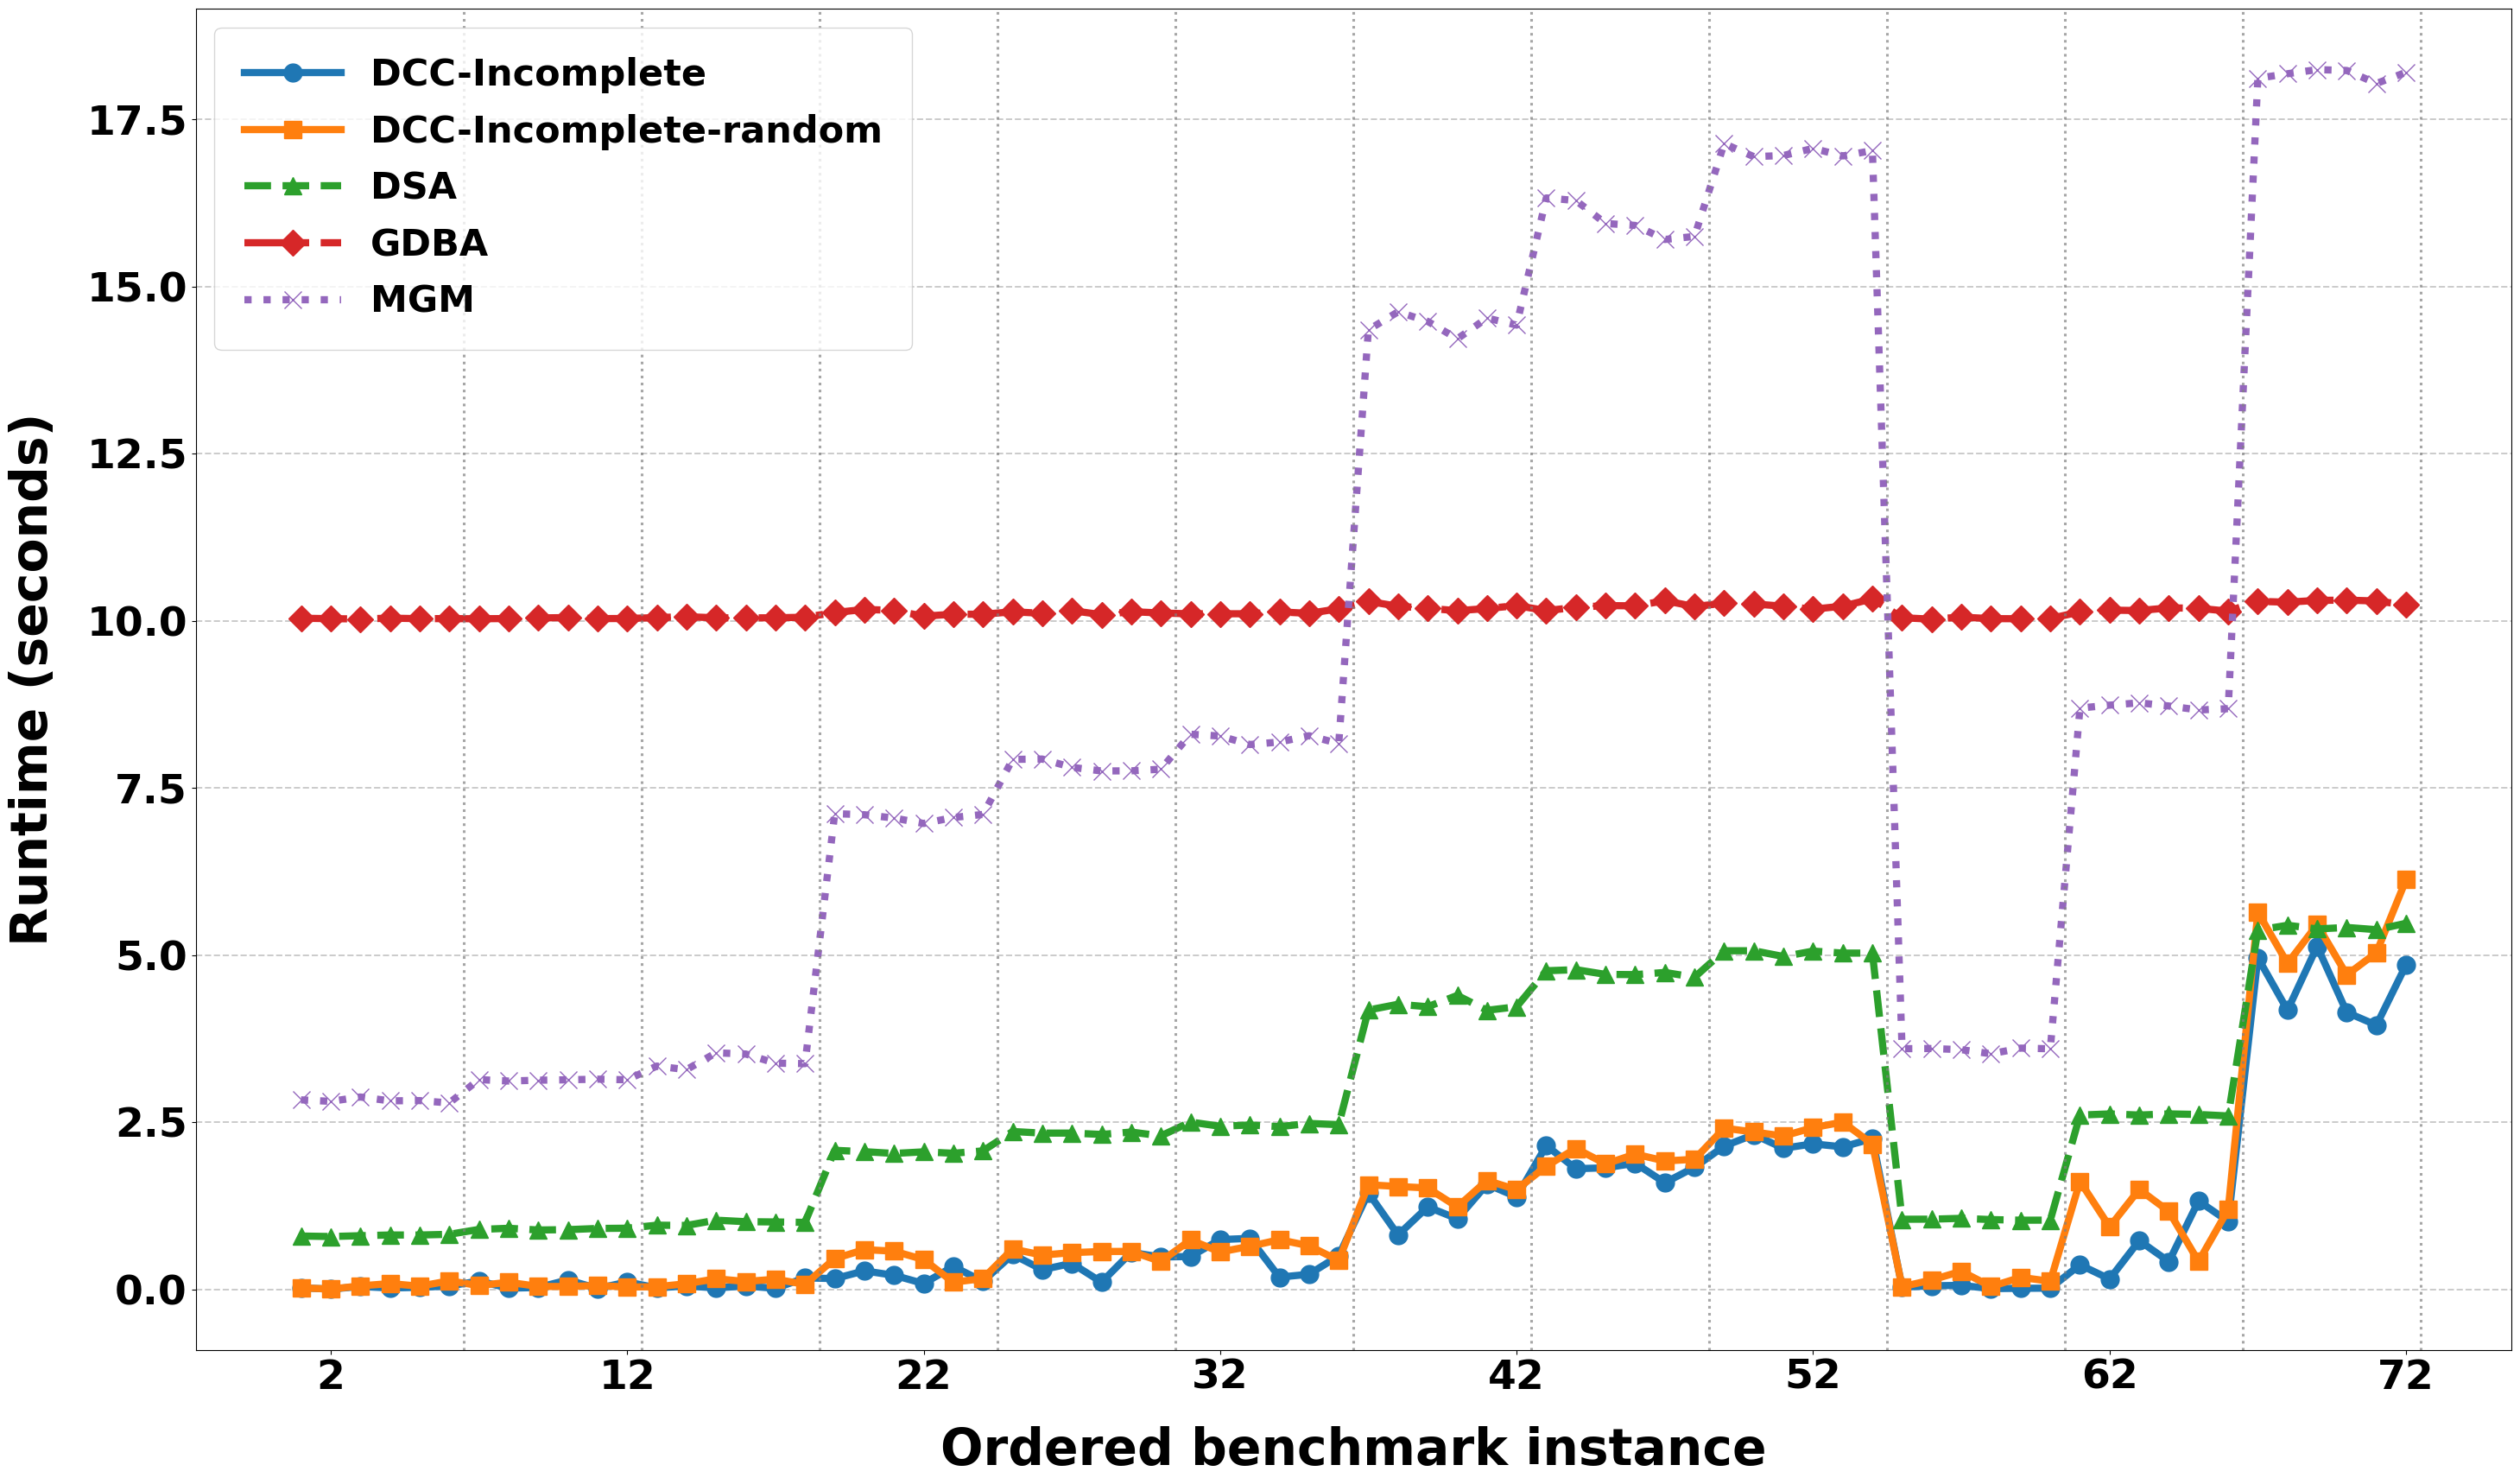

Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\iterations_and_cycles_across_benchmark_instances.png
  final_paper1_comparison\plots_individual_extra_large_no_title\iterations_and_cycles_across_benchmark_instances.pdf


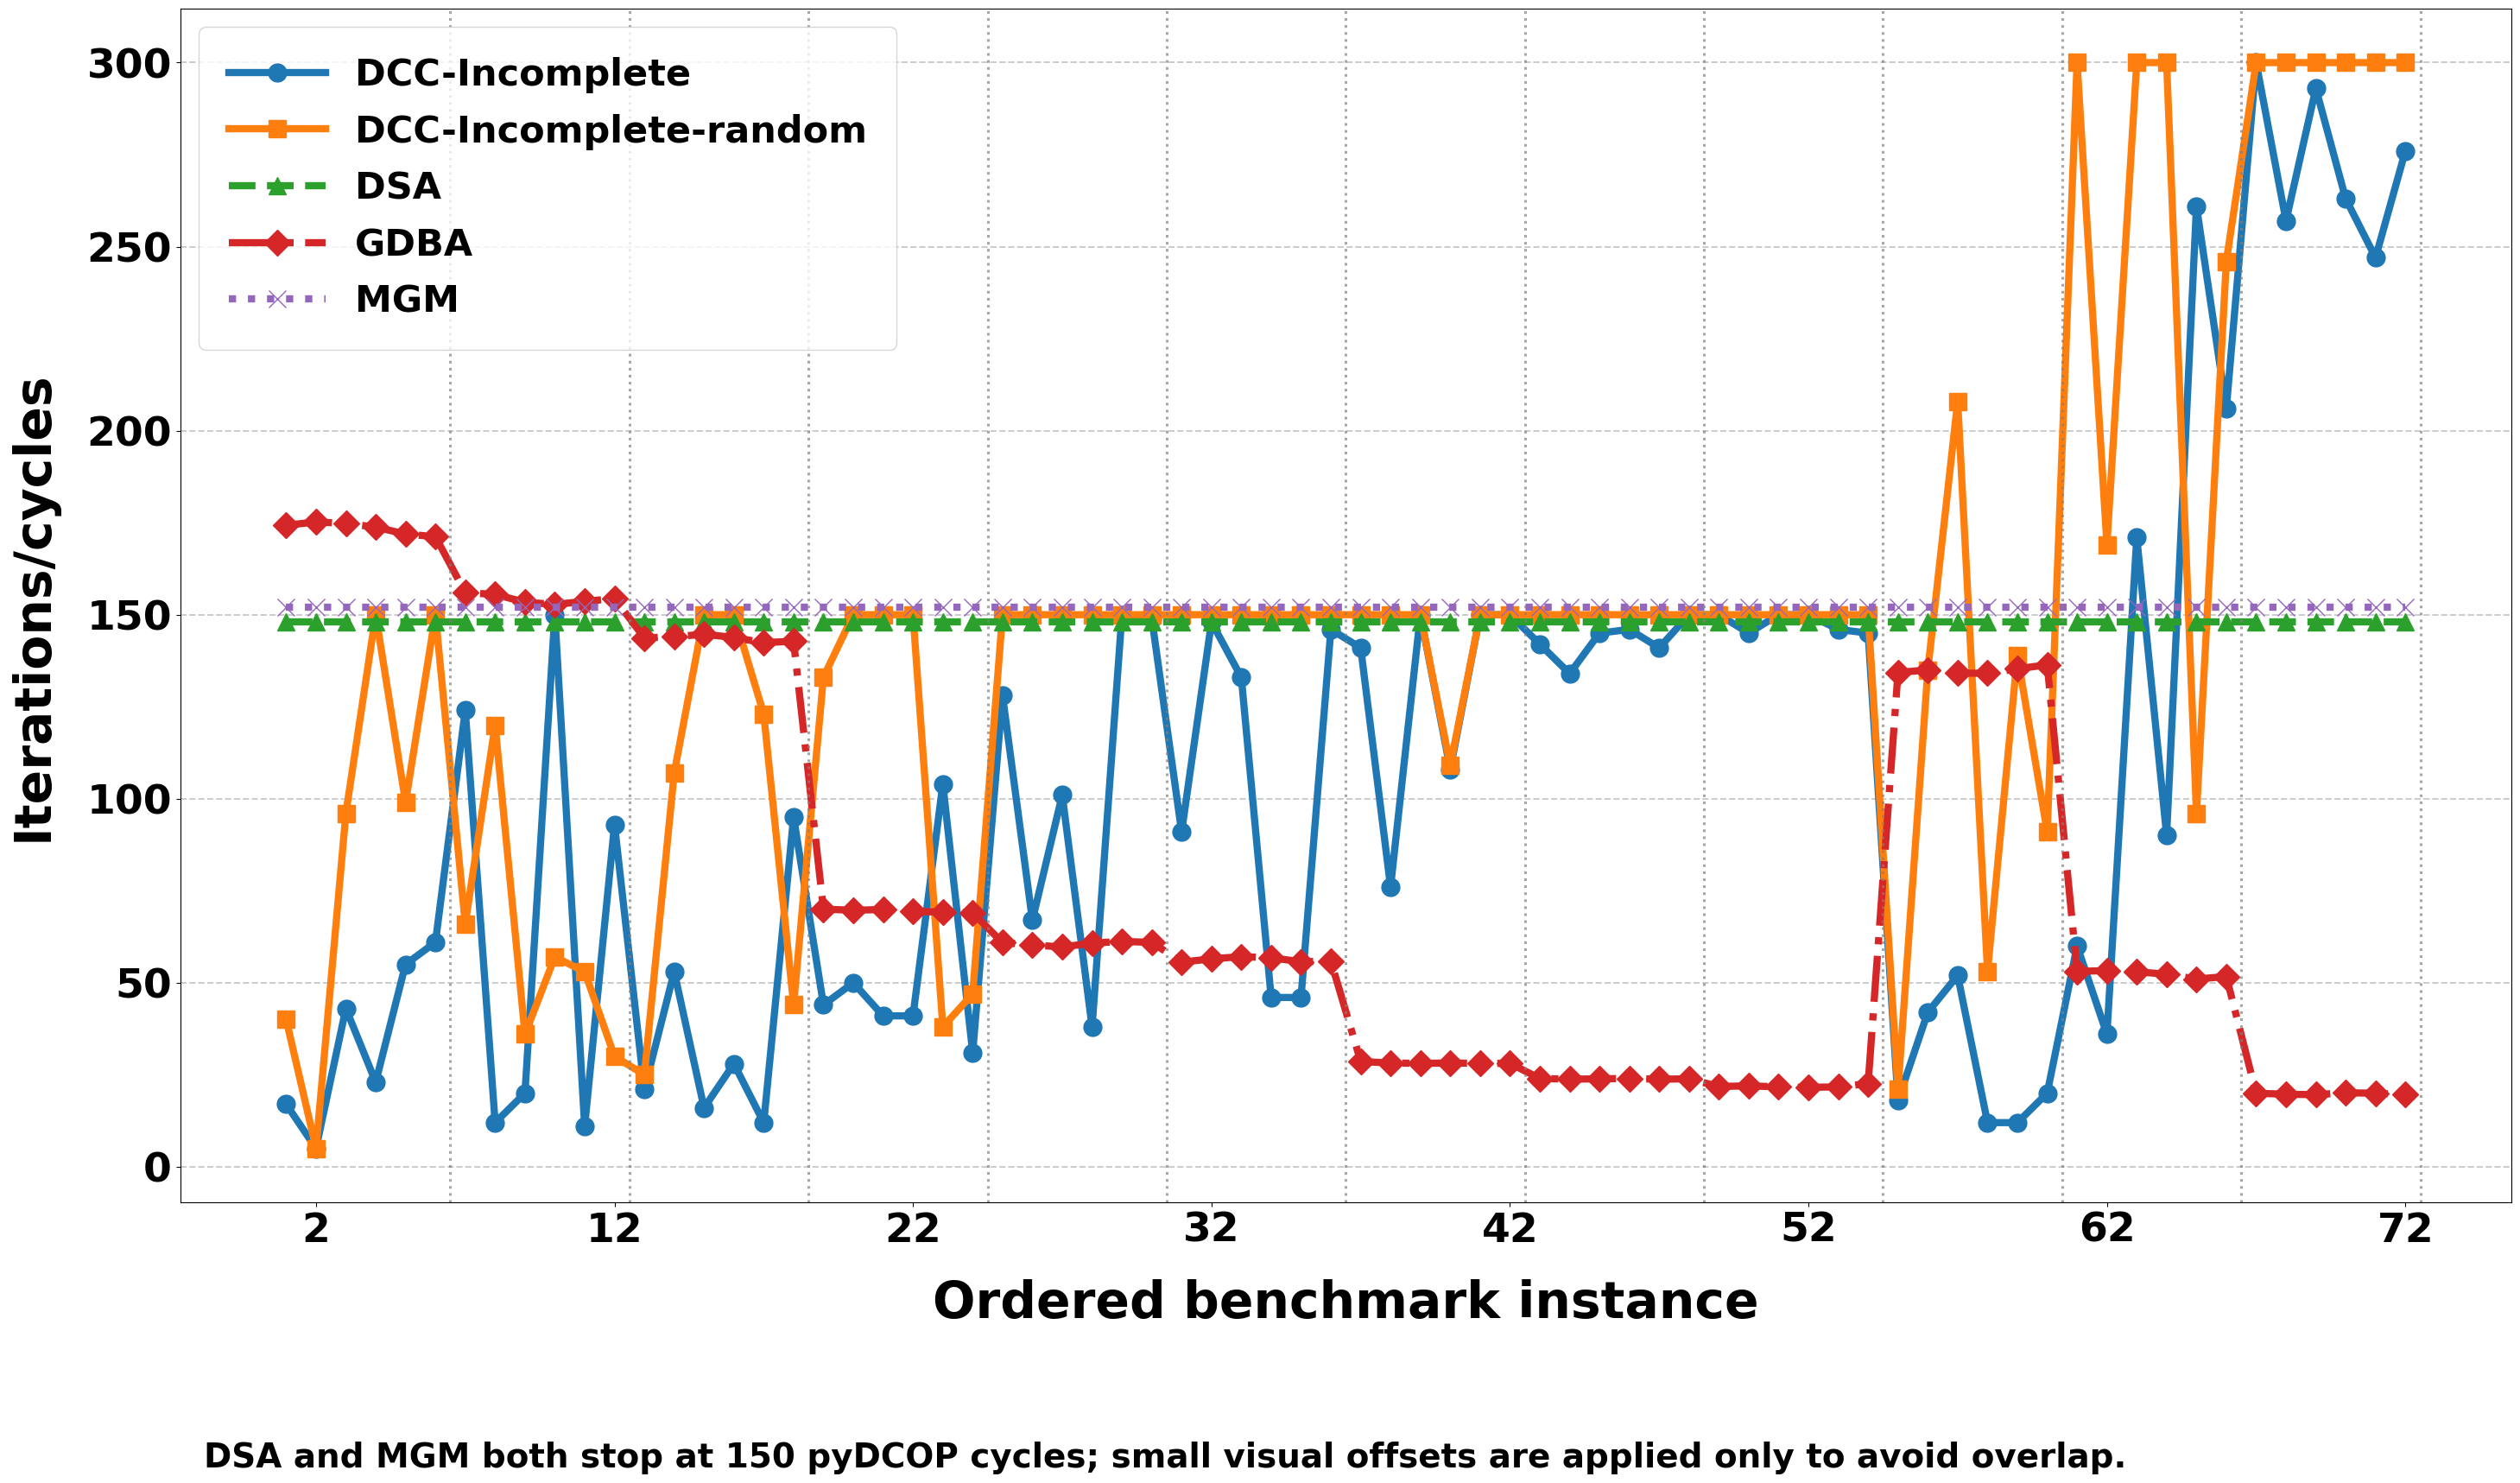

Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\total_messages_across_benchmark_instances.png
  final_paper1_comparison\plots_individual_extra_large_no_title\total_messages_across_benchmark_instances.pdf


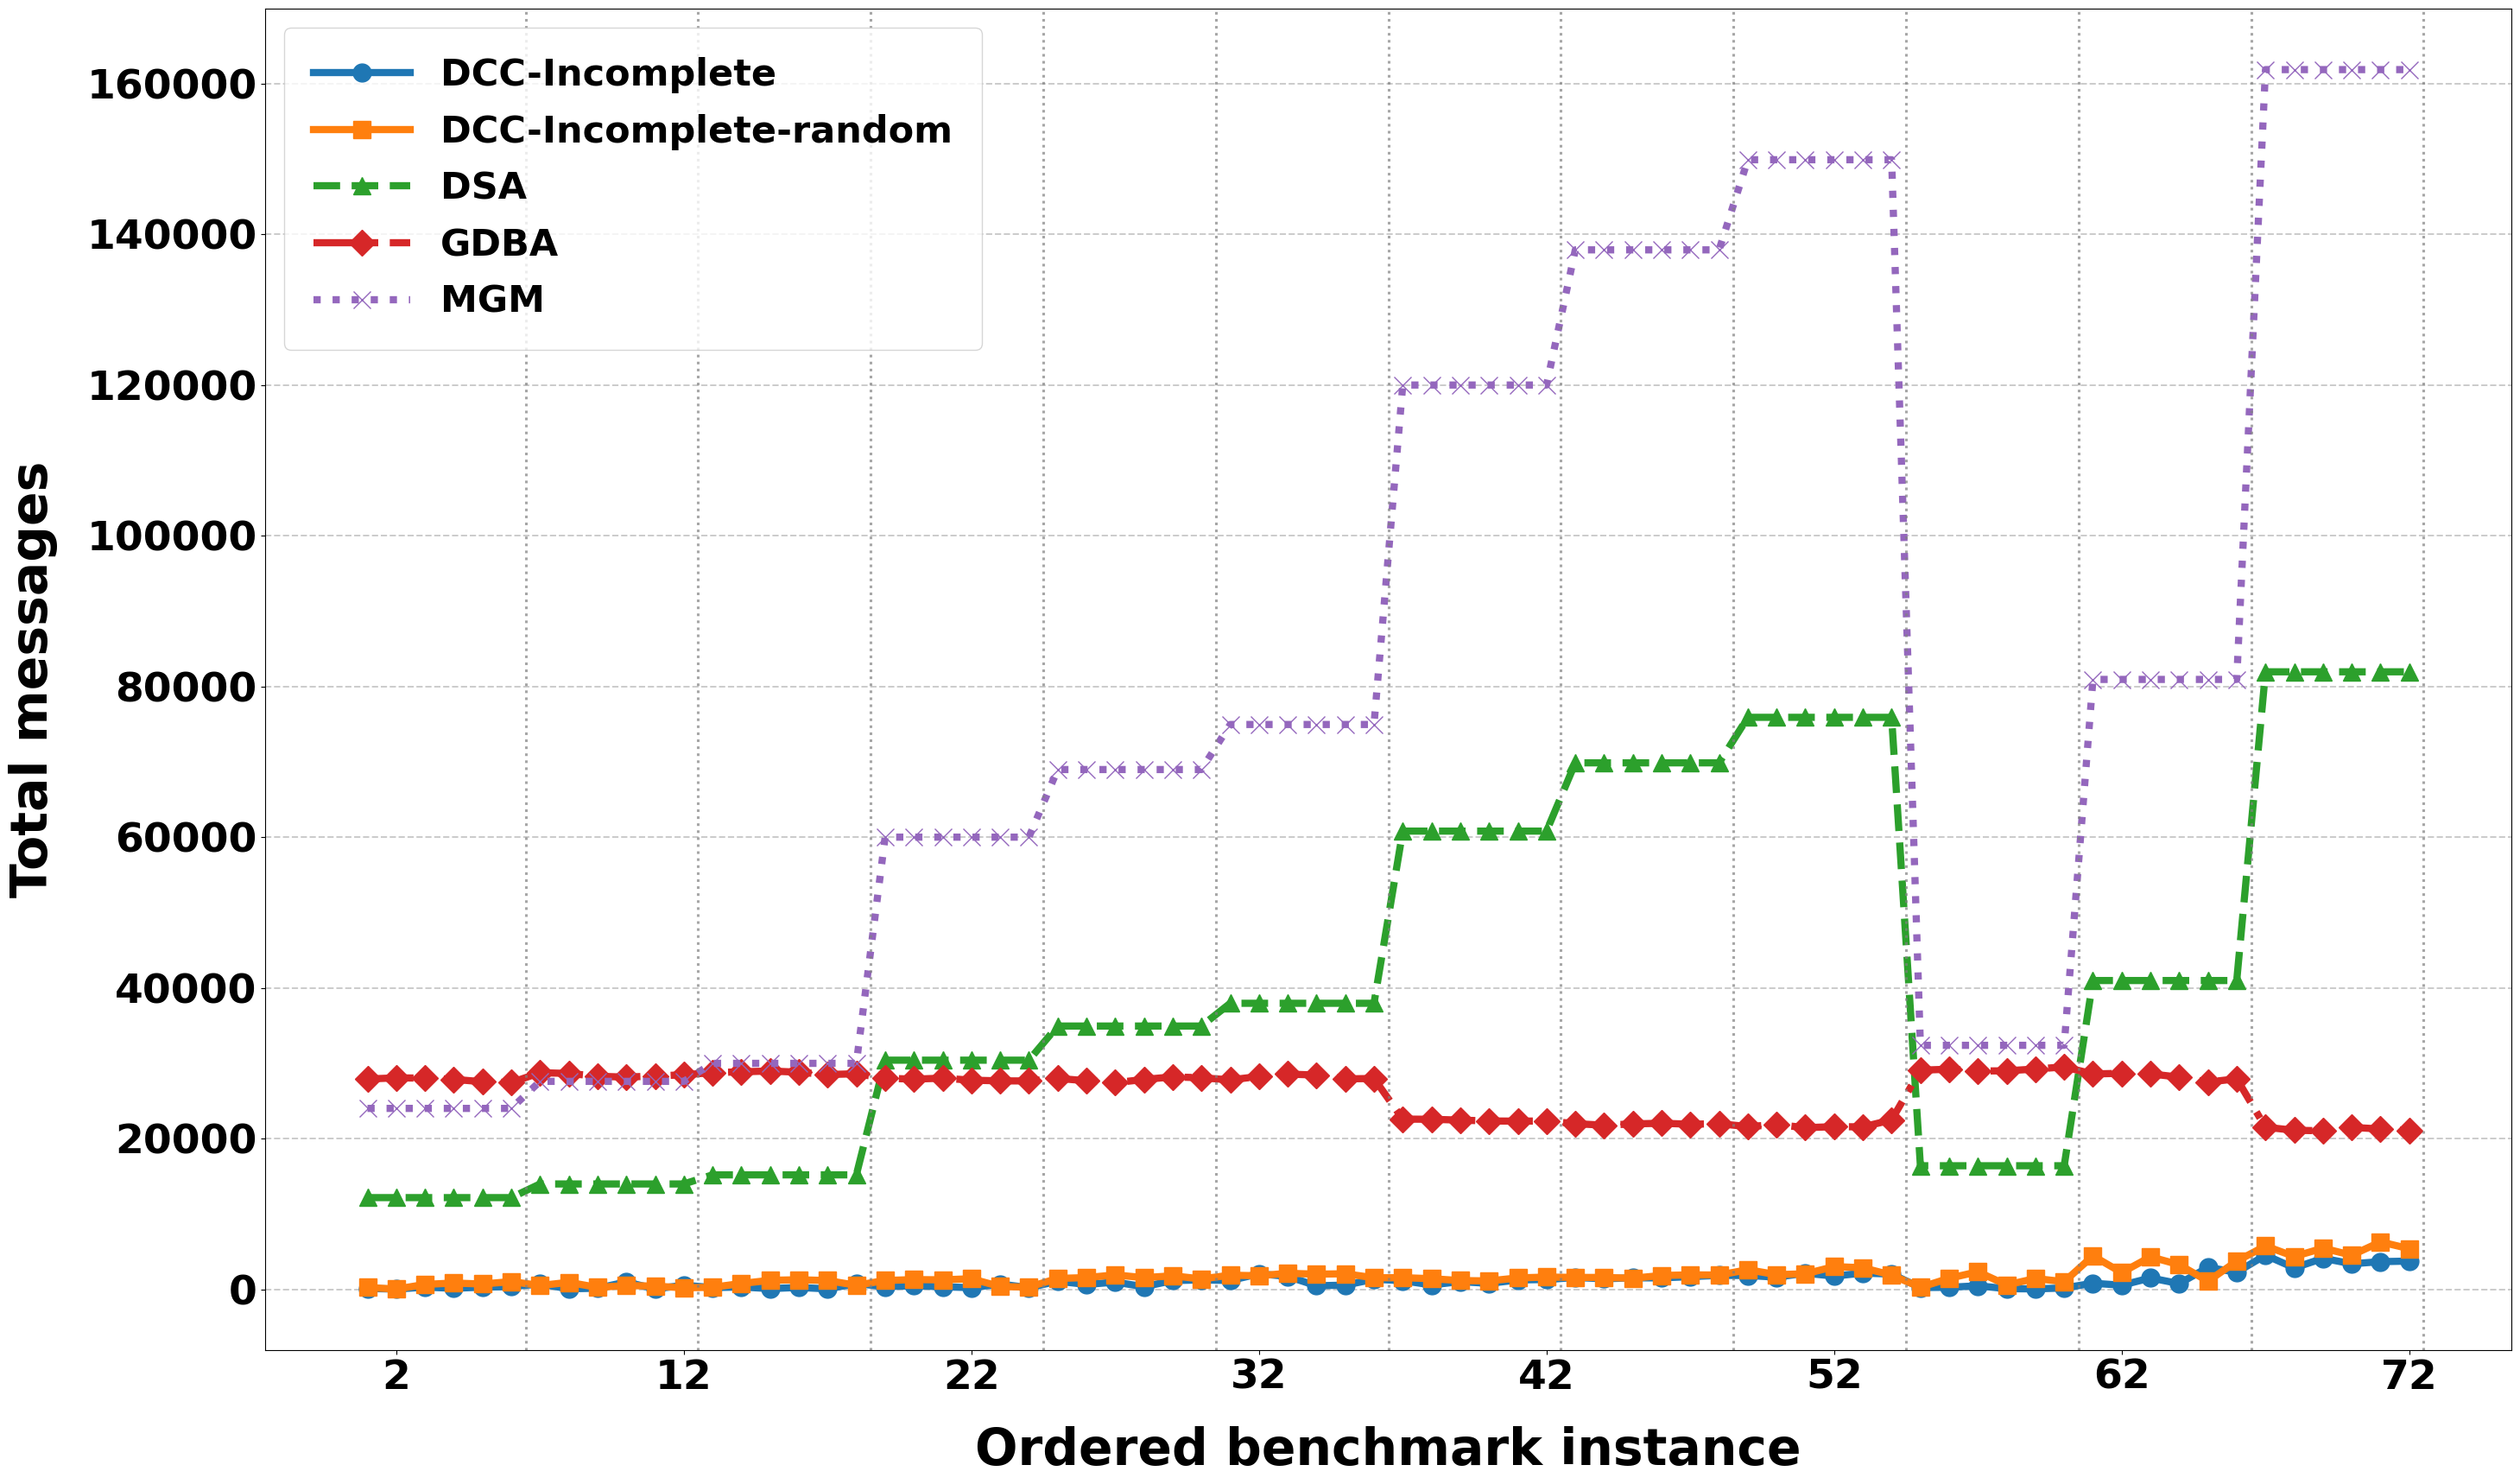

Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\messages_per_variable_across_benchmark_instances.png
  final_paper1_comparison\plots_individual_extra_large_no_title\messages_per_variable_across_benchmark_instances.pdf


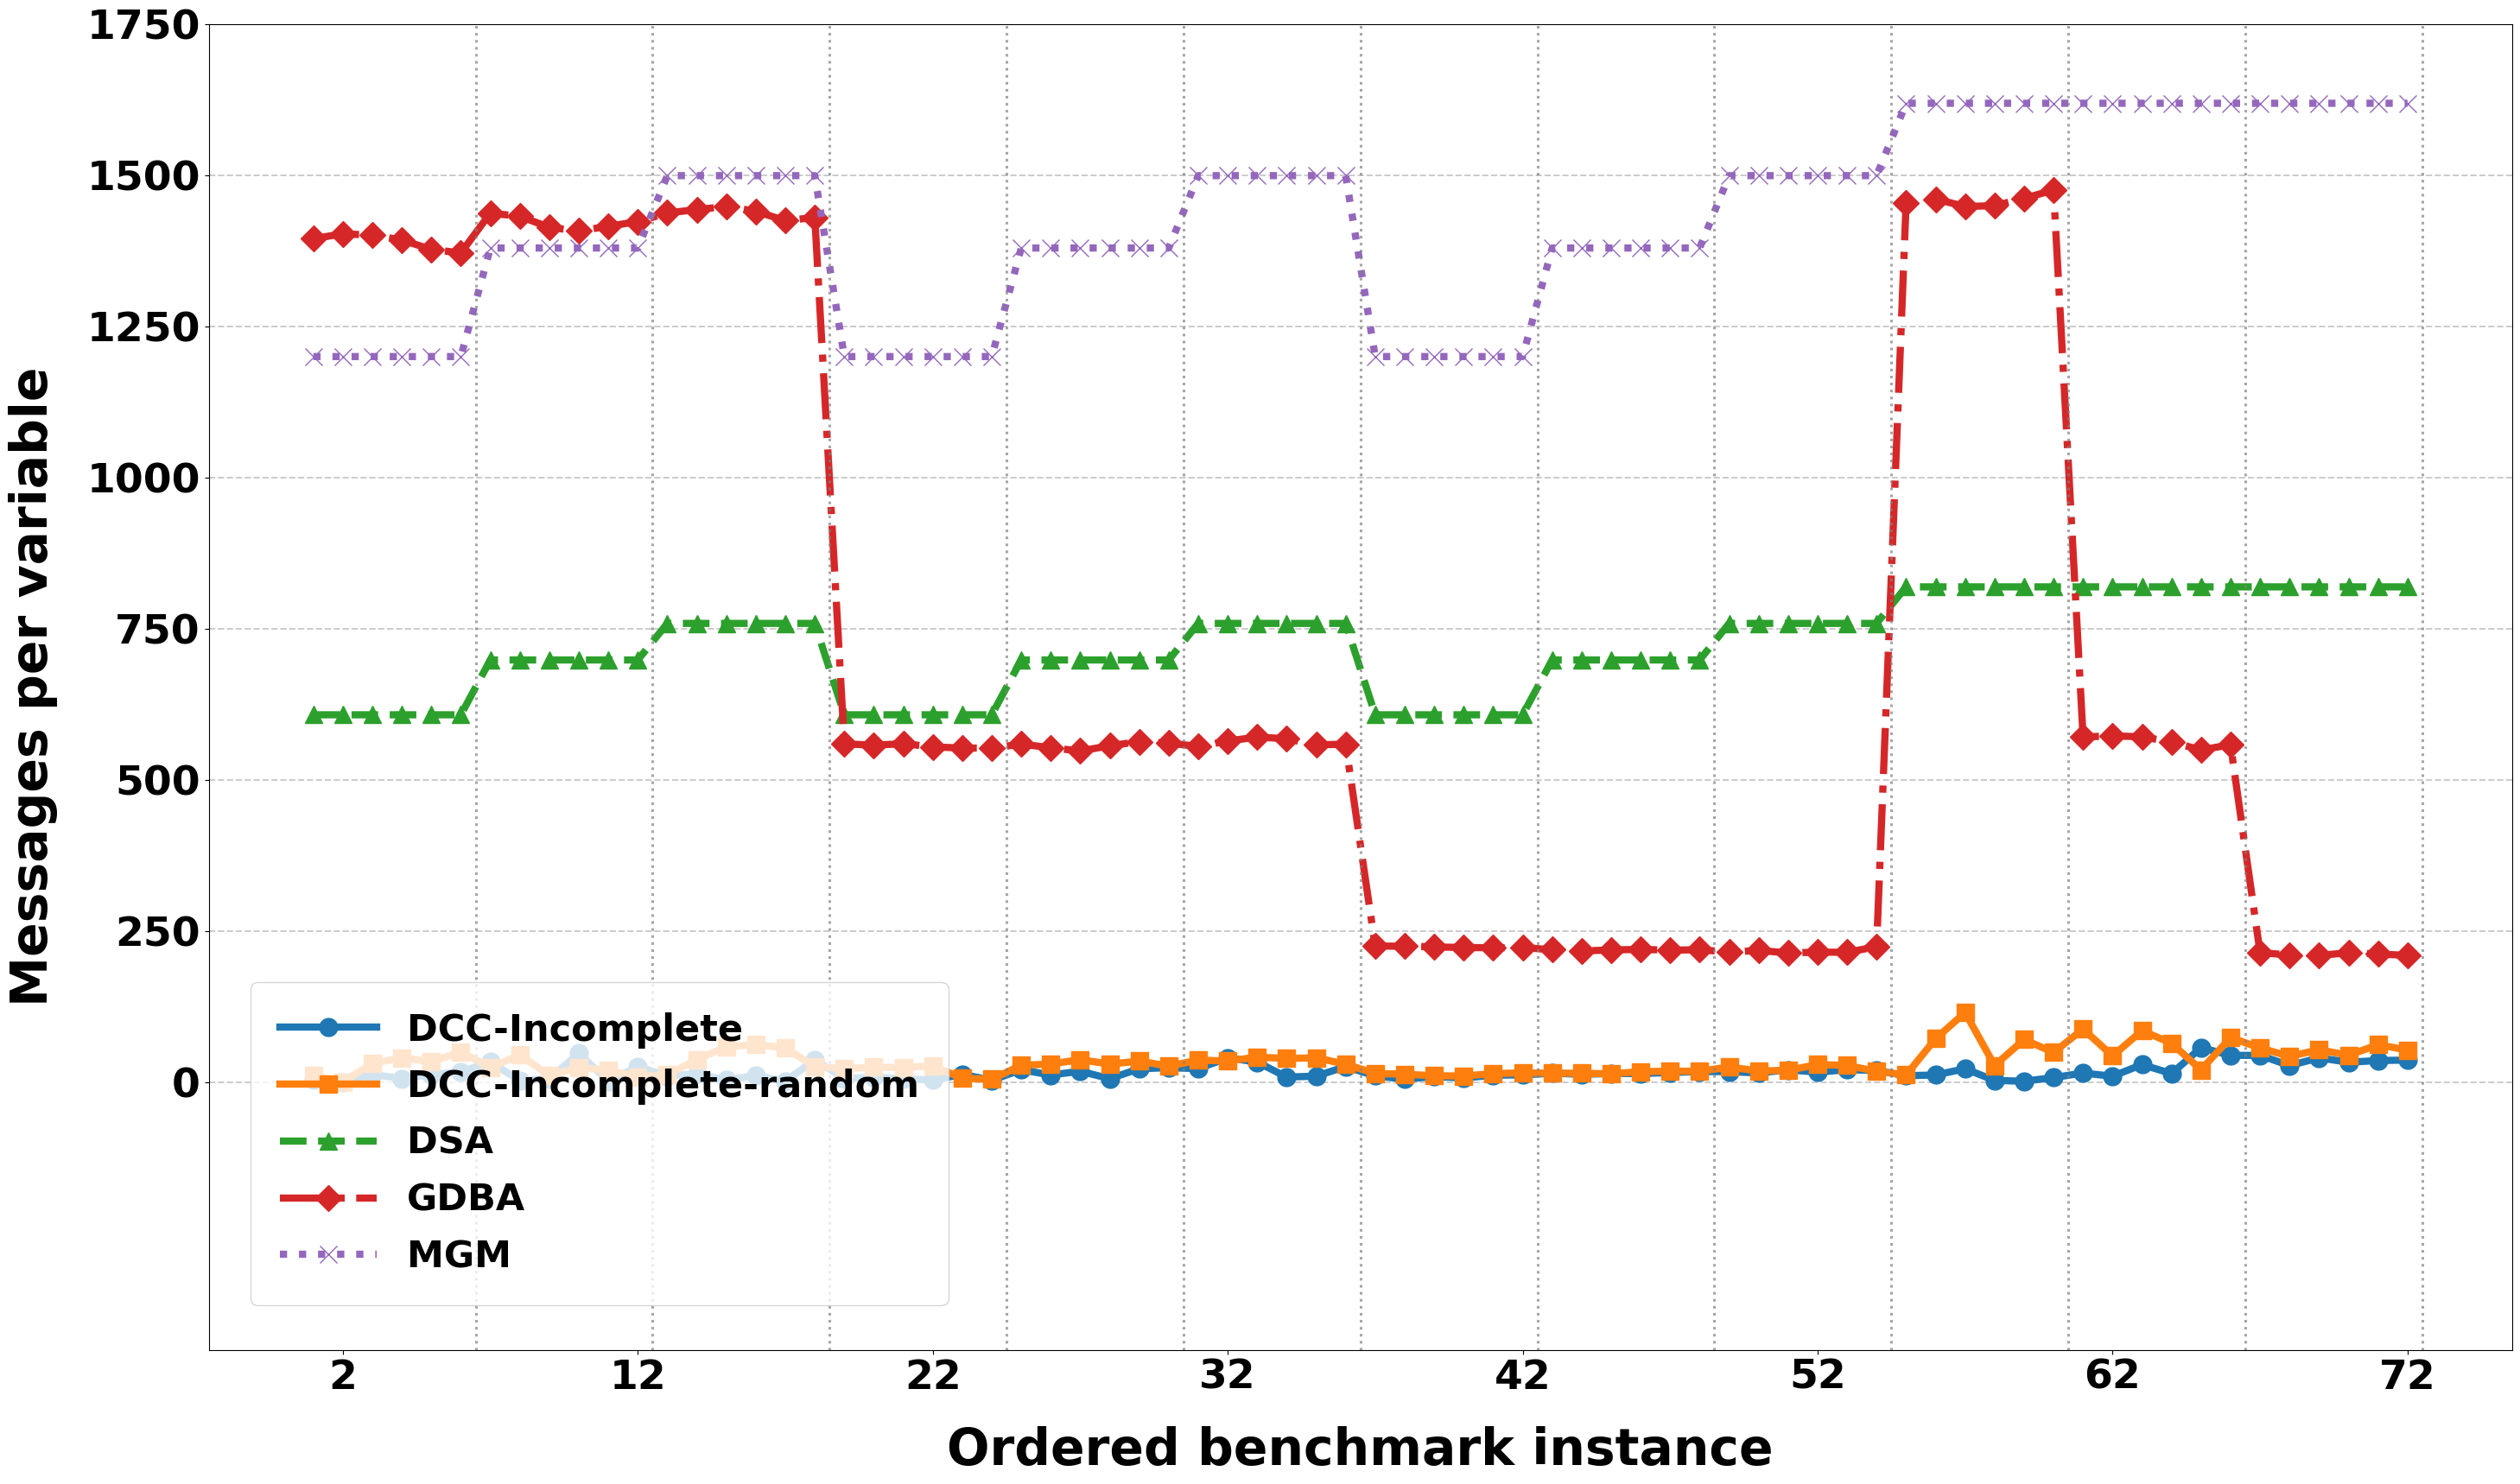

Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\messages_per_constraint_across_benchmark_instances.png
  final_paper1_comparison\plots_individual_extra_large_no_title\messages_per_constraint_across_benchmark_instances.pdf


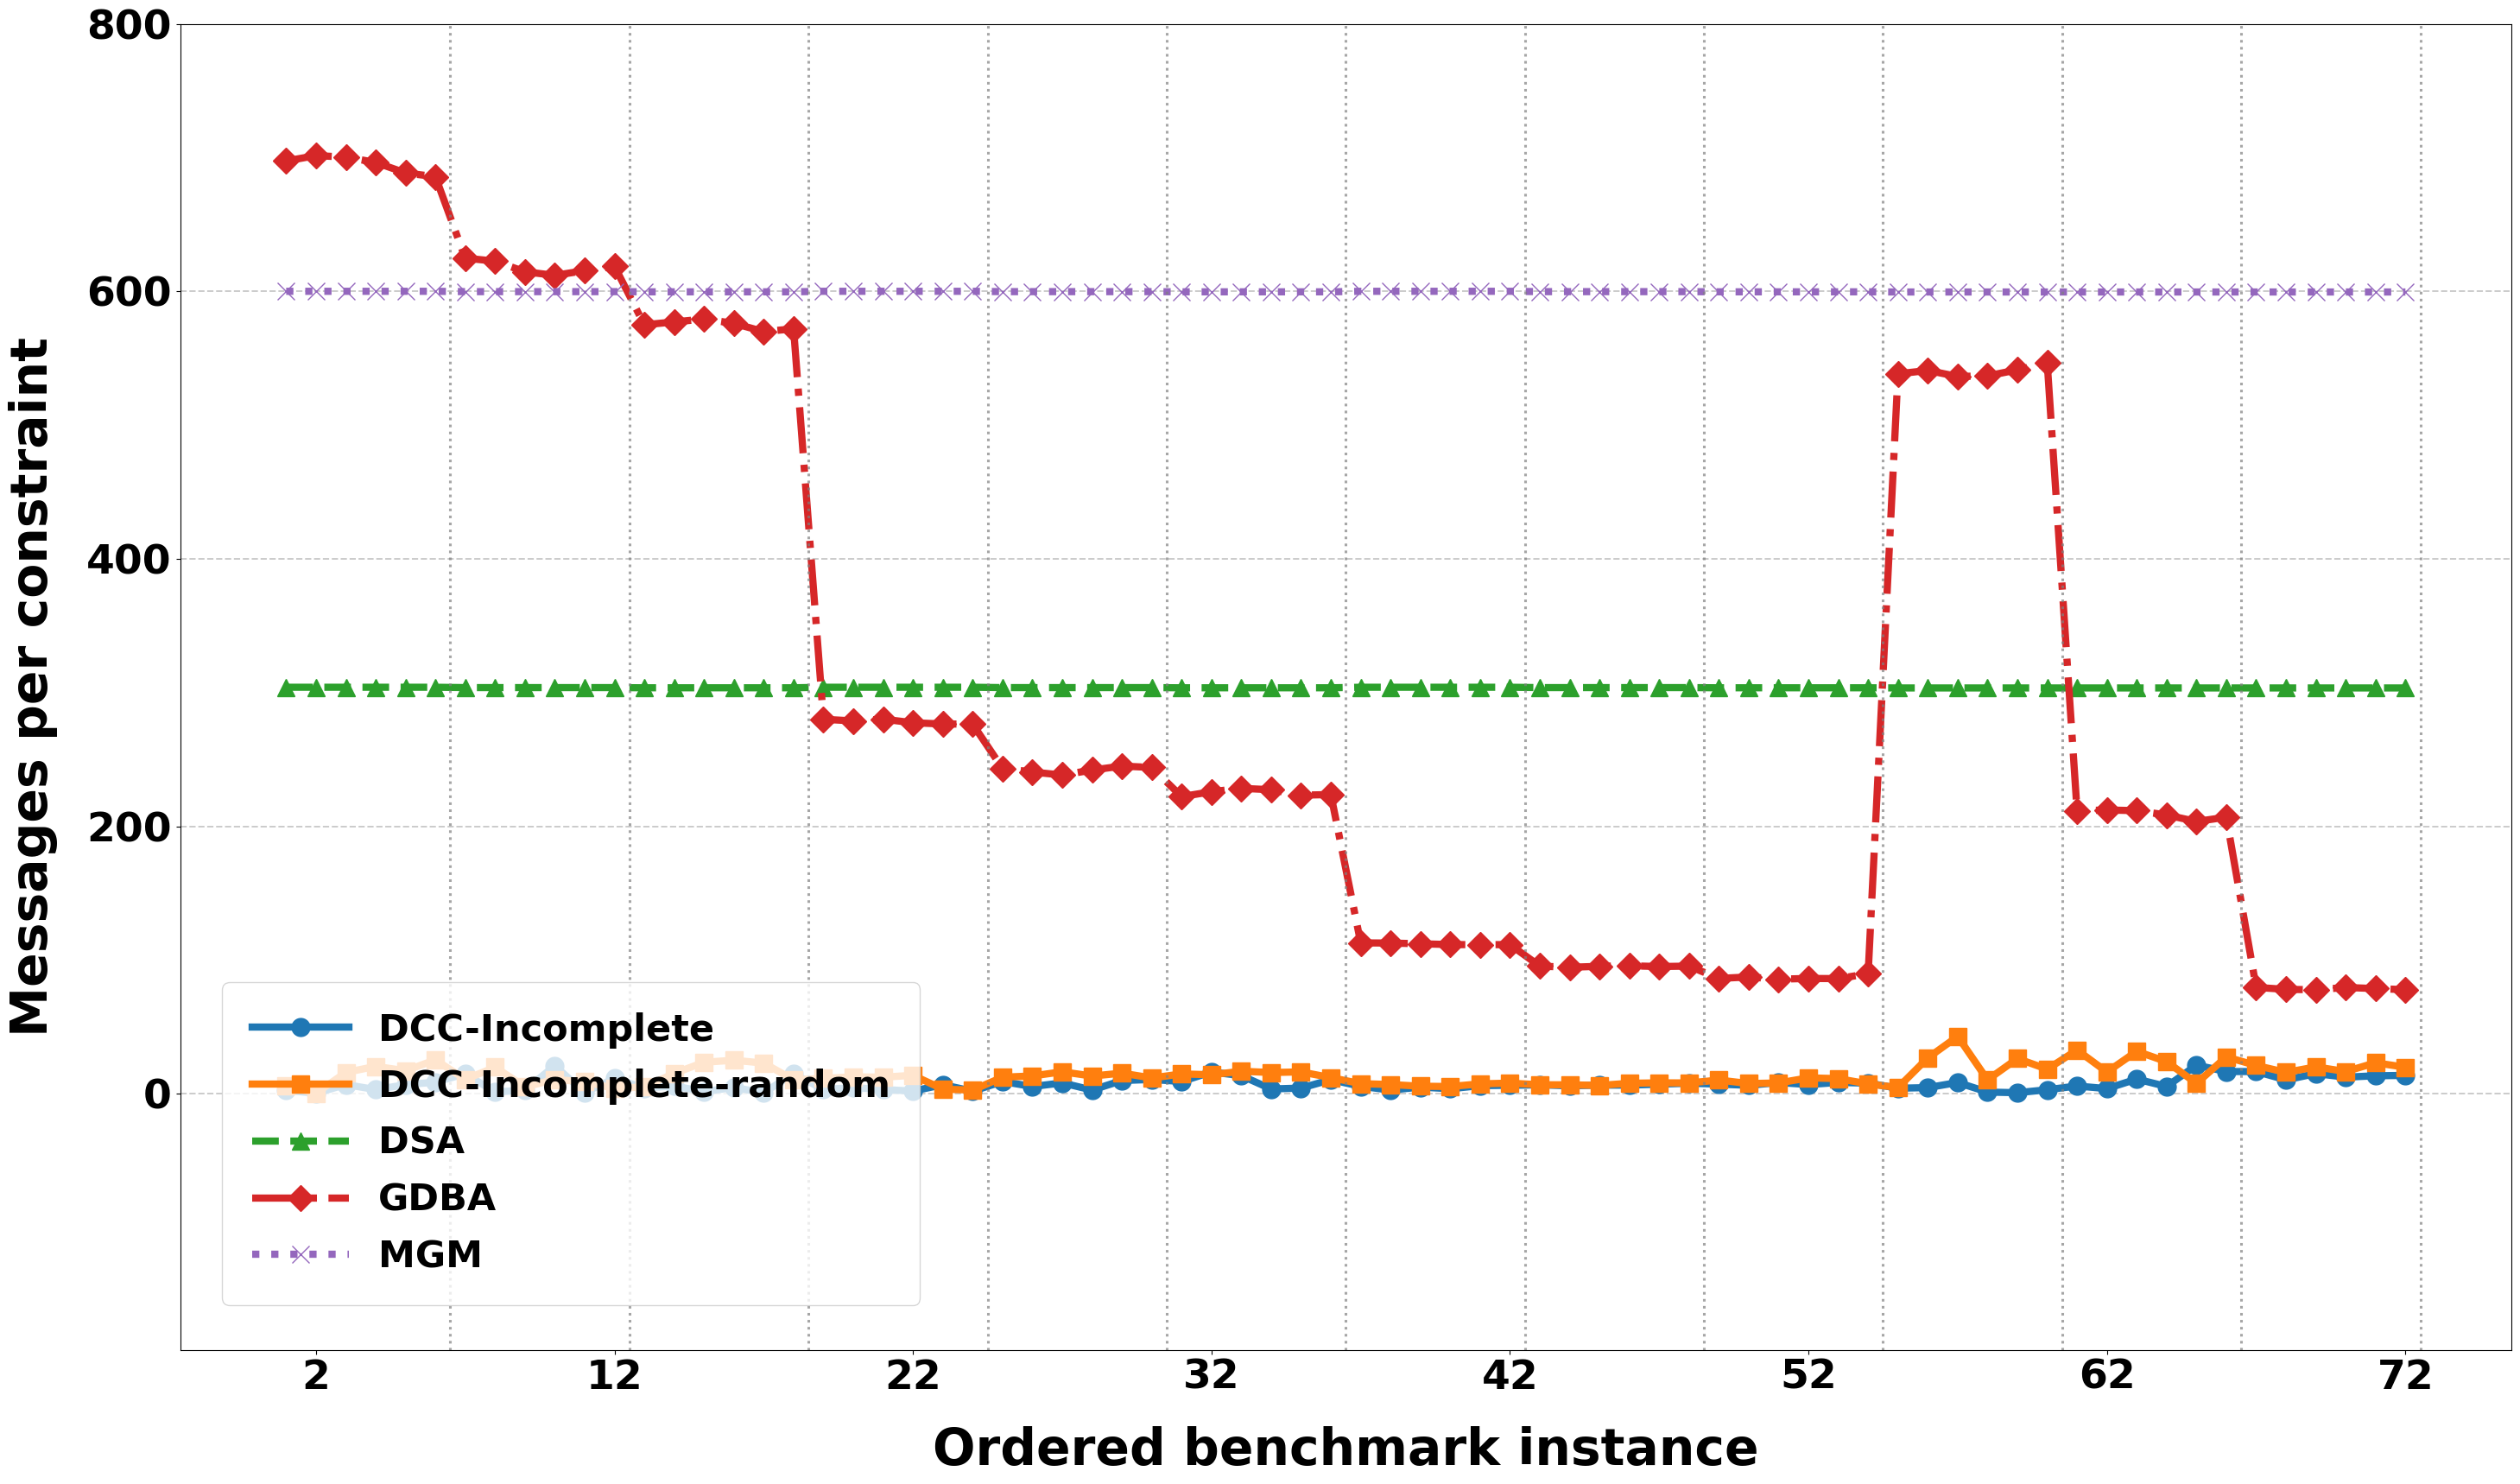

Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\final_cost_across_benchmark_instances.png
  final_paper1_comparison\plots_individual_extra_large_no_title\final_cost_across_benchmark_instances.pdf


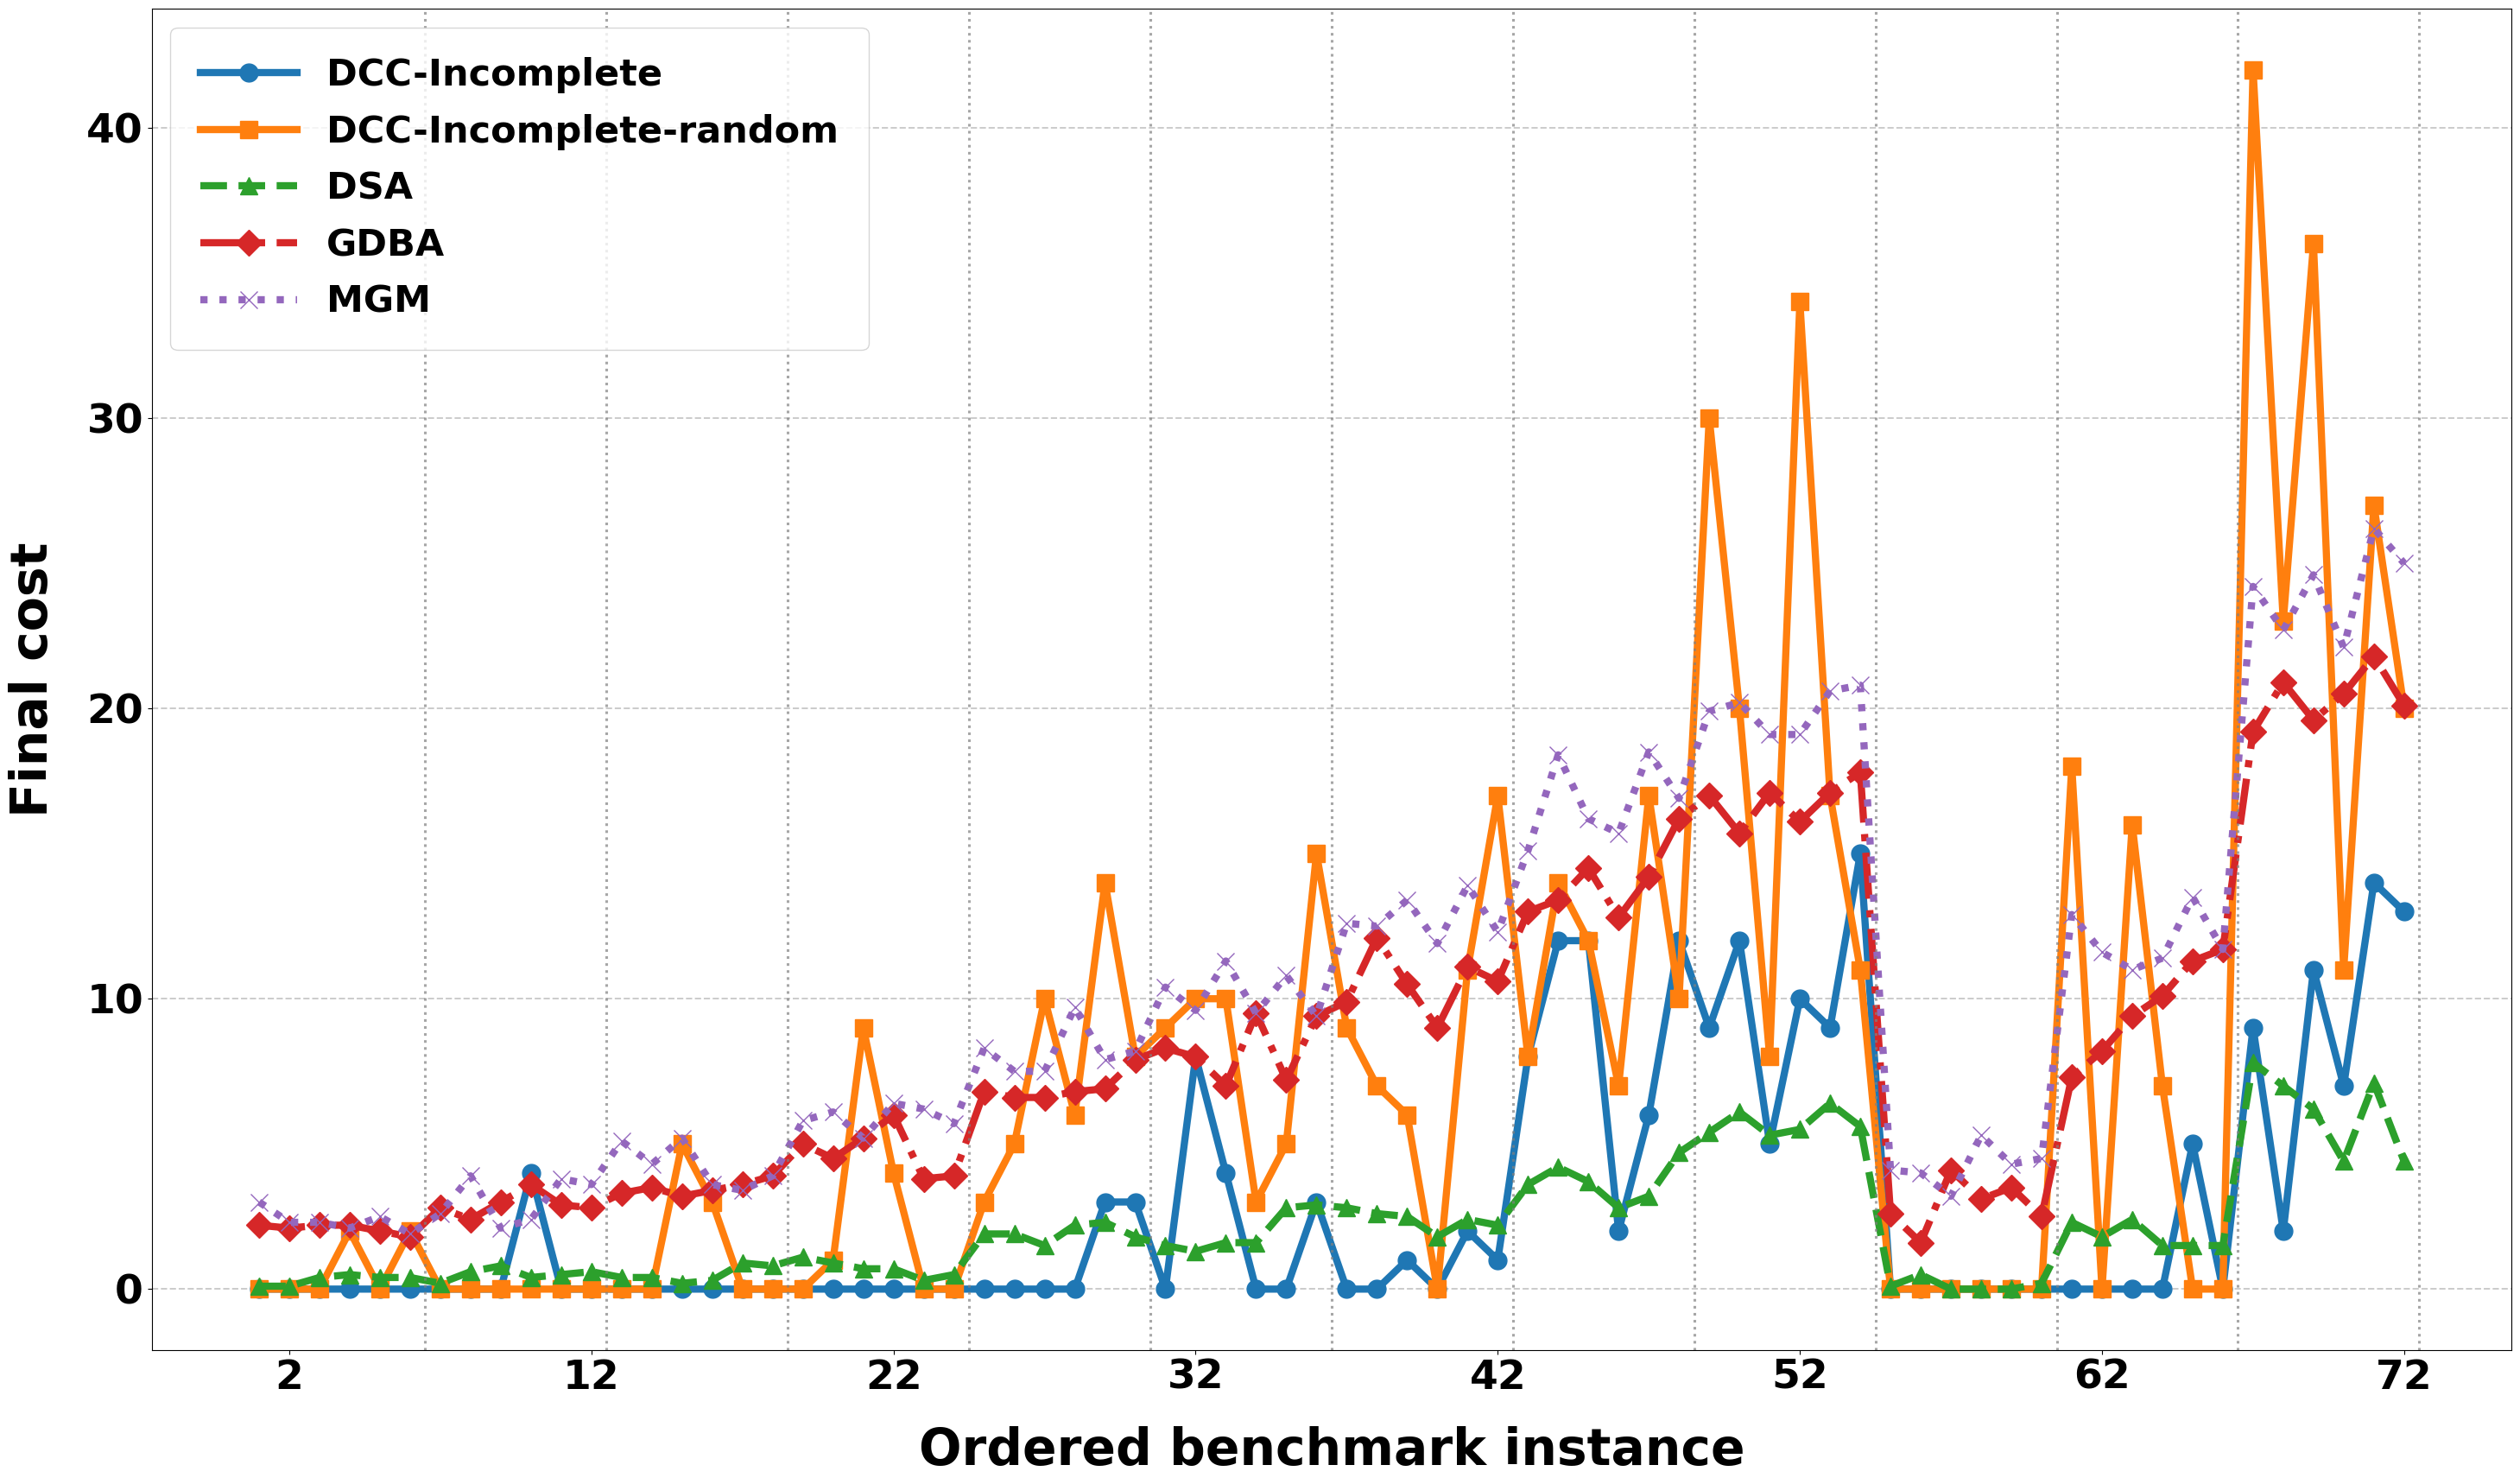

Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\success_rate_by_benchmark_instance.png
  final_paper1_comparison\plots_individual_extra_large_no_title\success_rate_by_benchmark_instance.pdf


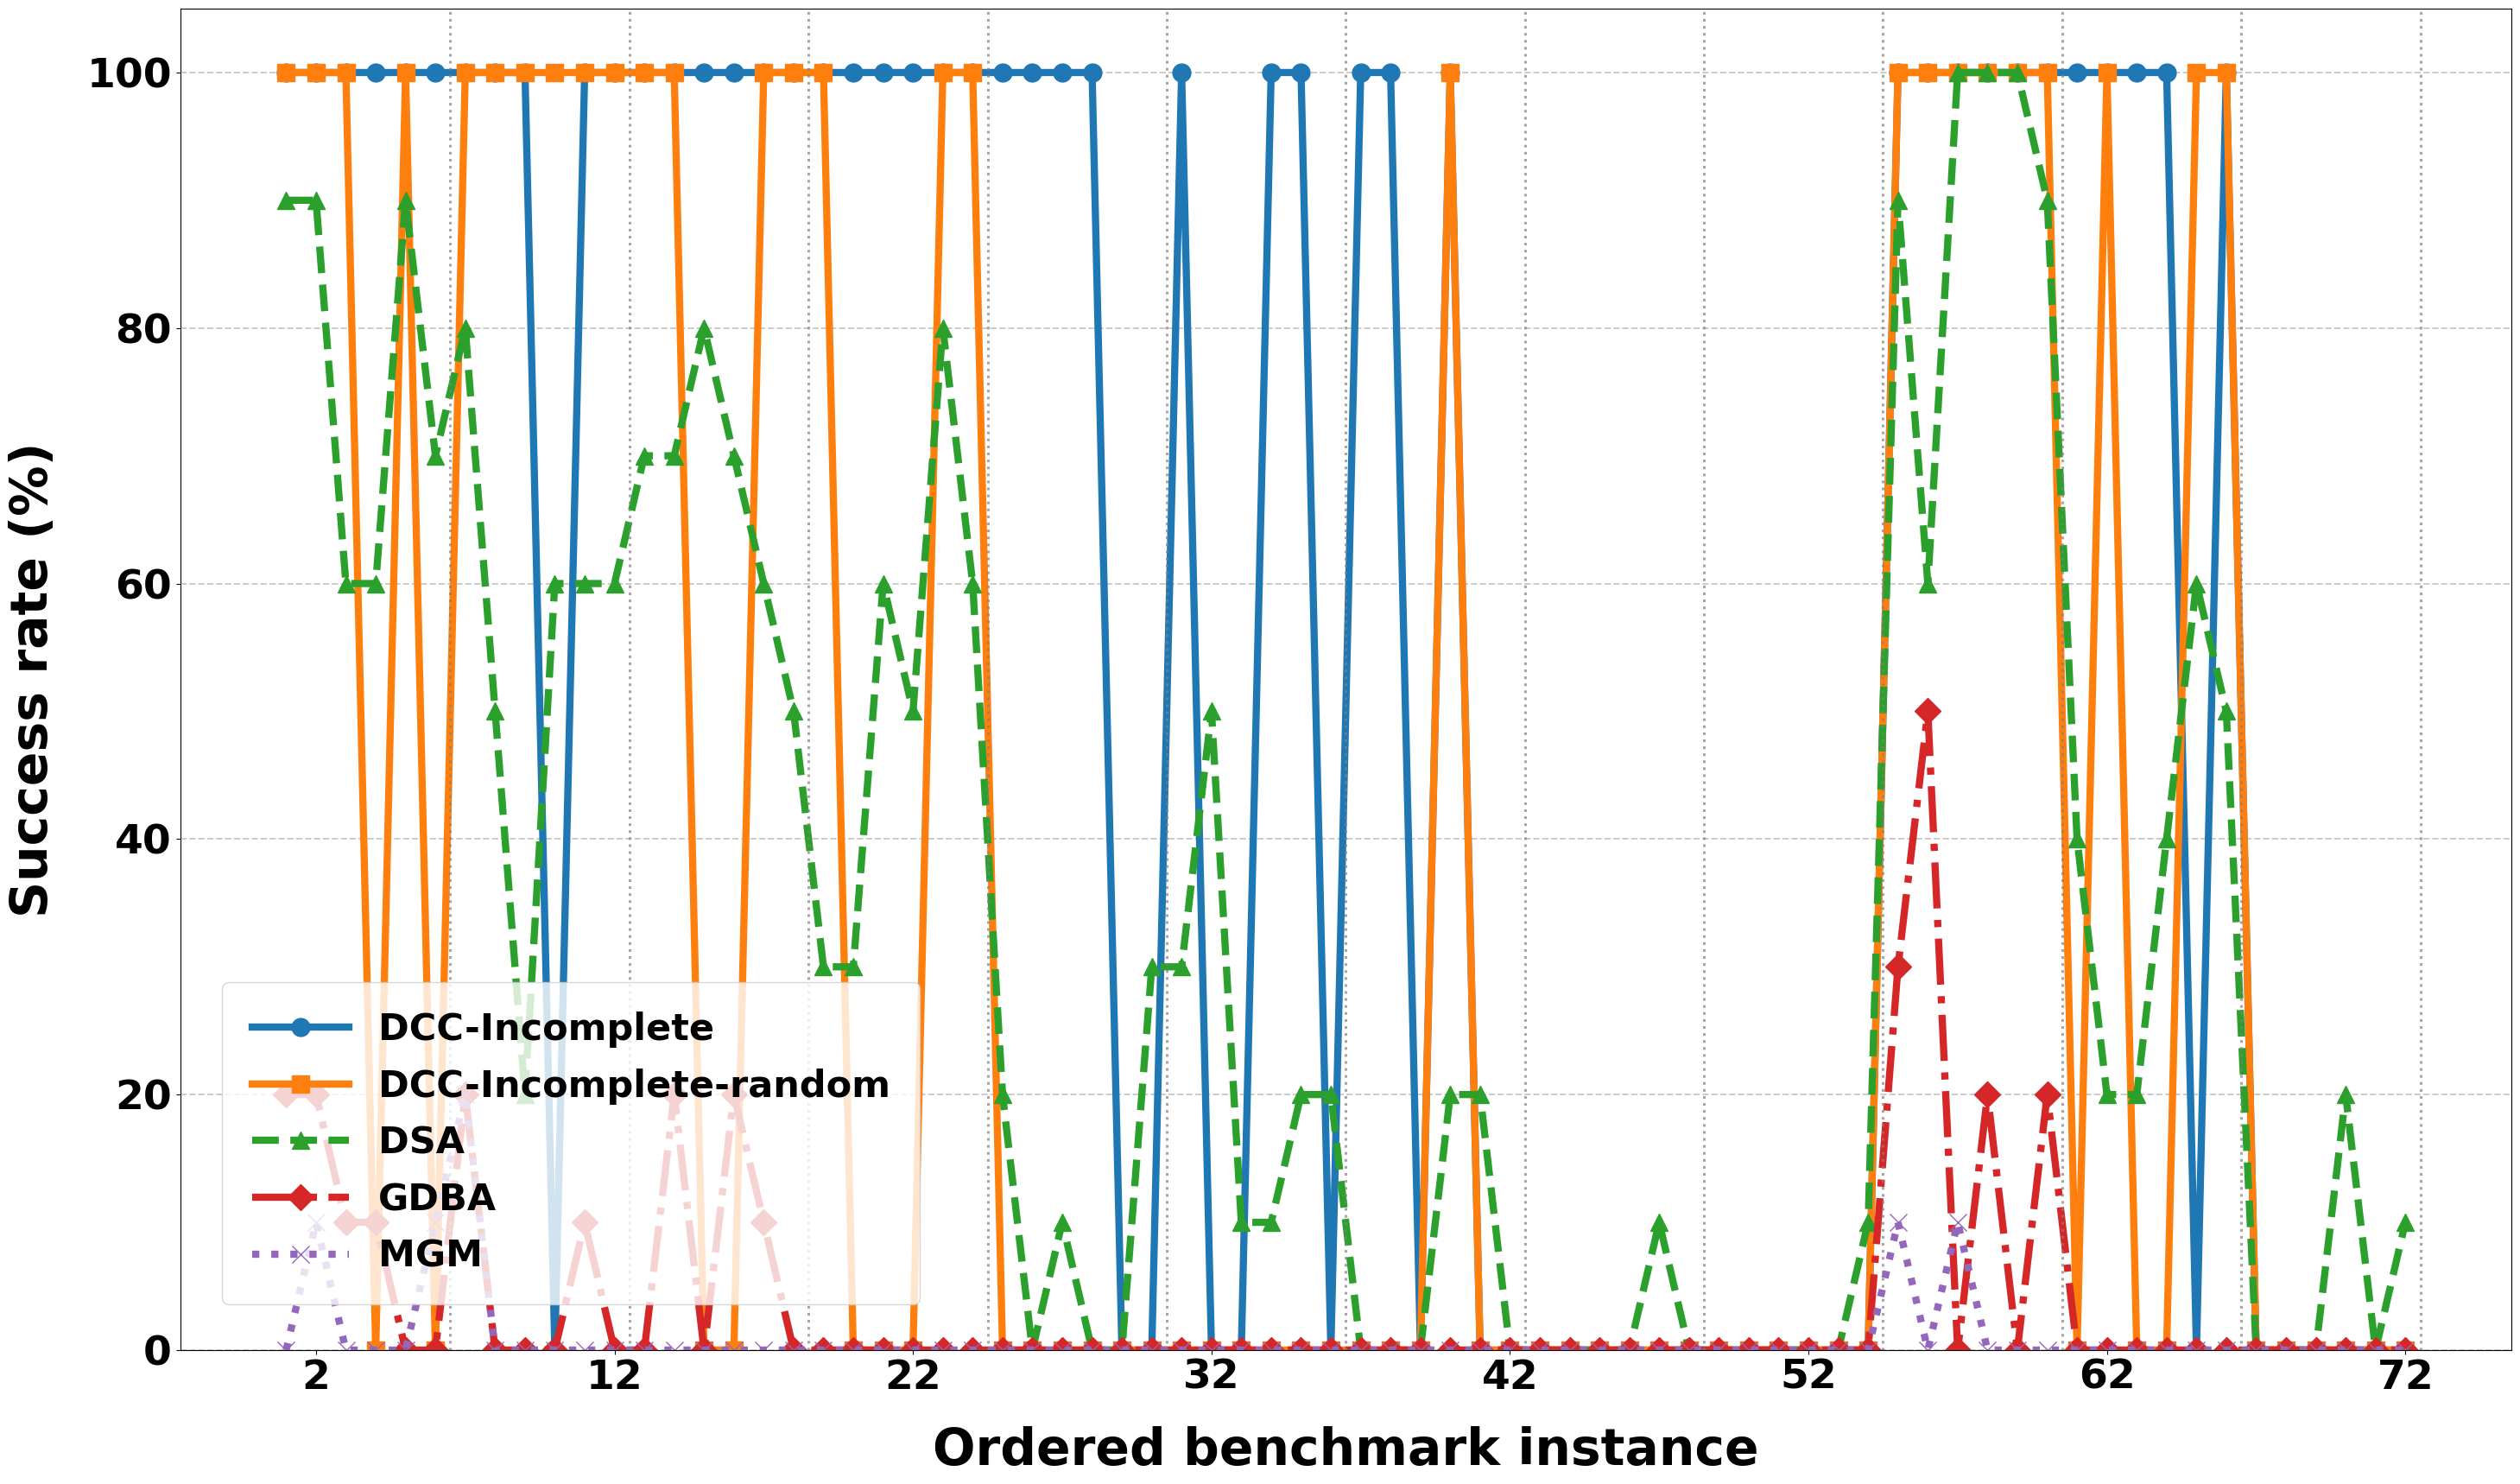

Saved:
  final_paper1_comparison\plots_individual_extra_large_no_title\cumulative_success_rate_across_benchmark_instances.png
  final_paper1_comparison\plots_individual_extra_large_no_title\cumulative_success_rate_across_benchmark_instances.pdf


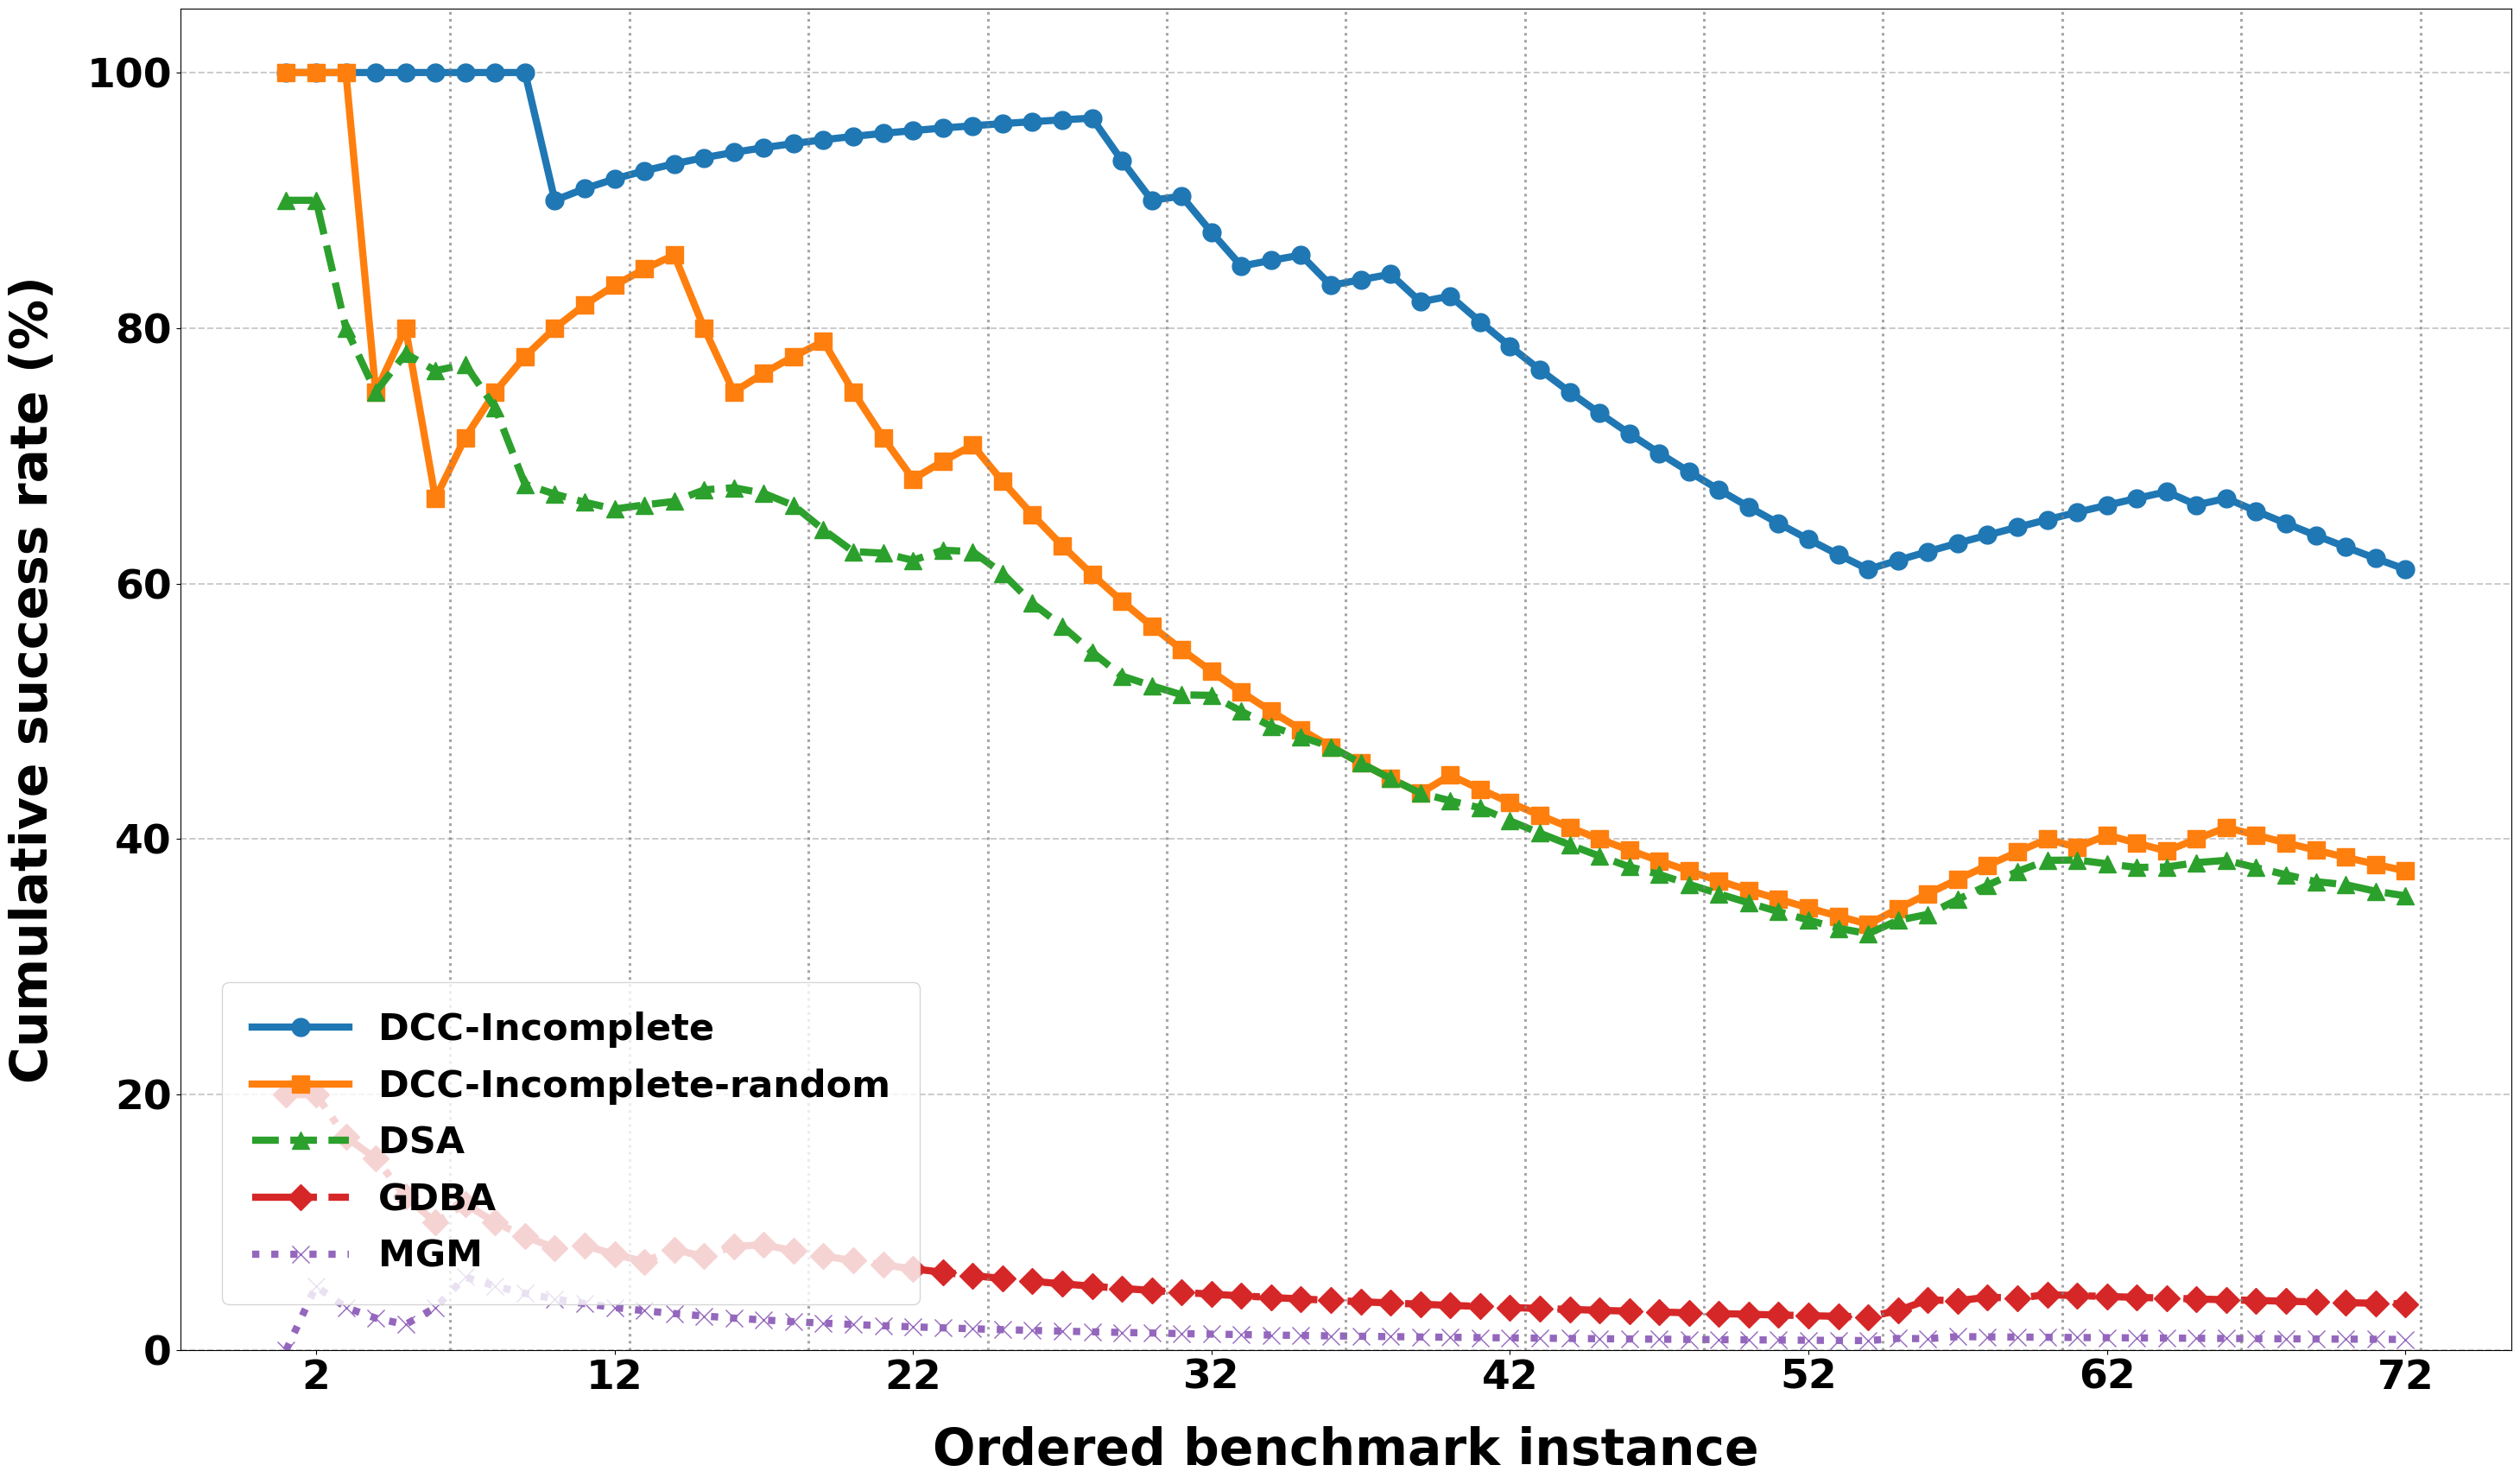


All separate charts have been saved in:
final_paper1_comparison\plots_individual_extra_large_no_title

Saved files:
final_paper1_comparison\plots_individual_extra_large_no_title\cumulative_success_rate_across_benchmark_instances.pdf
final_paper1_comparison\plots_individual_extra_large_no_title\cumulative_success_rate_across_benchmark_instances.png
final_paper1_comparison\plots_individual_extra_large_no_title\final_cost_across_benchmark_instances.pdf
final_paper1_comparison\plots_individual_extra_large_no_title\final_cost_across_benchmark_instances.png
final_paper1_comparison\plots_individual_extra_large_no_title\iterations_and_cycles_across_benchmark_instances.pdf
final_paper1_comparison\plots_individual_extra_large_no_title\iterations_and_cycles_across_benchmark_instances.png
final_paper1_comparison\plots_individual_extra_large_no_title\messages_per_constraint.pdf
final_paper1_comparison\plots_individual_extra_large_no_title\messages_per_constraint.png
final_paper1_comparison\plots_i

In [125]:
# ============================================================
# FINAL STEP — EXPORT EACH COMPARISON CHART SEPARATELY
# Very large bold fonts + no chart titles
#
# Legend updates:
#   - Messages per variable: legend inside, lower-left empty area
#   - Messages per constraint: legend inside, lower-left empty area
#   - Solved/unsolved status: legend shifted slightly down
#
# Input:
#   final_paper1_comparison/final_paper1_chart_input_10exec.csv
#
# Outputs:
#   final_paper1_comparison/plots_individual_extra_large_no_title/
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import re


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

FINAL_COMPARISON_DIR = Path("final_paper1_comparison")
PLOTS_DIR = FINAL_COMPARISON_DIR / "plots_individual_extra_large_no_title"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

final_raw_path = FINAL_COMPARISON_DIR / "final_paper1_chart_input_10exec.csv"

print("Input raw file:")
print(final_raw_path)

print("\nIndividual chart output directory:")
print(PLOTS_DIR)


# ------------------------------------------------------------
# Load final raw data
# ------------------------------------------------------------

raw = pd.read_csv(final_raw_path)

print("\nLoaded raw shape:", raw.shape)


# ------------------------------------------------------------
# Algorithm-name mapping
# ------------------------------------------------------------

algorithm_name_map = {
    "DCC-Incomplete-memory_guided": "DCC-Incomplete",
    "DCC-Incomplete-random": "DCC-Incomplete-random",
    "pyDCOP-DSA": "DSA",
    "pyDCOP-GDBA": "GDBA",
    "pyDCOP-MGM": "MGM",
}

algorithm_order = [
    "DCC-Incomplete",
    "DCC-Incomplete-random",
    "DSA",
    "GDBA",
    "MGM",
]

raw["method"] = raw["algorithm"].map(
    algorithm_name_map
).fillna(raw["algorithm"])


# ------------------------------------------------------------
# Family order
# ------------------------------------------------------------

benchmark_role_order = {
    "main_comparison": 0,
    "stress_test": 1,
}

family_order_map = {
    "S": 0,
    "M": 1,
    "D": 2,
    "XD": 3,
}


# ------------------------------------------------------------
# Consistent colours, line styles, and markers
# ------------------------------------------------------------

method_colours = {
    "DCC-Incomplete": "tab:blue",
    "DCC-Incomplete-random": "tab:orange",
    "DSA": "tab:green",
    "GDBA": "tab:red",
    "MGM": "tab:purple",
}

line_styles = {
    "DCC-Incomplete": "-",
    "DCC-Incomplete-random": "-",
    "DSA": "--",
    "GDBA": "-.",
    "MGM": ":",
}

line_markers = {
    "DCC-Incomplete": "o",
    "DCC-Incomplete-random": "s",
    "DSA": "^",
    "GDBA": "D",
    "MGM": "x",
}


# ------------------------------------------------------------
# Create unified total-message column
# ------------------------------------------------------------

raw["msg_count"] = pd.to_numeric(
    raw.get("msg_count"),
    errors="coerce",
)

raw["explicit_messages"] = pd.to_numeric(
    raw.get("explicit_messages"),
    errors="coerce",
)

raw["total_messages_plot"] = raw["msg_count"]

raw.loc[
    raw["total_messages_plot"].isna(),
    "total_messages_plot",
] = raw.loc[
    raw["total_messages_plot"].isna(),
    "explicit_messages",
]


# ------------------------------------------------------------
# Numeric conversion
# ------------------------------------------------------------

numeric_columns = [
    "runtime_seconds",
    "cycle",
    "total_messages_plot",
    "messages_per_variable",
    "messages_per_constraint",
    "cost",
    "n_variables",
    "n_constraints",
]

for column in numeric_columns:
    if column in raw.columns:
        raw[column] = pd.to_numeric(
            raw[column],
            errors="coerce",
        )

# Per-instance success fraction:
#   DCC: 0 or 1 from its fixed run
#   external baselines: fraction solved across the 10 executions
if "success_fraction" in raw.columns:
    raw["solved_numeric"] = pd.to_numeric(raw["success_fraction"], errors="coerce")
else:
    raw["solved_numeric"] = (
        raw["solved"]
        .astype(str)
        .str.lower()
        .map(
            {
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0,
                "yes": 1,
                "no": 0,
            }
        )
    )


# ------------------------------------------------------------
# Build ordered benchmark-instance index
# ------------------------------------------------------------

unique_cases = raw[
    [
        "case_id",
        "benchmark_role",
        "family_code",
        "n_variables",
    ]
].drop_duplicates().copy()

unique_cases["benchmark_role_order"] = unique_cases["benchmark_role"].map(
    benchmark_role_order
)

unique_cases["family_order"] = unique_cases["family_code"].map(
    family_order_map
)

unique_cases = unique_cases.sort_values(
    by=[
        "benchmark_role_order",
        "n_variables",
        "family_order",
        "case_id",
    ]
).reset_index(drop=True)

unique_cases["comparison_index"] = range(1, len(unique_cases) + 1)

unique_cases["block_label"] = (
    unique_cases["family_code"].astype(str)
    + "-"
    + unique_cases["n_variables"].astype(str)
)

raw = raw.merge(
    unique_cases[
        [
            "case_id",
            "benchmark_role",
            "family_code",
            "n_variables",
            "comparison_index",
            "block_label",
        ]
    ],
    on=[
        "case_id",
        "benchmark_role",
        "family_code",
        "n_variables",
    ],
    how="left",
)


# ------------------------------------------------------------
# Benchmark-block boundary table
# ------------------------------------------------------------

boundary_table = unique_cases.groupby(
    [
        "benchmark_role",
        "family_code",
        "n_variables",
        "block_label",
    ],
    as_index=False,
).agg(
    start_index=("comparison_index", "min"),
    end_index=("comparison_index", "max"),
)

boundary_table = boundary_table.sort_values("start_index")


# ------------------------------------------------------------
# EXTRA-LARGE global font formatting
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 34,
    "axes.titlesize": 1,        # title removed, keep irrelevant
    "axes.titleweight": "bold",
    "axes.labelsize": 42,
    "axes.labelweight": "bold",
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 31,
    "legend.title_fontsize": 33,
    "figure.titlesize": 1,      # title removed, keep irrelevant
    "figure.titleweight": "bold",
})


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def safe_filename(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = text.strip("_")
    return text


def add_boundaries(ax):
    """
    Add vertical dashed lines between benchmark blocks.
    """

    for _, row in boundary_table.iterrows():
        ax.axvline(
            x=row["end_index"] + 0.5,
            linestyle=":",
            linewidth=2.2,
            alpha=0.70,
            color="grey",
        )


def format_axis_bold(ax):
    """
    Make all axis tick labels bold and readable.
    """

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        linewidth=1.4,
        alpha=0.65,
    )


def add_lower_empty_space_for_legend(ax):
    """
    Add empty space below zero so the legend can stay inside the plot
    without overlapping the message lines. Negative tick labels are hidden.
    """

    ymin, ymax = ax.get_ylim()

    extra_space = 0.26 * ymax

    ax.set_ylim(
        bottom=-extra_space,
        top=ymax,
    )

    ticks = ax.get_yticks()
    ticks = [tick for tick in ticks if tick >= 0]

    if 0 not in ticks:
        ticks = [0] + ticks

    ax.set_yticks(ticks)


def add_individual_legend(
    ax,
    loc="best",
    bbox_to_anchor=None,
):
    """
    Add a readable legend to each individual chart.
    """

    legend = ax.legend(
        title=None,
        loc=loc,
        bbox_to_anchor=bbox_to_anchor,
        frameon=True,
        fontsize=31,
        title_fontsize=33,
        borderpad=0.8,
        labelspacing=0.55,
        handlelength=2.6,
    )

    if legend is not None:
        for text in legend.get_texts():
            text.set_fontweight("bold")


def save_individual_chart(fig, title):
    """
    Save each chart as PNG and PDF.
    """

    filename = safe_filename(title)

    png_path = PLOTS_DIR / f"{filename}.png"
    pdf_path = PLOTS_DIR / f"{filename}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print("Saved:")
    print(" ", png_path)
    print(" ", pdf_path)


cycle_visual_offsets = {
    "DCC-Incomplete": 0,
    "DCC-Incomplete-random": 0,
    "DSA": -2,
    "GDBA": 0,
    "MGM": 2,
}


def plot_metric_line_separate(
    metric,
    title,
    y_label,
    use_log_scale=False,
    cycle_offset=False,
    note=None,
):
    """
    Plot one metric as a separate large chart.
    """

    fig, ax = plt.subplots(
        figsize=(30, 18)
    )

    for method in algorithm_order:

        subset = raw[
            raw["method"] == method
        ].copy()

        subset = subset.sort_values("comparison_index")

        subset = subset[
            subset[metric].notna()
        ]

        if subset.empty:
            print("WARNING: no valid data for", method, "in", metric)
            continue

        y_values = subset[metric].copy()

        if cycle_offset:
            y_values = y_values + cycle_visual_offsets.get(method, 0)

        ax.plot(
            subset["comparison_index"],
            y_values,
            marker=line_markers[method],
            markersize=15,
            linewidth=6,
            linestyle=line_styles[method],
            color=method_colours[method],
            label=method,
        )

    add_boundaries(ax)

    # --------------------------------------------------------
    # No chart title
    # --------------------------------------------------------
    # ax.set_title(title) is intentionally removed.
    # Use the paper caption instead.
    # --------------------------------------------------------

    ax.set_xlabel(
        "Ordered benchmark instance",
        fontweight="bold",
        labelpad=24,
    )

    ax.set_ylabel(
        y_label,
        fontweight="bold",
        labelpad=24,
    )

    if use_log_scale:
        positive_values = raw[metric].dropna()
        positive_values = positive_values[positive_values > 0]

        if len(positive_values) > 0:
            ax.set_yscale("log")

    max_x = int(raw["comparison_index"].max())
    xticks = list(range(2, max_x + 1, 10))

    if max_x not in xticks:
        xticks.append(max_x)

    ax.set_xticks(xticks)

    format_axis_bold(ax)

    if metric in [
        "messages_per_variable",
        "messages_per_constraint",
    ]:
        add_lower_empty_space_for_legend(ax)

        add_individual_legend(
            ax,
            loc="lower left",
            bbox_to_anchor=(0.01, 0.02),
        )

    else:
        add_individual_legend(
            ax,
            loc="best",
            bbox_to_anchor=None,
        )

    if note is not None:
        ax.text(
            0.01,
            -0.20,
            note,
            transform=ax.transAxes,
            fontsize=28,
            fontweight="bold",
            ha="left",
            va="top",
        )

    plt.tight_layout()

    save_individual_chart(fig, title)

    plt.show()


def plot_instance_success_rate_separate():
    """
    Plot per-instance success percentage.

    DCC values are 0% or 100% because DCC retains its fixed-seed run.
    External-baseline values are the percentage of the 10 executions that
    solved each benchmark case.
    """

    title = "Success rate by benchmark instance"

    fig, ax = plt.subplots(
        figsize=(30, 18)
    )

    for method in algorithm_order:

        subset = raw[
            raw["method"] == method
        ].copy()

        subset = subset.sort_values("comparison_index")

        subset = subset[
            subset["solved_numeric"].notna()
        ]

        if subset.empty:
            print("WARNING: no valid success data for", method)
            continue

        ax.plot(
            subset["comparison_index"],
            100.0 * subset["solved_numeric"],
            marker=line_markers[method],
            markersize=15,
            linewidth=6,
            linestyle=line_styles[method],
            color=method_colours[method],
            label=method,
        )

    add_boundaries(ax)

    # No chart title

    ax.set_xlabel(
        "Ordered benchmark instance",
        fontweight="bold",
        labelpad=24,
    )

    ax.set_ylabel(
        "Success rate (%)",
        fontweight="bold",
        labelpad=24,
    )

    ax.set_ylim(0, 105)

    max_x = int(raw["comparison_index"].max())
    xticks = list(range(2, max_x + 1, 10))

    if max_x not in xticks:
        xticks.append(max_x)

    ax.set_xticks(xticks)

    format_axis_bold(ax)

    add_individual_legend(
        ax,
        loc="lower left",
        bbox_to_anchor=(0.01, 0.02),
    )

    plt.tight_layout()

    save_individual_chart(fig, title)

    plt.show()


def plot_cumulative_success_rate_separate():
    """
    Plot cumulative success rate as a separate large chart.
    """

    title = "Cumulative success rate across benchmark instances"

    fig, ax = plt.subplots(
        figsize=(30, 18)
    )

    for method in algorithm_order:

        subset = raw[
            raw["method"] == method
        ].copy()

        subset = subset.sort_values("comparison_index")

        subset = subset[
            subset["solved_numeric"].notna()
        ]

        if subset.empty:
            print("WARNING: no valid solved data for", method)
            continue

        subset["cumulative_solved"] = subset["solved_numeric"].cumsum()

        subset["run_number_for_method"] = range(1, len(subset) + 1)

        subset["cumulative_success_rate"] = (
            subset["cumulative_solved"]
            / subset["run_number_for_method"]
            * 100
        )

        ax.plot(
            subset["comparison_index"],
            subset["cumulative_success_rate"],
            marker=line_markers[method],
            markersize=15,
            linewidth=6,
            linestyle=line_styles[method],
            color=method_colours[method],
            label=method,
        )

    add_boundaries(ax)

    # No chart title

    ax.set_xlabel(
        "Ordered benchmark instance",
        fontweight="bold",
        labelpad=24,
    )

    ax.set_ylabel(
        "Cumulative success rate (%)",
        fontweight="bold",
        labelpad=24,
    )

    ax.set_ylim(0, 105)

    max_x = int(raw["comparison_index"].max())
    xticks = list(range(2, max_x + 1, 10))

    if max_x not in xticks:
        xticks.append(max_x)

    ax.set_xticks(xticks)

    format_axis_bold(ax)

    add_individual_legend(
        ax,
        loc="lower left",
        bbox_to_anchor=(0.01, 0.02),
    )

    plt.tight_layout()

    save_individual_chart(fig, title)

    plt.show()


# ------------------------------------------------------------
# Generate separate charts
# ------------------------------------------------------------

plot_metric_line_separate(
    metric="runtime_seconds",
    title="Runtime across benchmark instances",
    y_label="Runtime (seconds)",
    use_log_scale=False,
)

plot_metric_line_separate(
    metric="cycle",
    title="Iterations and cycles across benchmark instances",
    y_label="Iterations/cycles",
    use_log_scale=False,
    cycle_offset=True,
    note="DSA and MGM both stop at 150 pyDCOP cycles; small visual offsets are applied only to avoid overlap.",
)

plot_metric_line_separate(
    metric="total_messages_plot",
    title="Total messages across benchmark instances",
    y_label="Total messages",
    use_log_scale=False,
)

plot_metric_line_separate(
    metric="messages_per_variable",
    title="Messages per variable across benchmark instances",
    y_label="Messages per variable",
    use_log_scale=False,
)

plot_metric_line_separate(
    metric="messages_per_constraint",
    title="Messages per constraint across benchmark instances",
    y_label="Messages per constraint",
    use_log_scale=False,
)

plot_metric_line_separate(
    metric="cost",
    title="Final cost across benchmark instances",
    y_label="Final cost",
    use_log_scale=False,
)

plot_instance_success_rate_separate()

plot_cumulative_success_rate_separate()


# ------------------------------------------------------------
# Final output check
# ------------------------------------------------------------

print("\nAll separate charts have been saved in:")
print(PLOTS_DIR)

print("\nSaved files:")
for file_path in sorted(PLOTS_DIR.glob("*")):
    print(file_path)

## 8. DCC memory-guided numerical table

In [126]:
# ============================================================
# TABLE — NUMERICAL RESULTS FOR DCC-INCOMPLETE-MEMORY_GUIDED
# Same format as Table 10, but for the memory-guided variant
#
# Input:
#   final_paper1_comparison/final_paper1_all_methods_raw.csv
#
# Outputs:
#   final_paper1_comparison/table_memory_guided_same_as_table10.csv
#   final_paper1_comparison/table_memory_guided_same_as_table10.tex
# ============================================================

import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

FINAL_COMPARISON_DIR = Path("final_paper1_comparison")
raw_path = FINAL_COMPARISON_DIR / "final_paper1_all_methods_raw.csv"

output_csv_path = FINAL_COMPARISON_DIR / "table_memory_guided_same_as_table10.csv"
output_tex_path = FINAL_COMPARISON_DIR / "table_memory_guided_same_as_table10.tex"

print("Reading:")
print(raw_path)


# ------------------------------------------------------------
# Load raw results
# ------------------------------------------------------------

df = pd.read_csv(raw_path)

print("Raw shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# Select memory-guided DCC method
# ------------------------------------------------------------

memory_method_names = [
    "DCC-Incomplete-memory_guided",
    "DCC-Incomplete-memory-guided",
    "DCC-memory",
    "memory_guided",
    "memory-guided",
]

memory_df = df[
    df["algorithm"].astype(str).isin(memory_method_names)
].copy()

# Fallback: search by text if exact name is slightly different
if memory_df.empty:
    memory_df = df[
        df["algorithm"].astype(str).str.contains(
            "memory",
            case=False,
            na=False,
        )
    ].copy()

if memory_df.empty:
    raise ValueError(
        "No memory-guided method found. Check the values in the 'algorithm' column."
    )

print("\nMemory-guided rows:", memory_df.shape[0])
print("Detected algorithm names:")
print(memory_df["algorithm"].unique())


# ------------------------------------------------------------
# Convert relevant columns to numeric
# ------------------------------------------------------------

possible_numeric_columns = [
    "runtime_seconds",
    "cycle",
    "iteration",
    "iterations",
    "msg_count",
    "explicit_messages",
    "messages",
    "messages_per_variable",
    "messages_per_constraint",
    "cost",
    "final_cost",
    "final_violations",
    "local_restarts",
    "restart_count",
    "restarts",
    "n_variables",
    "n_constraints",
]

for col in possible_numeric_columns:
    if col in memory_df.columns:
        memory_df[col] = pd.to_numeric(
            memory_df[col],
            errors="coerce",
        )


# ------------------------------------------------------------
# Build unified columns
# ------------------------------------------------------------

# Runtime
if "runtime_seconds" not in memory_df.columns:
    raise ValueError("Column 'runtime_seconds' not found.")

# Iterations/cycles
if "cycle" in memory_df.columns:
    memory_df["iter_value"] = memory_df["cycle"]
elif "iterations" in memory_df.columns:
    memory_df["iter_value"] = memory_df["iterations"]
elif "iteration" in memory_df.columns:
    memory_df["iter_value"] = memory_df["iteration"]
else:
    raise ValueError("No iteration/cycle column found.")

# Total messages
if "msg_count" in memory_df.columns:
    memory_df["total_messages"] = memory_df["msg_count"]
elif "explicit_messages" in memory_df.columns:
    memory_df["total_messages"] = memory_df["explicit_messages"]
elif "messages" in memory_df.columns:
    memory_df["total_messages"] = memory_df["messages"]
else:
    raise ValueError("No message-count column found.")

# Prefer explicit_messages for DCC if available
if "explicit_messages" in memory_df.columns:
    memory_df["explicit_messages"] = pd.to_numeric(
        memory_df["explicit_messages"],
        errors="coerce",
    )
    memory_df.loc[
        memory_df["explicit_messages"].notna(),
        "total_messages",
    ] = memory_df.loc[
        memory_df["explicit_messages"].notna(),
        "explicit_messages",
    ]

# Final violations / final cost
if "final_violations" in memory_df.columns:
    memory_df["final_violation_value"] = memory_df["final_violations"]
elif "cost" in memory_df.columns:
    memory_df["final_violation_value"] = memory_df["cost"]
elif "final_cost" in memory_df.columns:
    memory_df["final_violation_value"] = memory_df["final_cost"]
else:
    raise ValueError("No final-violation/final-cost column found.")

# Restarts
restart_column_candidates = [
    "local_restarts",
    "restart_count",
    "restarts",
]

restart_col = None
for candidate in restart_column_candidates:
    if candidate in memory_df.columns:
        restart_col = candidate
        break

if restart_col is None:
    raise ValueError(
        "No restart column found. Expected one of: "
        + ", ".join(restart_column_candidates)
    )

memory_df["restart_value"] = memory_df[restart_col]


# ------------------------------------------------------------
# Solved status
# ------------------------------------------------------------

if "solved" in memory_df.columns:
    memory_df["solved_numeric"] = (
        memory_df["solved"]
        .astype(str)
        .str.lower()
        .map(
            {
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0,
                "yes": 1,
                "no": 0,
            }
        )
    )
else:
    memory_df["solved_numeric"] = (
        memory_df["final_violation_value"] == 0
    ).astype(int)


# ------------------------------------------------------------
# If normalised message columns are missing, calculate them
# ------------------------------------------------------------

if "messages_per_variable" not in memory_df.columns:
    memory_df["messages_per_variable"] = (
        memory_df["total_messages"] / memory_df["n_variables"]
    )

if "messages_per_constraint" not in memory_df.columns:
    memory_df["messages_per_constraint"] = (
        memory_df["total_messages"] / memory_df["n_constraints"]
    )


# ------------------------------------------------------------
# Group order
# ------------------------------------------------------------

family_order = {
    "S": 0,
    "M": 1,
    "D": 2,
    "XD": 3,
}

memory_df["family_order"] = memory_df["family_code"].map(family_order)


# ------------------------------------------------------------
# Aggregate by family and graph size
# Each row should summarise 6 runs:
# 3 graph seeds × 2 initial-assignment seeds
# ------------------------------------------------------------

summary = (
    memory_df
    .groupby(
        [
            "family_code",
            "family_order",
            "n_variables",
        ],
        as_index=False,
    )
    .agg(
        NV=("n_variables", "first"),
        NC=("n_constraints", "median"),
        runs=("solved_numeric", "count"),
        solved_runs=("solved_numeric", "sum"),
        rho=("runtime_seconds", "median"),
        Iter=("iter_value", "median"),
        NM=("total_messages", "median"),
        NM_V=("messages_per_variable", "median"),
        NM_C=("messages_per_constraint", "median"),
        NR=("restart_value", "median"),
        NFV=("final_violation_value", "median"),
    )
)

summary["SR"] = (
    summary["solved_runs"] / summary["runs"] * 100
)

summary = summary.sort_values(
    by=[
        "family_order",
        "n_variables",
    ]
).reset_index(drop=True)


# ------------------------------------------------------------
# Format for display like Table 10
# ------------------------------------------------------------

table_memory = pd.DataFrame()

table_memory["F"] = summary["family_code"]
table_memory["NV"] = summary["NV"].astype(int)
table_memory["NC"] = summary["NC"].round(0).astype(int)
table_memory["SR"] = summary["SR"].map(lambda x: f"{x:.2f}%")
table_memory["rho"] = summary["rho"].map(lambda x: f"{x:.3f}")
table_memory["Iter."] = summary["Iter"].map(lambda x: f"{x:.1f}")
table_memory["NM"] = summary["NM"].map(lambda x: f"{x:.1f}")
table_memory["NM/V"] = summary["NM_V"].map(lambda x: f"{x:.3f}")
table_memory["NM/C"] = summary["NM_C"].map(lambda x: f"{x:.3f}")
table_memory["NR"] = summary["NR"].map(lambda x: f"{x:.1f}")
table_memory["NFV"] = summary["NFV"].map(lambda x: f"{x:.1f}")


# ------------------------------------------------------------
# Show table in notebook
# ------------------------------------------------------------

print("\nNumerical results for DCC-Incomplete-memory_guided:")
display(table_memory)


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

table_memory.to_csv(
    output_csv_path,
    index=False,
)

print("\nSaved CSV:")
print(output_csv_path)


# ------------------------------------------------------------
# Create LaTeX table
# ------------------------------------------------------------

latex_table = table_memory.to_latex(
    index=False,
    escape=False,
    column_format="llrrrrrrrrr",
    caption="Numerical results for DCC-Incomplete-memory\\_guided.",
    label="tab:dcc_memory_guided_numerical_results",
)

# Make LaTeX headings closer to your notation
latex_table = latex_table.replace("rho", "$\\rho$")
latex_table = latex_table.replace("NM/V", "$N_M/V$")
latex_table = latex_table.replace("NM/C", "$N_M/C$")
latex_table = latex_table.replace("NM", "$N_M$")
latex_table = latex_table.replace("NV", "$N_V$")
latex_table = latex_table.replace("NC", "$N_C$")
latex_table = latex_table.replace("NR", "$N_R$")
latex_table = latex_table.replace("NFV", "$N_{FV}$")

with open(output_tex_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print("\nSaved LaTeX:")
print(output_tex_path)

print("\nLaTeX table:")
print(latex_table)


# ------------------------------------------------------------
# Optional check: number of runs per family-size group
# ------------------------------------------------------------

run_check = (
    memory_df
    .groupby(
        [
            "family_code",
            "n_variables",
        ],
        as_index=False,
    )
    .agg(
        runs=("solved_numeric", "count"),
        solved_runs=("solved_numeric", "sum"),
    )
    .sort_values(
        by=[
            "family_code",
            "n_variables",
        ]
    )
)

print("\nRun-count check:")
display(run_check)

Reading:
final_paper1_comparison\final_paper1_all_methods_raw.csv
Raw shape: (360, 51)
Columns:
['source', 'method_family', 'algorithm', 'case_id', 'benchmark_role', 'family_code', 'family_label', 'edge_factor', 'n_variables', 'n_constraints', 'actual_density', 'domain_size', 'graph_seed', 'initial_assignment_seed', 'initial_violations', 'runtime_seconds', 'wall_runtime_seconds', 'cycle', 'msg_count', 'messages_per_variable', 'messages_per_constraint', 'cost', 'solved', 'run_error', 'status', 'pydcop_algo', 'stop_cycle', 'timeout_seconds', 'strict_timeout_seconds', 'metric_period_seconds', 'metric_rows', 'metric_file_exists', 'yaml_path', 'metric_path', 'error_message', 'assignment', 'explicit_messages', 'local_restart_events', 'local_restarts', 'msg_size', 'postponed_merge_events', 'postponed_requests_accepted_after_recheck', 'postponed_requests_created', 'remaining_postponed_queue', 'restart_strategy', 'return_code', 'stagnation_events', 'stderr', 'time', 'timeout_expired', 'violatio

,F,NV,NC,SR,rho,Iter.,NM,NM/V,NM/C,NR,NFV
0,S,20,40,100.00%,0.025,33.0,202.0,10.100,5.050,11.0,0.0
1,S,50,100,100.00%,0.184,42.5,334.0,6.680,3.340,15.0,0.0
2,S,100,200,50.00%,1.307,145.5,1078.0,10.780,5.390,64.0,0.5
3,M,20,46,83.33%,0.067,56.5,334.0,16.700,7.261,20.5,0.0
4,M,50,115,66.67%,0.435,114.5,1008.0,20.160,8.765,60.5,0.0
5,M,100,230,0.00%,1.821,143.5,1536.5,15.365,6.680,75.0,10.0
6,D,20,50,100.00%,0.035,24.5,229.0,11.450,4.580,8.0,0.0
7,D,50,125,50.00%,0.495,112.0,1245.0,24.900,9.960,60.0,1.5
8,D,100,250,0.00%,2.158,148.0,1922.0,19.220,7.688,75.0,9.5
9,XD,20,54,100.00%,0.024,19.0,199.5,9.975,3.694,4.0,0.0



Saved CSV:
final_paper1_comparison\table_memory_guided_same_as_table10.csv

Saved LaTeX:
final_paper1_comparison\table_memory_guided_same_as_table10.tex

LaTeX table:
\begin{table}
\caption{Numerical results for DCC-Incomplete-memory\_guided.}
\label{tab:dcc_memory_guided_numerical_results}
\begin{tabular}{llrrrrrrrrr}
\toprule
F & $N_V$ & $N_C$ & SR & $\rho$ & Iter. & $N_M$ & $N_M/V$ & $N_M/C$ & $N_R$ & $N_{FV}$ \\
\midrule
S & 20 & 40 & 100.00% & 0.025 & 33.0 & 202.0 & 10.100 & 5.050 & 11.0 & 0.0 \\
S & 50 & 100 & 100.00% & 0.184 & 42.5 & 334.0 & 6.680 & 3.340 & 15.0 & 0.0 \\
S & 100 & 200 & 50.00% & 1.307 & 145.5 & 1078.0 & 10.780 & 5.390 & 64.0 & 0.5 \\
M & 20 & 46 & 83.33% & 0.067 & 56.5 & 334.0 & 16.700 & 7.261 & 20.5 & 0.0 \\
M & 50 & 115 & 66.67% & 0.435 & 114.5 & 1008.0 & 20.160 & 8.765 & 60.5 & 0.0 \\
M & 100 & 230 & 0.00% & 1.821 & 143.5 & 1536.5 & 15.365 & 6.680 & 75.0 & 10.0 \\
D & 20 & 50 & 100.00% & 0.035 & 24.5 & 229.0 & 11.450 & 4.580 & 8.0 & 0.0 \\
D & 50 & 125 & 50.

,family_code,n_variables,runs,solved_runs
0,D,20,6,6
1,D,50,6,3
2,D,100,6,0
3,M,20,6,5
4,M,50,6,4
5,M,100,6,0
6,S,20,6,6
7,S,50,6,6
8,S,100,6,3
9,XD,20,6,6


## 9. Paper-result validation

In [127]:
# ============================================================
# FINAL REPEATED-BASELINE VALIDATION
# ============================================================

import pandas as pd
from pathlib import Path

REPEATED_DIR = Path("pydcop_external_comparison") / "repeated_10_executions"
RAW_EXEC_DIR = REPEATED_DIR / "raw_executions"
EXEC_SUMMARY_DIR = REPEATED_DIR / "execution_summaries"
PAPER_RESULTS_DIR = REPEATED_DIR / "paper_results"
FINAL_COMPARISON_DIR = Path("final_paper1_comparison")

# 1. Ten separately saved executions must exist.
execution_files = sorted(RAW_EXEC_DIR.glob("execution_*.csv"))
if len(execution_files) != 10:
    raise AssertionError(f"Expected 10 saved execution CSVs, found {len(execution_files)}.")

# 2. Each execution must contain 72 rows for each of DSA, MGM and GDBA.
expected_algorithms = {"pyDCOP-DSA", "pyDCOP-MGM", "pyDCOP-GDBA"}
for expected_execution, path in enumerate(execution_files, start=1):
    df = pd.read_csv(path)
    actual_algorithms = set(df["algorithm"].astype(str).unique())
    if actual_algorithms != expected_algorithms:
        raise AssertionError(f"{path.name}: unexpected algorithm set {actual_algorithms}.")
    counts = df.groupby("algorithm")["case_id"].count()
    if not (counts == 72).all():
        raise AssertionError(f"{path.name}: not every baseline has 72 cases.\n{counts}")
    if "execution" not in df.columns or df["execution"].nunique() != 1:
        raise AssertionError(f"{path.name}: execution identifier is invalid.")

# 3. Execution-level overall summaries must have exactly 10 values per baseline.
execution_overall = pd.read_csv(EXEC_SUMMARY_DIR / "execution_level_overall.csv")
summary_counts = execution_overall.groupby("algorithm")["execution"].nunique()
if not (summary_counts == 10).all():
    raise AssertionError("Execution-level overall summary is incomplete.")

# 4. Final paper values must contain all five algorithms and no NSC.
paper_overall = pd.read_csv(PAPER_RESULTS_DIR / "paper_overall_algorithm_comparison.csv")
expected_five = {
    "DCC-Incomplete-memory_guided",
    "DCC-Incomplete-random",
    "pyDCOP-DSA",
    "pyDCOP-GDBA",
    "pyDCOP-MGM",
}
if set(paper_overall["algorithm"].astype(str)) != expected_five:
    raise AssertionError("Paper-facing overall table does not contain the expected five algorithms.")

for forbidden in ["NSC", "nsc", "solved_runs"]:
    if forbidden in paper_overall.columns:
        raise AssertionError(f"Paper-facing output still contains solved-count field: {forbidden}")

# 5. All paper-facing metrics must be present.
required_metrics = [
    "success_rate_percent",
    "median_runtime_seconds",
    "median_cycle",
    "median_messages",
    "median_messages_per_variable",
    "median_messages_per_constraint",
    "median_cost",
]
if paper_overall[required_metrics].isna().any().any():
    raise AssertionError("One or more final paper-facing metric values are missing.")

# 6. Chart input must contain one row per method/case.
chart_input = pd.read_csv(FINAL_COMPARISON_DIR / "final_paper1_chart_input_10exec.csv")
if len(chart_input) != 360:
    raise AssertionError(f"Expected 360 chart-input rows, found {len(chart_input)}.")

print("PASS: 10 complete external-baseline executions are saved separately.")
print("PASS: every execution contains 72 cases for DSA, MGM and GDBA.")
print("PASS: final baseline metrics are based on mean-of-10 execution summaries.")
print("PASS: NSC / solved-count fields are absent from the paper-facing output.")
print("PASS: final comparison chart input is complete.")

print("\nFINAL OVERALL VALUES TO USE FOR TABLE 16:")
display(paper_overall.round(3))


PASS: 10 complete external-baseline executions are saved separately.
PASS: every execution contains 72 cases for DSA, MGM and GDBA.
PASS: final baseline metrics are based on mean-of-10 execution summaries.
PASS: NSC / solved-count fields are absent from the paper-facing output.
PASS: final comparison chart input is complete.

FINAL OVERALL VALUES TO USE FOR TABLE 16:


,algorithm,executions,cases,success_rate_percent,median_runtime_seconds,median_cycle,median_messages,median_messages_per_variable,median_messages_per_constraint,median_cost
0,DCC-Incomplete-memory_guided,1,72,61.111,0.376,98.00,765.0,14.905,6.503,0.00
1,DCC-Incomplete-random,1,72,37.500,0.568,150.00,1481.0,28.635,12.493,5.00
2,pyDCOP-DSA,10,72,35.556,2.395,150.00,36440.0,728.800,303.670,1.20
3,pyDCOP-GDBA,10,72,3.611,10.098,58.55,27741.5,563.070,234.157,7.15
4,pyDCOP-MGM,10,72,0.833,8.047,150.00,71960.0,1439.200,599.670,9.10


## 10. Repository output checklist

After a successful **Restart Kernel → Run All**, the key outputs are:

- `figures/` — functional-validation figures.
- `final_four_level_benchmark/` — the fixed 72-case benchmark and DCC-Incomplete results.
- `pydcop_external_comparison/results/` — the normal single execution produced by the original comparison pipeline.
- `pydcop_external_comparison/repeated_10_executions/raw_executions/` — **10 separate complete baseline execution CSVs**.
- `pydcop_external_comparison/repeated_10_executions/execution_summaries/` — the per-execution 72-case / family-size / size summaries.
- `pydcop_external_comparison/repeated_10_executions/paper_results/` — final baseline values calculated as the **mean of the 10 execution-level summaries**, plus the combined DCC + baseline paper tables.
- `final_paper1_comparison/final_paper1_chart_input_10exec.csv` — robust per-instance chart input.
- `final_paper1_comparison/plots_individual_extra_large_no_title/` — final comparison charts.
- `final_paper1_comparison/table_overall_algorithm_comparison_10exec.csv` — Table 16 source with no NSC.
- `final_paper1_comparison/table_main_comparison_by_family_size_10exec.csv` — Tables 17–19 source with no NSC.
- `final_paper1_comparison/table_xd_stress_test_by_size_10exec.csv` — Table 20 source with no NSC.
